![JohnSnowLabs](https://nlp.johnsnowlabs.com/assets/images/logo.png)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JohnSnowLabs/spark-nlp-workshop/blob/master/healthcare-nlp/00.SparkNLP_for_Healthcare_3h_Notebook.ipynb)

If you are using the `spark-nlp-jsl` library, please use this  [00.SparkNLP_for_Healthcare_3h_Notebook](https://github.com/JohnSnowLabs/spark-nlp-workshop/blob/master/tutorials/Certification_Trainings/Healthcare/00.SparkNLP_for_Healthcare_3h_Notebook.ipynb) notebook.

# Spark NLP for Healthcare Workshop - 3 hr

This is the 3 hr workshop version of the entire SparkNLP healthcare training notebooks : https://github.com/JohnSnowLabs/spark-nlp-workshop/tree/master/healthcare-nlp

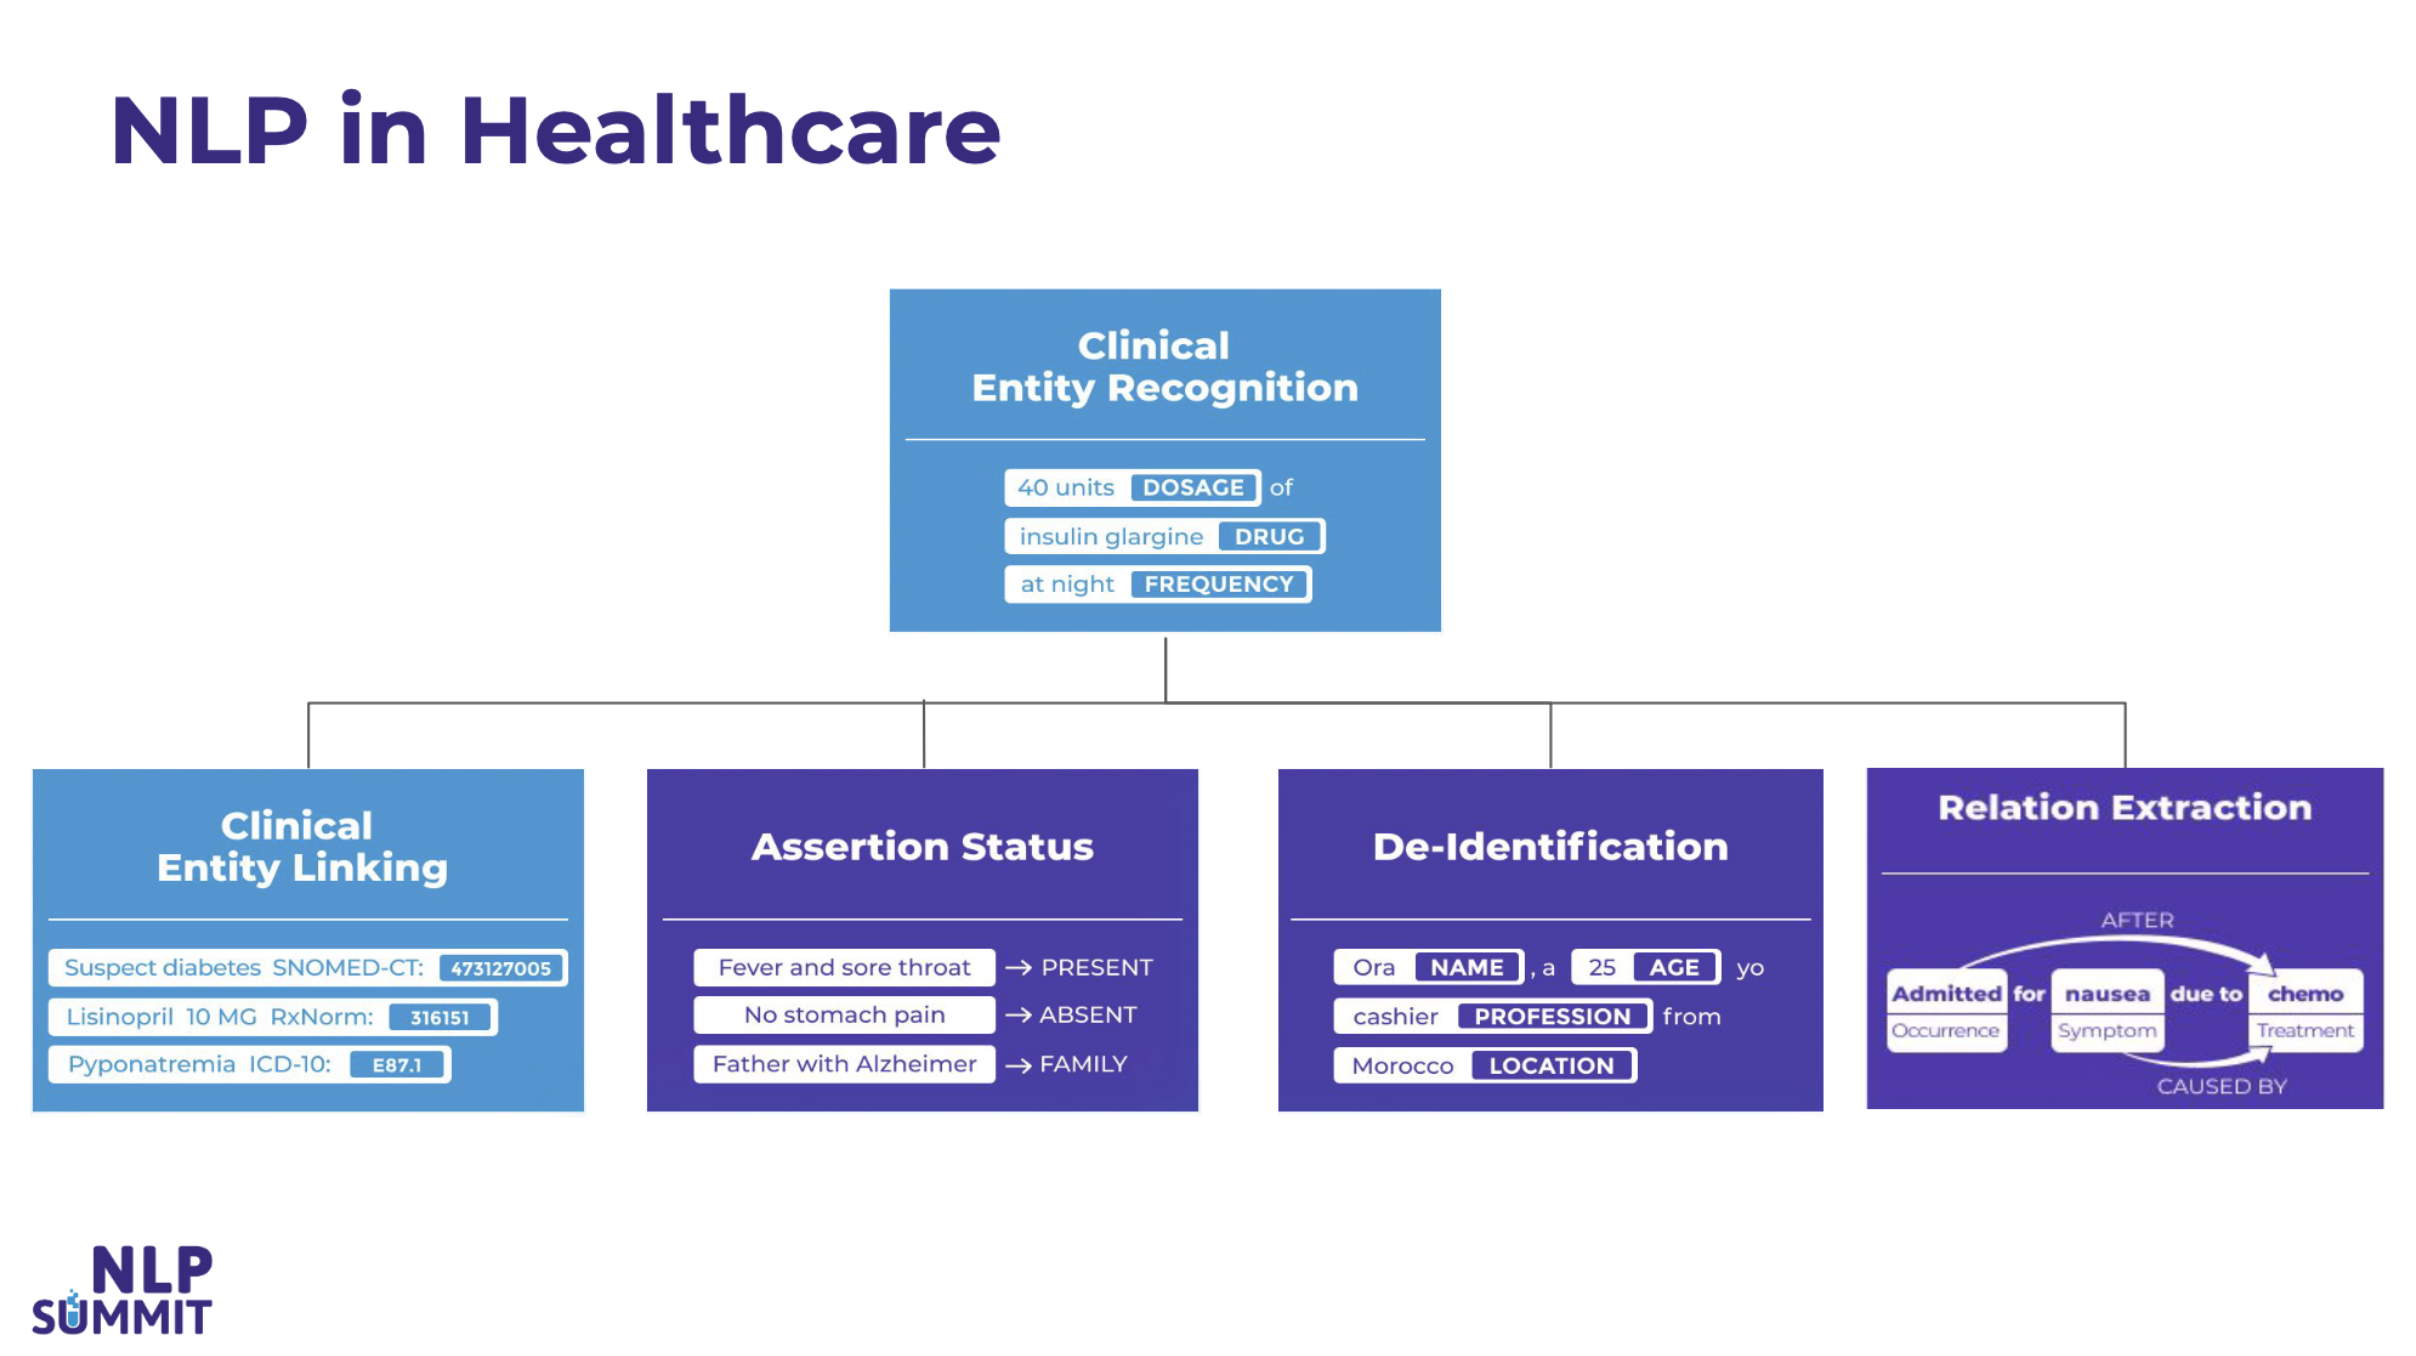

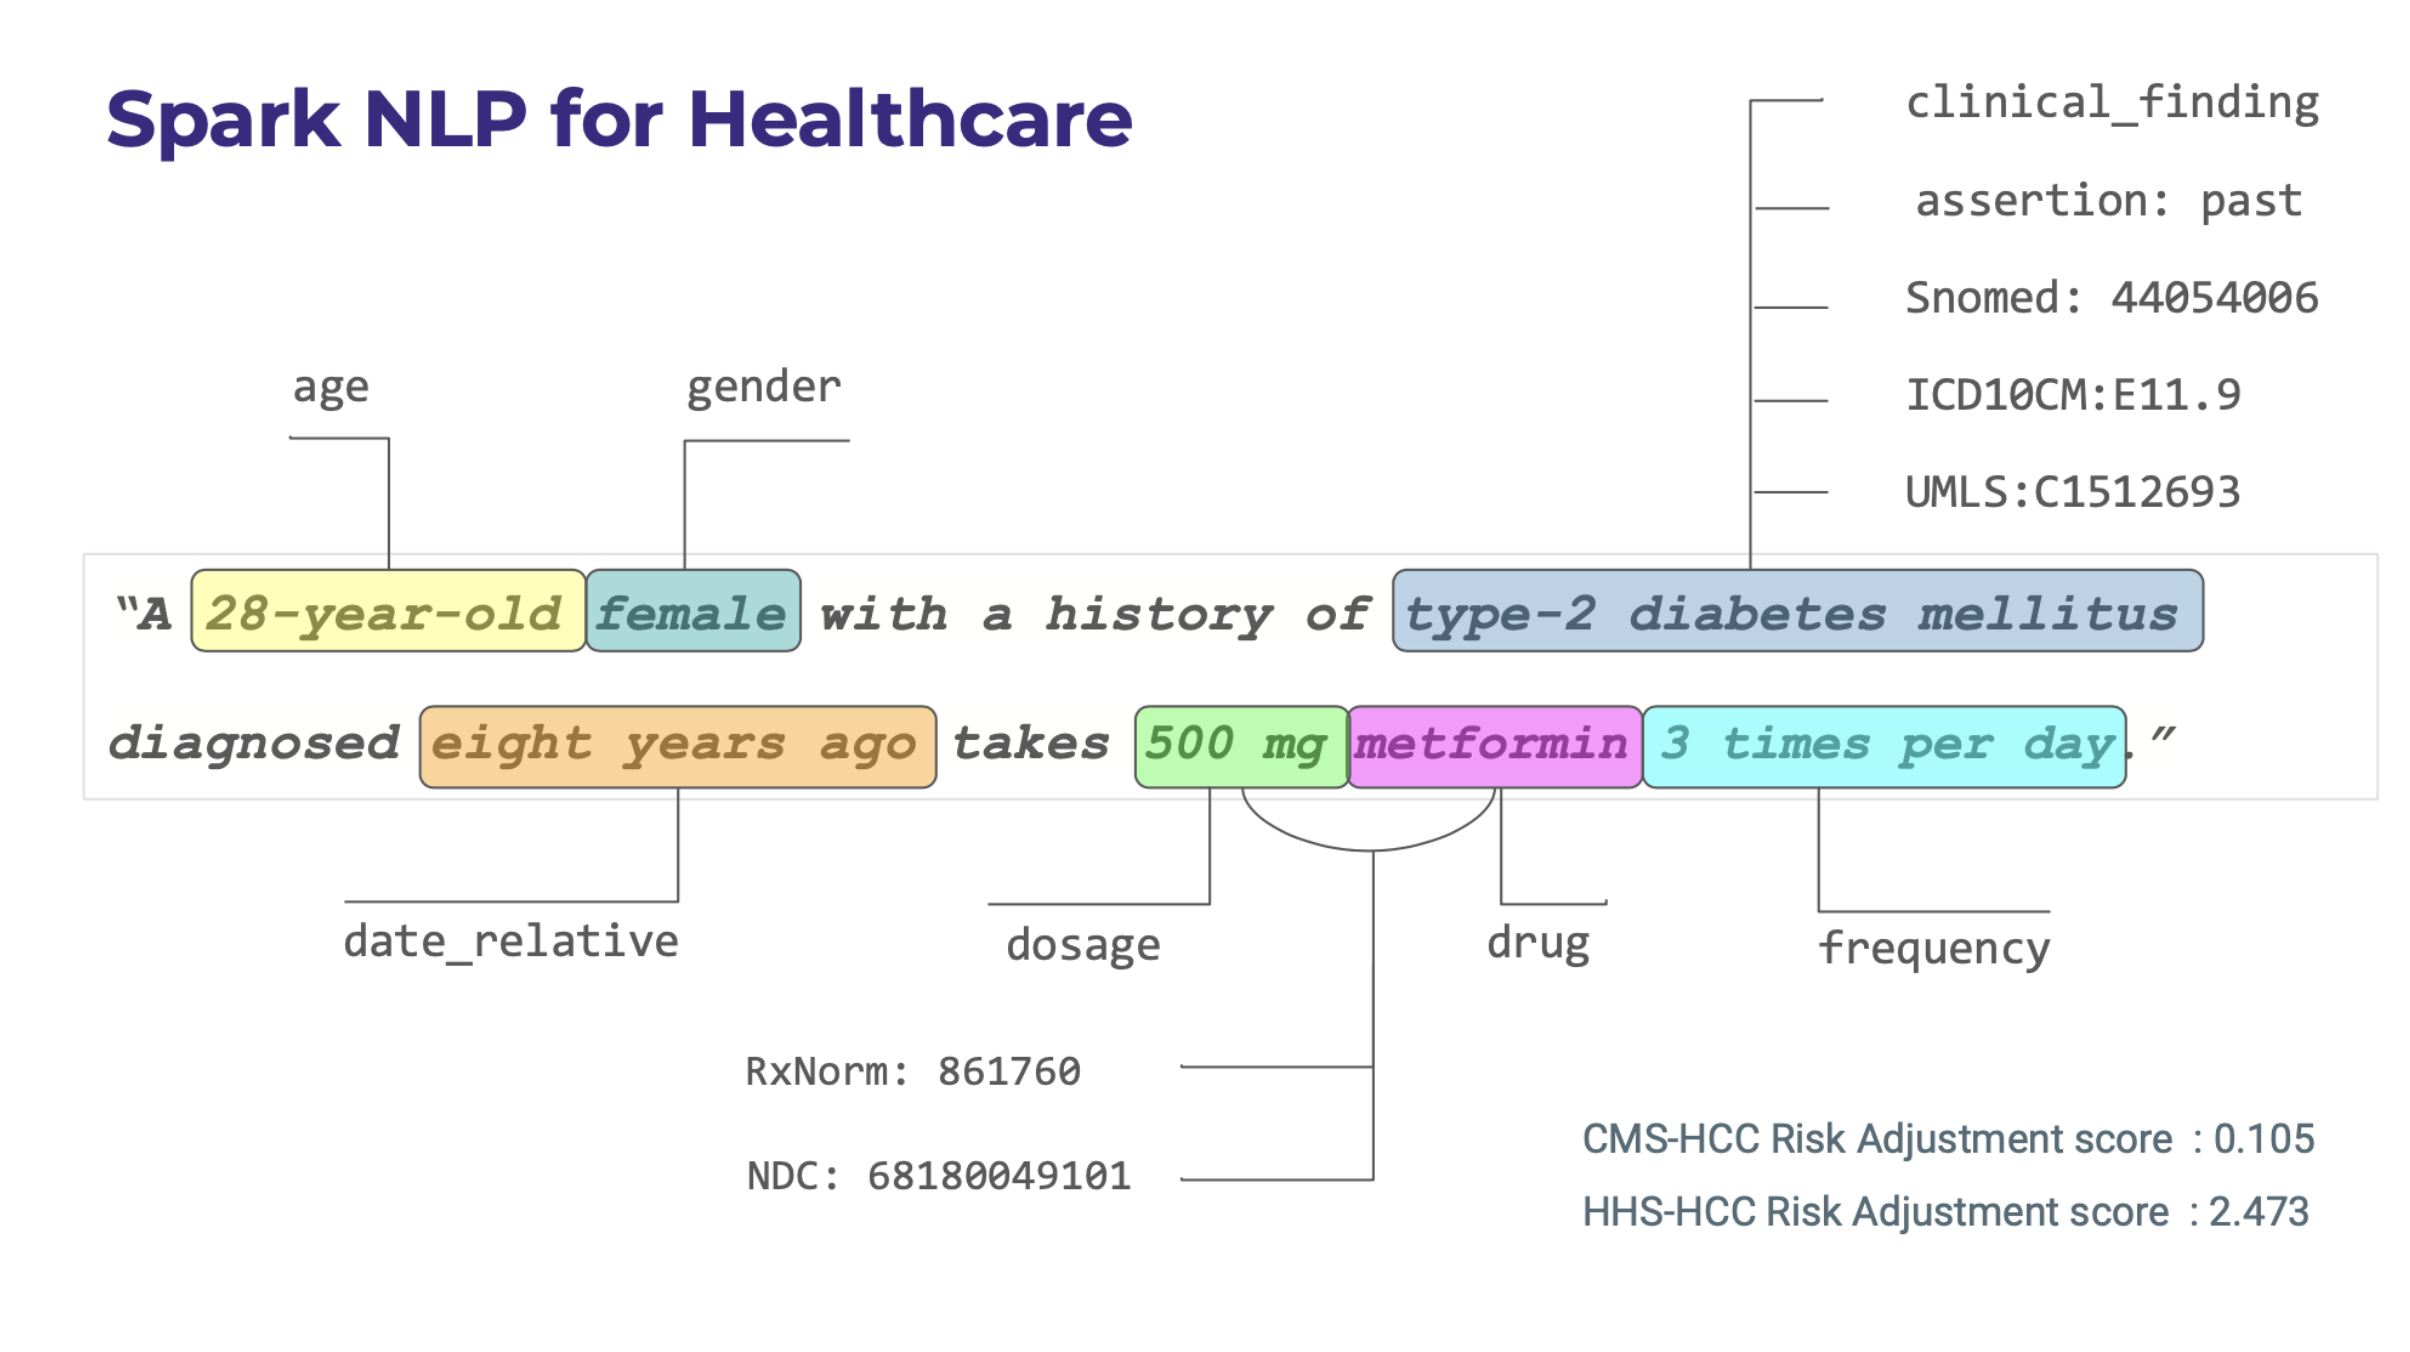

## Healthcare NLP for Data Scientists Course

If you are not familiar with the components in this notebook, you can check [Healthcare NLP for Data Scientists Udemy Course](https://www.udemy.com/course/healthcare-nlp-for-data-scientists/) and the [MOOC Notebooks](https://github.com/JohnSnowLabs/spark-nlp-workshop/tree/master/Spark_NLP_Udemy_MOOC/Healthcare_NLP) for each components.

# Coding...

Colab set-up and installing library and packages

In [ ]:
# Install the johnsnowlabs library to access Spark-OCR and Spark-NLP for Healthcare, Finance, and Legal.
! pip install -q johnsnowlabs

In [ ]:
from google.colab import files
print('Please Upload your John Snow Labs License using the button below')
license_keys = files.upload()

In [ ]:
from johnsnowlabs import nlp, medical

# After uploading your license run this to install all licensed Python Wheels and pre-download Jars the Spark Session JVM
nlp.settings.enforce_versions=False
nlp.install(refresh_install=True)

In [ ]:
from johnsnowlabs import nlp, medical, visual
import pandas as pd

# Automatically load license data and start a session with all jars user has access to
spark = nlp.start()

In [5]:
spark

In [ ]:
from pyspark.sql import DataFrame
import pyspark.sql.functions as F
import pyspark.sql.types as T
import pyspark.sql as SQL
from pyspark import keyword_only
from pyspark.sql.types import StringType

# 1.Clinical Named Entity Recognition (NER)

 The deep neural network architecture for NER model in
Spark NLP is BiLSTM-CNN-Char framework. a slightly modified version of the architecture proposed by Jason PC Chiu and Eric Nichols ([Named Entity Recognition with Bidirectional LSTM-CNNs
](https://arxiv.org/abs/1511.08308)). It is a neural network architecture that
automatically detects word and character-level features using a
hybrid bidirectional LSTM and CNN architecture, eliminating
the need for most feature engineering steps.

  In the original framework, the CNN extracts a fixed length
feature vector from character-level features. For each word,
these vectors are concatenated and fed to the BLSTM network
and then to the output layers. They employed a stacked
bi-directional recurrent neural network with long short-term
memory units to transform word features into named entity
tag scores. The extracted features of each word are fed into a
forward LSTM network and a backward LSTM network. The
output of each network at each time step is decoded by a linear
layer and a log-softmax layer into log-probabilities for each tag
category. These two vectors are then simply added together to
produce the final output. In the architecture of the proposed framework in the original paper, 50-dimensional pretrained word
embeddings is used for word features, 25-dimension character
embeddings is used for char features, and capitalization features
(allCaps, upperInitial, lowercase, mixedCaps, noinfo) are used
for case features.

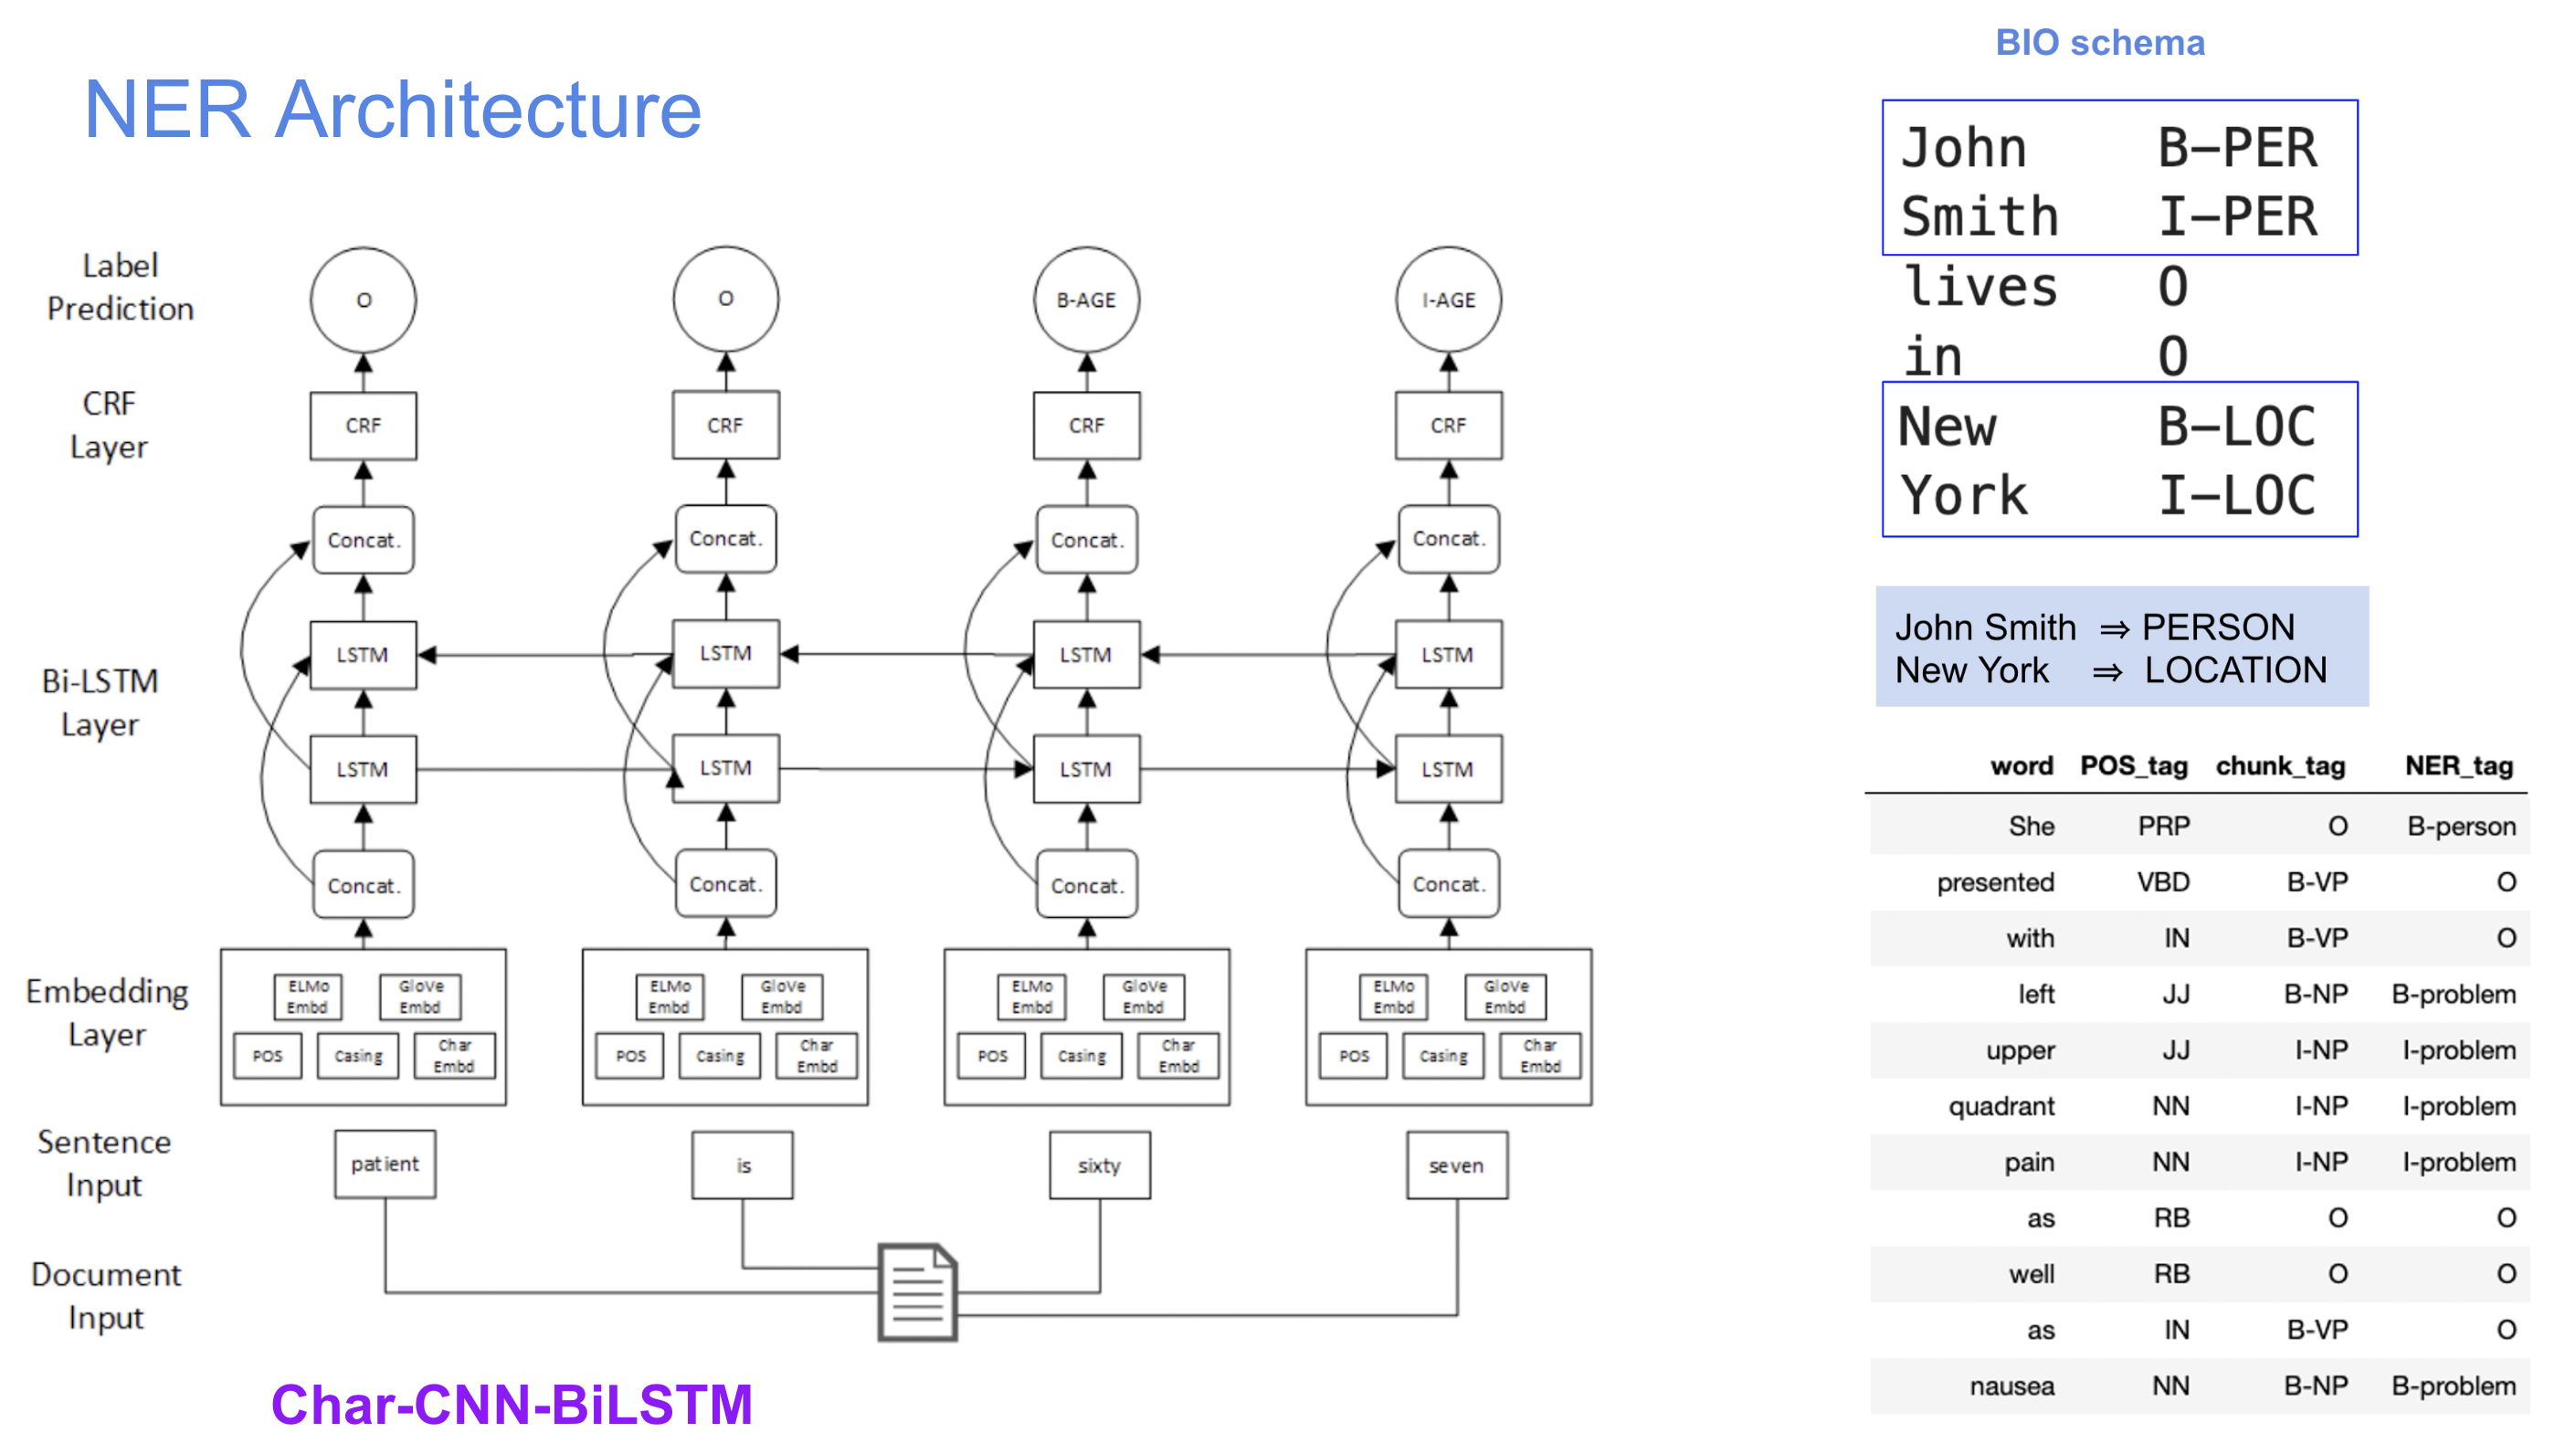

## Blogposts and videos:

- [How to Setup Spark NLP for HEALTHCARE on UBUNTU - Video](https://www.youtube.com/watch?v=yKnF-_oz0GE)

- [Named Entity Recognition (NER) with BERT in Spark NLP](https://towardsdatascience.com/named-entity-recognition-ner-with-bert-in-spark-nlp-874df20d1d77)

- [State of the art Clinical Named Entity Recognition in Spark NLP - Youtube](https://www.youtube.com/watch?v=YM-e4eOiQ34)

- [Named Entity Recognition for Healthcare with SparkNLP NerDL and NerCRF](https://medium.com/spark-nlp/named-entity-recognition-for-healthcare-with-sparknlp-nerdl-and-nercrf-a7751b6ad571)

- [Named Entity Recognition for Clinical Text](https://medium.com/atlas-research/ner-for-clinical-text-7c73caddd180)

For more details about NER with SparkNLP, please visit [SparkNLP Workshop Repo](https://github.com/JohnSnowLabs/spark-nlp-workshop/blob/master/healthcare-nlp/01.0.Clinical_Named_Entity_Recognition_Model.ipynb)

> Blok alıntı ekle



## Clinical NER Pipeline (with pretrained models)

SparkNLP has more than a hundred pretrained clinical NER pipelines which are trained with various domain-specific datasets and have various architectures. <br/>

**You can find all these models and more [NLP Models Hub](https://nlp.johnsnowlabs.com/models?task=Named+Entity+Recognition&edition=Spark+NLP+for+Healthcare)**






## Clinical NER Models
|index|model|index|model|index|model|index|model|
|-----:|:-----|-----:|:-----|-----:|:-----|-----:|:-----|
| 1| [jsl_ner_wip_clinical](https://nlp.johnsnowlabs.com/2021/03/31/jsl_ner_wip_clinical_en.html)  | 2| [jsl_ner_wip_greedy_clinical](https://nlp.johnsnowlabs.com/2021/03/31/jsl_ner_wip_greedy_clinical_en.html)  | 3| [jsl_ner_wip_modifier_clinical](https://nlp.johnsnowlabs.com/2021/04/01/jsl_ner_wip_modifier_clinical_en.html)  | 4| [jsl_rd_ner_wip_greedy_clinical](https://nlp.johnsnowlabs.com/2021/04/01/jsl_rd_ner_wip_greedy_clinical_en.html)  |
| 5| [ner_abbreviation_clinical](https://nlp.johnsnowlabs.com/2021/12/30/ner_abbreviation_clinical_en.html)  | 6| [ner_abbreviation_emb_clinical_large](https://nlp.johnsnowlabs.com/2023/05/12/ner_abbreviation_emb_clinical_large_en.html)  | 7| [ner_abbreviation_emb_clinical_medium](https://nlp.johnsnowlabs.com/2023/05/12/ner_abbreviation_emb_clinical_medium_en.html)  | 8| [ner_ade_clinical](https://nlp.johnsnowlabs.com/2021/04/01/ner_ade_clinical_en.html)  |
| 9| [ner_ade_clinical_langtest](https://nlp.johnsnowlabs.com/2023/07/31/ner_ade_clinical_langtest_en.html)  | 10| [ner_ade_emb_clinical_large](https://nlp.johnsnowlabs.com/2023/05/21/ner_ade_emb_clinical_large_en.html)  | 11| [ner_ade_emb_clinical_medium](https://nlp.johnsnowlabs.com/2023/05/21/ner_ade_emb_clinical_medium_en.html)  | 12| [ner_ade_healthcare](https://nlp.johnsnowlabs.com/2021/04/01/ner_ade_healthcare_en.html)  |
| 13| [ner_anatomy](https://nlp.johnsnowlabs.com/2021/03/31/ner_anatomy_en.html)  | 14| [ner_anatomy_coarse](https://nlp.johnsnowlabs.com/2021/03/31/ner_anatomy_coarse_en.html)  | 15| [ner_anatomy_coarse_en](https://nlp.johnsnowlabs.com/2020/11/04/ner_anatomy_coarse_en.html)  | 16| [ner_anatomy_emb_clinical_large](https://nlp.johnsnowlabs.com/2023/05/15/ner_anatomy_emb_clinical_large_en.html)  |
| 17| [ner_anatomy_emb_clinical_medium](https://nlp.johnsnowlabs.com/2023/05/15/ner_anatomy_emb_clinical_medium_en.html)  | 18| [ner_anatomy_en](https://nlp.johnsnowlabs.com/2020/04/22/ner_anatomy_en.html)  | 19| [ner_aspect_based_sentiment](https://nlp.johnsnowlabs.com/2021/03/31/ner_aspect_based_sentiment_en.html)  | 20| [ner_bacterial_species](https://nlp.johnsnowlabs.com/2021/04/01/ner_bacterial_species_en.html)  |
| 21| [ner_bacterial_species_emb_clinical_large](https://nlp.johnsnowlabs.com/2023/05/23/ner_bacterial_species_emb_clinical_large_en.html)  | 22| [ner_bacterial_species_emb_clinical_medium](https://nlp.johnsnowlabs.com/2023/05/23/ner_bacterial_species_emb_clinical_medium_en.html)  | 23| [ner_bacterial_species_langtest](https://nlp.johnsnowlabs.com/2023/10/15/ner_bacterial_species_langtest_en.html)  | 24| [ner_biomarker](https://nlp.johnsnowlabs.com/2021/11/26/ner_biomarker_en.html)  |
| 25| [ner_biomarker_langtest](https://nlp.johnsnowlabs.com/2023/10/10/ner_biomarker_langtest_en.html)  | 26| [ner_biomedical_bc2gm](https://nlp.johnsnowlabs.com/2022/05/11/ner_biomedical_bc2gm_en_2_4.html)  | 27| [ner_bionlp](https://nlp.johnsnowlabs.com/2021/03/31/ner_bionlp_en.html)  | 28| [ner_bionlp_en](https://nlp.johnsnowlabs.com/2020/01/30/ner_bionlp_en.html)  |
| 29| [ner_bionlp_langtest](https://nlp.johnsnowlabs.com/2023/10/10/ner_bionlp_langtest_en.html)  | 30| [ner_cancer_genetics](https://nlp.johnsnowlabs.com/2021/03/31/ner_cancer_genetics_en.html)  | 31| [ner_cellular](https://nlp.johnsnowlabs.com/2021/03/31/ner_cellular_en.html)  | 32| [ner_cellular_emb_clinical_large](https://nlp.johnsnowlabs.com/2023/05/24/ner_cellular_emb_clinical_large_en.html)  |
| 33| [ner_cellular_emb_clinical_medium](https://nlp.johnsnowlabs.com/2023/05/24/ner_cellular_emb_clinical_medium_en.html)  | 34| [ner_cellular_en](https://nlp.johnsnowlabs.com/2020/04/22/ner_cellular_en.html)  | 35| [ner_cellular_langtest](https://nlp.johnsnowlabs.com/2023/10/15/ner_cellular_langtest_en.html)  | 36| [ner_chemd_clinical](https://nlp.johnsnowlabs.com/2021/11/04/ner_chemd_clinical_en.html)  |
| 37| [ner_chemicals](https://nlp.johnsnowlabs.com/2021/04/01/ner_chemicals_en.html)  | 38| [ner_chemicals_emb_clinical_large](https://nlp.johnsnowlabs.com/2023/06/02/ner_chemicals_emb_clinical_large_en.html)  | 39| [ner_chemicals_emb_clinical_medium](https://nlp.johnsnowlabs.com/2023/06/02/ner_chemicals_emb_clinical_medium_en.html)  | 40| [ner_chemprot_clinical](https://nlp.johnsnowlabs.com/2020/09/21/ner_chemprot_clinical_en.html)  |
| 41| [ner_chemprot_clinical_langtest](https://nlp.johnsnowlabs.com/2023/10/12/ner_chemprot_clinical_langtest_en.html)  | 42| [ner_chexpert](https://nlp.johnsnowlabs.com/2021/09/30/ner_chexpert_en.html)  | 43| [ner_clinical](https://nlp.johnsnowlabs.com/2021/03/31/ner_clinical_en.html)  | 44| [ner_clinical_abbreviation_langtest](https://nlp.johnsnowlabs.com/2024/01/25/ner_clinical_abbreviation_langtest_en.html)  |
| 45| [ner_clinical_en](https://nlp.johnsnowlabs.com/2020/01/30/ner_clinical_en.html)  | 46| [ner_clinical_langtest](https://nlp.johnsnowlabs.com/2023/09/26/ner_clinical_langtest_en.html)  | 47| [ner_clinical_large](https://nlp.johnsnowlabs.com/2021/03/31/ner_clinical_large_en.html)  | 48| [ner_clinical_large_en](https://nlp.johnsnowlabs.com/2020/05/23/ner_clinical_large_en.html)  |
| 49| [ner_clinical_large_langtest](https://nlp.johnsnowlabs.com/2023/10/10/ner_clinical_large_langtest_en.html)  | 50| [ner_clinical_trials_abstracts](https://nlp.johnsnowlabs.com/2022/06/22/ner_clinical_trials_abstracts_en_3_0.html)  | 51| [ner_covid_trials](https://nlp.johnsnowlabs.com/2022/10/19/ner_covid_trials_en.html)  | 52| [ner_crf](https://nlp.johnsnowlabs.com/2020/01/28/ner_crf_en.html)  |
| 53| [ner_deid_enriched_langtest](https://nlp.johnsnowlabs.com/2023/10/15/ner_deid_enriched_langtest_en.html)  | 54| [ner_deid_generic_augmented_allUpperCased_langtest](https://nlp.johnsnowlabs.com/2023/10/16/ner_deid_generic_augmented_allUpperCased_langtest_en.html)  | 55| [ner_deid_generic_augmented_langtest](https://nlp.johnsnowlabs.com/2023/09/26/ner_deid_generic_augmented_langtest_en.html)  | 56| [ner_deid_large_emb_clinical_large](https://nlp.johnsnowlabs.com/2023/04/12/ner_deid_large_emb_clinical_large_en.html)  |
| 57| [ner_deid_large_emb_clinical_medium](https://nlp.johnsnowlabs.com/2023/04/12/ner_deid_large_emb_clinical_medium_en.html)  | 58| [ner_deid_large_langtest](https://nlp.johnsnowlabs.com/2023/10/15/ner_deid_large_langtest_en.html)  | 59| [ner_deid_subentity_augmented](https://nlp.johnsnowlabs.com/2021/09/03/ner_deid_subentity_augmented_en.html)  | 60| [ner_deid_subentity_augmented_langtest](https://nlp.johnsnowlabs.com/2023/09/26/ner_deid_subentity_augmented_langtest_en.html)  |
| 61| [ner_demographic_extended_healthcare](https://nlp.johnsnowlabs.com/2023/06/08/ner_demographic_extended_healthcare_en.html)  | 62| [ner_diseases](https://nlp.johnsnowlabs.com/2021/03/31/ner_diseases_en.html)  | 63| [ner_diseases_en](https://nlp.johnsnowlabs.com/2020/03/25/ner_diseases_en.html)  | 64| [ner_diseases_langtest](https://nlp.johnsnowlabs.com/2023/10/15/ner_diseases_langtest_en.html)  |
| 65| [ner_diseases_large](https://nlp.johnsnowlabs.com/2021/04/01/ner_diseases_large_en.html)  | 66| [ner_drugprot_clinical](https://nlp.johnsnowlabs.com/2021/12/20/ner_drugprot_clinical_en.html)  | 67| [ner_drugs](https://nlp.johnsnowlabs.com/2021/03/31/ner_drugs_en.html)  | 68| [ner_drugs_en](https://nlp.johnsnowlabs.com/2020/03/25/ner_drugs_en.html)  |
| 69| [ner_drugs_greedy](https://nlp.johnsnowlabs.com/2021/03/31/ner_drugs_greedy_en.html)  | 70| [ner_drugs_large](https://nlp.johnsnowlabs.com/2021/03/31/ner_drugs_large_en.html)  | 71| [ner_drugs_large_en](https://nlp.johnsnowlabs.com/2021/01/29/ner_drugs_large_en.html)  | 72| [ner_eu_clinical_case](https://nlp.johnsnowlabs.com/2023/01/25/ner_eu_clinical_case_en.html)  |
| 73| [ner_eu_clinical_condition](https://nlp.johnsnowlabs.com/2023/02/06/ner_eu_clinical_condition_en.html)  | 74| [ner_eu_clinical_condition_langtest](https://nlp.johnsnowlabs.com/2023/09/22/ner_eu_clinical_condition_langtest_en.html)  | 75| [ner_events_admission_clinical](https://nlp.johnsnowlabs.com/2021/03/31/ner_events_admission_clinical_en.html)  | 76| [ner_events_clinical](https://nlp.johnsnowlabs.com/2021/03/31/ner_events_clinical_en.html)  |
| 77| [ner_events_clinical_langtest](https://nlp.johnsnowlabs.com/2023/08/31/ner_events_clinical_langtest_en.html)  | 78| [ner_events_healthcare](https://nlp.johnsnowlabs.com/2021/04/01/ner_events_healthcare_en.html)  | 79| [ner_financial_contract](https://nlp.johnsnowlabs.com/2021/04/01/ner_financial_contract_en.html)  | 80| [ner_genetic_variants](https://nlp.johnsnowlabs.com/2021/06/25/ner_genetic_variants_en.html)  |
| 81| [ner_healthcare](https://nlp.johnsnowlabs.com/2021/04/21/ner_healthcare_en.html)  | 82| [ner_healthcare_en](https://nlp.johnsnowlabs.com/2020/03/26/ner_healthcare_en.html)  | 83| [ner_human_phenotype_gene_clinical](https://nlp.johnsnowlabs.com/2020/09/21/ner_human_phenotype_gene_clinical_en.html)  | 84| [ner_human_phenotype_gene_clinical_langtest](https://nlp.johnsnowlabs.com/2023/11/04/ner_human_phenotype_gene_clinical_langtest_en.html)  |
| 85| [ner_human_phenotype_go_clinical](https://nlp.johnsnowlabs.com/2020/09/21/ner_human_phenotype_go_clinical_en.html)  | 86| [ner_human_phenotype_go_clinical_langtest](https://nlp.johnsnowlabs.com/2023/11/04/ner_human_phenotype_go_clinical_langtest_en.html)  | 87| [ner_jsl](https://nlp.johnsnowlabs.com/2022/10/19/ner_jsl_en.html)  | 88| [ner_jsl_emb_clinical_large](https://nlp.johnsnowlabs.com/2023/04/12/ner_jsl_emb_clinical_large_en.html)  |
| 89| [ner_jsl_emb_clinical_medium](https://nlp.johnsnowlabs.com/2023/04/12/ner_jsl_emb_clinical_medium_en.html)  | 90| [ner_jsl_en](https://nlp.johnsnowlabs.com/2020/04/22/ner_jsl_en.html)  | 91| [ner_jsl_enriched](https://nlp.johnsnowlabs.com/2021/10/22/ner_jsl_enriched_en.html)  | 92| [ner_jsl_enriched_en](https://nlp.johnsnowlabs.com/2020/04/22/ner_jsl_enriched_en.html)  |
| 93| [ner_jsl_greedy](https://nlp.johnsnowlabs.com/2021/06/24/ner_jsl_greedy_en.html)  | 94| [ner_jsl_langtest](https://nlp.johnsnowlabs.com/2023/07/31/ner_jsl_langtest_en.html)  | 95| [ner_jsl_limited_80p_for_benchmarks](https://nlp.johnsnowlabs.com/2023/04/02/ner_jsl_limited_80p_for_benchmarks_en.html)  | 96| [ner_jsl_slim](https://nlp.johnsnowlabs.com/2021/08/13/ner_jsl_slim_en.html)  |
| 97| [ner_living_species](https://nlp.johnsnowlabs.com/2022/06/22/ner_living_species_en_3_0.html)  | 98| [ner_living_species_langtest](https://nlp.johnsnowlabs.com/2023/10/10/ner_living_species_langtest_en.html)  | 99| [ner_measurements_clinical](https://nlp.johnsnowlabs.com/2021/04/01/ner_measurements_clinical_en.html)  | 100| [ner_medmentions_coarse](https://nlp.johnsnowlabs.com/2021/04/01/ner_medmentions_coarse_en.html)  |
| 101| [ner_nature_nero_clinical](https://nlp.johnsnowlabs.com/2022/02/08/ner_nature_nero_clinical_en.html)  | 102| [ner_nihss](https://nlp.johnsnowlabs.com/2021/11/15/ner_nihss_en.html)  | 103| [ner_oncology](https://nlp.johnsnowlabs.com/2022/10/25/ner_oncology_en.html)  | 104| [ner_oncology_anatomy_general](https://nlp.johnsnowlabs.com/2022/10/25/ner_oncology_anatomy_general_en.html)  |
| 105| [ner_oncology_anatomy_general_healthcare](https://nlp.johnsnowlabs.com/2023/01/11/ner_oncology_anatomy_general_healthcare_en.html)  | 106| [ner_oncology_anatomy_general_langtest](https://nlp.johnsnowlabs.com/2023/09/03/ner_oncology_anatomy_general_langtest_en.html)  | 107| [ner_oncology_anatomy_general_wip](https://nlp.johnsnowlabs.com/2022/09/30/ner_oncology_anatomy_general_wip_en.html)  | 108| [ner_oncology_anatomy_granular](https://nlp.johnsnowlabs.com/2022/10/25/ner_oncology_anatomy_granular_en.html)  |
| 109| [ner_oncology_anatomy_granular_langtest](https://nlp.johnsnowlabs.com/2023/09/03/ner_oncology_anatomy_granular_langtest_en.html)  | 110| [ner_oncology_anatomy_granular_wip](https://nlp.johnsnowlabs.com/2022/10/01/ner_oncology_anatomy_granular_wip_en.html)  | 111| [ner_oncology_biomarker](https://nlp.johnsnowlabs.com/2022/10/25/ner_oncology_biomarker_en.html)  | 112| [ner_oncology_biomarker_healthcare](https://nlp.johnsnowlabs.com/2023/01/11/ner_oncology_biomarker_healthcare_en.html)  |
| 113| [ner_oncology_biomarker_langtest](https://nlp.johnsnowlabs.com/2023/09/22/ner_oncology_biomarker_langtest_en.html)  | 114| [ner_oncology_biomarker_wip](https://nlp.johnsnowlabs.com/2022/10/01/ner_oncology_biomarker_wip_en.html)  | 115| [ner_oncology_demographics](https://nlp.johnsnowlabs.com/2022/10/25/ner_oncology_demographics_en.html)  | 116| [ner_oncology_demographics_langtest](https://nlp.johnsnowlabs.com/2023/09/03/ner_oncology_demographics_langtest_en.html)  |
| 117| [ner_oncology_demographics_wip](https://nlp.johnsnowlabs.com/2022/09/30/ner_oncology_demographics_wip_en.html)  | 118| [ner_oncology_diagnosis](https://nlp.johnsnowlabs.com/2022/10/25/ner_oncology_diagnosis_en.html)  | 119| [ner_oncology_diagnosis_langtest](https://nlp.johnsnowlabs.com/2023/09/22/ner_oncology_diagnosis_langtest_en.html)  | 120| [ner_oncology_diagnosis_wip](https://nlp.johnsnowlabs.com/2022/09/30/ner_oncology_diagnosis_wip_en.html)  |
| 121| [ner_oncology_emb_clinical_large](https://nlp.johnsnowlabs.com/2023/04/12/ner_oncology_emb_clinical_large_en.html)  | 122| [ner_oncology_emb_clinical_medium](https://nlp.johnsnowlabs.com/2023/04/12/ner_oncology_emb_clinical_medium_en.html)  | 123| [ner_oncology_langtest](https://nlp.johnsnowlabs.com/2023/10/15/ner_oncology_langtest_en.html)  | 124| [ner_oncology_limited_80p_for_benchmarks](https://nlp.johnsnowlabs.com/2023/04/03/ner_oncology_limited_80p_for_benchmarks_en.html)  |
| 125| [ner_oncology_posology](https://nlp.johnsnowlabs.com/2022/10/25/ner_oncology_posology_en.html)  | 126| [ner_oncology_posology_langtest](https://nlp.johnsnowlabs.com/2023/09/04/ner_oncology_posology_langtest_en.html)  | 127| [ner_oncology_posology_wip](https://nlp.johnsnowlabs.com/2022/10/01/ner_oncology_posology_wip_en.html)  | 128| [ner_oncology_response_to_treatment](https://nlp.johnsnowlabs.com/2022/10/25/ner_oncology_response_to_treatment_en.html)  |
| 129| [ner_oncology_response_to_treatment_langtest](https://nlp.johnsnowlabs.com/2023/09/04/ner_oncology_response_to_treatment_langtest_en.html)  | 130| [ner_oncology_response_to_treatment_wip](https://nlp.johnsnowlabs.com/2022/10/01/ner_oncology_response_to_treatment_wip_en.html)  | 131| [ner_oncology_test](https://nlp.johnsnowlabs.com/2022/10/25/ner_oncology_test_en.html)  | 132| [ner_oncology_test_langtest](https://nlp.johnsnowlabs.com/2023/09/22/ner_oncology_test_langtest_en.html)  |
| 133| [ner_oncology_test_wip](https://nlp.johnsnowlabs.com/2022/09/30/ner_oncology_test_wip_en.html)  | 134| [ner_oncology_therapy](https://nlp.johnsnowlabs.com/2022/10/25/ner_oncology_therapy_en.html)  | 135| [ner_oncology_therapy_langtest](https://nlp.johnsnowlabs.com/2023/09/22/ner_oncology_therapy_langtest_en.html)  | 136| [ner_oncology_therapy_wip](https://nlp.johnsnowlabs.com/2022/09/30/ner_oncology_therapy_wip_en.html)  |
| 137| [ner_oncology_tnm](https://nlp.johnsnowlabs.com/2022/10/25/ner_oncology_tnm_en.html)  | 138| [ner_oncology_tnm_langtest](https://nlp.johnsnowlabs.com/2023/09/22/ner_oncology_tnm_langtest_en.html)  | 139| [ner_oncology_tnm_wip](https://nlp.johnsnowlabs.com/2022/09/30/ner_oncology_tnm_wip_en.html)  | 140| [ner_oncology_unspecific_posology](https://nlp.johnsnowlabs.com/2022/10/25/ner_oncology_unspecific_posology_en.html)  |
| 141| [ner_oncology_unspecific_posology_healthcare](https://nlp.johnsnowlabs.com/2023/01/11/ner_oncology_unspecific_posology_healthcare_en.html)  | 142| [ner_oncology_unspecific_posology_langtest](https://nlp.johnsnowlabs.com/2023/09/22/ner_oncology_unspecific_posology_langtest_en.html)  | 143| [ner_oncology_unspecific_posology_wip](https://nlp.johnsnowlabs.com/2022/09/30/ner_oncology_unspecific_posology_wip_en.html)  | 144| [ner_oncology_wip](https://nlp.johnsnowlabs.com/2022/09/30/ner_oncology_wip_en.html)  |
| 145| [ner_opioid](https://nlp.johnsnowlabs.com/2024/02/28/ner_opioid_en.html)  | 146| [ner_opioid_small_wip](https://nlp.johnsnowlabs.com/2024/01/11/ner_opioid_small_wip_en.html)  | 147| [ner_pathogen](https://nlp.johnsnowlabs.com/2022/06/28/ner_pathogen_en_3_0.html)  | 148| [ner_posology](https://nlp.johnsnowlabs.com/2021/03/31/ner_posology_en.html)  |
| 149| [ner_posology_emb_clinical_large](https://nlp.johnsnowlabs.com/2023/04/12/ner_posology_emb_clinical_large_en.html)  | 150| [ner_posology_emb_clinical_medium](https://nlp.johnsnowlabs.com/2023/04/12/ner_posology_emb_clinical_medium_en.html)  | 151| [ner_posology_en](https://nlp.johnsnowlabs.com/2020/04/15/ner_posology_en.html)  | 152| [ner_posology_experimental](https://nlp.johnsnowlabs.com/2021/09/01/ner_posology_experimental_en.html)  |
| 153| [ner_posology_greedy](https://nlp.johnsnowlabs.com/2021/03/31/ner_posology_greedy_en.html)  | 154| [ner_posology_healthcare](https://nlp.johnsnowlabs.com/2021/04/01/ner_posology_healthcare_en.html)  | 155| [ner_posology_langtest](https://nlp.johnsnowlabs.com/2023/07/28/ner_posology_langtest_en.html)  | 156| [ner_posology_large](https://nlp.johnsnowlabs.com/2021/03/31/ner_posology_large_en.html)  |
| 157| [ner_posology_small](https://nlp.johnsnowlabs.com/2021/03/31/ner_posology_small_en.html)  | 158| [ner_radiology](https://nlp.johnsnowlabs.com/2021/03/31/ner_radiology_en.html)  | 159| [ner_radiology_wip_clinical](https://nlp.johnsnowlabs.com/2021/04/01/ner_radiology_wip_clinical_en.html)  | 160| [ner_risk_factors](https://nlp.johnsnowlabs.com/2021/03/31/ner_risk_factors_en.html)  |
| 161| [ner_risk_factors_en](https://nlp.johnsnowlabs.com/2020/04/22/ner_risk_factors_en.html)  | 162| [ner_risk_factors_langtest](https://nlp.johnsnowlabs.com/2023/11/06/ner_risk_factors_langtest_en.html)  | 163| [ner_sdoh](https://nlp.johnsnowlabs.com/2023/06/13/ner_sdoh_en.html)  | 164| [ner_sdoh_access_to_healthcare](https://nlp.johnsnowlabs.com/2023/07/02/ner_sdoh_access_to_healthcare_en.html)  |
| 165| [ner_sdoh_access_to_healthcare_wip](https://nlp.johnsnowlabs.com/2023/02/24/ner_sdoh_access_to_healthcare_wip_en.html)  | 166| [ner_sdoh_community_condition](https://nlp.johnsnowlabs.com/2023/07/02/ner_sdoh_community_condition_en.html)  | 167| [ner_sdoh_community_condition_wip](https://nlp.johnsnowlabs.com/2023/02/24/ner_sdoh_community_condition_wip_en.html)  | 168| [ner_sdoh_demographics](https://nlp.johnsnowlabs.com/2023/07/02/ner_sdoh_demographics_en.html)  |
| 169| [ner_sdoh_demographics_wip](https://nlp.johnsnowlabs.com/2023/02/10/ner_sdoh_demographics_wip_en.html)  | 170| [ner_sdoh_emb_clinical_large_wip](https://nlp.johnsnowlabs.com/2023/04/17/ner_sdoh_emb_clinical_large_wip_en.html)  | 171| [ner_sdoh_emb_clinical_medium_wip](https://nlp.johnsnowlabs.com/2023/04/27/ner_sdoh_emb_clinical_medium_wip_en.html)  | 172| [ner_sdoh_health_behaviours_problems](https://nlp.johnsnowlabs.com/2023/07/02/ner_sdoh_health_behaviours_problems_en.html)  |
| 173| [ner_sdoh_health_behaviours_problems_wip](https://nlp.johnsnowlabs.com/2023/02/24/ner_sdoh_health_behaviours_problems_wip_en.html)  | 174| [ner_sdoh_income_social_status](https://nlp.johnsnowlabs.com/2023/07/02/ner_sdoh_income_social_status_en.html)  | 175| [ner_sdoh_income_social_status_wip](https://nlp.johnsnowlabs.com/2023/02/10/ner_sdoh_income_social_status_wip_en.html)  | 176| [ner_sdoh_langtest](https://nlp.johnsnowlabs.com/2023/07/31/ner_sdoh_langtest_en.html)  |
| 177| [ner_sdoh_mentions](https://nlp.johnsnowlabs.com/2022/12/18/ner_sdoh_mentions_en.html)  | 178| [ner_sdoh_slim_wip](https://nlp.johnsnowlabs.com/2022/11/15/ner_sdoh_slim_wip_en.html)  | 179| [ner_sdoh_social_environment](https://nlp.johnsnowlabs.com/2023/07/02/ner_sdoh_social_environment_en.html)  | 180| [ner_sdoh_social_environment_wip](https://nlp.johnsnowlabs.com/2023/02/10/ner_sdoh_social_environment_wip_en.html)  |
| 181| [ner_sdoh_substance_usage](https://nlp.johnsnowlabs.com/2023/07/02/ner_sdoh_substance_usage_en.html)  | 182| [ner_sdoh_substance_usage_wip](https://nlp.johnsnowlabs.com/2023/02/23/ner_sdoh_substance_usage_wip_en.html)  | 183| [ner_sdoh_wip](https://nlp.johnsnowlabs.com/2023/02/11/ner_sdoh_wip_en.html)  | 184| [ner_section_header_diagnosis](https://nlp.johnsnowlabs.com/2023/07/26/ner_section_header_diagnosis_en.html)  |
| 185| [ner_snomed_term](https://nlp.johnsnowlabs.com/2024/02/13/ner_snomed_term_en.html)  | 186| [ner_supplement_clinical](https://nlp.johnsnowlabs.com/2022/02/01/ner_supplement_clinical_en.html)  | 187| [ner_vop](https://nlp.johnsnowlabs.com/2023/06/06/ner_vop_en.html)  | 188| [ner_vop_anatomy](https://nlp.johnsnowlabs.com/2023/06/06/ner_vop_anatomy_en.html)  |
| 189| [ner_vop_anatomy_emb_clinical_large](https://nlp.johnsnowlabs.com/2023/06/06/ner_vop_anatomy_emb_clinical_large_en.html)  | 190| [ner_vop_anatomy_emb_clinical_medium](https://nlp.johnsnowlabs.com/2023/06/07/ner_vop_anatomy_emb_clinical_medium_en.html)  | 191| [ner_vop_anatomy_langtest](https://nlp.johnsnowlabs.com/2023/09/21/ner_vop_anatomy_langtest_en.html)  | 192| [ner_vop_anatomy_wip](https://nlp.johnsnowlabs.com/2023/05/19/ner_vop_anatomy_wip_en.html)  |
| 193| [ner_vop_clinical_dept](https://nlp.johnsnowlabs.com/2023/06/06/ner_vop_clinical_dept_en.html)  | 194| [ner_vop_clinical_dept_emb_clinical_large](https://nlp.johnsnowlabs.com/2023/06/06/ner_vop_clinical_dept_emb_clinical_large_en.html)  | 195| [ner_vop_clinical_dept_emb_clinical_medium](https://nlp.johnsnowlabs.com/2023/06/06/ner_vop_clinical_dept_emb_clinical_medium_en.html)  | 196| [ner_vop_clinical_dept_langtest](https://nlp.johnsnowlabs.com/2023/09/21/ner_vop_clinical_dept_langtest_en.html)  |
| 197| [ner_vop_clinical_dept_wip](https://nlp.johnsnowlabs.com/2023/05/19/ner_vop_clinical_dept_wip_en.html)  | 198| [ner_vop_demographic](https://nlp.johnsnowlabs.com/2023/06/06/ner_vop_demographic_en.html)  | 199| [ner_vop_demographic_emb_clinical_large](https://nlp.johnsnowlabs.com/2023/06/06/ner_vop_demographic_emb_clinical_large_en.html)  | 200| [ner_vop_demographic_emb_clinical_medium](https://nlp.johnsnowlabs.com/2023/06/06/ner_vop_demographic_emb_clinical_medium_en.html)  |
| 201| [ner_vop_demographic_langtest](https://nlp.johnsnowlabs.com/2023/09/21/ner_vop_demographic_langtest_en.html)  | 202| [ner_vop_demographic_wip](https://nlp.johnsnowlabs.com/2023/05/19/ner_vop_demographic_wip_en.html)  | 203| [ner_vop_emb_clinical_large](https://nlp.johnsnowlabs.com/2023/06/06/ner_vop_emb_clinical_large_en.html)  | 204| [ner_vop_emb_clinical_large_wip](https://nlp.johnsnowlabs.com/2023/04/12/ner_vop_emb_clinical_large_wip_en.html)  |
| 205| [ner_vop_emb_clinical_medium](https://nlp.johnsnowlabs.com/2023/06/06/ner_vop_emb_clinical_medium_en.html)  | 206| [ner_vop_emb_clinical_medium_wip](https://nlp.johnsnowlabs.com/2023/04/12/ner_vop_emb_clinical_medium_wip_en.html)  | 207| [ner_vop_langtest](https://nlp.johnsnowlabs.com/2023/10/10/ner_vop_langtest_en.html)  | 208| [ner_vop_problem](https://nlp.johnsnowlabs.com/2023/06/06/ner_vop_problem_en.html)  |
| 209| [ner_vop_problem_emb_clinical_large](https://nlp.johnsnowlabs.com/2023/06/06/ner_vop_problem_emb_clinical_large_en.html)  | 210| [ner_vop_problem_emb_clinical_medium](https://nlp.johnsnowlabs.com/2023/06/06/ner_vop_problem_emb_clinical_medium_en.html)  | 211| [ner_vop_problem_langtest](https://nlp.johnsnowlabs.com/2023/09/21/ner_vop_problem_langtest_en.html)  | 212| [ner_vop_problem_reduced](https://nlp.johnsnowlabs.com/2023/06/07/ner_vop_problem_reduced_en.html)  |
| 213| [ner_vop_problem_reduced_emb_clinical_large](https://nlp.johnsnowlabs.com/2023/06/07/ner_vop_problem_reduced_emb_clinical_large_en.html)  | 214| [ner_vop_problem_reduced_emb_clinical_medium](https://nlp.johnsnowlabs.com/2023/06/07/ner_vop_problem_reduced_emb_clinical_medium_en.html)  | 215| [ner_vop_problem_reduced_langtest](https://nlp.johnsnowlabs.com/2023/09/22/ner_vop_problem_reduced_langtest_en.html)  | 216| [ner_vop_problem_reduced_wip](https://nlp.johnsnowlabs.com/2023/05/19/ner_vop_problem_reduced_wip_en.html)  |
| 217| [ner_vop_problem_wip](https://nlp.johnsnowlabs.com/2023/05/19/ner_vop_problem_wip_en.html)  | 218| [ner_vop_slim_wip](https://nlp.johnsnowlabs.com/2023/02/25/ner_vop_slim_wip_en.html)  | 219| [ner_vop_temporal](https://nlp.johnsnowlabs.com/2023/06/06/ner_vop_temporal_en.html)  | 220| [ner_vop_temporal_emb_clinical_large_final](https://nlp.johnsnowlabs.com/2023/06/06/ner_vop_temporal_emb_clinical_large_final_en.html)  |
| 221| [ner_vop_temporal_emb_clinical_medium](https://nlp.johnsnowlabs.com/2023/06/06/ner_vop_temporal_emb_clinical_medium_en.html)  | 222| [ner_vop_temporal_langtest](https://nlp.johnsnowlabs.com/2023/09/22/ner_vop_temporal_langtest_en.html)  | 223| [ner_vop_temporal_wip](https://nlp.johnsnowlabs.com/2023/05/19/ner_vop_temporal_wip_en.html)  | 224| [ner_vop_test](https://nlp.johnsnowlabs.com/2023/06/06/ner_vop_test_en.html)  |
| 225| [ner_vop_test_emb_clinical_large](https://nlp.johnsnowlabs.com/2023/06/06/ner_vop_test_emb_clinical_large_en.html)  | 226| [ner_vop_test_emb_clinical_medium](https://nlp.johnsnowlabs.com/2023/06/06/ner_vop_test_emb_clinical_medium_en.html)  | 227| [ner_vop_test_langtest](https://nlp.johnsnowlabs.com/2023/09/22/ner_vop_test_langtest_en.html)  | 228| [ner_vop_test_wip](https://nlp.johnsnowlabs.com/2023/05/19/ner_vop_test_wip_en.html)  |
| 229| [ner_vop_treatment](https://nlp.johnsnowlabs.com/2023/06/06/ner_vop_treatment_en.html)  | 230| [ner_vop_treatment_emb_clinical_large](https://nlp.johnsnowlabs.com/2023/06/06/ner_vop_treatment_emb_clinical_large_en.html)  | 231| [ner_vop_treatment_emb_clinical_medium](https://nlp.johnsnowlabs.com/2023/06/06/ner_vop_treatment_emb_clinical_medium_en.html)  | 232| [ner_vop_treatment_langtest](https://nlp.johnsnowlabs.com/2023/09/22/ner_vop_treatment_langtest_en.html)  |
| 233| [ner_vop_treatment_wip](https://nlp.johnsnowlabs.com/2023/05/19/ner_vop_treatment_wip_en.html)  | 234| [ner_vop_wip](https://nlp.johnsnowlabs.com/2023/05/19/ner_vop_wip_en.html)  | 235| [ner_vop_wip_emb_clinical_large](https://nlp.johnsnowlabs.com/2023/05/19/ner_vop_wip_embeddings_clinical_large_en.html)  | 236| [ner_vop_wip_emb_clinical_medium](https://nlp.johnsnowlabs.com/2023/05/19/ner_vop_wip_embeddings_clinical_medium_en.html)  |
| 237| [nerdl_tumour_demo](https://nlp.johnsnowlabs.com/2021/04/01/nerdl_tumour_demo_en.html)  |238|[ner_alcohol_smoking](https://nlp.johnsnowlabs.com/2024/07/01/ner_alcohol_smoking_en.html) |239|[ner_menopause_core](https://nlp.johnsnowlabs.com/2024/07/03/ner_menopause_core_en.html)|



- **Multilingual Clinical NER Models**

|index|model|index|model|index|model|index|model|
|-----:|:-----|-----:|:-----|-----:|:-----|-----:|:-----|
| 1| [ner_clinical](https://nlp.johnsnowlabs.com/2023/05/08/ner_clinical_de.html)  | 2| [ner_clinical_bert](https://nlp.johnsnowlabs.com/2022/11/22/ner_clinical_bert_ro.html)  | 3| [ner_clinical_trials_abstracts](https://nlp.johnsnowlabs.com/2022/08/12/ner_clinical_trials_abstracts_es_3_0.html)  | 4| [ner_deid_generic](https://nlp.johnsnowlabs.com/2023/05/30/ner_deid_generic_ar.html)  |
| 5| [ner_deid_generic_bert](https://nlp.johnsnowlabs.com/2022/11/22/ner_deid_generic_bert_ro.html)  | 6| [ner_deid_subentity](https://nlp.johnsnowlabs.com/2023/05/31/ner_deid_subentity_ar.html)  | 7| [ner_deid_subentity_bert](https://nlp.johnsnowlabs.com/2022/06/27/ner_deid_subentity_bert_ro_3_0.html)  | 8| [ner_diag_proc](https://nlp.johnsnowlabs.com/2021/03/31/ner_diag_proc_es.html)  |
| 9| [ner_eu_clinical_case](https://nlp.johnsnowlabs.com/2023/02/02/ner_eu_clinical_case_eu.html)  | 10| [ner_eu_clinical_condition](https://nlp.johnsnowlabs.com/2023/02/06/ner_eu_clinical_condition_es.html)  | 11| [ner_healthcare](https://nlp.johnsnowlabs.com/2020/09/28/ner_healthcare_de.html)  | 12| [ner_healthcare_slim](https://nlp.johnsnowlabs.com/2021/04/01/ner_healthcare_slim_de.html)  |
| 13| [ner_living_species](https://nlp.johnsnowlabs.com/2022/06/23/ner_living_species_it_3_0.html)  | 14| [ner_living_species_300](https://nlp.johnsnowlabs.com/2022/11/22/ner_living_species_300_es.html)  | 15| [ner_living_species_bert](https://nlp.johnsnowlabs.com/2022/06/23/ner_living_species_bert_ro_3_0.html)  | 16| [ner_living_species_roberta](https://nlp.johnsnowlabs.com/2022/06/22/ner_living_species_roberta_pt_3_0.html)  |
| 17| [ner_negation_uncertainty](https://nlp.johnsnowlabs.com/2022/08/13/ner_negation_uncertainty_es_3_0.html)  | 18| [ner_neoplasms](https://nlp.johnsnowlabs.com/2021/03/31/ner_neoplasms_es.html)  | 19| [ner_pharmacology](https://nlp.johnsnowlabs.com/2022/08/13/ner_pharmacology_es_3_0.html)  | 20| [ner_traffic](https://nlp.johnsnowlabs.com/2021/04/01/ner_traffic_de.html)  |


- **BioBert NER Models**

|index|model|index|model|index|model|index|model|
|-----:|:-----|-----:|:-----|-----:|:-----|-----:|:-----|
| 1| [jsl_ner_wip_greedy_biobert](https://nlp.johnsnowlabs.com/2021/07/26/jsl_ner_wip_greedy_biobert_en.html)  | 2| [jsl_rd_ner_wip_greedy_biobert](https://nlp.johnsnowlabs.com/2021/07/26/jsl_rd_ner_wip_greedy_biobert_en.html)  | 3| [ner_ade_biobert](https://nlp.johnsnowlabs.com/2021/04/01/ner_ade_biobert_en.html)  | 4| [ner_anatomy_biobert](https://nlp.johnsnowlabs.com/2021/04/01/ner_anatomy_biobert_en.html)  |
| 5| [ner_anatomy_coarse_biobert](https://nlp.johnsnowlabs.com/2021/03/31/ner_anatomy_coarse_biobert_en.html)  | 6| [ner_anatomy_coarse_biobert_en](https://nlp.johnsnowlabs.com/2020/11/04/ner_anatomy_coarse_biobert_en.html)  | 7| [ner_bionlp_biobert](https://nlp.johnsnowlabs.com/2021/04/01/ner_bionlp_biobert_en.html)  | 8| [ner_cellular_biobert](https://nlp.johnsnowlabs.com/2021/04/01/ner_cellular_biobert_en.html)  |
| 9| [ner_chemprot_biobert](https://nlp.johnsnowlabs.com/2021/04/01/ner_chemprot_biobert_en.html)  | 10| [ner_clinical_biobert](https://nlp.johnsnowlabs.com/2021/04/01/ner_clinical_biobert_en.html)  | 11| [ner_diseases_biobert](https://nlp.johnsnowlabs.com/2021/04/01/ner_diseases_biobert_en.html)  | 12| [ner_events_biobert](https://nlp.johnsnowlabs.com/2021/04/01/ner_events_biobert_en.html)  |
| 13| [ner_human_phenotype_gene_biobert](https://nlp.johnsnowlabs.com/2021/04/01/ner_human_phenotype_gene_biobert_en.html)  | 14| [ner_human_phenotype_go_biobert](https://nlp.johnsnowlabs.com/2021/04/01/ner_human_phenotype_go_biobert_en.html)  | 15| [ner_jsl_biobert](https://nlp.johnsnowlabs.com/2021/09/05/ner_jsl_biobert_en.html)  | 16| [ner_jsl_enriched_biobert](https://nlp.johnsnowlabs.com/2021/04/01/ner_jsl_enriched_biobert_en.html)  |
| 17| [ner_jsl_greedy_biobert](https://nlp.johnsnowlabs.com/2021/08/13/ner_jsl_greedy_biobert_en.html)  | 18| [ner_living_species_biobert](https://nlp.johnsnowlabs.com/2022/06/22/ner_living_species_biobert_en_3_0.html)  | 19| [ner_posology_biobert](https://nlp.johnsnowlabs.com/2021/04/01/ner_posology_biobert_en.html)  | 20| [ner_posology_large_biobert](https://nlp.johnsnowlabs.com/2021/04/01/ner_posology_large_biobert_en.html)  |
| 21| [ner_profiling_biobert](https://nlp.johnsnowlabs.com/2023/06/17/ner_profiling_biobert_en.html)  | 22| [ner_risk_factors_biobert](https://nlp.johnsnowlabs.com/2021/04/01/ner_risk_factors_biobert_en.html)  | 23| []()| 24| []()|





- **BertForTokenClassification Clinical NER models**

|index|model|index|model|index|model|index|model|
|-----:|:-----|-----:|:-----|-----:|:-----|-----:|:-----|
| 1| [bert_token_classifier_ade_tweet_binary](https://nlp.johnsnowlabs.com/2022/07/29/bert_token_classifier_ade_tweet_binary_en_3_0.html)  | 2| [bert_token_classifier_drug_development_trials](https://nlp.johnsnowlabs.com/2022/03/22/bert_token_classifier_drug_development_trials_en_2_4.html)  | 3| [bert_token_classifier_ner_ade](https://nlp.johnsnowlabs.com/2021/09/30/bert_token_classifier_ner_ade_en.html)  | 4| [bert_token_classifier_ner_ade_binary](https://nlp.johnsnowlabs.com/2022/07/27/bert_token_classifier_ner_ade_binary_en_3_0.html)  |
| 5| [bert_token_classifier_ner_anatem](https://nlp.johnsnowlabs.com/2022/07/25/bert_token_classifier_ner_anatem_en_3_0.html)  | 6| [bert_token_classifier_ner_anatomy](https://nlp.johnsnowlabs.com/2021/09/30/bert_token_classifier_ner_anatomy_en.html)  | 7| [bert_token_classifier_ner_bacteria](https://nlp.johnsnowlabs.com/2021/09/30/bert_token_classifier_ner_bacteria_en.html)  | 8| [bert_token_classifier_ner_bc2gm_gene](https://nlp.johnsnowlabs.com/2022/07/25/bert_token_classifier_ner_bc2gm_gene_en_3_0.html)  |
| 9| [bert_token_classifier_ner_bc4chemd_chemicals](https://nlp.johnsnowlabs.com/2022/07/25/bert_token_classifier_ner_bc4chemd_chemicals_en_3_0.html)  | 10| [bert_token_classifier_ner_bc5cdr_chemicals](https://nlp.johnsnowlabs.com/2022/07/25/bert_token_classifier_ner_bc5cdr_chemicals_en_3_0.html)  | 11| [bert_token_classifier_ner_bc5cdr_disease](https://nlp.johnsnowlabs.com/2022/07/25/bert_token_classifier_ner_bc5cdr_disease_en_3_0.html)  | 12| [bert_token_classifier_ner_bionlp](https://nlp.johnsnowlabs.com/2021/11/03/bert_token_classifier_ner_bionlp_en.html)  |
| 13| [bert_token_classifier_ner_cellular](https://nlp.johnsnowlabs.com/2021/11/03/bert_token_classifier_ner_cellular_en.html)  | 14| [bert_token_classifier_ner_chemicals](https://nlp.johnsnowlabs.com/2021/10/19/bert_token_classifier_ner_chemicals_en.html)  | 15| [bert_token_classifier_ner_chemprot](https://nlp.johnsnowlabs.com/2021/10/19/bert_token_classifier_ner_chemprot_en.html)  | 16| [bert_token_classifier_ner_clinical](https://nlp.johnsnowlabs.com/2022/01/06/bert_token_classifier_ner_clinical_en.html)  |
| 17| [bert_token_classifier_ner_clinical_trials_abstracts](https://nlp.johnsnowlabs.com/2022/06/29/bert_token_classifier_ner_clinical_trials_abstracts_en_3_0.html)  | 18| [bert_token_classifier_ner_deid](https://nlp.johnsnowlabs.com/2021/09/13/bert_token_classifier_ner_deid_en.html)  | 19| [bert_token_classifier_ner_drugs](https://nlp.johnsnowlabs.com/2021/09/20/bert_token_classifier_ner_drugs_en.html)  | 20| [bert_token_classifier_ner_jnlpba_cellular](https://nlp.johnsnowlabs.com/2022/07/25/bert_token_classifier_ner_jnlpba_cellular_en_3_0.html)  |
| 21| [bert_token_classifier_ner_jsl](https://nlp.johnsnowlabs.com/2021/09/16/bert_token_classifier_ner_jsl_en.html)  | 22| [bert_token_classifier_ner_jsl_slim](https://nlp.johnsnowlabs.com/2021/09/24/bert_token_classifier_ner_jsl_slim_en.html)  | 23| [bert_token_classifier_ner_linnaeus_species](https://nlp.johnsnowlabs.com/2022/07/25/bert_token_classifier_ner_linnaeus_species_en_3_0.html)  | 24| [bert_token_classifier_ner_living_species](https://nlp.johnsnowlabs.com/2022/06/26/bert_token_classifier_ner_living_species_en_3_0.html)  |
| 25| [bert_token_classifier_ner_ncbi_disease](https://nlp.johnsnowlabs.com/2022/07/25/bert_token_classifier_ner_ncbi_disease_en_3_0.html)  | 26| [bert_token_classifier_ner_pathogen](https://nlp.johnsnowlabs.com/2022/07/28/bert_token_classifier_ner_pathogen_en_3_0.html)  | 27| [bert_token_classifier_ner_species](https://nlp.johnsnowlabs.com/2022/07/25/bert_token_classifier_ner_species_en_3_0.html)  | 28| [bert_token_classifier_ner_supplement](https://nlp.johnsnowlabs.com/2022/02/09/bert_token_classifier_ner_supplement_en.html)  |







**You can find all these models and more [NLP Models Hub](https://nlp.johnsnowlabs.com/models?task=Named+Entity+Recognition&edition=Spark+NLP+for+Healthcare)**

Let's start creating an example NER Pipeline. <br/>
In this pipeline, we will use `ner_jsl` pretrained model. By using this pretrained model, we can extract about 80 clinical entity labels by changing just only the ner model name in our pipeline.

**Entities**

| | | | | |
|-|-|-|-|-|
|Injury_or_Poisoning|Direction|Test|Admission_Discharge|Death_Entity|
|Relationship_Status|Duration|Respiration|Hyperlipidemia|Birth_Entity|
|Age|Labour_Delivery|Family_History_Header|BMI|Temperature|
|Alcohol|Kidney_Disease|Oncological|Medical_History_Header|Cerebrovascular_Disease|
|Oxygen_Therapy|O2_Saturation|Psychological_Condition|Heart_Disease|Employment|
|Obesity|Disease_Syndrome_Disorder|Pregnancy|ImagingFindings|Procedure|
|Medical_Device|Race_Ethnicity|Section_Header|Symptom|Treatment|
|Substance|Route|Drug_Ingredient|Blood_Pressure|Diet|
|External_body_part_or_region|LDL|VS_Finding|Allergen|EKG_Findings|
|Imaging_Technique|Triglycerides|RelativeTime|Gender|Pulse|
|Social_History_Header|Substance_Quantity|Diabetes|Modifier|Internal_organ_or_component|
|Clinical_Dept|Form|Drug_BrandName|Strength|Fetus_NewBorn|
|RelativeDate|Height|Test_Result|Sexually_Active_or_Sexual_Orientation|Frequency|
|Time|Weight|Vaccine|Vital_Signs_Header|Communicable_Disease|
|Dosage|Overweight|Hypertension|HDL|Total_Cholesterol|
|Smoking|Date||||

In [ ]:
# Annotator that transforms a text column from dataframe into an Annotation ready for NLP
documentAssembler = nlp.DocumentAssembler()\
    .setInputCol("text")\
    .setOutputCol("document")

sentenceDetector = nlp.SentenceDetectorDLModel.pretrained("sentence_detector_dl_healthcare","en","clinical/models")\
    .setInputCols(["document"])\
    .setOutputCol("sentence")

# Tokenizer splits words in a relevant format for NLP
tokenizer = nlp.Tokenizer()\
    .setInputCols(["sentence"])\
    .setOutputCol("token")

# Clinical word embeddings trained on PubMED dataset
word_embeddings = nlp.WordEmbeddingsModel.pretrained("embeddings_clinical","en","clinical/models")\
    .setInputCols(["sentence","token"])\
    .setOutputCol("embeddings")

# NER model trained on i2b2 (sampled from MIMIC) dataset
jsl_ner = medical.NerModel.pretrained("ner_jsl","en","clinical/models")\
    .setInputCols(["sentence","token","embeddings"])\
    .setOutputCol("jsl_ner")\
    # .setLabelCasing("upper") #decide if we want to return the tags in upper or lower case

jsl_ner_converter = nlp.NerConverter()\
    .setInputCols(["sentence","token","jsl_ner"])\
    .setOutputCol("jsl_ner_chunk")

nlpPipeline = nlp.Pipeline(
    stages=[
        documentAssembler,
        sentenceDetector,
        tokenizer,
        word_embeddings,
        jsl_ner,
        jsl_ner_converter
])

model = nlpPipeline.fit(spark.createDataFrame([[""]]).toDF("text"))

sentence_detector_dl_healthcare download started this may take some time.
Approximate size to download 367.3 KB
[OK!]
embeddings_clinical download started this may take some time.
Approximate size to download 1.6 GB
[OK!]
ner_jsl download started this may take some time.
Approximate size to download 14.5 MB
[OK!]


We created our NER pipeline, let's check the stages.

In [ ]:
model.stages

[DocumentAssembler_72fe9ae1e664,
 SentenceDetectorDLModel_6bafc4746ea5,
 REGEX_TOKENIZER_0e690e7da386,
 WORD_EMBEDDINGS_MODEL_9004b1d00302,
 MedicalNerModel_c89cbceb1028,
 NerConverter_aac3353d3574]

Now, let's transform our pipeline with sample data and see how our NER model works.

In [ ]:
# Downloading sample datasets (oncology-related).
! wget -q https://raw.githubusercontent.com/JohnSnowLabs/spark-nlp-workshop/master/tutorials/Certification_Trainings/Healthcare/data/oncology_notes/mt_oncology_0.txt

In [ ]:
df = spark.read.format("text").load("mt_oncology_0.txt")
df= df.withColumnRenamed("value", "text")
df.show(truncate=False)

+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|text                                                                                                                                                                                                                                                                                                                                                                                             |
+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [ ]:
df.count()

54

In [ ]:
#transform the pipeline with sample data
result = model.transform(df)

In [ ]:
result.show()

+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|                text|            document|            sentence|               token|          embeddings|             jsl_ner|       jsl_ner_chunk|
+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|Sample Type / Med...|[{document, 0, 31...|[{document, 0, 31...|[{token, 0, 5, Sa...|[{word_embeddings...|[{named_entity, 0...|                  []|
|Hematology - Onco...|[{document, 0, 20...|[{document, 0, 20...|[{token, 0, 9, He...|[{word_embeddings...|[{named_entity, 0...|[{chunk, 0, 9, He...|
|        Sample Name:|[{document, 0, 11...|[{document, 0, 11...|[{token, 0, 5, Sa...|[{word_embeddings...|[{named_entity, 0...|                  []|
|Discharge Summary...|[{document, 0, 35...|[{document, 0, 35...|[{token, 0, 8, Di...|[{word_embeddings...|

Let's see the labels of each token

In [ ]:
result_df = result.select(F.explode(F.arrays_zip(result.token.result,result.jsl_ner.result)).alias("cols"))\
                  .select(F.expr("cols['0']").alias("token"),
                          F.expr("cols['1']").alias("ner_label"))

result_df.show(50, truncate=100)

+-------------+---------------------------+
|        token|                  ner_label|
+-------------+---------------------------+
|       Sample|                          O|
|         Type|                          O|
|            /|                          O|
|      Medical|                          O|
|    Specialty|                          O|
|            :|                          O|
|   Hematology|            B-Clinical_Dept|
|            -|                          O|
|     Oncology|                          O|
|       Sample|                          O|
|         Name|                          O|
|            :|                          O|
|    Discharge|      B-Admission_Discharge|
|      Summary|                          O|
|            -|                          O|
| Mesothelioma|              B-Oncological|
|            -|                          O|
|            1|                          O|
|  Description|           B-Section_Header|
|            :|           I-Sect

In [ ]:
result_df.select("token", "ner_label")\
         .groupBy('ner_label').count()\
         .orderBy('count', ascending=False)\
         .show(truncate=False)

+-----------------------------+-----+
|ner_label                    |count|
+-----------------------------+-----+
|O                            |579  |
|B-Gender                     |30   |
|B-Symptom                    |28   |
|B-Disease_Syndrome_Disorder  |21   |
|B-Procedure                  |20   |
|I-Section_Header             |19   |
|I-Disease_Syndrome_Disorder  |16   |
|I-Procedure                  |16   |
|I-Symptom                    |14   |
|B-Test                       |12   |
|B-Section_Header             |11   |
|B-Direction                  |11   |
|I-Date                       |10   |
|B-Date                       |10   |
|B-Drug_BrandName             |9    |
|I-Test                       |8    |
|B-Internal_organ_or_component|7    |
|I-Strength                   |7    |
|B-Oncological                |7    |
|B-Strength                   |7    |
+-----------------------------+-----+
only showing top 20 rows



As you see above, we have labels start with **"O", "B"** and **"I"**. <br/>
O means that the corresponding token is not labeled as any named entity. "B" means that the corresponding token refers to the beginning of the ner chunk while "I" means the continuation of the ner chunk.  <br/>

So, in our example, we have `deep venous thrombosis` `Disease_Syndrome_Disorder` chunk. In this case, `deep` labeled as `B-Disease_Syndrome_Disorder` since it is the beginnig of the chunk, `venous` and `thrombosis` labeled as `I-Disease_Syndrome_Disorder` as they are the continuation of the `Disease_Syndrome_Disorder` chunk.


Now, let's check out the results as a **chunk-based** instead of token-based.

In [ ]:
result.select(F.explode(F.arrays_zip(result.jsl_ner_chunk.result, result.jsl_ner_chunk.metadata)).alias("cols")) \
      .select(F.expr("cols['0']").alias("chunk"),
              F.expr("cols['1']['entity']").alias("ner_label")).show(truncate=False)

+----------------------+-------------------------+
|chunk                 |ner_label                |
+----------------------+-------------------------+
|Hematology            |Clinical_Dept            |
|Discharge             |Admission_Discharge      |
|Mesothelioma          |Oncological              |
|Description:          |Section_Header           |
|Mesothelioma          |Oncological              |
|pleural effusion      |Disease_Syndrome_Disorder|
|atrial fibrillation   |Heart_Disease            |
|anemia                |Disease_Syndrome_Disorder|
|ascites               |Disease_Syndrome_Disorder|
|esophageal reflux     |Disease_Syndrome_Disorder|
|deep venous thrombosis|Disease_Syndrome_Disorder|
|PRINCIPAL DIAGNOSIS:  |Section_Header           |
|Mesothelioma          |Oncological              |
|SECONDARY DIAGNOSES:  |Section_Header           |
|Pleural effusion      |Disease_Syndrome_Disorder|
|atrial fibrillation   |Heart_Disease            |
|anemia                |Disease

For the alternative explosion method, please visit [Flattener](https://nlp.johnsnowlabs.com/docs/en/licensed_annotators#flattener)

As you see, our ner model successfully extracted useful named entities.
<br/>

### with LightPipeline

We created a pipeline with `ner_jsl`. This time, let's use **LightPipeline** instead of `transform()`.

**LightPipeline** is a Spark NLP specific Pipeline class equivalent to Spark ML Pipeline. The difference is that its execution does not hold to Spark principles, instead, it computes everything locally (but in parallel) in order to achieve faster inference when dealing with small amounts of data. This means, we don't have to Spark Dataframe, but a string or an array of strings instead, to be annotated. To create Light Pipelines, you need to input an already trained (fit) Spark ML Pipeline.

 It’s `transform()` stage is converted into `annotate()` or `fullAnnotate()` instead. <br/>

Let's convert our existing ner pipeline to LightPipeline and see the results with an example text.


In [ ]:
text = '''
A 28-year-old female with a history of gestational diabetes mellitus diagnosed eight years prior to presentation and subsequent type two diabetes mellitus ( T2DM )'''

print (text)

light_model = nlp.LightPipeline(model)

light_result = light_model.annotate(text)

light_result


A 28-year-old female with a history of gestational diabetes mellitus diagnosed eight years prior to presentation and subsequent type two diabetes mellitus ( T2DM )


{'document': ['\nA 28-year-old female with a history of gestational diabetes mellitus diagnosed eight years prior to presentation and subsequent type two diabetes mellitus ( T2DM )'],
 'jsl_ner_chunk': ['28-year-old',
  'female',
  'gestational diabetes mellitus',
  'eight years prior',
  'type two diabetes mellitus',
  'T2DM'],
 'jsl_ner': ['O',
  'B-Age',
  'B-Gender',
  'O',
  'O',
  'O',
  'O',
  'B-Diabetes',
  'I-Diabetes',
  'I-Diabetes',
  'O',
  'B-RelativeDate',
  'I-RelativeDate',
  'I-RelativeDate',
  'O',
  'O',
  'O',
  'O',
  'B-Diabetes',
  'I-Diabetes',
  'I-Diabetes',
  'I-Diabetes',
  'O',
  'B-Diabetes',
  'O'],
 'token': ['A',
  '28-year-old',
  'female',
  'with',
  'a',
  'history',
  'of',
  'gestational',
  'diabetes',
  'mellitus',
  'diagnosed',
  'eight',
  'years',
  'prior',
  'to',
  'presentation',
  'and',
  'subsequent',
  'type',
  'two',
  'diabetes',
  'mellitus',
  '(',
  'T2DM',
  ')'],
 'embeddings': ['A',
  '28-year-old',
  'female',
  'with',
 

In [ ]:
light_result.keys()

dict_keys(['document', 'jsl_ner_chunk', 'jsl_ner', 'token', 'embeddings', 'sentence'])

In [ ]:
list(zip(light_result['token'], light_result['jsl_ner']))

[('A', 'O'),
 ('28-year-old', 'B-Age'),
 ('female', 'B-Gender'),
 ('with', 'O'),
 ('a', 'O'),
 ('history', 'O'),
 ('of', 'O'),
 ('gestational', 'B-Diabetes'),
 ('diabetes', 'I-Diabetes'),
 ('mellitus', 'I-Diabetes'),
 ('diagnosed', 'O'),
 ('eight', 'B-RelativeDate'),
 ('years', 'I-RelativeDate'),
 ('prior', 'I-RelativeDate'),
 ('to', 'O'),
 ('presentation', 'O'),
 ('and', 'O'),
 ('subsequent', 'O'),
 ('type', 'B-Diabetes'),
 ('two', 'I-Diabetes'),
 ('diabetes', 'I-Diabetes'),
 ('mellitus', 'I-Diabetes'),
 ('(', 'O'),
 ('T2DM', 'B-Diabetes'),
 (')', 'O')]

In [ ]:
text = '''
A 28-year-old female with a history of gestational diabetes mellitus diagnosed eight years prior to presentation and subsequent type two diabetes mellitus ( T2DM ), one prior episode of HTG-induced pancreatitis three years prior to presentation , and associated with an acute hepatitis , presented with a one-week history of polyuria , poor appetite , and vomiting .
She was on metformin , glipizide , and dapagliflozin for T2DM and atorvastatin and gemfibrozil for HTG . She had been on dapagliflozin for six months at the time of presentation .
Physical examination on presentation was significant for dry oral mucosa ; significantly , her abdominal examination was benign with no tenderness , guarding , or rigidity . Pertinent laboratory findings on admission were : serum glucose 111 mg/dl ,  creatinine 0.4 mg/dL , triglycerides 508 mg/dL , total cholesterol 122 mg/dL , and venous pH 7.27 .
'''

light_result_full = light_model.fullAnnotate(text)

In [ ]:
light_result_full

[{'document': [Annotation(document, 0, 898, 
   A 28-year-old female with a history of gestational diabetes mellitus diagnosed eight years prior to presentation and subsequent type two diabetes mellitus ( T2DM ), one prior episode of HTG-induced pancreatitis three years prior to presentation , and associated with an acute hepatitis , presented with a one-week history of polyuria , poor appetite , and vomiting .
   She was on metformin , glipizide , and dapagliflozin for T2DM and atorvastatin and gemfibrozil for HTG . She had been on dapagliflozin for six months at the time of presentation .
   Physical examination on presentation was significant for dry oral mucosa ; significantly , her abdominal examination was benign with no tenderness , guarding , or rigidity . Pertinent laboratory findings on admission were : serum glucose 111 mg/dl ,  creatinine 0.4 mg/dL , triglycerides 508 mg/dL , total cholesterol 122 mg/dL , and venous pH 7.27 .
   , {}, [])],
  'jsl_ner_chunk': [Annotation(ch

We used `fullAnnotate()` to see more detailed result

In [ ]:
chunks = []
entities = []
sentence= []
begin = []
end = []

for n in light_result_full[0]['jsl_ner_chunk']:

    begin.append(n.begin)
    end.append(n.end)
    chunks.append(n.result)
    entities.append(n.metadata['entity'])
    sentence.append(n.metadata['sentence'])


import pandas as pd

df_clinical = pd.DataFrame({'chunks':chunks, 'begin': begin, 'end':end,
                   'sentence_id':sentence, 'entities':entities})

df_clinical.head(20)

,chunks,begin,end,sentence_id,entities
0,28-year-old,3,13,0,Age
1,female,15,20,0,Gender
2,gestational diabetes mellitus,40,68,0,Diabetes
3,eight years prior,80,96,0,RelativeDate
4,type two diabetes mellitus,129,154,0,Diabetes
5,T2DM,158,161,0,Diabetes
6,HTG-induced pancreatitis,187,210,0,Disease_Syndrome_Disorder
7,three years prior,212,228,0,RelativeDate
8,acute,271,275,0,Modifier
9,hepatitis,277,285,0,Disease_Syndrome_Disorder


### NER Visualizer

The **NerVisualizer** highlights the named entities that are identified by Spark NLP and also displays their labels as decorations on top of the analyzed text. The colors assigned to the predicted labels can be configured to fit the particular needs of the application.

In [ ]:
visualiser = nlp.viz.NerVisualizer()

visualiser.display(light_result_full[0], label_col='jsl_ner_chunk', document_col='document', save_path="display_result.html")

# Change color of an entity label

#visualiser.set_label_colors({'Age':'#008080', 'Gender':'#800080', 'Diabetes':'#808080'})
#visualiser.display(light_result[0], label_col='ner_chunk')

# Set label filter

# visualiser.display(light_result[0], label_col='jsl_ner_chunk', document_col='document',
                   #labels=['Symptom','Gender'])

## Clinical NER Chunk Merger

Sparknlp has the ability to merge the chunks that come from different annotators(NER, ContextualParser or any other annotator producing chunks) through the `ChunkMergeApproach()` annotator.  The decision on which chunk to select is made according to the chunk indices in the source document. (chunks with longer lengths and highest information will be kept from each source)


Let's create a sample pipeline consisting `ner_jsl`, `ner_posology` and `ner_deid_generic` models, and merge the outputs of these models.

In [ ]:
# Annotator that transforms a text column from dataframe into an Annotation ready for NLP

documentAssembler = nlp.DocumentAssembler()\
    .setInputCol("text")\
    .setOutputCol("document")

# Sentence Detector annotator, processes various sentences per line
sentenceDetector = nlp.SentenceDetector()\
    .setInputCols(["document"])\
    .setOutputCol("sentence")

# Tokenizer splits words in a relevant format for NLP
tokenizer = nlp.Tokenizer()\
    .setInputCols(["sentence"])\
    .setOutputCol("token")

# Clinical word embeddings trained on PubMED dataset
word_embeddings = nlp.WordEmbeddingsModel.pretrained("embeddings_clinical", "en", "clinical/models")\
    .setInputCols(["sentence", "token"])\
    .setOutputCol("embeddings")

# NER model to detect PHI entities
deid_ner = medical.NerModel.pretrained("ner_deid_generic_augmented", "en", "clinical/models") \
    .setInputCols(["sentence", "token", "embeddings"]) \
    .setOutputCol("deid_ner")

deid_ner_converter = medical.NerConverterInternal() \
    .setInputCols(["sentence", "token", "deid_ner"]) \
    .setOutputCol("deid_ner_chunk")\
    .setWhiteList(["AGE", "DATE", "LOCATION"]) # only AGE, DATE and LOCATION entities

# NER model to detect clinical entities (PROBLEM, TEST, TREATMENT)
clinical_ner = medical.NerModel.pretrained("ner_clinical", "en", "clinical/models") \
    .setInputCols(["sentence", "token", "embeddings"]) \
    .setOutputCol("clinical_ner")

clinical_ner_converter = medical.NerConverterInternal() \
    .setInputCols(["sentence", "token", "clinical_ner"]) \
    .setOutputCol("clinical_ner_chunk")\
    .setBlackList(["TREATMENT"]) # blocks TREATMENT entities

# NER model to detect medication entities (Durg, Dosage, etc.))
posology_ner = medical.NerModel.pretrained("ner_posology", "en", "clinical/models") \
    .setInputCols(["sentence", "token", "embeddings"]) \
    .setOutputCol("posology_ner")

posology_ner_converter = medical.NerConverterInternal() \
    .setInputCols(["sentence", "token", "posology_ner"]) \
    .setOutputCol("posology_ner_chunk")


# merge ner_chunks by prioritizing the overlapping indices (chunks with longer lengths and highest information will be kept from each ner model)
chunk_merger = medical.ChunkMergeApproach()\
    .setInputCols('deid_ner_chunk', "clinical_ner_chunk", "posology_ner_chunk")\
    .setOutputCol('merged_ner_chunk')


nlpPipeline = nlp.Pipeline(stages=[
    documentAssembler,
    sentenceDetector,
    tokenizer,
    word_embeddings,
    deid_ner,
    deid_ner_converter,
    clinical_ner,
    clinical_ner_converter,
    posology_ner,
    posology_ner_converter,
    chunk_merger])


empty_data = spark.createDataFrame([[""]]).toDF("text")
model = nlpPipeline.fit(empty_data)

embeddings_clinical download started this may take some time.
Approximate size to download 1.6 GB
[OK!]
ner_deid_generic_augmented download started this may take some time.
Approximate size to download 13.8 MB
[OK!]
ner_clinical download started this may take some time.
Approximate size to download 13.9 MB
[OK!]
ner_posology download started this may take some time.
Approximate size to download 13.8 MB
[OK!]


In [ ]:
text = """HISTORY AND PHYSICAL: The patient is from Vietnam, 41-year-old female with a nonproductive cough that started on Sep 2006.
          She has had right-sided chest pain radiating to her back with fever starting on November 5, 2006.
          She has a history of pericarditis and pericardectomy in May 2006 and developed cough with right-sided chest pain, and went to an urgent care center. Chest x-ray revealed right-sided pleural effusion.
          MEDICATIONS: Coumadin 1 mg daily. Last INR was on Tuesday, August 14, 2007, and INR was 2.3. Amiodarone 100 mg p.o. daily.
       """

spark_df = spark.createDataFrame([[text]]).toDF("text")

merged_data = model.transform(spark_df)

%time merged_data.show()

+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|                text|            document|            sentence|               token|          embeddings|            deid_ner|      deid_ner_chunk|        clinical_ner|  clinical_ner_chunk|        posology_ner|  posology_ner_chunk|    merged_ner_chunk|
+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|HISTORY AND PHYSI...|[{document, 0, 58...|[{document, 0, 12...|[{token, 0, 6, HI...|[{word_embeddings...|[{named_entity, 0...|[{chunk, 42, 48, ...|[{named_entity, 0...|[{chunk, 75, 95, ...|[{named_entity, 0...|[{chunk, 464, 471...|[{chun

In [ ]:
lp_model = nlp.LightPipeline(model)

In [ ]:
%time lp_result = lp_model.annotate(text)

CPU times: user 32.3 ms, sys: 21.4 ms, total: 53.7 ms
Wall time: 405 ms


Let's see the results

In [ ]:
result_df = merged_data.select(F.explode('merged_ner_chunk').alias("cols")) \
                       .select(F.expr("cols.begin").alias("begin"),
                               F.expr("cols.end").alias("end"),
                               F.expr("cols.result").alias("chunk"),
                               F.expr("cols.metadata.entity").alias("entity"))

result_df.show(50, truncate=100)

+-----+---+----------------------------+---------+
|begin|end|                       chunk|   entity|
+-----+---+----------------------------+---------+
|   42| 48|                     Vietnam| LOCATION|
|   51| 61|                 41-year-old|      AGE|
|   75| 95|       a nonproductive cough|  PROBLEM|
|  113|120|                    Sep 2006|     DATE|
|  145|166|      right-sided chest pain|  PROBLEM|
|  195|199|                       fever|  PROBLEM|
|  213|228|            November 5, 2006|     DATE|
|  262|273|                pericarditis|  PROBLEM|
|  297|304|                    May 2006|     DATE|
|  320|324|                       cough|  PROBLEM|
|  331|352|      right-sided chest pain|  PROBLEM|
|  390|400|                 Chest x-ray|     TEST|
|  411|438|right-sided pleural effusion|  PROBLEM|
|  464|471|                    Coumadin|     DRUG|
|  473|476|                        1 mg| STRENGTH|
|  478|482|                       daily|FREQUENCY|
|  490|492|                    

## Clinical NER Training

In this section, we will train our own NER model. <br/>
Firstly, let's download NCBI Disease dataset for training.

In [ ]:
!wget -q https://raw.githubusercontent.com/JohnSnowLabs/spark-nlp-workshop/master/healthcare-nlp/data/NER_NCBIconlltrain.txt
!wget -q https://raw.githubusercontent.com/JohnSnowLabs/spark-nlp-workshop/master/healthcare-nlp/data/NER_NCBIconlltest.txt

`CoNLL(includeDocId=True).readDataset(spark, "conll_file.txt")`  this methos can allow if you have doc_id information in the conll file, you can add this information to the dataframe as a column.

```
conll="""-DOCSTART- -X- -1- O

EU NNP B-NP B-ORG
rejects VBZ B-VP O

-DOCSTART- -X- 2 O

Rare NNP B-NP O
Hendrix NNP I-NP B-PER

-DOCSTART- -X- -3-1- O

China NNP B-NP B-LOC
says VBZ B-VP O

-DOCSTART-

China NNP B-NP B-LOC
says VBZ B-VP O
"""
```
```
with open('conll_file.txt', 'w') as f:
    f.write(conll)

data = CoNLL(includeDocId=True).readDataset(spark, "conll_file.txt")

data.show()
```



```
+------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|doc_id|                text|            document|            sentence|               token|                 pos|               label|
+------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|     1|EU rejects German...|[{document, 0, 28...|[{document, 0, 47...|[{token, 0, 1, EU...|[{pos, 0, 1, NNP,...|[{named_entity, 0...|
|     2|Rare Hendrix song...|[{document, 0, 97...|[{document, 0, 50...|[{token, 0, 3, Ra...|[{pos, 0, 3, NNP,...|[{named_entity, 0...|
|   3-1|China says Taiwan...|[{document, 0, 13...|[{document, 0, 46...|[{token, 0, 4, Ch...|[{pos, 0, 4, NNP,...|[{named_entity, 0...|
|     X|China says Taiwan...|[{document, 0, 13...|[{document, 0, 46...|[{token, 0, 4, Ch...|[{pos, 0, 4, NNP,...|[{named_entity, 0...|
+------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
```

In [ ]:
from sparknlp.training import CoNLL

conll_data = CoNLL().readDataset(spark, 'NER_NCBIconlltrain.txt')
conll_data.show(3)

+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|                text|            document|            sentence|               token|                 pos|               label|
+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|Identification of...|[{document, 0, 89...|[{document, 0, 89...|[{token, 0, 13, I...|[{pos, 0, 13, NN,...|[{named_entity, 0...|
|The adenomatous p...|[{document, 0, 21...|[{document, 0, 21...|[{token, 0, 2, Th...|[{pos, 0, 2, NN, ...|[{named_entity, 0...|
|Complex formation...|[{document, 0, 63...|[{document, 0, 63...|[{token, 0, 6, Co...|[{pos, 0, 6, NN, ...|[{named_entity, 0...|
+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
only showing top 3 rows



In [ ]:
conll_data.count()

3266

Checking the number of labels in the dataset

In [ ]:
from pyspark.sql import functions as F

conll_data.select(F.explode(F.arrays_zip(conll_data.token.result,
                                         conll_data.label.result)).alias("cols")) \
          .select(F.expr("cols['0']").alias("token"),
                  F.expr("cols['1']").alias("ground_truth"))\
          .groupBy('ground_truth')\
          .count()\
          .orderBy('count', ascending=False)\
          .show(100,truncate=False)

+------------+-----+
|ground_truth|count|
+------------+-----+
|O           |75093|
|I-Disease   |3547 |
|B-Disease   |3093 |
+------------+-----+



In [ ]:
'''
As you can see, there are too many `O` labels in the dataset.
To make it more balanced, we can drop the sentences have only O labels.
(`c>1` means we drop all the sentences that have no valuable labels other than `O`)
'''

'''
conll_data = conll_data.withColumn('unique', F.array_distinct("label.result"))\
                       .withColumn('c', F.size('unique'))\
                       .filter(F.col('c')>1)

conll_data.select(F.explode(F.arrays_zip('token.result','label.result')).alias("cols")) \
          .select(F.expr("cols['0']").alias("token"),
                  F.expr("cols['1']").alias("ground_truth"))\
          .groupBy('ground_truth')\
          .count()\
          .orderBy('count', ascending=False)\
          .show(100,truncate=False)
'''

'\nconll_data = conll_data.withColumn(\'unique\', F.array_distinct("label.result"))                       .withColumn(\'c\', F.size(\'unique\'))                       .filter(F.col(\'c\')>1)\n\nconll_data.select(F.explode(F.arrays_zip(\'token.result\',\'label.result\')).alias("cols"))           .select(F.expr("cols[\'0\']").alias("token"),\n                  F.expr("cols[\'1\']").alias("ground_truth"))          .groupBy(\'ground_truth\')          .count()          .orderBy(\'count\', ascending=False)          .show(100,truncate=False)\n'

Now, let's download the embeddings. We will transform the embeddings with our test data in order to use the `setTestDataset()` parameter of `MedicalNerApproach()` during the training. This parameter is used to calculate statistics on test dataset during training.

In [ ]:
# Clinical word embeddings trained on PubMED dataset
clinical_embeddings = nlp.WordEmbeddingsModel.pretrained('embeddings_clinical', "en", "clinical/models")\
    .setInputCols(["sentence", "token"])\
    .setOutputCol("embeddings")

embeddings_clinical download started this may take some time.
Approximate size to download 1.6 GB
[OK!]


Let's read the test dataset and get its embeddings, then save it as a parquet format to use it in the training.

In [ ]:
test_data = CoNLL().readDataset(spark, 'NER_NCBIconlltest.txt')

test_data = clinical_embeddings.transform(test_data)

test_data.write.parquet('NER_NCBIconlltest.parquet')

### MedicalNerDLGraphChecker

The MedicalNerDLGraphChecker processes the dataset to extract required graph parameters (tokens, labels, embedding dimensions)

In [ ]:
nerDLGraphChecker = medical.NerDLGraphChecker()\
    .setInputCols(["sentence", "token"])\
    .setLabelColumn("label")\
    .setEmbeddingsModel(clinical_embeddings)

Now we can train our model through `MedicalNerApproach()`

We will use `setEarlyStoppingCriterion` and `setEarlyStoppingPatience` parameters to stop training if it doesn't improve any more. Also, these parameters will provide us to save time and resources.

- `setEarlyStoppingCriterion(float)`: This parameter is used to set the minimal improvement of the test metric to terminate training. The metric monitored is the same which is used to save the best best model (macro F1 if using test or validation set, loss otherwise). If it is F1, then training is stopped if `F1_current - F1_previous < earlyStoppingCriterion`. If monitoring loss, then training is stopped if `loss_previous - loss_current < earlyStoppingCriterion`. If earlyStoppingCriterion is `0`, then no early stopping is applied. Default is `0`.

- `setEarlyStoppingPatience(int)`: This is the number of epoch without improvement which will be tolerated. Default is `0`, which means that early stopping will occur at the first time when performance in the current epoch is no better than in the previous epoch (taking earlyStoppingCriterion into account).

In [ ]:
nerTagger = medical.NerApproach()\
    .setInputCols(["sentence", "token", "embeddings"])\
    .setLabelColumn("label")\
    .setOutputCol("ner")\
    .setMaxEpochs(30)\
    .setBatchSize(64)\
    .setRandomSeed(0)\
    .setVerbose(1)\
    .setValidationSplit(0.2)\
    .setEvaluationLogExtended(True) \
    .setEnableOutputLogs(True)\
    .setIncludeConfidence(True)\
    .setOutputLogsPath('ner_logs')\
    .setUseBestModel(True)\
    .setEarlyStoppingCriterion(0.04)\
    .setEarlyStoppingPatience(3)\
   # .setTestDataset("NER_NCBIconlltest.parquet")\
   # .setGraphFolder(graph_folder_path)
   # .setEnableMemoryOptimizer(True) #>> if you have a limited memory and a large conll file, you can set this True to train batch by batch

ner_pipeline = nlp.Pipeline(stages=[
          clinical_embeddings,
          nerDLGraphChecker,
          nerTagger
 ])

You can visit [01.2.Resume_MedicalNer_Model_Training.ipynb](https://github.com/JohnSnowLabs/spark-nlp-workshop/blob/master/healthcare-nlp/01.2.Resume_MedicalNer_Model_Training.ipynb) notebook for fine-tuning pretrained NER models and more details of `MedicalNerApproach()` parameters.

In [ ]:
%%time
ner_model = ner_pipeline.fit(conll_data)

CPU times: user 51.5 ms, sys: 17.7 ms, total: 69.2 ms
Wall time: 3min 12s


`getTrainingClassDistribution()` parameter returns the distribution of labels used when training the NER model.

In [ ]:
ner_model.stages[2].getTrainingClassDistribution()

{'O': 75093, 'B-Disease': 3093, 'I-Disease': 3547}

Let's check the results saved in the log file.

In [ ]:
import os
log_file= os.listdir("ner_logs")[0]

with open (f"./ner_logs/{log_file}") as f:
  print(f.read())

Name of the selected graph: medical-ner-dl/blstm_100_200_128_100.pb
Training started - total epochs: 30 - lr: 0.001 - batch size: 64 - labels: 3 - chars: 84 - training examples: 3266


Epoch 1/30 started, lr: 0.001, dataset size: 3266


Epoch 1/30 - 17.98s - loss: 633.5043 - avg training loss: 15.083435 - batches: 42
Quality on validation dataset (20.0%), validation examples = 653
time to finish evaluation: 7.53s
Total validation loss: 66.9684	Avg validation loss: 4.7835
label	 tp	 fp	 fn	 prec	 rec	 f1
I-Disease	 134	 31	 641	 0.8121212	 0.17290322	 0.2851064
B-Disease	 183	 151	 468	 0.5479042	 0.281106	 0.3715736
tp: 317 fp: 182 fn: 1109 labels: 2
Macro-average	 prec: 0.6800127, rec: 0.22700462, f1: 0.34038162
Micro-average	 prec: 0.63527054, rec: 0.22230014, f1: 0.32935068


Epoch 2/30 started, lr: 9.950249E-4, dataset size: 3266


Epoch 2/30 - 16.74s - loss: 197.30862 - avg training loss: 4.6978245 - batches: 42
Quality on validation dataset (20.0%), validation examples = 653
time

As you see above, our **earlyStopping** feature worked, trainining was terminated before 30th epoch.

### Evaluating the Model

Firstly, we will get the predictions from test data

In [ ]:
pred_df = ner_model.stages[2].transform(test_data)

In [ ]:
pred_df.columns

['text', 'document', 'sentence', 'token', 'pos', 'label', 'embeddings', 'ner']

Now, let's see the metrics by using **eval** package of sparknlp_jsl

In [ ]:
# chunk-based evaluation (full_chunk) mode

from sparknlp_jsl.eval import NerDLMetrics
import pyspark.sql.functions as F

evaler = medical.NerDLMetrics(mode="full_chunk")

eval_result = evaler.computeMetricsFromDF(pred_df.select("label","ner"), prediction_col="ner", label_col="label", drop_o = True, case_sensitive = True).cache()

eval_result.withColumn("precision", F.round(eval_result["precision"],4))\
           .withColumn("recall", F.round(eval_result["recall"],4))\
           .withColumn("f1", F.round(eval_result["f1"],4)).show(100)

print(eval_result.selectExpr("avg(f1) as macro").show())
print (eval_result.selectExpr("sum(f1*total) as sumprod","sum(total) as sumtotal").selectExpr("sumprod/sumtotal as micro").show())

+-------+-----+-----+-----+-----+---------+------+-----+
| entity|   tp|   fp|   fn|total|precision|recall|   f1|
+-------+-----+-----+-----+-----+---------+------+-----+
|Disease|546.0|159.0|158.0|704.0|   0.7745|0.7756|0.775|
+-------+-----+-----+-----+-----+---------+------+-----+

+------------------+
|             macro|
+------------------+
|0.7750177430801988|
+------------------+

None
+------------------+
|             micro|
+------------------+
|0.7750177430801988|
+------------------+

None


In [ ]:
# token-based evaluation (partial_chunk_per_token mode)

evaler = medical.NerDLMetrics(mode="partial_chunk_per_token")

eval_result = evaler.computeMetricsFromDF(pred_df.select("label","ner"), prediction_col="ner", label_col="label", drop_o = True, case_sensitive = True).cache()

eval_result.withColumn("precision", F.round(eval_result["precision"],4))\
           .withColumn("recall", F.round(eval_result["recall"],4))\
           .withColumn("f1", F.round(eval_result["f1"],4)).show(100)

print(eval_result.selectExpr("avg(f1) as macro").show())
print (eval_result.selectExpr("sum(f1*total) as sumprod","sum(total) as sumtotal").selectExpr("sumprod/sumtotal as micro").show())

+-------+------+-----+-----+------+---------+------+------+
| entity|    tp|   fp|   fn| total|precision|recall|    f1|
+-------+------+-----+-----+------+---------+------+------+
|Disease|1211.0|101.0|286.0|1497.0|    0.923| 0.809|0.8622|
+-------+------+-----+-----+------+---------+------+------+

+------------------+
|             macro|
+------------------+
|0.8622285510857957|
+------------------+

None
+------------------+
|             micro|
+------------------+
|0.8622285510857958|
+------------------+

None


`ner_utils`: This new module is used after NER training to calculate chunkbase mertics and plot training logs.

`evaluate`: if verbose, returns overall performance, as well as performance per chunk type; otherwise, simply returns overall precision, recall, f1 scores

`loss_plot`: Plots the figure of loss vs epochs

`get_charts` : Plots the figures of metrics ( precision, recall, f1) vs epochs

```
from sparknlp_jsl.utils.ner_utils import get_charts, loss_plot, evaluate

metrics = evaluate( preds_df['prediction'].values, preds_df['ground_truth'].values)

loss_plot(f"./ner_logs/{log_file}")

get_charts('./ner_logs/'+log_files[0])
```

### Saving the model and using it in different pipeline

We can save our custom ner model and use it in other pieplines with the `load()` method of `MedicalNerModel`

In [ ]:
#saving the model
ner_model.stages[2].write().overwrite().save('models/custom_NER')

In [ ]:
document = nlp.DocumentAssembler()\
    .setInputCol("text")\
    .setOutputCol("document")

sentence = nlp.SentenceDetector()\
    .setInputCols(['document'])\
    .setOutputCol('sentence')

token = nlp.Tokenizer()\
    .setInputCols(['sentence'])\
    .setOutputCol('token')

#custom ner model
loaded_ner_model = medical.NerModel.load("models/custom_NER")\
    .setInputCols(["sentence", "token", "embeddings"])\
    .setOutputCol("ner")

converter = medical.NerConverterInternal()\
    .setInputCols(["document", "token", "ner"])\
    .setOutputCol("ner_span")

ner_prediction_pipeline = nlp.Pipeline(
    stages = [
        document,
        sentence,
        token,
        clinical_embeddings,
        loaded_ner_model,
        converter])

empty_data = spark.createDataFrame([['']]).toDF("text")

prediction_model = ner_prediction_pipeline.fit(empty_data)


We just created a pipeline with our ner model, let's apply it over a sample data and see the results with LightPipeline quickly

In [ ]:
light_model = nlp.LightPipeline(prediction_model)

In [ ]:
text = "The patient just received a lung cancer diagnosis"

result = light_model.fullAnnotate(text)[0]

[(i.result, i.metadata['entity']) for i in result['ner_span']]

[('lung cancer', 'Disease')]

As you see, we succesfully trained an NER model with our own data, saved it and got predictions!

**FINE-TUNING NER MODELS:**

You can visit [01.2.Resume_MedicalNer_Model_Training.ipynb](https://github.com/JohnSnowLabs/spark-nlp-workshop/blob/master/healthcare-nlp/01.2.Resume_MedicalNer_Model_Training.ipynb) notebook for fine-tuning pretrained NER models and more details of `MedicalNerApproach()` parameters.

## Zero-Shot NER models
Now we will create a pipeline for Zero-Shot NER model with only `documentAssembler`, `sentenceDetector`, `tokenizer`, `zero_shot_ner` and `ner_converter` stages. As you can see, we don't use any embeddings model, because it is already included in the model.

Only the thing that you need to do is create meaningful definitions for the entities that you want to extract. For example; we want to detect `PROBLEM`, `DRUG`, `PATIENT_AGE` and  `ADMISSION_DATE` entities, so we created a dictionary with the questions for detecting these entities and the labels that we want to see in the result. Then we provided this dictionary to the model by using `setEntityDefinitions` parameter.


In [ ]:
documentAssembler = nlp.DocumentAssembler() \
    .setInputCol("text") \
    .setOutputCol("document")

sentenceDetector = nlp.SentenceDetector() \
    .setInputCols(["document"]) \
    .setOutputCol("sentence")

tokenizer = nlp.Tokenizer() \
    .setInputCols(["sentence"]) \
    .setOutputCol("token")

zero_shot_ner = medical.ZeroShotNerModel.pretrained("zero_shot_ner_roberta", "en", "clinical/models")\
    .setEntityDefinitions(
        {
            "PROBLEM": ["What is the disease?", "What is his symptom?", "What is her disease?", "What is his disease?",
                        "What is the problem?" ,"What does a patient suffer", 'What was the reason that the patient is admitted to the clinic?'],
            "DRUG": ["Which drug?", "Which is the drug?", "What is the drug?", "Which drug does he use?", "Which drug does she use?", "Which drug do I use?", "Which drug is prescribed for a symptom?"],
            "ADMISSION_DATE": ["When did patient admitted to a clinic?"],
            "PATIENT_AGE": ["How old is the patient?",'What is the gae of the patient?']
        })\
    .setInputCols(["sentence", "token"])\
    .setOutputCol("zero_shot_ner")\
    .setPredictionThreshold(0.1) # default 0.01

ner_converter = medical.NerConverterInternal()\
    .setInputCols(["sentence", "token", "zero_shot_ner"])\
    .setOutputCol("ner_chunk")\

pipeline = nlp.Pipeline(stages = [
    documentAssembler,
    sentenceDetector,
    tokenizer,
    zero_shot_ner,
    ner_converter])

zero_shot_ner_model = pipeline.fit(spark.createDataFrame([[""]]).toDF("text"))

zero_shot_ner_roberta download started this may take some time.
Approximate size to download 438.9 MB
[OK!]


In [ ]:
text_list = ["The doctor pescribed Majezik for my severe headache.",
             "The patient was admitted to the hospital for his colon cancer.",
             "27 years old patient was admitted to clinic on Sep 1st by Dr. X for a right-sided pleural effusion for thoracentesis."
            ]

data = spark.createDataFrame(text_list, StringType()).toDF("text")

results = zero_shot_ner_model.transform(data)

In [ ]:
results.select(F.explode(F.arrays_zip(results.token.result,
                                      results.zero_shot_ner.result,
                                      results.zero_shot_ner.metadata,
                                      results.zero_shot_ner.begin,
                                      results.zero_shot_ner.end)).alias("cols"))\
       .select(F.expr("cols['0']").alias("token"),
               F.expr("cols['1']").alias("ner_label"),
               F.expr("cols['2']['sentence']").alias("sentence"),
               F.expr("cols['3']").alias("begin"),
               F.expr("cols['4']").alias("end"),
               F.expr("cols['2']['confidence']").alias("confidence")).show(50, truncate=100)

+-------------+----------------+--------+-----+---+----------+
|        token|       ner_label|sentence|begin|end|confidence|
+-------------+----------------+--------+-----+---+----------+
|          The|               O|       0|    0|  2|      null|
|       doctor|               O|       0|    4|  9|      null|
|    pescribed|               O|       0|   11| 19|      null|
|      Majezik|          B-DRUG|       0|   21| 27|0.62337244|
|          for|               O|       0|   29| 31|      null|
|           my|               O|       0|   33| 34|      null|
|       severe|       B-PROBLEM|       0|   36| 41| 0.5319867|
|     headache|       I-PROBLEM|       0|   43| 50| 0.5319867|
|            .|               O|       0|   51| 51|      null|
|          The|               O|       0|    0|  2|      null|
|      patient|               O|       0|    4| 10|      null|
|          was|               O|       0|   12| 14|      null|
|     admitted|               O|       0|   16| 23|    

In [ ]:
results.select(F.explode(F.arrays_zip(results.ner_chunk.result,
                                      results.ner_chunk.metadata)).alias("cols"))\
       .select(F.expr("cols['0']").alias("chunk"),
               F.expr("cols['1']['entity']").alias("ner_label"),
               F.expr("cols['1']['confidence']").alias("confidence")).show(50, truncate=100)

+----------------------------------------------+--------------+----------+
|                                         chunk|     ner_label|confidence|
+----------------------------------------------+--------------+----------+
|                                       Majezik|          DRUG|0.62337244|
|                               severe headache|       PROBLEM| 0.5319867|
|                                  colon cancer|       PROBLEM|0.94062495|
|                                      27 years|   PATIENT_AGE| 0.7028018|
|                                       Sep 1st|ADMISSION_DATE|0.97577846|
|right-sided pleural effusion for thoracentesis|       PROBLEM|0.58216727|
+----------------------------------------------+--------------+----------+



In [ ]:
light_model = nlp.LightPipeline(zero_shot_ner_model)

from sparknlp_display import NerVisualizer

visualiser = NerVisualizer()

for i in text_list:

    light_result = light_model.fullAnnotate(i)
    visualiser.display(light_result[0], label_col='ner_chunk', document_col='document')

## BertForTokenClassification NER models

In [ ]:
documentAssembler = nlp.DocumentAssembler()\
    .setInputCol("text")\
    .setOutputCol("document")

sentenceDetector = nlp.SentenceDetectorDLModel.pretrained("sentence_detector_dl_healthcare","en","clinical/models")\
    .setInputCols(["document"])\
    .setOutputCol("sentence")

tokenizer = nlp.Tokenizer()\
    .setInputCols("sentence")\
    .setOutputCol("token")

tokenClassifier = medical.BertForTokenClassification.pretrained("bert_token_classifier_ner_clinical", "en", "clinical/models")\
    .setInputCols("token", "sentence")\
    .setOutputCol("ner")\
    .setCaseSensitive(True)

ner_converter = medical.NerConverterInternal()\
    .setInputCols(["sentence","token","ner"])\
    .setOutputCol("ner_chunk")

pipeline =  nlp.Pipeline(stages=[
    documentAssembler,
    sentenceDetector,
    tokenizer,
    tokenClassifier,
    ner_converter
    ])

model = pipeline.fit(spark.createDataFrame([[""]]).toDF("text"))

text = """A 28-year-old female with a history of gestational diabetes mellitus diagnosed eight years prior to presentation and subsequent type two diabetes mellitus ( T2DM ), one prior episode of HTG-induced pancreatitis three years prior to presentation , associated with an acute hepatitis , and obesity with a body mass index ( BMI ) of 33.5 kg/m2 , presented with a one-week history of polyuria , polydipsia , poor appetite , and vomiting .
Two weeks prior to presentation , she was treated with a five-day course of amoxicillin for a respiratory tract infection .
She was on metformin , glipizide , and dapagliflozin for T2DM and atorvastatin and gemfibrozil for HTG . She had been on dapagliflozin for six months at the time of presentation .
Physical examination on presentation was significant for dry oral mucosa ; significantly , her abdominal examination was benign with no tenderness , guarding , or rigidity .
Pertinent laboratory findings on admission were : serum glucose 111 mg/dl , bicarbonate 18 mmol/l , anion gap 20 , creatinine 0.4 mg/dL , triglycerides 508 mg/dL , total cholesterol 122 mg/dL , glycated hemoglobin ( HbA1c ) 10% , and venous pH 7.27 .
Serum lipase was normal at 43 U/L . Serum acetone levels could not be assessed as blood samples kept hemolyzing due to significant lipemia .
The patient was initially admitted for starvation ketosis , as she reported poor oral intake for three days prior to admission .
However , serum chemistry obtained six hours after presentation revealed her glucose was 186 mg/dL , the anion gap was still elevated at 21 , serum bicarbonate was 16 mmol/L , triglyceride level peaked at 2050 mg/dL , and lipase was 52 U/L .
The β-hydroxybutyrate level was obtained and found to be elevated at 5.29 mmol/L - the original sample was centrifuged and the chylomicron layer removed prior to analysis due to interference from turbidity caused by lipemia again .
The patient was treated with an insulin drip for euDKA and HTG with a reduction in the anion gap to 13 and triglycerides to 1400 mg/dL , within 24 hours .
Her euDKA was thought to be precipitated by her respiratory tract infection in the setting of SGLT2 inhibitor use .
The patient was seen by the endocrinology service and she was discharged on 40 units of insulin glargine at night , 12 units of insulin lispro with meals , and metformin 1000 mg two times a day .
It was determined that all SGLT2 inhibitors should be discontinued indefinitely . She had close follow-up with endocrinology post discharge ."""

res = model.transform(spark.createDataFrame([[text]]).toDF("text"))

sentence_detector_dl_healthcare download started this may take some time.
Approximate size to download 367.3 KB
[OK!]
bert_token_classifier_ner_clinical download started this may take some time.
Approximate size to download 385.6 MB
[OK!]


In [ ]:
from pyspark.sql import functions as F

res.select(F.explode(F.arrays_zip(res.ner_chunk.result,
                                  res.ner_chunk.begin,
                                  res.ner_chunk.end,
                                  res.ner_chunk.metadata)).alias("cols")) \
   .select(F.expr("cols['3']['sentence']").alias("sentence_id"),
           F.expr("cols['0']").alias("chunk"),
           F.expr("cols['2']").alias("end"),
           F.expr("cols['3']['entity']").alias("ner_label"))\
   .filter("ner_label!='O'")\
   .show(truncate=False)

+-----------+-----------------------------+---+---------+
|sentence_id|chunk                        |end|ner_label|
+-----------+-----------------------------+---+---------+
|0          |gestational diabetes mellitus|67 |PROBLEM  |
|0          |type two diabetes mellitus ( |155|PROBLEM  |
|0          |T2DM ),                      |163|PROBLEM  |
|0          |HTG-induced pancreatitis     |209|PROBLEM  |
|0          |an acute hepatitis           |280|PROBLEM  |
|0          |obesity                      |294|PROBLEM  |
|0          |a body mass index            |317|TEST     |
|0          |BMI                          |323|TEST     |
|0          |polyuria                     |387|PROBLEM  |
|0          |polydipsia                   |400|PROBLEM  |
|0          |poor appetite                |416|PROBLEM  |
|0          |vomiting                     |431|PROBLEM  |
|1          |amoxicillin                  |521|TREATMENT|
|1          |a respiratory tract infection|555|PROBLEM  |
|2          |m

In [ ]:
light_model = nlp.LightPipeline(model)

light_result = light_model.fullAnnotate(text)

visualiser = nlp.viz.NerVisualizer()

visualiser.display(light_result[0], label_col='ner_chunk', document_col='document', save_path="display_bert_result.html")

**Training Clinical BertForTokenClassification Model**

For training your own BertForTokenClassification NER model, you can check [this notebook](https://github.com/JohnSnowLabs/spark-nlp-workshop/blob/master/healthcare-nlp/01.3.BertForTokenClassification_NER_SparkNLP_with_Transformers.ipynb)

## Pretrained NER Profiling Pipelines

We can use pretrained NER profiling pipelines for exploring all the available pretrained NER models at once. In Spark NLP we have two different NER profiling pipelines;

- `ner_profiling_clinical` : Returns results for clinical NER models trained with `embeddings_clinical`.
- `ner_profiling_biobert` : Returns results for clinical NER models trained with `biobert_pubmed_base_cased`.
- `ner_profiling_oncology` : Returns results for clinical NER models trained with `embeddings_clinical`.
- `ner_profiling_sdoh` : Returns results for clinical NER models trained with `embeddings_clinical`.
- `ner_profiling_vop` : Returns results for clinical NER models trained with `embeddings_clinical`.

For more examples, please check [this notebook](https://github.com/JohnSnowLabs/spark-nlp-workshop/blob/master/healthcare-nlp/07.1.Pretrained_NER_Profiling_Pipelines.ipynb).




<center><b>NER Profiling Clinical Model List</b>

|| | | |
|--------------|-----------------|-----------------|-----------------|
| jsl_ner_wip_clinical | jsl_ner_wip_greedy_clinical | jsl_ner_wip_modifier_clinical | jsl_rd_ner_wip_greedy_clinical |
| ner_abbreviation_clinical | ner_ade_binary | ner_ade_clinical | ner_anatomy |
| ner_anatomy_coarse | ner_bacterial_species | ner_biomarker | ner_biomedical_bc2gm |
| ner_bionlp | ner_cancer_genetics | ner_cellular | ner_chemd_clinical |
| ner_chemicals | ner_chemprot_clinical | ner_chexpert | ner_clinical |
| ner_clinical_large | ner_clinical_trials_abstracts | ner_covid_trials | ner_deid_augmented |
| ner_deid_enriched | ner_deid_generic_augmented | ner_deid_large | ner_deid_sd |
| ner_deid_sd_large | ner_deid_subentity_augmented | ner_deid_subentity_augmented_i2b2 | ner_deid_synthetic |
| ner_deidentify_dl | ner_diseases | ner_diseases_large | ner_drugprot_clinical |
| ner_drugs | ner_drugs_greedy | ner_drugs_large | ner_events_admission_clinical |
| ner_events_clinical | ner_genetic_variants | ner_human_phenotype_gene_clinical | ner_human_phenotype_go_clinical |
| ner_jsl | ner_jsl_enriched | ner_jsl_greedy | ner_jsl_slim |
| ner_living_species | ner_measurements_clinical | ner_medmentions_coarse | ner_nature_nero_clinical |
| ner_nihss | ner_pathogen | ner_posology | ner_posology_experimental |
| ner_posology_greedy | ner_posology_large | ner_posology_small | ner_radiology |
| ner_radiology_wip_clinical | ner_risk_factors | ner_supplement_clinical | nerdl_tumour_demo |

<b>NER Profiling BioBert Model List</b>

| | |
|-|-|
| ner_cellular_biobert           | ner_clinical_biobert             |
| ner_diseases_biobert           | ner_anatomy_coarse_biobert       |
| ner_events_biobert             | ner_human_phenotype_gene_biobert |
| ner_bionlp_biobert             | ner_posology_large_biobert       |
| ner_jsl_greedy_biobert         | jsl_rd_ner_wip_greedy_biobert    |
| ner_jsl_biobert                | ner_posology_biobert             |
| ner_anatomy_biobert            | jsl_ner_wip_greedy_biobert       |
| ner_jsl_enriched_biobert       | ner_chemprot_biobert             |
| ner_human_phenotype_go_biobert | ner_ade_biobert                  |
| ner_deid_biobert               | ner_risk_factors_biobert         |
| ner_deid_enriched_biobert      | ner_living_species_biobert                                |


</center>

We can easily apply `ner_profiling_clinical` as follows

In [ ]:
clinical_profiling_pipeline = nlp.PretrainedPipeline("ner_profiling_clinical", "en", "clinical/models")

ner_profiling_clinical download started this may take some time.
Approx size to download 3.6 GB
[OK!]


In [ ]:
#sample text for ner profiling
text = '''A 28-year-old female with a history of gestational diabetes mellitus diagnosed eight years prior to presentation and subsequent type two diabetes mellitus ( T2DM ), one prior episode of HTG-induced pancreatitis three years prior to presentation , associated with an acute hepatitis , and obesity with a body mass index ( BMI ) of 33.5 kg/m2 , presented with a one-week history of polyuria , polydipsia , poor appetite , and vomiting .'''

We will `fullAnnotate()` with our sample text and see the results

In [ ]:
clinical_result = clinical_profiling_pipeline.fullAnnotate(text)[0]
clinical_result.keys()

dict_keys(['ner_oncology_tnm_langtest', 'ner_ade_clinical_chunks', 'ner_deid_augmented', 'ner_deid_subentity_augmented_i2b2', 'ner_posology_greedy_chunks', 'ner_risk_factors_langtest_chunks', 'ner_sdoh_substance_usage_chunks', 'ner_sdoh_demographics_chunks', 'ner_vop_clinical_dept_langtest', 'ner_human_phenotype_gene_clinical_langtest_chunks', 'ner_clinical_abbreviation_langtest_chunks', 'ner_risk_factors_langtest', 'ner_radiology_wip_clinical', 'ner_deidentify_dl', 'ner_oncology_diagnosis_chunks', 'ner_vop_v2', 'ner_vop_treatment_langtest_chunks', 'ner_jsl_slim', 'ner_vop_anatomy_langtest_chunks', 'ner_vop_clinical_dept_chunks', 'ner_ade_clinical_langtest', 'ner_vop_langtest_chunks', 'ner_risk_factors_chunks', 'jsl_ner_wip_clinical_chunks', 'ner_deid_subentity_augmented_langtest', 'ner_oncology_unspecific_posology_chunks', 'ner_oncology_demographics_langtest_chunks', 'ner_eu_clinical_case_chunks', 'ner_deid_large_langtest_chunks', 'ner_oncology_test_chunks', 'ner_vop_demographic_chunk

Let's write a function to get the results properly and more clear

In [ ]:
def get_token_results(light_result):

  tokens = [j.result for j in light_result["token"]]
  sentences = [j.metadata["sentence"] for j in light_result["token"]]
  begins = [j.begin for j in light_result["token"]]
  ends = [j.end for j in light_result["token"]]
  model_list = [ a for a in light_result.keys() if (a not in ["sentence", "token"] and "_chunks" not in a)]

  df = pd.DataFrame({'sentence':sentences, 'begin': begins, 'end': ends, 'token':tokens})

  for model_name in model_list:

    temp_df = pd.DataFrame(light_result[model_name])
    temp_df["jsl_label"] = temp_df.iloc[:,0].apply(lambda x : x.result)
    temp_df = temp_df[["jsl_label"]]

    # temp_df = get_ner_result(model_name)
    temp_df.columns = [model_name]
    df = pd.concat([df, temp_df], axis=1)

  return df

In [ ]:
get_token_results(clinical_result)

,sentence,begin,end,token,ner_oncology_tnm_langtest,ner_deid_augmented,ner_deid_subentity_augmented_i2b2,ner_vop_clinical_dept_langtest,ner_risk_factors_langtest,ner_radiology_wip_clinical,...,ner_clinical_langtest,ner_oncology_unspecific_posology,ner_genetic_variants,ner_radiology,ner_eu_clinical_case,ner_posology,ner_oncology_posology,ner_covid_trials,ner_vop_problem_reduced_langtest,ner_posology_langtest
0,0,0,0,A,O,O,O,O,O,O,...,O,O,O,O,B-patient,O,O,O,O,O
1,0,2,12,28-year-old,O,O,O,O,O,O,...,O,O,O,O,I-patient,O,O,B-Gender,O,O
2,0,14,19,female,O,O,O,O,O,O,...,O,O,O,O,I-patient,O,O,B-Gender,O,O
3,0,21,24,with,O,O,O,O,O,O,...,O,O,O,O,O,O,O,O,O,O
4,0,26,26,a,O,O,O,O,O,O,...,O,O,O,O,O,O,O,O,O,O
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,0,409,416,appetite,O,O,O,O,O,I-Symptom,...,I-PROBLEM,O,O,I-Symptom,I-clinical_condition,O,O,O,I-Problem,O
69,0,418,418,",",O,O,O,O,O,O,...,O,O,O,O,O,O,O,O,O,O
70,0,420,422,and,O,O,O,O,O,O,...,O,O,O,O,O,O,O,O,O,O
71,0,424,431,vomiting,O,O,O,O,O,B-Symptom,...,B-PROBLEM,O,O,B-Symptom,B-clinical_condition,O,O,O,B-Problem,O


**Let's plot the labelled entity counts by NER models.**

In [ ]:
import plotly.graph_objects as go

result_df = get_token_results(clinical_result)

label_result_df = result_df[result_df.columns[4:]].copy()
label_count_list = [label_result_df[label_result_df[i] != "O"].shape[0] for i in label_result_df.columns]

fig = go.Figure(go.Bar(x=label_count_list, y=label_result_df.columns, orientation='h'))

fig.update_layout(
    autosize = False,
    width = 1500,
    height = 1500,
    margin = dict(l=50, r=50, b=100, t=100, pad=4),
    paper_bgcolor = "LightSteelBlue",
    title={'text': "Counts of Labelled Entities", 'y':0.98, 'x':0.5, 'xanchor': 'center', 'yanchor': 'top'},
    titlefont=dict(size=30),
    yaxis=dict(title_text="Clinical NER Models", titlefont=dict(size=30)),
)

fig.show()

## NER Model Finder Pretrained Pipeline
`ner_model_finder`  pretrained pipeline trained with bert embeddings that can be used to find the most appropriate NER model given the entity name.

In [ ]:
finder_pipeline = nlp.PretrainedPipeline("ner_model_finder", "en", "clinical/models")

ner_model_finder download started this may take some time.
Approx size to download 148.7 MB
[OK!]


In [ ]:
result = finder_pipeline.fullAnnotate("oncology")[0]
result.keys()

dict_keys(['model_names'])

From the metadata in the `model_names` column, we'll get to the top models to the given 'oncology' entity and oncology related categories.

In [ ]:
df= pd.DataFrame(zip(result["model_names"][0].metadata["all_k_resolutions"].split(":::"),
                     result["model_names"][0].metadata["all_k_results"].split(":::")),
                 columns=["category", "top_models"])

df.head(10)

,category,top_models
0,oncology therapy,"['ner_jsl', 'jsl_rd_ner_wip_greedy_clinical', ..."
1,clinical department,"['ner_jsl', 'jsl_rd_ner_wip_greedy_clinical', ..."
2,biomedical unit,['ner_clinical_trials_abstracts']
3,cancer genetics,['ner_cancer_genetics']
4,anatomy,"['ner_bionlp', 'ner_medmentions_coarse', 'ner_..."
5,cancer surgery,['ner_biomarker']
6,molecular biology research technique,['ner_medmentions_coarse']
7,dysarthria,['ner_nihss']
8,oncological,"['ner_jsl', 'ner_biomarker', 'jsl_rd_ner_wip_g..."
9,hospital,"['ner_deid_subentity_augmented', 'ner_deid_sub..."


## **NER Model Playground:**

You can check [Spark NLP Clinical NER Model Playground Notebook](https://colab.research.google.com/github/JohnSnowLabs/spark-nlp-workshop/blob/master/healthcare-nlp/Spark_NLP_Clinical_NER_Playground_Streamlit_app.ipynb) for a streamlit demo with all NER models in Spark NLP.

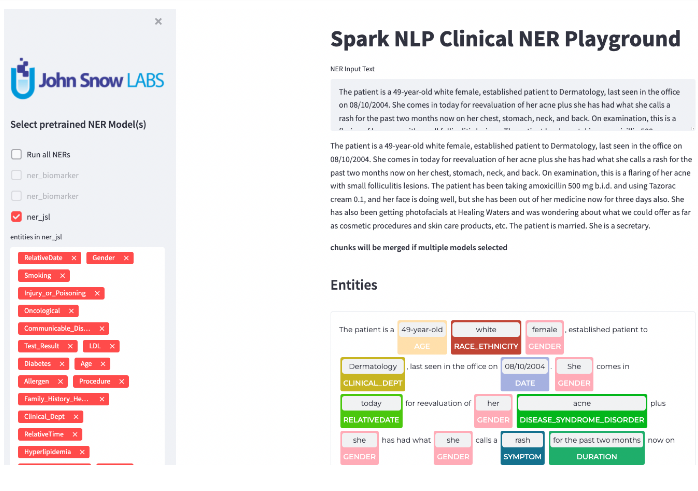

# 2.Rule Based NER

## ContextualParser

Spark NLP's `ContextualParser` is a licensed annotator that allows users to extract entities from a document based on pattern matching. It provides more functionality than its open-source counterpart `EntityRuler` by allowing users to customize specific characteristics for pattern matching. You're able to find entities using regex rules for full and partial matches, a dictionary with normalizing options and context parameters to take into account things such as token distances.

There are 3 components necessary to understand when using the `ContextualParser` annotator:

- **`ContextualParser` annotator's parameters**
Here are all the parameters available to use with the ContextualParserApproach
```
contextualParser = ContextualParserApproach() \
    .setInputCols(["sentence", "token"]) \
    .setOutputCol("entity") \
    .setCaseSensitive(True) \
    .setJsonPath("context_config.json") \
    .setPrefixAndSuffixMatch(True) \
    .setDictionary("dictionary.tsv", options=.    
                    {"orientation":"vertical"})
```

- **JSON configuration file** ContextualParser extracts entity from a document based on user defined rules. Rule matching is based on a RegexMatcher defined in a JSON file. It is set through the parameter `setJsonPath()`. In this JSON file, regex is defined that you want to match along with the information that will output on metadata field.

- **Dictionary** You can specify a path to a dictionary in tsv or csv format using the `setDictionary()` parameter. Using a dictionary is a useful when you have a list of exact words that you want the parser to pick up when processing some text.

For more details about the components(parameters, JSON and dictionary), please visit [this notebook](https://github.com/JohnSnowLabs/spark-nlp-workshop/blob/master/healthcare-nlp/09.0.Contextual_Parser_Rule_Based_NER.ipynb)

Now, we will create a dictionary and json file to build a sample `ContextualParser` pipeline to detect "gender" and "age" from given text. And merge their results with NER model which we will get only `DATE` and `LOCATION` labels.


In [ ]:
# Here's some sample text
sample_text = """The patient is a 28 years old female with a history of gestational diabetes mellitus was diagnosed in April 2002 in County Baptist Hospital .
                 3 years ago, he reported an episode of HTG-induced pancreatitis .
                 5 months old boy with repeated concussions."""

In [ ]:
# Create a dictionary to detect gender
gender = '''male,man,male,boy,gentleman,he,him
female,woman,female,girl,lady,old-lady,she,her
neutral,they,neutral,it'''

with open('gender.csv', 'w') as f:
    f.write(gender)

# Check what dictionary looks like
!cat gender.csv

male,man,male,boy,gentleman,he,him
female,woman,female,girl,lady,old-lady,she,her
neutral,they,neutral,it

In [ ]:
# Create JSON file for gender
gender = {
  "entity": "Gender",
  "ruleScope": "sentence",
  "completeMatchRegex": "true",
  "matchScope":"token"
}

import json
with open('gender.json', 'w') as f:
    json.dump(gender, f)

In [ ]:
# Create JSON file for age
age = {
  "entity": "Age",
  "ruleScope": "sentence",
  "matchScope":"token",
  "regex":"\\d{1,3}",
  "prefix":["age of", "age"],
  "suffix": ["-years-old", "years-old", "-year-old",
             "-months-old", "-month-old", "-months-old",
             "-day-old", "-days-old", "month old",
             "days old", "year old", "years old",
             "years", "year", "months", "old"],
  "contextLength": 25,
  "contextException": ["ago"],
  "exceptionDistance": 12
}

with open('age.json', 'w') as f:
    json.dump(age, f)

In [ ]:
# Build pipeline
document_assembler = nlp.DocumentAssembler() \
    .setInputCol("text") \
    .setOutputCol("document")

sentence_detector = nlp.SentenceDetector() \
    .setInputCols(["document"]) \
    .setOutputCol("sentence")

tokenizer = nlp.Tokenizer() \
    .setInputCols(["sentence"]) \
    .setOutputCol("token")

gender_contextual_parser = medical.ContextualParserApproach() \
    .setInputCols(["sentence", "token"]) \
    .setOutputCol("gender_chunk") \
    .setJsonPath("gender.json") \
    .setCaseSensitive(False) \
    .setDictionary('gender.csv', options={"delimiter":","}) \
    .setPrefixAndSuffixMatch(False)

age_contextual_parser = medical.ContextualParserApproach() \
    .setInputCols(["sentence", "token"]) \
    .setOutputCol("age_chunk") \
    .setJsonPath("age.json") \
    .setCaseSensitive(False) \
    .setPrefixAndSuffixMatch(False)

word_embeddings = nlp.WordEmbeddingsModel.pretrained("embeddings_clinical", "en", "clinical/models")\
    .setInputCols(["sentence", "token"])\
    .setOutputCol("embeddings")

deid_ner = medical.NerModel.pretrained("ner_deid_generic_augmented", "en", "clinical/models") \
    .setInputCols(["sentence", "token", "embeddings"]) \
    .setOutputCol("deid_ner")

deid_ner_converter = medical.NerConverterInternal() \
    .setInputCols(["sentence", "token", "deid_ner"]) \
    .setOutputCol("deid_ner_chunk")\
    .setWhiteList(["DATE", "LOCATION"])

# merge CP and NER model chunks
chunk_merger = medical.ChunkMergeApproach() \
    .setInputCols(["gender_chunk", "age_chunk", "deid_ner_chunk"]) \
    .setOutputCol("ner_chunk")

parserPipeline = nlp.Pipeline(stages=[
        document_assembler,
        sentence_detector,
        tokenizer,
        gender_contextual_parser,
        age_contextual_parser,
        word_embeddings,
        deid_ner,
        deid_ner_converter,
        chunk_merger
        ])

# Create a lightpipeline model
parserModel = parserPipeline.fit(spark.createDataFrame([[""]]).toDF("text"))
light_model = nlp.LightPipeline(parserModel)

embeddings_clinical download started this may take some time.
Approximate size to download 1.6 GB
[OK!]
ner_deid_generic_augmented download started this may take some time.
[OK!]


**In the metadata, `ner_source` is for showing the source of the entities.**

In [ ]:
# Annotate the sample text
annotations = light_model.fullAnnotate(sample_text)[0]

# Check outputs
annotations.get('ner_chunk')

[Annotation(chunk, 17, 18, 28, {'tokenIndex': '4', 'entity': 'Age', 'confidence': '0.74', 'field': 'Age', 'chunk': '0', 'normalized': '', 'sentence': '0'}, []),
 Annotation(chunk, 30, 35, female, {'tokenIndex': '7', 'entity': 'Gender', 'confidence': '0.50', 'field': 'Gender', 'chunk': '1', 'normalized': 'female', 'sentence': '0'}, []),
 Annotation(chunk, 102, 111, April 2002, {'entity': 'DATE', 'confidence': '0.99950004', 'ner_source': 'deid_ner_chunk', 'chunk': '2', 'sentence': '0'}, []),
 Annotation(chunk, 116, 138, County Baptist Hospital, {'entity': 'LOCATION', 'confidence': '0.97850007', 'ner_source': 'deid_ner_chunk', 'chunk': '3', 'sentence': '0'}, []),
 Annotation(chunk, 172, 173, he, {'tokenIndex': '4', 'entity': 'Gender', 'confidence': '0.50', 'field': 'Gender', 'chunk': '4', 'normalized': 'male', 'sentence': '1'}, []),
 Annotation(chunk, 242, 242, 5, {'tokenIndex': '0', 'entity': 'Age', 'confidence': '0.74', 'field': 'Age', 'chunk': '5', 'normalized': '', 'sentence': '2'}, [

In [ ]:
visualiser = nlp.viz.NerVisualizer()

visualiser.display(annotations, label_col='ner_chunk', document_col='document', save_path="display_result.html")

### Date of Birth Contextual Parser Model
This model is a ContextualParserModel that can extract date-of-birth (DOB) entities in clinical texts.

In [ ]:
document_assembler = nlp.DocumentAssembler() \
    .setInputCol("text") \
    .setOutputCol("document")

sentence_detector = nlp.SentenceDetectorDLModel.pretrained("sentence_detector_dl_healthcare","en","clinical/models")\
    .setInputCols(["document"])\
    .setOutputCol("sentence")

tokenizer = nlp.Tokenizer() \
    .setInputCols(["sentence"]) \
    .setOutputCol("token")

dob_contextual_parser = medical.ContextualParserModel.pretrained("date_of_birth_parser", "en", "clinical/models") \
    .setInputCols(["sentence", "token"]) \
    .setOutputCol("chunk_dob")

chunk_converter_dob = medical.ChunkConverter() \
    .setInputCols(["chunk_dob"]) \
    .setOutputCol("ner_chunk")

parserPipeline = nlp.Pipeline(stages=[
        document_assembler,
        sentence_detector,
        tokenizer,
        dob_contextual_parser,
        chunk_converter_dob
        ])

model = parserPipeline.fit(spark.createDataFrame([[""]]).toDF("text"))

result = model.transform(spark.createDataFrame([["""
Record date : 2081-01-04
DB : 11.04.1962
DT : 12-03-1978
DOD : 10.25.23

SOCIAL HISTORY:
She was born on Nov 04, 1962 in London and got married on 04/05/1979. When she got pregnant on 15 May 1079, the doctor wanted to verify her DOB was November 4, 1962. Her date of birth was confirmed to be 11-04-1962, the patient is 45 years old on 25 Sep 2007.

PROCEDURES:
Patient was evaluated on 1988-03-15 for allergies. She was seen by the endocrinology service and she was discharged on 9/23/1988.

MEDICATIONS
1. Coumadin 1 mg daily. Last INR was on August 14, 2007, and her INR was 2.3."""]]).toDF("text"))

sentence_detector_dl_healthcare download started this may take some time.
Approximate size to download 367.3 KB
[OK!]
date_of_birth_parser download started this may take some time.
[OK!]


In [ ]:
result.select(F.explode(F.arrays_zip(result.ner_chunk.result,
                                     result.ner_chunk.begin,
                                     result.ner_chunk.end,
                                     result.ner_chunk.metadata)).alias("cols")) \
      .select(F.expr("cols['3']['sentence']").alias("sentence_id"),
              F.expr("cols['0']").alias("chunk"),
              F.expr("cols['1']").alias("begin"),
              F.expr("cols['2']").alias("end"),
              F.expr("cols['3']['entity']").alias("ner_label")).show(truncate=False)

+-----------+----------------+-----+---+---------+
|sentence_id|chunk           |begin|end|ner_label|
+-----------+----------------+-----+---+---------+
|1          |11.04.1962      |31   |40 |DOB      |
|3          |Nov 04, 1962    |106  |117|DOB      |
|4          |November 4, 1962|238  |253|DOB      |
|5          |11-04-1962      |294  |303|DOB      |
+-----------+----------------+-----+---+---------+



### Unusual Pattern Usage

Medical text has a complex structure. Sometimes, our deid ner model mistakenly identifies certain entities as `dates`, such as test results or dimensions. In such cases, we utilize a rule-based NER (contextual parser).

In [ ]:
data = pd.DataFrame(
    {'text': [
        '''Mark White was born 06-20-1990. Mark White is 45 years old. Test Result: RHC 11-22-33, LHC 11\\22\\33, Wedge 11-16-1972.''',
        '''John was born on 07-25-2000 and he was discharged on 03/15/2022. Test Result: RV 26/2. Left Ventricle 26-2.  Wedge 11/16/19.''',
        '''John Moore was born 03/20/2012 and he is 18 years old. Test Result: Pulmonary Artery 07\\31\\19 ( PA 07/31/19 ).'''
]})

# pre-process text
#data['text'].replace('\\', '\\\\', inplace=True)

In [ ]:
# convert data for Spark processing
input_df = spark.createDataFrame(data)
input_df.show(truncate=False)

+----------------------------------------------------------------------------------------------------------------------------+
|text                                                                                                                        |
+----------------------------------------------------------------------------------------------------------------------------+
|Mark White was born 06-20-1990. Mark White is 45 years old. Test Result: RHC 11-22-33, LHC 11\22\33, Wedge 11-16-1972.      |
|John was born on 07-25-2000 and he was discharged on 03/15/2022. Test Result: RV 26/2. Left Ventricle 26-2.  Wedge 11/16/19.|
|John Moore was born 03/20/2012 and he is 18 years old. Test Result: Pulmonary Artery 07\31\19 ( PA 07/31/19 ).              |
+----------------------------------------------------------------------------------------------------------------------------+



In [ ]:
import json
# create JSON file for test result patterns (to be used with ContextualizedParser)
test_result_rules = {
    'entity': 'test_result',
    'ruleScope': 'sentence',
    'matchScope': 'token',
    'regex': '(\d{2}.?\d{2}.?\d{2})|(\d{2}.?\d{2}.?\d{4})|(\d{2}.?\d{1})',
    'prefix': ['Right atrium', 'RA',
               'Left atrium', 'LA',
               'Wedge', "Catheterization",
               'Right Heart Catheterization', 'RHC',
               'Left Heart Catheterization', 'LHC',
               'PA', 'pulmonary artery',
               'RV', 'right ventricle'],
    'suffix': ['.', ','],
    'contextLength': 45,
    'completeMatchRegex': 'true',
    "contextException": ["born",  "on"],
    "exceptionDistance":10,
}

with open('test_result_rules.json', 'w', encoding='utf-8') as f:
    json.dump(test_result_rules, f, ensure_ascii=False, indent=4)

In [ ]:
embeddings = nlp.WordEmbeddingsModel\
    .pretrained("embeddings_clinical", "en", "clinical/models")\
    .setInputCols(["sentence", "token"])\
    .setOutputCol("word_embeddings")

# identify test results
test_contextual_parser = medical.ContextualParserApproach() \
    .setInputCols(['sentence', 'token']) \
    .setOutputCol('test_result') \
    .setJsonPath('test_result_rules.json') \
    .setCaseSensitive(False) \
    .setPrefixAndSuffixMatch(True) \
    .setShortestContextMatch(True) \
    .setOptionalContextRules(False)

test_contextual_parser_converter = medical.ChunkConverter() \
    .setInputCols(['test_result']) \
    .setOutputCol('test_result_chunk')

# Deid NER
deid_ner = medical.NerModel \
    .pretrained('ner_deid_subentity_augmented', 'en', 'clinical/models') \
    .setInputCols(['sentence', 'token', 'word_embeddings']) \
    .setOutputCol('deid_ner')

deid_ner_converter = medical.NerConverterInternal() \
    .setInputCols(['sentence', 'token', 'deid_ner']) \
    .setOutputCol('deid_ner_chunk') \
    .setWhiteList(['date'])

# merge
chunk_merger = medical.ChunkMergeApproach() \
    .setInputCols(['test_result_chunk', 'deid_ner_chunk']) \
    .setOutputCol('ner_chunk') \
    .setMergeOverlapping(True)

parserPipeline = nlp.Pipeline().setStages([
    document_assembler,
    sentence_detector,
    tokenizer,
    embeddings,
    test_contextual_parser,
    test_contextual_parser_converter,
    deid_ner,
    deid_ner_converter,
    chunk_merger,
])

empty_data = spark.createDataFrame([[""]]).toDF("text")

pipeline_model = parserPipeline.fit(empty_data)

embeddings_clinical download started this may take some time.
Approximate size to download 1.6 GB
[OK!]
ner_deid_subentity_augmented download started this may take some time.
[OK!]


In [ ]:
output = pipeline_model.transform(input_df)

In [ ]:
def process_output(result_col, chunk_alias, output):

    output.select(F.explode(F.arrays_zip(output[result_col].result,
                                         output[result_col].begin,
                                         output[result_col].end,
                                         output[result_col].metadata,)).alias("cols")) \
          .select(F.expr("cols['0']").alias(chunk_alias),
                  F.expr("cols['1']").alias("begin"),
                  F.expr("cols['2']").alias("end"),
                  F.expr("cols['3']['entity']").alias("entity"),
                  F.expr("cols['3']['confidence']").alias("confidence")) \
          .show(50, truncate=False)


In [ ]:
from google.colab import widgets
t = widgets.TabBar(["ner_deid_result","contextual_text_result","merged_ner_result"])

with t.output_to(0):

    process_output("deid_ner_chunk", "deid_ner_chunk",output)

with t.output_to(1):

    process_output("test_result_chunk", "contextual_ner_chunk", output)

with t.output_to(2):

    process_output("ner_chunk", "merged_ner_chunk", output)



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

+----------------+-----+---+-----------+----------+
|merged_ner_chunk|begin|end|entity     |confidence|
+----------------+-----+---+-----------+----------+
|06-20-1990      |20   |29 |DATE       |0.9677    |
|11-22-33        |77   |84 |test_result|0.74      |
|11\22\33        |91   |98 |test_result|0.66      |
|11-16-1972      |107  |116|test_result|0.57      |
|07-25-2000      |17   |26 |DATE       |0.987     |
|03/15/2022      |53   |62 |DATE       |1.0       |
|26/2            |81   |84 |test_result|0.74      |
|11/16/19        |115  |122|test_result|0.73      |
|03/20/2012      |20   |29 |DATE       |0.9998    |
|07\31\19        |85   |92 |test_result|0.66      |
|07/31/19        |99   |106|test_result|0.59      |
+----------------+-----+---+-----------+----------+



<IPython.core.display.Javascript object>

In [ ]:
from google.colab import widgets
t = widgets.TabBar(["deid_ner_result","contextual_result","merged_ner_result"])

from sparknlp_display import NerVisualizer
visualiser = NerVisualizer()

results = output.collect()

with t.output_to(0):
    for i in range(len(results)):
        visualiser.display(results[i], label_col= 'deid_ner_chunk')

with t.output_to(1):
    for i in range(len(results)):
        visualiser.display(results[i], label_col= 'test_result_chunk')

with t.output_to(2):
    for i in range(len(results)):
        visualiser.display(results[i], label_col= 'ner_chunk')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Regex Matcher

The **`RegexMatcher`** class implements an  annotator approach to match a set of regular expressions with a provided entity. This approach is utilized for associating specific patterns within text data with predetermined entities, such as dates, mentioned within the text.

The class allows users to define rules using regular expressions paired with entities, offering flexibility in customization. These rules can either be directly set using the `setRules` method, with a specified delimiter, or loaded from an external file using the `setExternalRules` method.

Additionally, users can specify parameters such as the matching strategy (`MATCH_FIRST`, `MATCH_ALL`, or `MATCH_COMPLETE`) to control how matches are handled. The output annotation type is `CHUNK`, with input annotation types supporting `DOCUMENT`. This class provides a versatile tool for implementing entity recognition based on user-defined patterns within text data.


A rule consists of a regex pattern and an identifier, delimited by a character of choice. An example could be `"\\d{4}\\/\\d\\d\\/\\d\\d,date"` which will match strings like `"1970/01/01"` to the identifier `"date"`.

For more details please see [Rule_Based_Entity_Matchers](https://github.com/JohnSnowLabs/spark-nlp-workshop/blob/master/healthcare-nlp/01.6.Rule_Based_Entity_Matchers.ipynb) notebook.

**Parameters**:

- `strategy`: Can be either `MATCH_FIRST`, `MATCH_ALL`, `MATCH_COMPLETE`, by default `MATCH_ALL`.
- `rules`: Regex rules to match the identifier with.
- `delimiter`: Delimiter for rules provided with setRules.
- `externalRules`: external resource to rules, needs `delimiter` in options.

### IP and DATE

In [ ]:
text = """Name : Hendrickson, Ora, Record date: 2093-01-13, MR #719435.
Dr. John Green, ID: 1231511863, IP 203.120.223.13
He is a 60-year-old male was admitted to the Day Hospital for cystectomy on 01/13/93
Patient's VIN : 1HGBH41JXMN109286, SSN #333-44-6666, Driver's license no: A334455B.
Phone (302) 786-5227, 0295 Keats Street, San Francisco, E-MAIL: smith@gmail.com."""

data = spark.createDataFrame([[text]]).toDF("text")

In [ ]:
!mkdir -p rules

rules = '''
(\d{1,3}\.){3}\d{1,3}~IPADDR
\d{4}-\d{2}-\d{2}|\d{2}/\d{2}/\d{2}|\d{2}/\d{2}/\d{2}~DATE
'''

with open('./rules/regex_rules.txt', 'w') as f:
    f.write(rules)

In [ ]:
document_assembler = nlp.DocumentAssembler()\
    .setInputCol("text")\
    .setOutputCol("document")

regex_matcher = medical.RegexMatcher()\
    .setInputCols('document')\
    .setStrategy("MATCH_ALL")\
    .setOutputCol("regex_matches")\
    .setExternalRules(path='./rules/regex_rules.txt', delimiter='~')

nlpPipeline = nlp.Pipeline(
    stages=[
        document_assembler,
        regex_matcher
])

result = nlpPipeline.fit(data).transform(data)

In [ ]:
result.select('regex_matches.result','regex_matches.metadata').show(truncate=70)

+--------------------------------------+----------------------------------------------------------------------+
|                                result|                                                              metadata|
+--------------------------------------+----------------------------------------------------------------------+
|[2093-01-13, 203.120.223.13, 01/13/93]|[{entity -> DATE, chunk -> 0, sentence -> 0}, {entity -> IPADDR, ch...|
+--------------------------------------+----------------------------------------------------------------------+



In [ ]:
result_df = result.select(F.explode(F.arrays_zip(result.regex_matches.result,
                                                 result.regex_matches.begin,
                                                 result.regex_matches.end,
                                                 result.regex_matches.metadata)).alias("cols"))\
                  .select(F.expr("cols['0']").alias("regex_result"),
                          F.expr("cols['1']").alias("begin"),
                          F.expr("cols['2']").alias("end"),
                          F.expr("cols['3']['entity']").alias("ner_label"))
result_df.show()

+--------------+-----+---+---------+
|  regex_result|begin|end|ner_label|
+--------------+-----+---+---------+
|    2093-01-13|   38| 47|     DATE|
|203.120.223.13|   97|110|   IPADDR|
|      01/13/93|  188|195|     DATE|
+--------------+-----+---+---------+



## Text Matcher

In this section, we will examine the `TextMatcher` annotator and its model version `TextMatcherModel`.

This annotator match exact phrases provided in a file against a
Document.


For more details please see [Rule_Based_Entity_Matchers](https://github.com/JohnSnowLabs/spark-nlp-workshop/blob/master/healthcare-nlp/01.6.Rule_Based_Entity_Matchers.ipynb) notebook.


** Parameters**


- `setEntities` *(str)*: Sets the external resource for the entities.
        path : str
            Path to the external resource
        read_as : str, optional
            How to read the resource, by default ReadAs.TEXT
        options : dict, optional
            Options for reading the resource, by default {"format": "text"}
- `setCaseSensitive` *(Boolean)*: Sets whether to match regardless of case. (Default: True)

- `setMergeOverlapping` *(Boolean)*:Sets whether to merge overlapping matched chunks. (Default: False)

- `setEntityValue` *(str)*: Sets the value for the entity metadata field. If any entity value isn't set in the file, we need to set it for the entity value.

- `setBuildFromTokens` *(Boolean)*:  Sets whether the TextMatcher  should take the CHUNK from TOKEN.

- `setDelimiter` *(str)*:  Sets Value for the delimiter between Phrase, Entity.





### How to Use `TextMatcher`

First of all, we should create a source file that includes all the chunks or tokens we need to capture. In the example below, we use `#` as a delimiter to separate the label and entity. So we need to set parameter like this `setDelimiter('#')`.

In [ ]:
matcher_drug = """
Aspirin 100mg#Drug
aspirin#Drug
paracetamol#Drug
amoxicillin#Drug
ibuprofen#Drug
lansoprazole#Drug
"""

with open ('matcher_drug.csv', 'w') as f:
  f.write(matcher_drug)

In [ ]:
documentAssembler = nlp.DocumentAssembler()\
    .setInputCol("text")\
    .setOutputCol("document")

tokenizer = nlp.Tokenizer()\
    .setInputCols(["document"])\
    .setOutputCol("token")

entityExtractor = medical.TextMatcher()\
    .setInputCols(["document", "token"])\
    .setEntities("matcher_drug.csv")\
    .setOutputCol("matched_text")\
    .setCaseSensitive(False)\
    .setDelimiter("#")\
    .setMergeOverlapping(False)

mathcer_pipeline = nlp.Pipeline().setStages([
                  documentAssembler,
                  tokenizer,
                  entityExtractor])

data = spark.createDataFrame([["John's doctor prescribed aspirin 100mg for his heart condition, along with paracetamol for his fever, amoxicillin for his tonsilitis, ibuprofen for his inflammation, and lansoprazole for his GORD."]]).toDF("text")

result = mathcer_pipeline.fit(data).transform(data)

In [ ]:
result.select(F.explode(F.arrays_zip(
              result.matched_text.result,
              result.matched_text.begin,
              result.matched_text.end,
              result.matched_text.metadata,)).alias("cols"))\
      .select(F.expr("cols['0']").alias("chunk"),
              F.expr("cols['1']").alias("begin"),
              F.expr("cols['2']").alias("end"),
              F.expr("cols['3']['entity']").alias('label')).show(truncate=70)

+-------------+-----+---+-----+
|        chunk|begin|end|label|
+-------------+-----+---+-----+
|      aspirin|   25| 31| Drug|
|aspirin 100mg|   25| 37| Drug|
|  paracetamol|   75| 85| Drug|
|  amoxicillin|  102|112| Drug|
|    ibuprofen|  134|142| Drug|
| lansoprazole|  170|181| Drug|
+-------------+-----+---+-----+



As you see above mather_drug file includes two similar entities aspirin and aspirin 100mg and our text includes both of them So if you want to see both of them you need to set `MergeOverlapping` parameter as `False`. You can look at the below example.

In [ ]:
entityExtractor = medical.TextMatcher()\
    .setInputCols(["document", "token"])\
    .setEntities("matcher_drug.csv") \
    .setOutputCol("matched_text")\
    .setDelimiter("#")\
    .setCaseSensitive(False)\
    .setMergeOverlapping(False)

mathcer_pipeline = nlp.Pipeline().setStages([
                  documentAssembler,
                  tokenizer,
                  entityExtractor])

result = mathcer_pipeline.fit(data).transform(data)

In [ ]:
result.select(F.explode(F.arrays_zip(
              result.matched_text.result,
              result.matched_text.begin,
              result.matched_text.end,
              result.matched_text.metadata,)).alias("cols"))\
      .select(F.expr("cols['0']").alias("chunk"),
              F.expr("cols['1']").alias("begin"),
              F.expr("cols['2']").alias("end"),
              F.expr("cols['3']['entity']").alias('label')).show(truncate=70)

+-------------+-----+---+-----+
|        chunk|begin|end|label|
+-------------+-----+---+-----+
|      aspirin|   25| 31| Drug|
|aspirin 100mg|   25| 37| Drug|
|  paracetamol|   75| 85| Drug|
|  amoxicillin|  102|112| Drug|
|    ibuprofen|  134|142| Drug|
| lansoprazole|  170|181| Drug|
+-------------+-----+---+-----+



When we set the `CaseSensitive` parameter to `True`, it means we're considering the case sensitivity of chunks in the source file. Consequently, some chunks may not be visible due to differences in their case compared to the source file.

In [ ]:
entityExtractor = medical.TextMatcher()\
    .setInputCols(["document", "token"])\
    .setEntities("matcher_drug.csv") \
    .setOutputCol("matched_text")\
    .setDelimiter("#")\
    .setCaseSensitive(True)\
    .setMergeOverlapping(False)

mathcer_pipeline = nlp.Pipeline().setStages([
                  documentAssembler,
                  tokenizer,
                  entityExtractor])

matcher_model = mathcer_pipeline.fit(data)
result = matcher_model.transform(data)

In [ ]:
result.select(F.explode(F.arrays_zip(
              result.matched_text.result,
              result.matched_text.begin,
              result.matched_text.end,
              result.matched_text.metadata,)).alias("cols"))\
      .select(F.expr("cols['0']").alias("chunk"),
              F.expr("cols['1']").alias("begin"),
              F.expr("cols['2']").alias("end"),
              F.expr("cols['3']['entity']").alias('label')).show(truncate=70)

+------------+-----+---+-----+
|       chunk|begin|end|label|
+------------+-----+---+-----+
|     aspirin|   25| 31| Drug|
| paracetamol|   75| 85| Drug|
| amoxicillin|  102|112| Drug|
|   ibuprofen|  134|142| Drug|
|lansoprazole|  170|181| Drug|
+------------+-----+---+-----+



## Entity Ruler

This section will cover the different parameter and usage of **EntityRuler**. There are 2 annotators to perform this task in Spark NLP; `EntityRulerApproach` and `EntityRulerModel`. <br/>

This annotator match exact strings or regex patterns provided in a file against a Document and assigns them an named entity. The definitions can contain any number of named entities.


For more details please see [Rule_Based_Entity_Matchers](https://github.com/JohnSnowLabs/spark-nlp-workshop/blob/master/healthcare-nlp/01.6.Rule_Based_Entity_Matchers.ipynb) notebook.

There are multiple ways and formats to set the extraction resource. It is
   possible to set it either as a "JSON", "JSONL" or "CSV" file. A path to the
   file needs to be provided to ``setPatternsResource``. The file format needs
   to be set as the "format" field in the ``option`` parameter map and
   depending on the file type, additional parameters might need to be set.

- `setPatternsResource` *(str)*: Sets Resource in JSON or CSV format to map entities to patterns.
        path : str
            Path to the resource
        read_as : str, optional
            How to interpret the resource, by default ReadAs.TEXT
        options : dict, optional
            Options for parsing the resource, by default {"format": "JSON"}

- `setSentenceMatch` *(Boolean)*:Whether to find match at sentence level. True: sentence level. False: token level.

- `setAlphabetResource` *(str)*:  Alphabet Resource (a simple plain text with all language characters)

- `setUseStorage` *(Boolean)*:  Sets whether to use RocksDB storage to serialize patterns.





### Keywords Patterns

EntityRuler will handle the chunks output based on the patterns defined, as shown in the example below. We can define an id field to identify entities.

In [ ]:
import json

data = [

    {
        "id": "drug-words",
        "label": "Drug",
        "patterns": ["paracetamol", "aspirin", "ibuprofen", "lansoprazol"]
    },
    {
        "id": "disease-words",
        "label": "Disease",
        "patterns": ["heart condition","tonsilitis","GORD"]
    },
        {
        "id": "symptom-words",
        "label": "Symptom",
        "patterns": ["fever","headache"]
    },

]

with open("entities.json", "w") as f:
    json.dump(data, f)

In [ ]:
documentAssembler = nlp.DocumentAssembler()\
    .setInputCol("text")\
    .setOutputCol("document")

tokenizer = nlp.Tokenizer()\
    .setInputCols(["document"])\
    .setOutputCol("token")

entityRuler = medical.EntityRulerApproach()\
    .setInputCols(["document", "token"])\
    .setOutputCol("entities")\
    .setPatternsResource("entities.json")\
    .setCaseSensitive(False)\

pipeline = nlp.Pipeline().setStages([
    documentAssembler,
    tokenizer,
    entityRuler
])

data = spark.createDataFrame([['''John's doctor prescribed aspirin for his heart condition, along with paracetamol for his fever and headache, amoxicillin for his tonsilitis, ibuprofen for his inflammation, and lansoprazole for his GORD on 2023-12-01.''']]).toDF("text")


result = pipeline.fit(data).transform(data)

Checking the results:

In [ ]:
result.select(F.explode(F.arrays_zip(result.entities.result,
                                      result.entities.begin,
                                      result.entities.end,
                                      result.entities.metadata,)).alias("cols"))\
      .select(F.expr("cols['0']").alias("chunk"),
              F.expr("cols['1']").alias("begin"),
              F.expr("cols['2']").alias("end"),
              F.expr("cols['3']['entity']").alias('label')).show(truncate=30)

+---------------+-----+---+-------+
|          chunk|begin|end|  label|
+---------------+-----+---+-------+
|        aspirin|   25| 31|   Drug|
|heart condition|   41| 55|Disease|
|    paracetamol|   69| 79|   Drug|
|          fever|   89| 93|Symptom|
|       headache|   99|106|Symptom|
|     tonsilitis|  129|138|Disease|
|      ibuprofen|  141|149|   Drug|
|    lansoprazol|  177|187|   Drug|
|           GORD|  198|201|Disease|
+---------------+-----+---+-------+



# 3.Clinical Assertion Status

The deep neural network architecture for assertion status detection in Spark NLP is based on a Bi-LSTM framework, and is a modified version of the architecture proposed by Federico Fancellu, Adam Lopez and Bonnie Webber ([Neural Networks For Negation Scope Detection](https://aclanthology.org/P16-1047.pdf)). Its goal is to classify the assertions made on given medical concepts as being present, absent, or possible in the patient, conditionally present in the patient under certain circumstances,
hypothetically present in the patient at some future point, and
mentioned in the patient report but associated with someoneelse.
In the proposed implementation, input units depend on the
target tokens (a named entity) and the neighboring words that
are explicitly encoded as a sequence using word embeddings.
Similar to paper mentioned above,  it is observed that that 95% of the scope tokens (neighboring words) fall in a window of 9 tokens to the left and 15
to the right of the target tokens in the same dataset. Therefore, the same window size was implemented and it following parameters were used: learning
rate 0.0012, dropout 0.05, batch size 64 and a maximum sentence length 250. The model has been implemented within
Spark NLP as an annotator called AssertionDLModel. After
training 20 epoch and measuring accuracy on the official test
set, this implementation exceeds the latest state-of-the-art
accuracy benchmarks as summarized as following table:

|Assertion Label|Spark NLP|Latest Best|
|-|-|-|
|Absent       |0.944 |0.937|
|Someone-else |0.904|0.869|
|Conditional  |0.441|0.422|
|Hypothetical |0.862|0.890|
|Possible     |0.680|0.630|
|Present      |0.953|0.957|
|micro F1     |0.939|0.934|


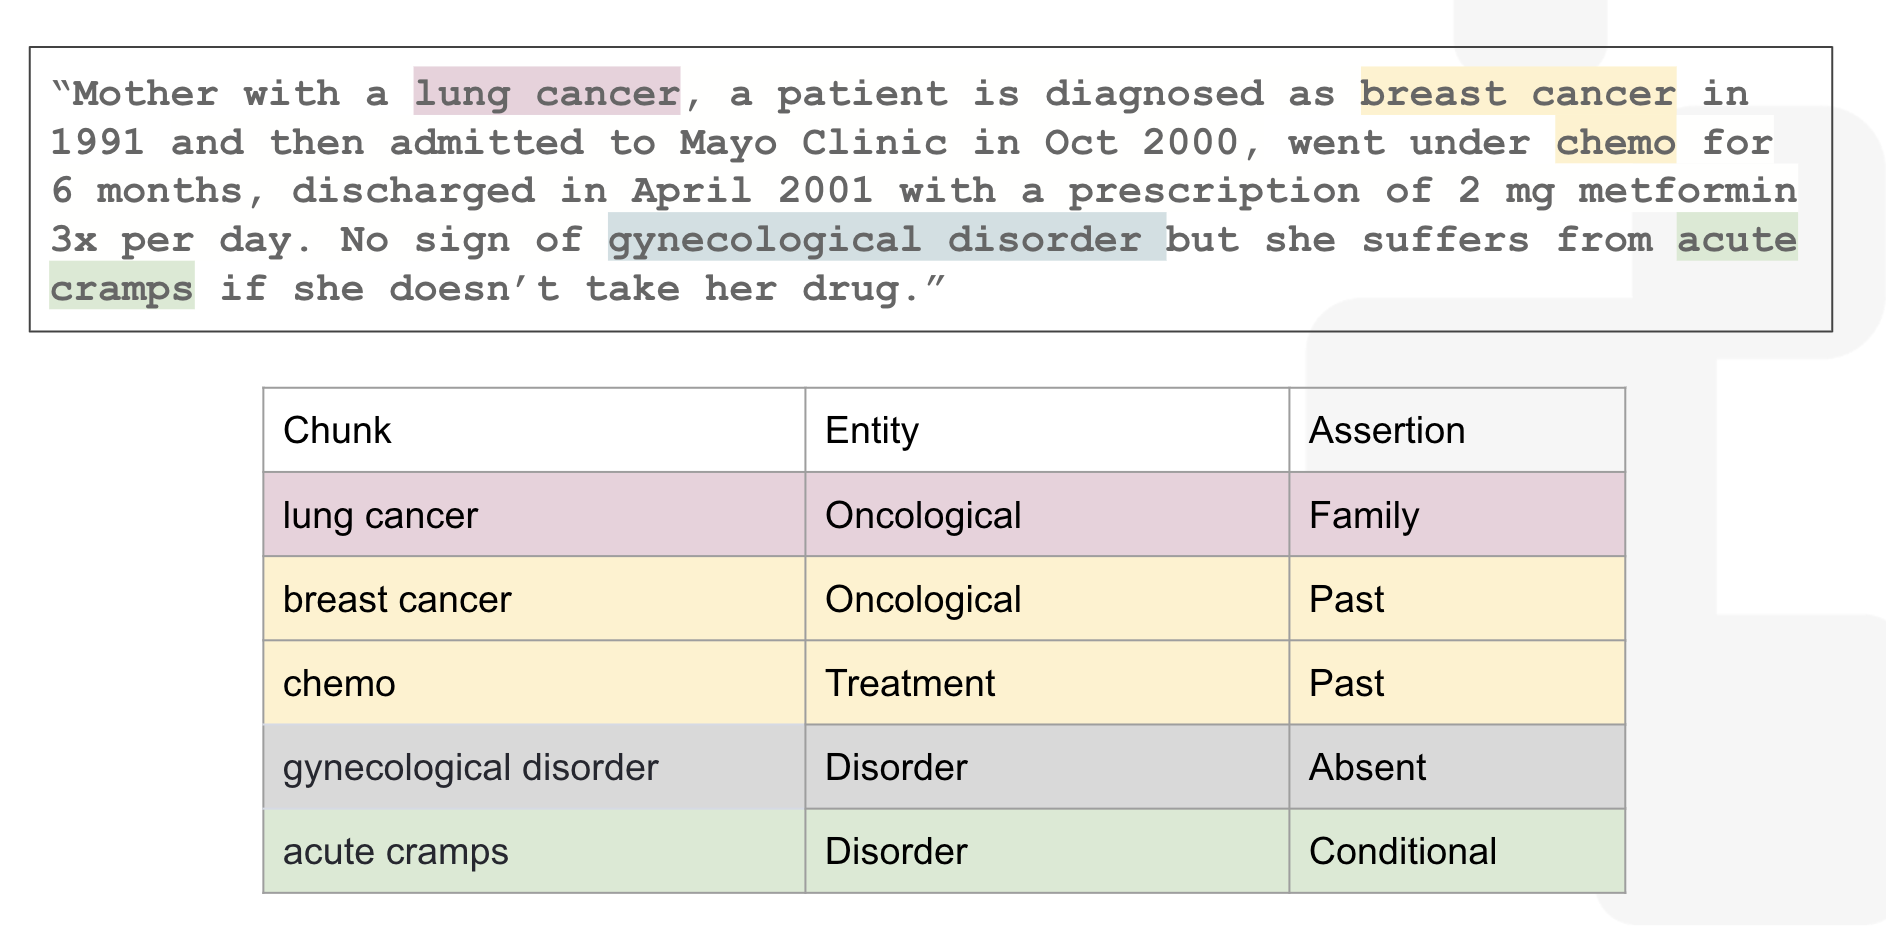

### Pretrained Assertion Status Models

|    | model_name              |Predicted Entities|
|---:|:------------------------|-|
|  1 | [assertion_dl](https://nlp.johnsnowlabs.com/2021/01/26/assertion_dl_en.html)            |Present, Absent, Possible, conditional, hypothetical, associated_with_someone_else|
|  2 | [assertion_dl_biobert](https://nlp.johnsnowlabs.com/2021/01/26/assertion_dl_biobert_en.html)    |Present, Absent, Possible, conditional, hypothetical, associated_with_someone_else|
|  3 | [assertion_dl_healthcare](https://nlp.johnsnowlabs.com/2020/09/23/assertion_dl_healthcare_en.html) |Present, Absent, Possible, conditional, hypothetical, associated_with_someone_else|
|  4 | [assertion_dl_large](https://nlp.johnsnowlabs.com/2020/05/21/assertion_dl_large_en.html)      |Present, Absent, Possible, conditional, hypothetical, associated_with_someone_else|
|  5 | [assertion_dl_radiology](https://nlp.johnsnowlabs.com/2021/03/18/assertion_dl_radiology_en.html)   |Confirmed, Suspected, Negative|
|  6 | [assertion_jsl](https://nlp.johnsnowlabs.com/2021/07/24/assertion_jsl_en.html)           |Present, Absent, Possible, Planned, Someoneelse, Past, Family, Hypotetical|
|  7 | [assertion_jsl_large](https://nlp.johnsnowlabs.com/2021/07/24/assertion_jsl_large_en.html)     |present, absent, possible, planned, someoneelse, past, hypothetical|
|  8 |  [assertion_ml](https://nlp.johnsnowlabs.com/2020/01/30/assertion_ml_en.html) |Hypothetical, Present, Absent, Possible, Conditional, Associated_with_someone_else|
|  9 | [assertion_dl_scope_L10R10](https://nlp.johnsnowlabs.com/2022/03/17/assertion_dl_scope_L10R10_en_3_0.html)| hypothetical, associated_with_someone_else, conditional, possible, absent, present|
| 10 | [assertion_dl_biobert_scope_L10R10](https://nlp.johnsnowlabs.com/2022/03/24/assertion_dl_biobert_scope_L10R10_en_2_4.html)| hypothetical, associated_with_someone_else, conditional, possible, absent, present|
| 11 | [assertion_jsl_augmented](https://nlp.johnsnowlabs.com/2022/09/15/assertion_jsl_augmented_en.html)| Present, Absent, Possible, Planned, Past, Family, Hypotetical, SomeoneElse|






### Oncology Assertion Models

|    | model_name              |Predicted Entities|
|---:|:------------------------|-|
| 1 | [assertion_oncology](https://nlp.johnsnowlabs.com/2024/07/03/assertion_oncology_en.html) | Absent, Family, Hypothetical, Past, Possible, Present|
| 2 | [assertion_oncology_problem](https://nlp.johnsnowlabs.com/2024/07/03/assertion_oncology_problem_en.html) |Family_History, Hypothetical_Or_Absent, Medical_History, Possible|
| 3 | [assertion_oncology_test_binary](https://nlp.johnsnowlabs.com/2024/07/03/assertion_oncology_treatment_binary_en.html) |Hypothetical_Or_Absent, Present_Or_Past|
| 4 | [assertion_oncology_response_to_treatment](https://nlp.johnsnowlabs.com/2024/07/03/assertion_oncology_response_to_treatment_en.html) |Hypothetical_Or_Absent, Present_Or_Past|
| 5 | [assertion_oncology_test_binary](https://nlp.johnsnowlabs.com/2024/07/03/assertion_oncology_test_binary_en.html) |Hypothetical_Or_Absent, Medical_History|
| 6 | [assertion_oncology_smoking_status](https://nlp.johnsnowlabs.com/2024/07/03/assertion_oncology_smoking_status_en.html) |Absent, Past, Present|
| 7 | [assertion_oncology_family_history](https://nlp.johnsnowlabs.com/2024/07/03/assertion_oncology_family_history_en.html) |Family_History, Other|
| 8 | [assertion_oncology_demographic_binary](https://nlp.johnsnowlabs.com/2024/07/03/assertion_oncology_demographic_binary_en.html) |Patient, Someone_Else|

### Voice of Patient Assertion Models



| **Index** | **VOP Assertion Models**        |
|---------------|----------------------|
| 1        | [assertion_vop_clinical](https://nlp.johnsnowlabs.com/2023/08/17/assertion_vop_clinical_en.html)     |
| 2          | [assertion_vop_clinical_medium](https://nlp.johnsnowlabs.com/2023/08/17/assertion_vop_clinical_medium_en.html)       |
| 3          | [assertion_vop_clinical_large](https://nlp.johnsnowlabs.com/2023/08/17/assertion_vop_clinical_large_en.html)       |
|||



### Social Determinant of Health Models


| **Index** | **VOP Assertion Models**        |
|---------------|----------------------|
| 1        | [assertion_sdoh_wip](https://nlp.johnsnowlabs.com/2023/08/13/assertion_sdoh_wip_en.html)     |


Let's start to create a Pipeline in order to detect assertion status with `assertion_jsl_augmented` pretrained model. <br/>
This model detects following assertion status;
`Absent`, `Present`, `Past`, `Family`, `Planned`, `SomeoneElse`, `Hypotetical`, `Possible`.

And we will use **`AssertionFilterer`** for filtering out the NERs by the list of acceptable assertion statuses. This annotator would be quite handy if you want to set a white list for the acceptable assertion statuses like `Present` or `Planned`; and do not want `Absent` conditions get out of your pipeline.

In [ ]:
documentAssembler = nlp.DocumentAssembler()\
    .setInputCol("text")\
    .setOutputCol("document")

sentenceDetector = nlp.SentenceDetector()\
    .setInputCols(["document"])\
    .setOutputCol("sentence")

tokenizer = nlp.Tokenizer()\
    .setInputCols(["sentence"])\
    .setOutputCol("token")

word_embeddings = nlp.WordEmbeddingsModel.pretrained("embeddings_clinical", "en", "clinical/models")\
    .setInputCols(["sentence", "token"])\
    .setOutputCol("embeddings")

clinical_ner = medical.NerModel.pretrained("ner_clinical", "en", "clinical/models") \
    .setInputCols(["sentence", "token", "embeddings"]) \
    .setOutputCol("clinical_ner")

clinical_ner_converter = medical.NerConverterInternal() \
    .setInputCols(["sentence", "token", "clinical_ner"]) \
    .setOutputCol("clinical_ner_chunk")


# Assertion model trained on i2b2 (sampled from MIMIC) dataset
clinical_assertion = medical.AssertionDLModel.pretrained("assertion_jsl_augmented", "en", "clinical/models") \
    .setInputCols(["sentence", "clinical_ner_chunk", "embeddings"]) \
    .setOutputCol("assertion")\
    # .setScopeWindow([9,15]) # default [9,15]

# filter out the named entities by the list of acceptable assertion statuses. Present here.
assertion_filterer = medical.AssertionFilterer()\
    .setInputCols("sentence","clinical_ner_chunk","assertion")\
    .setOutputCol("assertion_filtered")\
    .setCaseSensitive(False)\
    .setWhiteList(["Present"])
    #or .setBlackList([["absent"]])

assertionPipeline = nlp.Pipeline(stages=[
    documentAssembler,
    sentenceDetector,
    tokenizer,
    word_embeddings,
    clinical_ner,
    clinical_ner_converter,
    clinical_assertion,
    assertion_filterer
    ])


assertion_model = assertionPipeline.fit(spark.createDataFrame([[""]]).toDF("text"))

embeddings_clinical download started this may take some time.
Approximate size to download 1.6 GB
[OK!]
ner_clinical download started this may take some time.
[OK!]
assertion_jsl_augmented download started this may take some time.
[OK!]


Creating example dataframe with sample text and check the results


In [ ]:
#text = """
#Patient with severe fever and sore throat also suffers from pain.
#He shows no stomach pain and he maintained on an epidural and PCA for pain control.
#He also become short of breath with climbing a flight of stairs.
#After CT, lung tumor located at the right lower lobe. Father with Alzheimer.
#"""

text = 'Patient has a headache for the last 2 weeks, needs to get a head CT, and appears anxious when she walks fast. Alopecia noted. She denies pain.'


data = spark.createDataFrame([[text]]).toDF("text")

# fit/transform and show
results = assertion_model.transform(data)
results.show()

+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|                text|            document|            sentence|               token|          embeddings|        clinical_ner|  clinical_ner_chunk|           assertion|  assertion_filtered|
+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|Patient has a hea...|[{document, 0, 14...|[{document, 0, 10...|[{token, 0, 6, Pa...|[{word_embeddings...|[{named_entity, 0...|[{chunk, 12, 21, ...|[{assertion, 12, ...|[{chunk, 12, 21, ...|
+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+



In [ ]:
results.select(F.explode(F.arrays_zip(results.clinical_ner_chunk.result,
                                      results.clinical_ner_chunk.metadata,
                                      results.assertion.result)).alias("cols"))\
       .select(F.expr("cols['0']").alias("ner_chunk"),
               F.expr("cols['1']['entity']").alias("entities"),
               F.expr("cols['2']").alias("assertion")).show(truncate=False)

+----------+--------+------------+
|ner_chunk |entities|assertion   |
+----------+--------+------------+
|a headache|PROBLEM |Present     |
|a head CT |TEST    |Hypothetical|
|anxious   |PROBLEM |Possible    |
|Alopecia  |PROBLEM |Present     |
|pain      |PROBLEM |Absent      |
+----------+--------+------------+



#### Assertion Filterer Results

In [ ]:
assertion_filterer.getWhiteList()

['Present']

Here are our filtered (only present assertions) chunks;

In [ ]:
results.select("assertion_filtered.result").show(truncate=False)

+----------------------+
|result                |
+----------------------+
|[a headache, Alopecia]|
+----------------------+



As you see above, there is no **"a head C"**, **"anxious"** and **"pain"** in filtered results

### Assertion Visualizer

Also, we can visualize the assertion results by using `AssertionVisualizer` of Sparknlp-Display library.

Now, we will create a LightPipeline with our existing model and visualize the results.

In [ ]:
light_model = nlp.LightPipeline(assertion_model)
light_result = light_model.fullAnnotate(text)[0]

vis = nlp.viz.AssertionVisualizer()
vis.display(light_result, 'clinical_ner_chunk', 'assertion')

### Train a Custom Assertion Model

In this section, we will train a custom assertion model. <br/>

Firstly, download a sample dataset for training.

In [ ]:
!wget -q https://raw.githubusercontent.com/JohnSnowLabs/spark-nlp-workshop/master/healthcare-nlp/data/i2b2_assertion_sample_short.csv

In [ ]:
import pandas as pd

In [ ]:
assertion_df = spark.read.option("header", True).option("inferSchema", "True").csv("i2b2_assertion_sample_short.csv")
assertion_df.show(5, truncate=100)

+-----------------------------------------------------------------------------------------------+--------------------+-------+-----+---+
|                                                                                           text|              target|  label|start|end|
+-----------------------------------------------------------------------------------------------+--------------------+-------+-----+---+
|                                              She has no history of liver disease , hepatitis .|       liver disease| absent|    5|  6|
|                                                                       1. Undesired fertility .| undesired fertility|present|    1|  2|
|                                                                          3) STATUS POST FALL .|                fall|present|    3|  3|
| On physical exam , she is a healthy-appearing female with a normal voice and no exophthalmos .|        exophthalmos| absent|   15| 15|
|Abdomen distended , mild tenderness on t

Splitting data into train and test set

In [ ]:
(training_data, test_data) = assertion_df.randomSplit([0.8, 0.2], seed = 100)
print("Training Dataset Count: " + str(training_data.count()))
print("Test Dataset Count: " + str(test_data.count()))

Training Dataset Count: 721
Test Dataset Count: 170


In [ ]:
 training_data.groupBy('label').count().orderBy('count', ascending=False).show(truncate=False)

+-------+-----+
|label  |count|
+-------+-----+
|present|546  |
|absent |175  |
+-------+-----+



We will transform our test data with a pipeline consisting of same steps with the pipeline which contains `AssertionDLApproach`.
By doing this, we enable that the test data will have the same columns with the training data in `AssertionDLApproach`. <br/>
The goal of this implementation is enabling the usage of `setTestDataset()` parameter in `AssertionDLApproach`.

In [ ]:
document = nlp.DocumentAssembler()\
    .setInputCol("text")\
    .setOutputCol("document")

chunk = nlp.Doc2Chunk()\
    .setInputCols("document")\
    .setOutputCol("chunk")\
    .setChunkCol("target")\
    .setStartCol("start")\
    .setStartColByTokenIndex(True)\
    .setFailOnMissing(False)\
    .setLowerCase(True)

token = nlp.Tokenizer()\
    .setInputCols(['document'])\
    .setOutputCol('token')

embeddings = nlp.WordEmbeddingsModel.pretrained("embeddings_clinical", "en", "clinical/models")\
    .setInputCols(["document", "token"])\
    .setOutputCol("embeddings")

clinical_assertion_pipeline = nlp.Pipeline(
    stages = [
    document,
    chunk,
    token,
    embeddings])

assertion_test_data = clinical_assertion_pipeline.fit(test_data).transform(test_data)

embeddings_clinical download started this may take some time.
Approximate size to download 1.6 GB
[OK!]


In [ ]:
assertion_test_data.columns

['text',
 'target',
 'label',
 'start',
 'end',
 'document',
 'chunk',
 'token',
 'embeddings']

We will save the test data in parquet format to use in `AssertionDLApproach()`.

In [ ]:
assertion_test_data.write.parquet('i2b2_assertion_sample_test_data.parquet')

#### Assertion Graph

Also, we could use custom graph like following;

In [ ]:
!pip install -q tensorflow==2.12.0
!pip install -q tensorflow-addons

We will use TFGraphBuilder annotator which can be used to create graphs in the model training pipeline.

TFGraphBuilder inspects the data and creates the proper graph if a suitable version of TensorFlow (<= 2.7 ) is available. The graph is stored in the defined folder and loaded by the approach.

In [ ]:
from sparknlp_jsl.annotator import TFGraphBuilder

graph_folder= "./tf_graphs"

assertion_graph_builder = medical.TFGraphBuilder()\
    .setModelName("assertion_dl")\
    .setInputCols(["sentence", "token", "embeddings"]) \
    .setLabelColumn("label")\
    .setGraphFolder(graph_folder)\
    .setGraphFile("assertion_graph.pb")\
    .setMaxSequenceLength(250)\
    .setHiddenUnitsNumber(25)

In [ ]:
'''
# ready to use tf_graph

!mkdir training_logs
!mkdir assertion_tf_graph

!wget -q https://raw.githubusercontent.com/JohnSnowLabs/spark-nlp-workshop/master/tutorials/Certification_Trainings/Healthcare/tf_graphs/blstm_34_32_30_200_2.pb -P /content/assertion_tf_graph
'''

'\n# ready to use tf_graph\n\n!mkdir training_logs\n!mkdir assertion_tf_graph\n\n!wget -q https://raw.githubusercontent.com/JohnSnowLabs/spark-nlp-workshop/master/tutorials/Certification_Trainings/Healthcare/tf_graphs/blstm_34_32_30_200_2.pb -P /content/assertion_tf_graph\n'

In [ ]:
'''
# create custom graph

from sparknlp_jsl.training import tf_graph
tf_graph.print_model_params("assertion_dl")

feat_size = 200
n_classes = 6

tf_graph.build("assertion_dl",
              build_params={"n_classes": n_classes},
              model_location= "./tf_graphs",
              model_filename="blstm_34_32_30_{}_{}.pb".format(feat_size, n_classes))
'''

'\n# create custom graph\n\nfrom sparknlp_jsl.training import tf_graph\ntf_graph.print_model_params("assertion_dl")\n\nfeat_size = 200\nn_classes = 6\n\ntf_graph.build("assertion_dl",\n              build_params={"n_classes": n_classes},\n              model_location= "./tf_graphs",\n              model_filename="blstm_34_32_30_{}_{}.pb".format(feat_size, n_classes))\n'

**Setting the Scope Window (Target Area) Dynamically in Assertion Status Detection Models**


This parameter allows you to train the Assertion Status Models to focus on specific context windows when resolving the status of a NER chunk. The window is in format `[X,Y]` being `X` the number of tokens to consider on the left of the chunk, and `Y` the max number of tokens to consider on the right. Let’s take a look at what different windows mean:


*   By default, the window is `[-1,-1]` which means that the Assertion Status will look at all of the tokens in the sentence/document (up to a maximum of tokens set in `setMaxSentLen()` ).
*   `[0,0]` means “don’t pay attention to any token except the ner_chunk”, what basically is not considering any context for the Assertion resolution.
*   `[9,15]` is what empirically seems to be the best baseline, meaning that we look up to 9 tokens on the left and 15 on the right of the ner chunk to understand the context and resolve the status.


Check this [Scope Window Tuning Assertion Status Detection notebook](https://github.com/JohnSnowLabs/spark-nlp-workshop/blob/master/healthcare-nlp/02.1.Scope_window_tuning_assertion_status_detection.ipynb)  that illustrates the effect of the different windows and how to properly fine-tune your AssertionDLModels to get the best of them.

In our case, the best Scope Window is around [10,10]

Now, let's define the `AssertionDLApproach()` to train a model

In [ ]:
scope_window = [10,10]

assertionStatus = medical.AssertionDLApproach()\
    .setLabelCol("label")\
    .setInputCols("document", "chunk", "embeddings")\
    .setOutputCol("assertion")\
    .setBatchSize(128)\
    .setDropout(0.1)\
    .setLearningRate(0.001)\
    .setEpochs(15)\
    .setValidationSplit(0.2)\
    .setStartCol("start")\
    .setEndCol("end")\
    .setMaxSentLen(250)\
    .setIncludeConfidence(True)\
    .setEnableOutputLogs(True)\
    .setOutputLogsPath('training_logs/')\
    .setGraphFolder(graph_folder)\
    .setGraphFile(f"{graph_folder}/assertion_graph.pb")\
    .setTestDataset(path="/content/i2b2_assertion_sample_test_data.parquet")\
    .setScopeWindow(scope_window)

'''
If .setTestDataset parameter is employed, raw test data cannot be fitted. .setTestDataset only works for dataframes which are correctly transformed
by a pipeline consisting of document, chunk, embeddings stages.
'''

'\nIf .setTestDataset parameter is employed, raw test data cannot be fitted. .setTestDataset only works for dataframes which are correctly transformed\nby a pipeline consisting of document, chunk, embeddings stages.\n'

In [ ]:
'''
assertionStatus = AssertionLogRegApproach()\
    .setLabelCol("label")\
    .setInputCols("document", "chunk", "embeddings")\
    .setOutputCol("assertion")\
    .setMaxIter(100) # default: 26
'''

'\nassertionStatus = AssertionLogRegApproach()    .setLabelCol("label")    .setInputCols("document", "chunk", "embeddings")    .setOutputCol("assertion")    .setMaxIter(100) # default: 26\n'

In [ ]:
%%time

#training pipeline
clinical_assertion_pipeline = nlp.Pipeline(
    stages = [
    document,
    chunk,
    token,
    embeddings,
    assertion_graph_builder,
    assertionStatus])

assertion_model = clinical_assertion_pipeline.fit(training_data)

TF Graph Builder configuration:
Model name: assertion_dl
Graph folder: ./tf_graphs
Graph file name: assertion_graph.pb
Build params: {'n_classes': 2, 'feat_size': 200, 'max_seq_len': 250, 'n_hidden': 25}
Device mapping: no known devices.


Instructions for updating:
Please use `keras.layers.Bidirectional(keras.layers.RNN(cell))`, which is equivalent to this API
Instructions for updating:
Please use `keras.layers.RNN(cell)`, which is equivalent to this API


Device mapping: no known devices.
assertion_dl graph exported to ./tf_graphs/assertion_graph.pb
CPU times: user 5.29 s, sys: 92.7 ms, total: 5.38 s
Wall time: 1min 12s


Checking the results saved in the log file

In [ ]:
import os

log_files = os.listdir("/content/training_logs")
log_files

['AssertionDLApproach_82aaa488f742.log']

In [ ]:
with open("/content/training_logs/"+log_files[0]) as log_file:
    print(log_file.read())

Name of the selected graph: ./tf_graphs/assertion_graph.pb
Training started, trainExamples: 721


Epoch: 0 started, learning rate: 0.001, dataset size: 577
Done, 3.777626163 total training loss: 9.672765, avg training loss: 1.9345529, batches: 5
Quality on validation dataset (20.0%), validation examples = 144
time to finish evaluation: 0.83s
Total validation loss: 2.4426	Avg validation loss: 1.2213
label	 tp	 fp	 fn	 prec	 rec	 f1
present	 0	 0	 103	 0.0	 0.0	 0.0
absent	 41	 103	 0	 0.2847222	 1.0	 0.44324324
tp: 41 fp: 103 fn: 103 labels: 2
Macro-average	 prec: 0.1423611, rec: 0.5, f1: 0.22162162
Micro-average	 prec: 0.2847222, rec: 0.2847222, f1: 0.2847222


Quality on test dataset: 
time to finish evaluation: 0.62s
Total test loss: 2.4708	Avg test loss: 1.2354
label	 tp	 fp	 fn	 prec	 rec	 f1
present	 0	 0	 117	 0.0	 0.0	 0.0
absent	 53	 117	 0	 0.31176472	 1.0	 0.47533634
tp: 53 fp: 117 fn: 117 labels: 2
Macro-average	 prec: 0.15588236, rec: 0.5, f1: 0.23766817
Micro-average	 prec

Now, let's get prediction from the test data

In [ ]:
preds = assertion_model.transform(test_data).select('label','assertion.result')

preds.show()

+-------+---------+
|  label|   result|
+-------+---------+
|present|[present]|
| absent|[present]|
|present| [absent]|
|present|[present]|
|present|[present]|
|present| [absent]|
|present|[present]|
|present|[present]|
|present| [absent]|
|present|[present]|
|present|[present]|
|present|[present]|
|present|[present]|
|present|[present]|
|present|[present]|
|present| [absent]|
|present|[present]|
|present|[present]|
|present|[present]|
|present| [absent]|
+-------+---------+
only showing top 20 rows



In [ ]:
preds_df = preds.toPandas()
preds_df['result'] = preds_df['result'].apply(lambda x : x[0])
preds_df

,label,result
0,present,present
1,absent,present
2,present,absent
3,present,present
4,present,present
...,...,...
165,present,present
166,absent,present
167,absent,absent
168,absent,absent


#### Evaluating the Model

We are going to use sklearn to evalute the results on test dataset

In [ ]:
from sklearn.metrics import classification_report

print (classification_report(preds_df['label'], preds_df['result']))

              precision    recall  f1-score   support

      absent       0.54      0.28      0.37        53
     present       0.73      0.89      0.80       117

    accuracy                           0.70       170
   macro avg       0.63      0.59      0.59       170
weighted avg       0.67      0.70      0.67       170



And we can save the trained model

In [ ]:
assertion_model.stages[-1].write().overwrite().save('assertion_model')

# 4.Clinical Deidentification

Protected Health Information:
- individual’s past, present, or future physical or mental health or condition
- provision of health care to the individual
- past, present, or future payment for the health care

Protected health information includes many common identifiers (e.g., name, address, birth date, Social Security Number) when they can be associated with the health information.

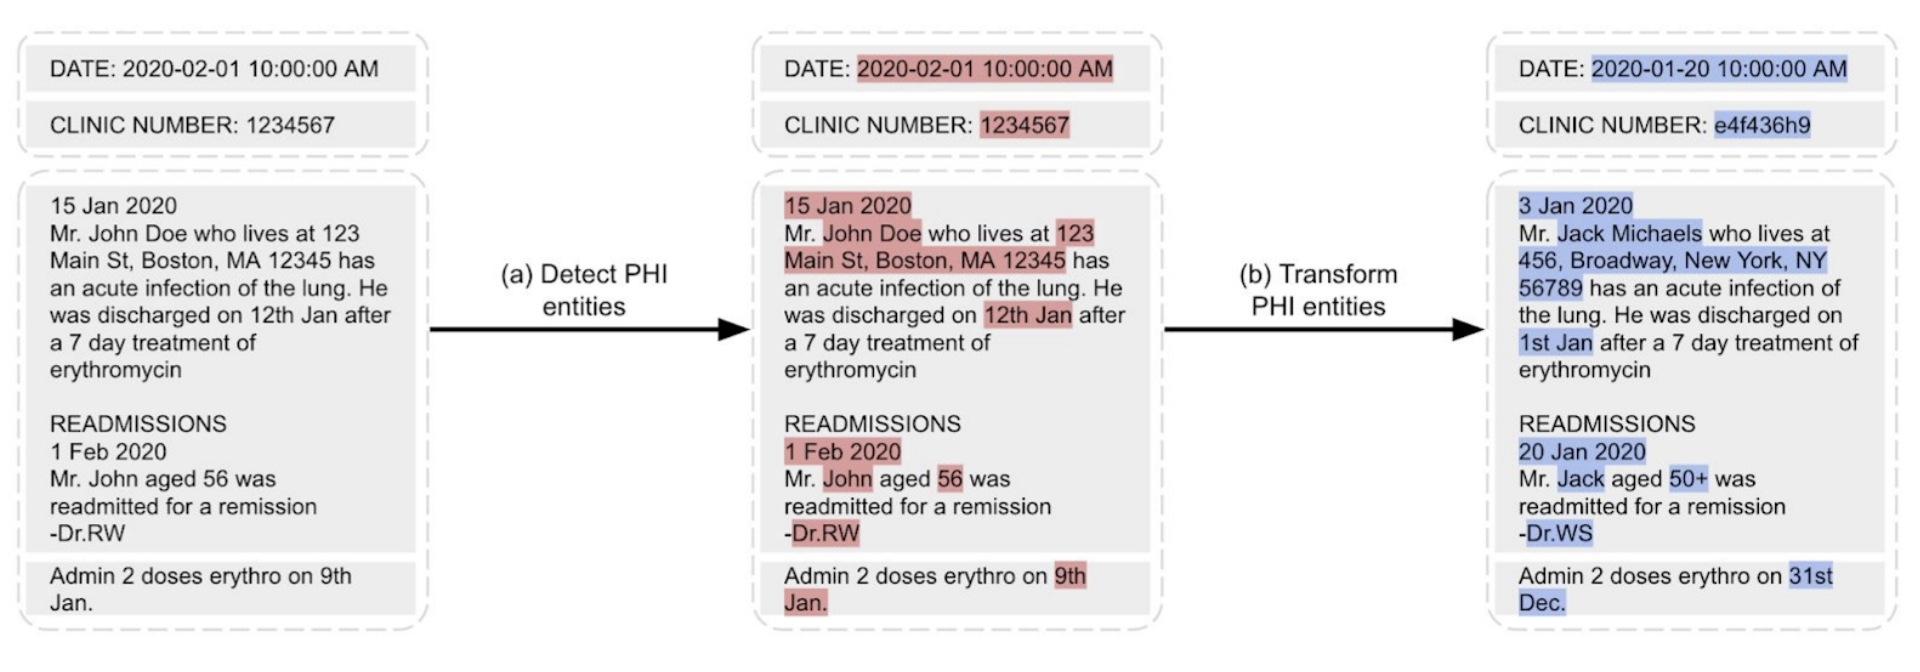

<center><b>Deidentification NER Models for English</b></center>

|index|model|lang|index|model|lang|index|model|lang|
|-----:|:-----|----|-----:|:-----|----|-----:|:-----|----|
| 1| [deidentify_dl](https://nlp.johnsnowlabs.com/2021/01/28/deidentify_dl_en.html)  |en| 7| [ner_deid_enriched_biobert](https://nlp.johnsnowlabs.com/2021/04/01/ner_deid_enriched_biobert_en.html)  |en| 13| [ner_deid_subentity_augmented](https://nlp.johnsnowlabs.com/2021/09/03/ner_deid_subentity_augmented_en.html)  |en|
| 2| [deidentify_large](https://nlp.johnsnowlabs.com/2020/08/04/deidentify_large_en.html)  |en| 8| [ner_deid_generic_augmented](https://nlp.johnsnowlabs.com/2021/06/30/ner_deid_generic_augmented_en.html)  |en| 14| [ner_deid_subentity_augmented_i2b2](https://nlp.johnsnowlabs.com/2021/11/29/ner_deid_subentity_augmented_i2b2_en.html)  |en|
| 3| [deidentify_rb](https://nlp.johnsnowlabs.com/2019/06/04/deidentify_rb_en.html)  |en| 9| [ner_deid_generic_glove](https://nlp.johnsnowlabs.com/2021/06/06/ner_deid_generic_glove_en.html)  |en| 15| [ner_deid_subentity_glove](https://nlp.johnsnowlabs.com/2021/06/06/ner_deid_subentity_glove_en.html)  |en|
| 4| [ner_deid_augmented](https://nlp.johnsnowlabs.com/2021/03/31/ner_deid_augmented_en.html)  |en| 10| [ner_deid_large](https://nlp.johnsnowlabs.com/2021/03/31/ner_deid_large_en.html)  |en| 16| [ner_deid_synthetic](https://nlp.johnsnowlabs.com/2021/03/31/ner_deid_synthetic_en.html)  |en|
| 5| [ner_deid_biobert](https://nlp.johnsnowlabs.com/2021/04/01/ner_deid_biobert_en.html)  |en| 11| [ner_deid_sd](https://nlp.johnsnowlabs.com/2021/04/01/ner_deid_sd_en.html)  |en| 17| [ner_deidentify_dl](https://nlp.johnsnowlabs.com/2021/03/31/ner_deidentify_dl_en.html)  |en|
| 6| [ner_deid_enriched](https://nlp.johnsnowlabs.com/2021/03/31/ner_deid_enriched_en.html)  |en| 12| [ner_deid_sd_large](https://nlp.johnsnowlabs.com/2021/04/01/ner_deid_sd_large_en.html)  |en| 18| []()|


<center><b>Deidentification NER Models for Other Languages</b></center>

|index|model|lang|index|model|lang|
|-----:|:-----|----|-----:|:-----|----|
| 1| [ner_deid_generic](https://nlp.johnsnowlabs.com/2022/01/06/ner_deid_generic_de.html)  |de| 14| [ner_deid_generic](https://nlp.johnsnowlabs.com/2022/02/11/ner_deid_generic_fr.html)  |fr|
| 2| [ner_deid_subentity](https://nlp.johnsnowlabs.com/2022/01/06/ner_deid_subentity_de.html)  |de| 15| [ner_deid_subentity](https://nlp.johnsnowlabs.com/2022/02/14/ner_deid_subentity_fr.html)  |fr|
| 3| [ner_deid_generic](https://nlp.johnsnowlabs.com/2022/01/18/ner_deid_generic_es.html)  |es| 16| [ner_deid_generic](https://nlp.johnsnowlabs.com/2022/03/25/ner_deid_generic_it_3_0.html)  |it|
| 4| [ner_deid_generic_augmented](https://nlp.johnsnowlabs.com/2022/02/16/ner_deid_generic_augmented_es.html)  |es| 17| [ner_deid_subentity](https://nlp.johnsnowlabs.com/2022/03/25/ner_deid_subentity_it_2_4.html)  |it|
| 5| [ner_deid_generic_roberta](https://nlp.johnsnowlabs.com/2022/01/17/ner_deid_generic_roberta_es.html)  |es| 18| [ner_deid_generic](https://nlp.johnsnowlabs.com/2022/04/13/ner_deid_generic_pt_3_0.html)  |pt|
| 6| [ner_deid_generic_roberta_augmented](https://nlp.johnsnowlabs.com/2022/02/16/ner_deid_generic_roberta_augmented_es.html)  |es| 19| [ner_deid_subentity](https://nlp.johnsnowlabs.com/2022/04/13/ner_deid_subentity_pt_3_0.html)  |pt|
| 7| [ner_deid_subentity](https://nlp.johnsnowlabs.com/2022/01/18/ner_deid_subentity_es.html)  |es| 20| [ner_deid_subentity](https://nlp.johnsnowlabs.com/2022/06/27/ner_deid_subentity_ro_3_0.html)  |ro|
| 8| [ner_deid_subentity_augmented](https://nlp.johnsnowlabs.com/2022/02/16/ner_deid_subentity_augmented_es.html)  |es| 21| [ner_deid_subentity_bert](https://nlp.johnsnowlabs.com/2022/06/27/ner_deid_subentity_bert_ro_3_0.html)  |ro|
| 9| [ner_deid_subentity_roberta](https://nlp.johnsnowlabs.com/2022/01/17/ner_deid_subentity_roberta_es.html)  |es| 22| [ner_deid_generic](https://nlp.johnsnowlabs.com/models)  |ro|
| 10| [ner_deid_subentity_roberta_augmented](https://nlp.johnsnowlabs.com/2022/02/16/ner_deid_subentity_roberta_augmented_es.html)  |es| 23| [ner_deid_generic_bert](https://nlp.johnsnowlabs.com/models)  |ro|
| 11| [ner_deid_subentity](https://nlp.johnsnowlabs.com/2023/05/31/ner_deid_subentity_ar.html)  |ar| 24| [ner_deid_generic](https://nlp.johnsnowlabs.com/2023/05/30/ner_deid_generic_ar.html)  |ar|
12|[ner_deid_subentity_arabert](https://nlp.johnsnowlabs.com/2023/09/16/ner_deid_subentity_arabert_ar.html)   |ar| 25|[ner_deid_generic_arabert](https://nlp.johnsnowlabs.com/2023/09/16/ner_deid_generic_arabert_ar.html)   |ar|
 13| [ner_deid_subentity_camelbert](https://nlp.johnsnowlabs.com/2023/09/22/ner_deid_subentity_camelbert_ar.html) |ar| 26| [ner_deid_generic_camelbert](https://nlp.johnsnowlabs.com/2023/09/16/ner_deid_generic_camelbert_ar.html) |ar|

You can find **`German`, `Spanish`, `French`, `Italian`, `Portuguese`, `Romanian`**  and **`Arabic`**  deidentification models and pretrained pipeline examples in this notebook:   [Clinical Multi Language Deidentification Notebook](https://github.com/JohnSnowLabs/spark-nlp-workshop/blob/master/healthcare-nlp/04.1.Clinical_Multi_Language_Deidentification.ipynb)


**ONE-LINER DEIDENTIFICATION MODULE** <br/>
Additionally, Spark NLP for Healthcare provides functionality to apply Deidentification using **one-liner module** called `Deid`. <br/>

The `Deid` module is a tool for deidentifying Protected Health Information (PHI) from data in a file path. It can be used with or without ant Spark NLP NER pipelines. It can apply deidentification and obfuscation on different columns at the same time.
It returns the deidentification & obfuscation results as a spark dataframe as well as a `csv` or `json file` saved locally.
The module also includes functionality for applying Structured Deidentification task to data from a file path. <br/>

Please visit [Clinical Deidentification Utility Module Notebook](https://github.com/JohnSnowLabs/spark-nlp-workshop/blob/master/healthcare-nlp/04.5.Clinical_Deidentification_Utility_Module.ipynb) for datailed usage and examples.

Firstly, we will load NER pipeline to identify protected entities. Pretrained NER models extracts:

- Name
- Profession
- Age
- Date
- Contact(Telephone numbers, FAX numbers, Email addresses)
- Location (Address, City, Postal code, Hospital Name, Employment information)
- Id (Social Security numbers, Medical record numbers, Internet protocol addresses)

In [ ]:
documentAssembler = nlp.DocumentAssembler()\
    .setInputCol("text")\
    .setOutputCol("document")

sentenceDetector = nlp.SentenceDetector()\
    .setInputCols(["document"])\
    .setOutputCol("sentence")

tokenizer = nlp.Tokenizer()\
    .setInputCols(["sentence"])\
    .setOutputCol("token")

word_embeddings = nlp.WordEmbeddingsModel.pretrained("embeddings_clinical", "en", "clinical/models")\
    .setInputCols(["sentence", "token"])\
    .setOutputCol("embeddings")

# NER model trained on n2c2 (de-identification and Heart Disease Risk Factors Challenge) datasets)
deid_ner = medical.NerModel.pretrained("ner_deid_generic_augmented", "en", "clinical/models") \
    .setInputCols(["sentence", "token", "embeddings"]) \
    .setOutputCol("deid_ner")

deid_ner_converter = medical.NerConverterInternal() \
    .setInputCols(["sentence", "token", "deid_ner"]) \
    .setOutputCol("deid_ner_chunk")


deidPipeline = nlp.Pipeline(stages=[
      documentAssembler,
      sentenceDetector,
      tokenizer,
      word_embeddings,
      deid_ner,
      deid_ner_converter])

deid_model = deidPipeline.fit(spark.createDataFrame([[""]]).toDF("text"))

embeddings_clinical download started this may take some time.
Approximate size to download 1.6 GB
[OK!]
ner_deid_generic_augmented download started this may take some time.
[OK!]


In [ ]:
text ='''
Record date : 2093-01-13 , David Hale , M.D . , Name : Hendrickson Ora , MR #7194334 Date : 01/13/93 . PCP : Oliveira , 25 years-old , Record date : 2079-11-09 . Cocke County Baptist Hospital , 0295 Keats Street , Phone 55-555-5555 .
'''

In [ ]:
result = deid_model.transform(spark.createDataFrame([[text]]).toDF("text"))

Let's check extracted sensitive entities by NER piepline

In [ ]:
result.select(F.explode(F.arrays_zip(result.deid_ner_chunk.result, result.deid_ner_chunk.metadata)).alias("cols")) \
      .select(F.expr("cols['0']").alias("chunk"),
              F.expr("cols['1']['entity']").alias("ner_label")).show(truncate=False)

+-----------------------------+---------+
|chunk                        |ner_label|
+-----------------------------+---------+
|2093-01-13                   |DATE     |
|David Hale                   |NAME     |
|Hendrickson Ora              |NAME     |
|#7194334                     |ID       |
|01/13/93                     |DATE     |
|Oliveira                     |NAME     |
|25                           |AGE      |
|2079-11-09                   |DATE     |
|Cocke County Baptist Hospital|LOCATION |
|0295 Keats Street            |LOCATION |
|55-555-5555                  |CONTACT  |
+-----------------------------+---------+



Sometimes we need to leave some entities in the text, for example, if we want to analyze the frequency of the disease by the hospital. In this case, we may use the parameter **`setBlackList()`** to modify `ner_chunk` output. This parameter having using a list of entity types to deidentify as an input. So, if we want to exclude the location, we need to specify this tag in the list:

In [ ]:
filtered_ner_converter = medical.NerConverterInternal()\
    .setInputCols(["sentence", "token", "deid_ner"])\
    .setOutputCol("deid_ner_chunk") \
    .setBlackList(['LOCATION'])

deidPipeline = nlp.Pipeline(stages=[
    documentAssembler,
    sentenceDetector,
    tokenizer,
    word_embeddings,
    deid_ner,
    filtered_ner_converter])


model_with_black_list = deidPipeline.fit(spark.createDataFrame([[""]]).toDF("text"))

result_with_black_list = model_with_black_list.transform(spark.createDataFrame([[text]]).toDF("text"))

In [ ]:
print("All Labels :")
result.select(F.explode(F.arrays_zip(result.deid_ner_chunk.result, result.deid_ner_chunk.metadata)).alias("cols")) \
      .select(F.expr("cols['0']").alias("chunk"),
              F.expr("cols['1']['entity']").alias("ner_label")).show(truncate=False)

print("BlackListed Labels: ")
result_with_black_list.select(F.explode(F.arrays_zip(result_with_black_list.deid_ner_chunk.result, result_with_black_list.deid_ner_chunk.metadata)).alias("cols")) \
                      .select(F.expr("cols['0']").alias("chunk"),
                              F.expr("cols['1']['entity']").alias("ner_label")).show(truncate=False)

All Labels :
+-----------------------------+---------+
|chunk                        |ner_label|
+-----------------------------+---------+
|2093-01-13                   |DATE     |
|David Hale                   |NAME     |
|Hendrickson Ora              |NAME     |
|#7194334                     |ID       |
|01/13/93                     |DATE     |
|Oliveira                     |NAME     |
|25                           |AGE      |
|2079-11-09                   |DATE     |
|Cocke County Baptist Hospital|LOCATION |
|0295 Keats Street            |LOCATION |
|55-555-5555                  |CONTACT  |
+-----------------------------+---------+

BlackListed Labels: 
+---------------+---------+
|chunk          |ner_label|
+---------------+---------+
|2093-01-13     |DATE     |
|David Hale     |NAME     |
|Hendrickson Ora|NAME     |
|#7194334       |ID       |
|01/13/93       |DATE     |
|Oliveira       |NAME     |
|25             |AGE      |
|2079-11-09     |DATE     |
|55-555-5555    |CONTACT  |

### Masking

Now, we will replace this enitites with tags, this process is called **"masking"**. We will specifiy `setMode()` parameter as `setMode("mask")` in `DeIdentification()` in order to apply masking

In [ ]:
deid_ner_converter = medical.NerConverterInternal()\
      .setInputCols(["sentence", "token", "deid_ner"])\
      .setOutputCol("deid_ner_chunk")

deidentification = medical.DeIdentification() \
      .setInputCols(["sentence", "token", "deid_ner_chunk"]) \
      .setOutputCol("deidentified") \
      .setMode("mask")\
      .setReturnEntityMappings(True) #  return a new column to save the mappings between the mask/obfuscated entities and original entities.
      #.setMappingsColumn("MappingCol") # change the name of the column, 'aux' is default

deidPipeline = nlp.Pipeline(stages=[
      documentAssembler,
      sentenceDetector,
      tokenizer,
      word_embeddings,
      deid_ner,
      deid_ner_converter,
      deidentification])

deid_model = deidPipeline.fit(spark.createDataFrame([[""]]).toDF("text"))

In [ ]:
result = deid_model.transform(spark.createDataFrame([[text]]).toDF("text"))
result.show()

+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|                text|            document|            sentence|               token|          embeddings|            deid_ner|      deid_ner_chunk|        deidentified|                 aux|
+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|\nRecord date : 2...|[{document, 0, 23...|[{document, 1, 45...|[{token, 1, 6, Re...|[{word_embeddings...|[{named_entity, 1...|[{chunk, 15, 24, ...|[{document, 0, 36...|[{chunk, 14, 19, ...|
+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+



Let's check the results

In [ ]:
pd.set_option('display.max_colwidth', None)

result.select(F.explode(F.arrays_zip(result.sentence.result, result.deidentified.result)).alias("cols")) \
      .select(F.expr("cols['0']").alias("sentence"),
              F.expr("cols['1']").alias("deidentified")).toPandas()

,sentence,deidentified
0,"Record date : 2093-01-13 , David Hale , M.D .","Record date : <DATE> , <NAME> , M.D ."
1,", Name : Hendrickson Ora , MR #7194334 Date : 01/13/93 .",", Name : <NAME> , MR <ID> Date : <DATE> ."
2,"PCP : Oliveira , 25 years-old , Record date : 2079-11-09 .","PCP : <NAME> , <AGE> years-old , Record date : <DATE> ."
3,"Cocke County Baptist Hospital , 0295 Keats Street , Phone 55-555-5555 .","<LOCATION> , <LOCATION> , Phone <CONTACT> ."


We have three modes to mask the entities in the Deidentification annotator. You can select the modes using the `.setMaskingPolicy()` parameter. The methods are the followings:

**“entity_labels”**: Mask with the entity type of that chunk. (default) <br/>
**“same_length_chars”**: Mask the deid entities with same length of asterix ( * ) with brackets ( [ , ] ) on both end. <br/>
**“fixed_length_chars”**: Mask the deid entities with a fixed length of asterix ( * ). The length is setting up using the `setFixedMaskLength()` method. <br/>
Let's try each of these and compare the results.

In [ ]:
#deid model with "entity_labels"
deid_entity_labels= medical.DeIdentification()\
    .setInputCols(["sentence", "token", "deid_ner_chunk"])\
    .setOutputCol("deid_entity_label")\
    .setMode("mask")\
    .setReturnEntityMappings(True)\
    .setMaskingPolicy("entity_labels")

#deid model with "same_length_chars"
deid_same_length= medical.DeIdentification()\
    .setInputCols(["sentence", "token", "deid_ner_chunk"])\
    .setOutputCol("deid_same_length")\
    .setMode("mask")\
    .setReturnEntityMappings(True)\
    .setMaskingPolicy("same_length_chars")

#deid model with "fixed_length_chars"
deid_fixed_length= medical.DeIdentification()\
    .setInputCols(["sentence", "token", "deid_ner_chunk"])\
    .setOutputCol("deid_fixed_length")\
    .setMode("mask")\
    .setReturnEntityMappings(True)\
    .setMaskingPolicy("fixed_length_chars")\
    .setFixedMaskLength(4)


deidPipeline = nlp.Pipeline(stages=[
      documentAssembler,
      sentenceDetector,
      tokenizer,
      word_embeddings,
      deid_ner,
      deid_ner_converter,
      deid_entity_labels,
      deid_same_length,
      deid_fixed_length])

deid_model = deidPipeline.fit(spark.createDataFrame([[""]]).toDF("text"))

In [ ]:
policy_result = deid_model.transform(spark.createDataFrame([[text]]).toDF("text"))
policy_result.show()

+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|                text|            document|            sentence|               token|          embeddings|            deid_ner|      deid_ner_chunk|   deid_entity_label|                 aux|    deid_same_length|   deid_fixed_length|
+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|\nRecord date : 2...|[{document, 0, 23...|[{document, 1, 45...|[{token, 1, 6, Re...|[{word_embeddings...|[{named_entity, 1...|[{chunk, 15, 24, ...|[{document, 0, 36...|[{chunk, 14, 17, ...|[{document, 0, 44...|[{document, 0, 32...|
+--------------------+--------------------+--------------------+----

In [ ]:
policy_result.select(F.explode(F.arrays_zip(policy_result.sentence.result,
                                            policy_result.deid_entity_label.result,
                                            policy_result.deid_same_length.result,
                                            policy_result.deid_fixed_length.result)).alias("cols")) \
             .select(F.expr("cols['0']").alias("sentence"),
                     F.expr("cols['1']").alias("deid_entity_label"),
                     F.expr("cols['2']").alias("deid_same_length"),
                     F.expr("cols['3']").alias("deid_fixed_length")).toPandas()

,sentence,deid_entity_label,deid_same_length,deid_fixed_length
0,"Record date : 2093-01-13 , David Hale , M.D .","Record date : <DATE> , <NAME> , M.D .","Record date : [********] , [********] , M.D .","Record date : **** , **** , M.D ."
1,", Name : Hendrickson Ora , MR #7194334 Date : 01/13/93 .",", Name : <NAME> , MR <ID> Date : <DATE> .",", Name : [*************] , MR [******] Date : [******] .",", Name : **** , MR **** Date : **** ."
2,"PCP : Oliveira , 25 years-old , Record date : 2079-11-09 .","PCP : <NAME> , <AGE> years-old , Record date : <DATE> .","PCP : [******] , ** years-old , Record date : [********] .","PCP : **** , **** years-old , Record date : **** ."
3,"Cocke County Baptist Hospital , 0295 Keats Street , Phone 55-555-5555 .","<LOCATION> , <LOCATION> , Phone <CONTACT> .","[***************************] , [***************] , Phone [*********] .","**** , **** , Phone **** ."


### Reidentification

We can use `ReIdentification` annotator to go back to the original sentence. Let's see how it works

In [ ]:
reIdentification = medical.ReIdentification()\
    .setInputCols(["aux","deidentified"])\
    .setOutputCol("original")

In [ ]:
reid_result = reIdentification.transform(result)
reid_result.show()

+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|                text|            document|            sentence|               token|          embeddings|            deid_ner|      deid_ner_chunk|        deidentified|                 aux|            original|
+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|\nRecord date : 2...|[{document, 0, 23...|[{document, 1, 45...|[{token, 1, 6, Re...|[{word_embeddings...|[{named_entity, 1...|[{chunk, 15, 24, ...|[{document, 0, 36...|[{chunk, 14, 19, ...|[{document, 1, 45...|
+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+----

In [ ]:
print(text)

reid_result.select('original.result').show(truncate=False)


Record date : 2093-01-13 , David Hale , M.D . , Name : Hendrickson Ora , MR #7194334 Date : 01/13/93 . PCP : Oliveira , 25 years-old , Record date : 2079-11-09 . Cocke County Baptist Hospital , 0295 Keats Street , Phone 55-555-5555 .

+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|result                                                                                                                                                                                                                                        |
+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|[Record date : 2093-01-13 , David Hale ,

### Enriching with Regex and Override NER




We can enrich our existing Deidentification model with both custom and embedded regex.

Firstly, let's build our deid pipeline again, but this time by filtering "`CONTACT`" entities from ner model.

Then, we will set `setReturnEntityMappings(True)`. In this way, we are going to see that we still be able to deidentify "`CONTACT`" as `PHONE` even though ner model doesn't detect "`CONTACT`" entity since the regex embedded in deid model will be taken account.

In [ ]:
filtered_ner_converter = medical.NerConverterInternal()\
      .setInputCols(["sentence", "token", "deid_ner"])\
      .setOutputCol("deid_ner_chunk")\
      .setBlackList(["CONTACT"])

deidentification = medical.DeIdentification() \
      .setInputCols(["sentence", "token", "deid_ner_chunk"]) \
      .setOutputCol("deidentified") \
      .setMode("mask")\
      .setRegexOverride(True)

deidPipeline = nlp.Pipeline(stages=[
      documentAssembler,
      sentenceDetector,
      tokenizer,
      word_embeddings,
      deid_ner,
      filtered_ner_converter,
      deidentification])

model_default_rgx = deidPipeline.fit(spark.createDataFrame([[""]]).toDF("text"))

In [ ]:
result = model_default_rgx.transform(spark.createDataFrame([[text]]).toDF("text"))

result.select(F.explode(F.arrays_zip(result.sentence.result, result.deidentified.result)).alias("cols")) \
      .select(F.expr("cols['0']").alias("sentence"), F.expr("cols['1']").alias("deidentified")).toPandas()

,sentence,deidentified
0,"Record date : 2093-01-13 , David Hale , M.D .","Record date : <DATE> , <NAME> , M.D ."
1,", Name : Hendrickson Ora , MR #7194334 Date : 01/13/93 .",", Name : <NAME> , MR <ID> Date : <DATE> ."
2,"PCP : Oliveira , 25 years-old , Record date : 2079-11-09 .","PCP : <NAME> , <AGE> years-old , Record date : <DATE> ."
3,"Cocke County Baptist Hospital , 0295 Keats Street , Phone 55-555-5555 .","<LOCATION> , <LOCATION> , Phone <PHONE> ."


As you see above, we were able to deidentify `CONTACT` entity as `PHONE` which comes from the embedded regex even though ner model doesn't detect them.

Now, let's identify a custom regex and see how it works.

We will write a regex to deidentify "number" and save it as .txt file. Then, we will specify this file in `Deidentification()` through `setRegexPatternsDictionary()` parameter.

In [ ]:
rgx = '''NUMBER ([0-9]{2})
NUMBER (\d{7})'''

with open("./custom_regex.txt", "w") as f:
  f.write(rgx)

f = open("./custom_regex.txt", "r")

print(f.read())

NUMBER ([0-9]{2})
NUMBER (\d{7})


In [ ]:
deid_ner_converter = medical.NerConverterInternal()\
      .setInputCols(["sentence", "token", "deid_ner"])\
      .setOutputCol("deid_ner_chunk")

deidentification_rgx = medical.DeIdentification()\
    .setInputCols(["sentence", "token", "deid_ner_chunk"])\
    .setOutputCol("deidentified")\
    .setMode("mask") \
    .setRegexPatternsDictionary("./custom_regex.txt")\
    .setRegexOverride(True)# Prioritizing regex rules

deidPipeline = nlp.Pipeline(stages=[
      documentAssembler,
      sentenceDetector,
      tokenizer,
      word_embeddings,
      deid_ner,
      deid_ner_converter,
      deidentification_rgx])

model_rgx = deidPipeline.fit(spark.createDataFrame([[""]]).toDF("text"))

In [ ]:
text ='''Record date : 2093-01-13 , David Hale , M.D . , Name : Hendrickson , Ora MR . # 7194334 Date : 01/13/93 PCP : Oliveira , 25 years-old , Record date : 2079-11-09 . Cocke County Baptist Hospital . 0295 Keats Street.'''
result = model_rgx.transform(spark.createDataFrame([[text]]).toDF("text"))

result.select(F.explode(F.arrays_zip(result.sentence.result, result.deidentified.result)).alias("cols")) \
      .select(F.expr("cols['0']").alias("sentence"), F.expr("cols['1']").alias("deidentified")).toPandas()

,sentence,deidentified
0,"Record date : 2093-01-13 , David Hale , M.D .","Record date : <DATE> , <NAME> , M.D ."
1,", Name : Hendrickson , Ora MR .",", Name : <NAME> MR ."
2,"# 7194334 Date : 01/13/93 PCP : Oliveira , 25 years-old , Record date : 2079-11-09 .","# <NUMBER> Date : <DATE> PCP : <NAME> , <NUMBER> years-old , Record date : <DATE> ."
3,Cocke County Baptist Hospital .,<LOCATION> .
4,0295 Keats Street.,<LOCATION>.


As you see above, we deidentified the "number" through our custom regex even though ner model doesn't detect the "number" entity.

### Obfuscation

In the obfuscation mode **DeIdentificationModel** will replace sensetive entities with random values of the same type.
We can specify `.setMode()` parameter as `.setMode("obfuscate")` to use this feature.

Let's create a piepline and see how it works


In [ ]:
deid_ner_converter = medical.NerConverterInternal()\
      .setInputCols(["sentence", "token", "deid_ner"])\
      .setOutputCol("deid_ner_chunk")

obfuscation = medical.DeIdentification()\
    .setInputCols(["sentence", "token", "deid_ner_chunk"]) \
    .setOutputCol("deidentified") \
    .setMode("obfuscate")\
    .setObfuscateDate(True)\

deidPipeline = nlp.Pipeline(stages=[
      documentAssembler,
      sentenceDetector,
      tokenizer,
      word_embeddings,
      deid_ner,
      deid_ner_converter,
      obfuscation])

obfuscation_model = deidPipeline.fit(spark.createDataFrame([[""]]).toDF("text"))

In [ ]:
text ='''
Record date : 2093-01-13 , David Hale , M.D . , Name : Hendrickson , Ora MR #7194334 Date : 01/13/93 . Patient : Oliveira, 25 years-old , Record date : 2079-11-09 . Cocke County Baptist Hospital . 0295 Keats Street
'''

result = obfuscation_model.transform(spark.createDataFrame([[text]]).toDF("text"))

result.select(F.explode(F.arrays_zip(result.sentence.result, result.deidentified.result)).alias("cols")) \
      .select(F.expr("cols['0']").alias("sentence"), F.expr("cols['1']").alias("deidentified")).toPandas()

,sentence,deidentified
0,"Record date : 2093-01-13 , David Hale , M.D .","Record date : 2093-03-04 , Donnetta Hutching , M.D ."
1,", Name : Hendrickson , Ora MR #7194334 Date : 01/13/93 .",", Name : Santina Evans #1467664 Date : 03/04/93 ."
2,"Patient : Oliveira, 25 years-old , Record date : 2079-11-09 .","Patient : Doran Heater, 24 years-old , Record date : 2079-12-29 ."
3,Cocke County Baptist Hospital .,2601 Electric Avenue .
4,0295 Keats Street,167 N Main Street & East Elm Ave


As you see, we succesfully obfuscated the entities.


In addition, we can define a reference file for obfuscation. In this way, deid model uses the fake entities that we defined in this file.

If we want to use reference file, we should give the path of txt file that includes our custom entities to the `setObfuscateRefFile()` parameter. Then, we should set `setObfuscateRefSource("file")` parameter.

However, we can set `setObfuscateRefSource` parameter as **faker** or **both** as well.

The faker module allows  the user to use a set of fake entities that are in the memory of the spark-nlp-internal. You can set up this module for using the following property `setObfuscateRefSource('faker')`.

If we select the `setObfuscateRefSource('both')` then we choose randomly the entities using the faker and the fake entities from the obfuscateRefFile.





Now, let's define a reference file and use it in our deidentification model.

In [ ]:
obs_lines = """Marvin MARSHALL#NAME
Hubert GROGAN#NAME
ALTHEA COLBURN#NAME
Kalil AMIN#NAME
Inci FOUNTAIN#NAME
Ekaterina Rosa#NAME
Rudiger Chao#NAME
COLLETTE KOHLER#NAME
Mufi HIGGS#NAME"""


with open ('obfuscation.txt', 'w') as f:
  f.write(obs_lines)

In [ ]:
deid_ner_converter = medical.NerConverterInternal()\
      .setInputCols(["sentence", "token", "deid_ner"])\
      .setOutputCol("deid_ner_chunk")

obfuscation = medical.DeIdentification()\
    .setInputCols(["sentence", "token", "deid_ner_chunk"]) \
    .setOutputCol("deidentified") \
    .setMode("obfuscate")\
    .setObfuscateDate(True)\
    .setObfuscateRefFile('obfuscation.txt')\
    .setObfuscateRefSource("file") #both or faker

deidPipeline = nlp.Pipeline(stages=[
      documentAssembler,
      sentenceDetector,
      tokenizer,
      word_embeddings,
      deid_ner,
      deid_ner_converter,
      obfuscation])


obfuscation_model = deidPipeline.fit(spark.createDataFrame([[""]]).toDF("text"))

In [ ]:
text ='''
Record date : 2093-01-13 , David Hale , M.D . , Name : Hendrickson , Ora MR # 7194334 Date : 01/13/93 . Patient : Oliveira, 25 years-old , Record date : 2079-11-09 . Cocke County Baptist Hospital . 0295 Keats Street
'''

result = obfuscation_model.transform(spark.createDataFrame([[text]]).toDF("text"))

result.select(F.explode(F.arrays_zip(result.sentence.result, result.deidentified.result)).alias("cols")) \
      .select(F.expr("cols['0']").alias("sentence"),
              F.expr("cols['1']").alias("deidentified")).toPandas()

,sentence,deidentified
0,"Record date : 2093-01-13 , David Hale , M.D .","Record date : 2093-01-21 , COLLETTE KOHLER , M.D ."
1,", Name : Hendrickson , Ora MR # 7194334 Date : 01/13/93 .",", Name : Ekaterina Rosa MR # 0807809 Date : 01/21/93 ."
2,"Patient : Oliveira, 25 years-old , Record date : 2079-11-09 .","Patient : Ekaterina Rosa, <AGE> years-old , Record date : 2079-11-17 ."
3,Cocke County Baptist Hospital .,<LOCATION> .
4,0295 Keats Street,<LOCATION>


**`.setObfuscateDate(True)` parameter obfuscated the `DATE` entities and the `NAME`s were replaced with the custom list.**

## Shifting Days

In the example above, we replaced date entities with another date randomly. Instead of that, we can shift the date according to any column.

In [ ]:
#sample data for day shifting
data = pd.DataFrame(
    {'patientID' : ['A001', 'A001', 'A002', 'A002'],
     'text' : ['Chris Brown was discharged on 10/02/2022',
               'Mark White was discharged on 02/28/2020',
               'John was discharged on 03/15/2022',
               'John Moore was discharged on 12/31/2022'
              ]
    }
)

my_input_df = spark.createDataFrame(data)

my_input_df.show(truncate = False)

+---------+----------------------------------------+
|patientID|text                                    |
+---------+----------------------------------------+
|A001     |Chris Brown was discharged on 10/02/2022|
|A001     |Mark White was discharged on 02/28/2020 |
|A002     |John was discharged on 03/15/2022       |
|A002     |John Moore was discharged on 12/31/2022 |
+---------+----------------------------------------+



### Shifting days according to the ID column

We use the `DocumentHashCoder()` annotator to determine shifting days. This annotator gets the hash of the specified column and creates a new document column containing day shift information. And then, the `DeIdentification` annotator deidentifies this new doc. We should set the seed parameter to hash consistently.  

In [ ]:
documentAssembler = nlp.DocumentAssembler()\
    .setInputCol("text")\
    .setOutputCol("document")

documentHasher = medical.DocumentHashCoder()\
    .setInputCols("document")\
    .setOutputCol("document2")\
    .setPatientIdColumn("patientID")\
    .setRangeDays(100)\
    .setNewDateShift("shift_days")\
    .setSeed(100)

tokenizer = nlp.Tokenizer()\
    .setInputCols(["document2"])\
    .setOutputCol("token")

embeddings = nlp.WordEmbeddingsModel.pretrained("embeddings_clinical", "en", "clinical/models")\
    .setInputCols(["document2", "token"])\
    .setOutputCol("word_embeddings")

clinical_ner = medical.NerModel\
    .pretrained("ner_deid_subentity_augmented", "en", "clinical/models")\
    .setInputCols(["document2","token", "word_embeddings"])\
    .setOutputCol("ner")

ner_converter = medical.NerConverterInternal()\
    .setInputCols(["document2", "token", "ner"])\
    .setOutputCol("ner_chunk")

de_identification = medical.DeIdentification() \
    .setInputCols(["ner_chunk", "token", "document2"]) \
    .setOutputCol("deid_text") \
    .setMode("obfuscate") \
    .setObfuscateDate(True) \
    .setDateTag("DATE") \
    .setLanguage("en") \
    .setObfuscateRefSource('faker') \
    .setUseShifDays(True)\
    .setRegion('us')


pipeline = nlp.Pipeline().setStages([
    documentAssembler,
    documentHasher,
    tokenizer,
    embeddings,
    clinical_ner,
    ner_converter,
    de_identification

])

empty_data = spark.createDataFrame([["", ""]]).toDF("text", "patientID")

pipeline_model = pipeline.fit(empty_data)

embeddings_clinical download started this may take some time.
Approximate size to download 1.6 GB
[OK!]
ner_deid_subentity_augmented download started this may take some time.
[OK!]


In [ ]:
output = pipeline_model.transform(my_input_df)

output.select('patientID','text', "shift_days", 'deid_text.result').show(truncate = False)

+---------+----------------------------------------+----------+------------------------------------------------+
|patientID|text                                    |shift_days|result                                          |
+---------+----------------------------------------+----------+------------------------------------------------+
|A001     |Chris Brown was discharged on 10/02/2022|-5        |[Phillips Hay was discharged on 09/27/2022]     |
|A001     |Mark White was discharged on 02/28/2020 |-5        |[Mauri Reading was discharged on 02/23/2020]    |
|A002     |John was discharged on 03/15/2022       |29        |[Sharee Pimple was discharged on 04/13/2022]    |
|A002     |John Moore was discharged on 12/31/2022 |29        |[Adrian Blackwater was discharged on 01/29/2023]|
+---------+----------------------------------------+----------+------------------------------------------------+



### Shifting days according to specified values

Instead of shifting days according to ID column, we can specify shifting values with another column.

```python
documentHasher = DocumentHashCoder()\
    .setInputCols("document")\
    .setOutputCol("document2")\
    .setDateShiftColumn("dateshift")\
```


In [ ]:
data = pd.DataFrame(
    {'patientID' : ['A001', 'A002', 'A003', 'A004'],
     'text' : ['Chris Brown was discharged on 10/02/2022',
               'Mark White was discharged on 03/01/2020',
               'John was discharged on 03/15/2022',
               'John Moore was discharged on 12/31/2022'
              ],
     'dateshift' : ['10', '-2', '30', '-8']
    }
)

my_input_df = spark.createDataFrame(data)

my_input_df.show(truncate=False)

+---------+----------------------------------------+---------+
|patientID|text                                    |dateshift|
+---------+----------------------------------------+---------+
|A001     |Chris Brown was discharged on 10/02/2022|10       |
|A002     |Mark White was discharged on 03/01/2020 |-2       |
|A003     |John was discharged on 03/15/2022       |30       |
|A004     |John Moore was discharged on 12/31/2022 |-8       |
+---------+----------------------------------------+---------+



In [ ]:
documentAssembler = nlp.DocumentAssembler()\
    .setInputCol("text")\
    .setOutputCol("document")

documentHasher = medical.DocumentHashCoder()\
    .setInputCols("document")\
    .setOutputCol("document2")\
    .setDateShiftColumn("dateshift")\

tokenizer = nlp.Tokenizer()\
    .setInputCols(["document2"])\
    .setOutputCol("token")

embeddings = nlp.WordEmbeddingsModel.pretrained("embeddings_clinical", "en", "clinical/models")\
    .setInputCols(["document2", "token"])\
    .setOutputCol("word_embeddings")

clinical_ner = medical.NerModel\
    .pretrained("ner_deid_subentity_augmented", "en", "clinical/models")\
    .setInputCols(["document2","token", "word_embeddings"])\
    .setOutputCol("ner")

ner_converter = medical.NerConverterInternal()\
    .setInputCols(["document2", "token", "ner"])\
    .setOutputCol("ner_chunk")

de_identification = medical.DeIdentification() \
    .setInputCols(["ner_chunk", "token", "document2"]) \
    .setOutputCol("deid_text") \
    .setMode("obfuscate") \
    .setObfuscateDate(True) \
    .setDateTag("DATE") \
    .setLanguage("en") \
    .setObfuscateRefSource('faker') \
    .setUseShifDays(True)\
    .setRegion('us')

pipeline_col = nlp.Pipeline().setStages([
    documentAssembler,
    documentHasher,
    tokenizer,
    embeddings,
    clinical_ner,
    ner_converter,
    de_identification

])

empty_data = spark.createDataFrame([["", "", ""]]).toDF("patientID","text", "dateshift")

pipeline_col_model = pipeline_col.fit(empty_data)

embeddings_clinical download started this may take some time.
Approximate size to download 1.6 GB
[OK!]
ner_deid_subentity_augmented download started this may take some time.
[OK!]


In [ ]:
output = pipeline_col_model.transform(my_input_df)

output.select('text', 'dateshift', 'deid_text.result').show(truncate = False)

+----------------------------------------+---------+---------------------------------------------+
|text                                    |dateshift|result                                       |
+----------------------------------------+---------+---------------------------------------------+
|Chris Brown was discharged on 10/02/2022|10       |[Lindley Magnus was discharged on 10/12/2022]|
|Mark White was discharged on 03/01/2020 |-2       |[Shanon Ace was discharged on 02/28/2020]    |
|John was discharged on 03/15/2022       |30       |[Louretta Parma was discharged on 04/14/2022]|
|John Moore was discharged on 12/31/2022 |-8       |[Rudell Cobb was discharged on 12/23/2022]   |
+----------------------------------------+---------+---------------------------------------------+



Here, dates were shifted according to `dateshift` column

## Age Groups Obfuscation

In [ ]:
documentAssembler = nlp.DocumentAssembler()\
    .setInputCol("text")\
    .setOutputCol("document")

sentenceDetector = nlp.SentenceDetector()\
    .setInputCols(["document"])\
    .setOutputCol("sentence")

tokenizer = nlp.Tokenizer()\
    .setInputCols(["sentence"])\
    .setOutputCol("token")

word_embeddings = nlp.WordEmbeddingsModel.pretrained("embeddings_clinical", "en", "clinical/models")\
    .setInputCols(["sentence", "token"])\
    .setOutputCol("embeddings")

# NER model trained on n2c2 (de-identification and Heart Disease Risk Factors Challenge) datasets)
deid_ner = medical.NerModel.pretrained("ner_deid_generic_augmented", "en", "clinical/models") \
    .setInputCols(["sentence", "token", "embeddings"]) \
    .setOutputCol("deid_ner")

deid_ner_converter = medical.NerConverterInternal() \
    .setInputCols(["sentence", "token", "deid_ner"]) \
    .setOutputCol("deid_ner_chunk")


embeddings_clinical download started this may take some time.
Approximate size to download 1.6 GB
[OK!]
ner_deid_generic_augmented download started this may take some time.
[OK!]


In [ ]:
ner_converter = medical.NerConverterInternal()\
    .setInputCols(["sentence", "token", "deid_ner"])\
    .setOutputCol("age_chunk")\
    .setWhiteList(["AGE"])

obfuscation = medical.DeIdentification()\
    .setInputCols(["sentence", "token", "age_chunk"])\
    .setOutputCol("obfuscation")\
    .setMode("obfuscate")\
    .setObfuscateDate(True)\
    .setObfuscateRefSource("faker")\
    .setAgeRanges([1, 4, 12, 20, 40, 60, 80])

nlpPipeline = nlp.Pipeline(stages=[
      documentAssembler,
      sentenceDetector,
      tokenizer,
      word_embeddings,
      deid_ner,
      ner_converter,
      obfuscation
      ])

empty_data = spark.createDataFrame([[""]]).toDF("text")

model_agerange = nlpPipeline.fit(empty_data)

In [ ]:
# Infant = 0-1 year.
# Toddler = 2-4 yrs.
# Child = 5-12 yrs.
# Teen = 13-19 yrs.
# Adult = 20-39 yrs.
# Middle Age Adult = 40-59 yrs.
# Senior Adult = 60+

dates = [
'1 year old baby',
'4 year old kids',
'A 15 year old female with',
'Record date: 2093-01-13, Age: 25',
'Patient is 45 years-old',
'He is 65 years-old male'
]
from pyspark.sql.types import StringType
df_dates = spark.createDataFrame(dates,StringType()).toDF('text')


result = model_agerange.transform(df_dates)

result_df = result.select("text",F.explode(F.arrays_zip(result.age_chunk.result,
                                                        result.obfuscation.result)).alias("cols")) \
                  .select("text",F.expr("cols['0']").alias("age_chunk"),
                                 F.expr("cols['1']").alias("obfuscation"))

result_df.show(truncate=False)

+--------------------------------+---------+--------------------------------+
|text                            |age_chunk|obfuscation                     |
+--------------------------------+---------+--------------------------------+
|1 year old baby                 |1        |3 year old baby                 |
|4 year old kids                 |4        |7 year old kids                 |
|A 15 year old female with       |15       |A 19 year old female with       |
|Record date: 2093-01-13, Age: 25|25       |Record date: 2093-03-07, Age: 21|
|Patient is 45 years-old         |45       |Patient is 41 years-old         |
|He is 65 years-old male         |65       |He is 69 years-old male         |
+--------------------------------+---------+--------------------------------+



## Multi-Mode Deidentification


We have multi-mode functionality in the `DeIdentification()`.
By providing a json file to the `setSelectiveObfuscationModes("a JSON path")` parameter, we are able to use multi-mode in de-identification. <br/>

The entities which have not been given in dictionary will be deidentified according to the `setMode()` parameter.

In [ ]:
#json to choose deid modes
sample_json= {
	"obfuscate": ["PHONE"] ,
	"mask_entity_labels": ["ID"],
	"skip": ["DATE"],
	"mask_same_length_chars":["NAME"],
	"mask_fixed_length_chars":["zip", "location"]
}

import json
with open('sample_multi-mode.json', 'w', encoding='utf-8') as f:
    json.dump(sample_json, f, ensure_ascii=False, indent=4)

In [ ]:
clinical_ner = medical.NerModel.pretrained("ner_deid_generic_augmented", "en", "clinical/models") \
    .setInputCols(["sentence", "token", "embeddings"]) \
    .setOutputCol("ner")

ner_converter = medical.NerConverterInternal()\
    .setInputCols(["sentence", "token", "ner"])\
    .setOutputCol("ner_chunk")\
    .setBlackList(["CONTACT"])

deid_doc = medical.DeIdentification() \
      .setInputCols(["sentence", "token", "ner_chunk"]) \
      .setOutputCol("deidentified") \
      .setMode("mask")\
      .setSelectiveObfuscationModesPath("sample_multi-mode.json")\
      .setSameLengthFormattedEntities(["PHONE"])\
      .setFixedMaskLength(2)

deidPipeline = nlp.Pipeline(stages=[
      documentAssembler,
      sentenceDetector,
      tokenizer,
      word_embeddings,
      clinical_ner,
      ner_converter,
      deid_doc])

empty_data = spark.createDataFrame([[""]]).toDF("text")

text ='''
Record date : 2093-01-13 , David Hale , M.D . , Name : Hendrickson Ora , MR # 7194334 Date : 01/13/93 . PCP : Oliveira , 25 years-old , Record date : 2079-11-09 . Cocke County Baptist Hospital , 0295 Keats Street , Phone 55-555-5555 .
'''

model_deid = deidPipeline.fit(empty_data)
result = model_deid.transform(spark.createDataFrame([[text]]).toDF("text"))


ner_deid_generic_augmented download started this may take some time.
[OK!]


In [ ]:
result.select(F.explode(F.arrays_zip(result.sentence.result, result.deidentified.result)).alias("cols")) \
      .select(F.expr("cols['0']").alias("sentence"),
              F.expr("cols['1']").alias("deidentified")).show(truncate=False)

+-----------------------------------------------------------------------+-------------------------------------------------------------+
|sentence                                                               |deidentified                                                 |
+-----------------------------------------------------------------------+-------------------------------------------------------------+
|Record date : 2093-01-13 , David Hale , M.D .                          |Record date : 2093-01-13 , [********] , M.D .                |
|, Name : Hendrickson Ora , MR # 7194334 Date : 01/13/93 .              |, Name : [*************] , MR # <ID> Date : 01/13/93 .       |
|PCP : Oliveira , 25 years-old , Record date : 2079-11-09 .             |PCP : [******] , <AGE> years-old , Record date : 2079-11-09 .|
|Cocke County Baptist Hospital , 0295 Keats Street , Phone 55-555-5555 .|** , ** , Phone 07-123-1954 .                                |
+-----------------------------------------------

## Structured Deidentification

We can use deidentification not only text but also structured data as well.

Let's see how it works

In [ ]:
!wget -q https://raw.githubusercontent.com/JohnSnowLabs/spark-nlp-workshop/master/healthcare-nlp/data/hipaa-table-001.txt

df = spark.read.format("csv") \
    .option("sep", "\t") \
    .option("inferSchema", "true") \
    .option("header", "true") \
    .load("hipaa-table-001.txt")

df = df.withColumnRenamed("PATIENT","NAME")
df.show(truncate=False)

+---------------+----------+---+----------------------------------------------------+-------+--------------+---+---+
|NAME           |DOB       |AGE|ADDRESS                                             |ZIPCODE|TEL           |SBP|DBP|
+---------------+----------+---+----------------------------------------------------+-------+--------------+---+---+
|Cecilia Chapman|04/02/1935|83 |711-2880 Nulla St. Mankato Mississippi              |69200  |(257) 563-7401|101|42 |
|Iris Watson    |03/10/2009|9  |P.O. Box 283 8562 Fusce Rd. Frederick Nebraska      |20620  |(372) 587-2335|159|122|
|Bryar Pitts    |11/01/1921|98 |5543 Aliquet St. Fort Dodge GA                      |20783  |(717) 450-4729|149|52 |
|Theodore Lowe  |13/02/2002|16 |Ap #867-859 Sit Rd. Azusa New York                  |39531  |(793) 151-6230|134|115|
|Calista Wise   |20/08/1942|76 |7292 Dictum Av. San Antonio MI                      |47096  |(492) 709-6392|139|78 |
|Kyla Olsen     |12/05/1973|45 |Ap #651-8679 Sodales Av. Tamunin

In [ ]:
obfuscator = medical.StructuredDeidentification(spark,{"NAME":"PATIENT","AGE":"AGE"}, obfuscateRefSource = "faker")
obfuscator_df = obfuscator.obfuscateColumns(df)
obfuscator_df.show(truncate=False)

+-------------------+----------+-----+----------------------------------------------------+-------+--------------+---+---+
|NAME               |DOB       |AGE  |ADDRESS                                             |ZIPCODE|TEL           |SBP|DBP|
+-------------------+----------+-----+----------------------------------------------------+-------+--------------+---+---+
|[Moshe Salisbury]  |04/02/1935|[97] |711-2880 Nulla St. Mankato Mississippi              |69200  |(257) 563-7401|101|42 |
|[Merlene Pulling]  |03/10/2009|[8]  |P.O. Box 283 8562 Fusce Rd. Frederick Nebraska      |20620  |(372) 587-2335|159|122|
|[Juleen Starr]     |11/01/1921|[83] |5543 Aliquet St. Fort Dodge GA                      |20783  |(717) 450-4729|149|52 |
|[Corey Skains]     |13/02/2002|[17] |Ap #867-859 Sit Rd. Azusa New York                  |39531  |(793) 151-6230|134|115|
|[Kellie Simmering] |20/08/1942|[66] |7292 Dictum Av. San Antonio MI                      |47096  |(492) 709-6392|139|78 |
|[Fransico Micha

We can define reference file for obfuscation as well like we did before. All we need to do is defining `obfuscateRefFile` and `onfuscateRefSource` parameters.

In [ ]:
obfuscator_unique_ref_test = '''Will Perry#PATIENT
John Smith#PATIENT
Marvin MARSHALL#PATIENT
Hubert GROGAN#PATIENT
ALTHEA COLBURN#PATIENT
Kalil AMIN#PATIENT
Inci FOUNTAIN#PATIENT
Jackson WILLE#PATIENT
Jack SANTOS#PATIENT
Mahmood ALBURN#PATIENT
Marnie MELINGTON#PATIENT
Aysha GHAZI#PATIENT
Maryland CODER#PATIENT
Darene GEORGIOUS#PATIENT
Shelly WELLBECK#PATIENT
Min Kun JAE#PATIENT
Thomson THOMAS#PATIENT
Christian SUDDINBURG#PATIENT
Aberdeen#CITY
Louisburg St#STREET
France#LOC
Nick Riviera#DOCTOR
5552312#PHONE
St James Hospital#HOSPITAL
Calle del Libertador#ADDRESS
111#ID
Will#DOCTOR
20#AGE
30#AGE
40#AGE
50#AGE
60#AGE
'''

with open('obfuscator_unique_ref_test.txt', 'w') as f:
  f.write(obfuscator_unique_ref_test)

In [ ]:
# obfuscateRefSource = "file"

obfuscator = medical.StructuredDeidentification(spark,{"NAME":"PATIENT","AGE":"AGE"},
                                        obfuscateRefFile = "/content/obfuscator_unique_ref_test.txt",
                                        obfuscateRefSource = "file",
                                        columnsSeed={"NAME": 23, "AGE": 23})
obfuscator_df = obfuscator.obfuscateColumns(df)
obfuscator_df.select("NAME","AGE").show(truncate=False)

+----------------------+----+
|NAME                  |AGE |
+----------------------+----+
|[Christian SUDDINBURG]|[60]|
|[Christian SUDDINBURG]|[30]|
|[Thomson THOMAS]      |[30]|
|[Aysha GHAZI]         |[40]|
|[Jack SANTOS]         |[40]|
|[Mahmood ALBURN]      |[40]|
|[Jackson WILLE]       |[60]|
|[Maryland CODER]      |[60]|
|[Kalil AMIN]          |[60]|
|[Kalil AMIN]          |[20]|
|[Thomson THOMAS]      |[60]|
|[Kalil AMIN]          |[40]|
|[Mahmood ALBURN]      |[30]|
|[Darene GEORGIOUS]    |[30]|
|[Jack SANTOS]         |[30]|
|[Maryland CODER]      |[60]|
|[Darene GEORGIOUS]    |[50]|
|[Maryland CODER]      |[30]|
|[Mahmood ALBURN]      |[20]|
|[Thomson THOMAS]      |[20]|
+----------------------+----+
only showing top 20 rows



We can **shift n days** in the structured deidentification through "days" parameter when the column is a Date.

In [ ]:
df = spark.createDataFrame([
            ["Juan García", "13/02/1977", "711 Nulla St.", "140", "673 431234"],
            ["Will Smith", "23/02/1977", "1 Green Avenue.", "140", "+23 (673) 431234"],
            ["Pedro Ximénez", "11/04/1900", "Calle del Libertador, 7", "100", "912 345623"]
        ]).toDF("NAME", "DOB", "ADDRESS", "SBP", "TEL")
df.show(truncate=False)

+-------------+----------+-----------------------+---+----------------+
|NAME         |DOB       |ADDRESS                |SBP|TEL             |
+-------------+----------+-----------------------+---+----------------+
|Juan García  |13/02/1977|711 Nulla St.          |140|673 431234      |
|Will Smith   |23/02/1977|1 Green Avenue.        |140|+23 (673) 431234|
|Pedro Ximénez|11/04/1900|Calle del Libertador, 7|100|912 345623      |
+-------------+----------+-----------------------+---+----------------+



In [ ]:
obfuscator = medical.StructuredDeidentification(spark=spark,
                                        columns={"NAME": "ID", "DOB": "DATE"},
                                        columnsSeed={"NAME": 23, "DOB": 23},
                                        obfuscateRefSource="faker",
                                        days=5
                                         )

In [ ]:
result = obfuscator.obfuscateColumns(df)
result.show(truncate=False)

+---------------+------------+-----------------------+---+----------------+
|NAME           |DOB         |ADDRESS                |SBP|TEL             |
+---------------+------------+-----------------------+---+----------------+
|[MRDW ZDKBXD]  |[18/02/1977]|711 Nulla St.          |140|673 431234      |
|[UGJJ QKGBF]   |[28/02/1977]|1 Green Avenue.        |140|+23 (673) 431234|
|[EFEIV WTXRUFA]|[16/04/1900]|Calle del Libertador, 7|100|912 345623      |
+---------------+------------+-----------------------+---+----------------+



## Pretrained Deidentification Pipeline

`clinical_deidentification` pipeline can be used to deidentify PHI information from medical texts. The PHI information will be masked and obfuscated in the resulting text. The pipeline can mask and obfuscate `AGE`, `CONTACT`, `DATE`, `ID`, `LOCATION`, `NAME`, `PROFESSION`, `CITY`, `COUNTRY`, `DOCTOR`, `HOSPITAL`, `IDNUM`, `MEDICALRECORD`, `ORGANIZATION`, `PATIENT`, `PHONE`, `PROFESSION`, `STREET`, `USERNAME`, `ZIP`, `ACCOUNT`, `LICENSE`, `VIN`, `SSN`, `DLN`, `PLATE`, `IPADDR` entities. There is also a slim version of deidentificaiton pipeline, `clinical_deidentification_slim`

Let's see how it works

In [ ]:
deid_pipeline = nlp.PretrainedPipeline("clinical_deidentification_multi_mode_output", "en", "clinical/models")

clinical_deidentification_multi_mode_output download started this may take some time.
Approx size to download 1.6 GB
[OK!]


In [ ]:
deid_pipeline.model.stages

[DocumentAssembler_3a23e68cd503,
 SentenceDetectorDLModel_6bafc4746ea5,
 REGEX_TOKENIZER_f9e9b7cd7a6e,
 WORD_EMBEDDINGS_MODEL_9004b1d00302,
 MedicalNerModel_e8178a1262cc,
 NerConverter_55995bcb9ddd,
 MedicalNerModel_9d4a08b1c03d,
 NerConverter_d8018e5a25ef,
 MERGE_1da1ae4759b0,
 CONTEXTUAL-PARSER_589450ce1157,
 CONTEXTUAL-PARSER_06707d7cc03f,
 CONTEXTUAL-PARSER_830136cb728a,
 CONTEXTUAL-PARSER_c2928d0497ea,
 CONTEXTUAL-PARSER_5983c91a8b93,
 CONTEXTUAL-PARSER_de9483134521,
 ENTITY_EXTRACTOR_1a83f57ad0be,
 CONTEXTUAL-PARSER_468cc9e4617f,
 REGEX_MATCHER_515b81ce5553,
 CONTEXTUAL-PARSER_e29affff61be,
 CONTEXTUAL-PARSER_18f459ad6746,
 CONTEXTUAL-PARSER_d698ca02dd44,
 CONTEXTUAL-PARSER_6c57c6958db0,
 MERGE_d03408851605,
 MERGE_5c6ed803d8b2,
 DE-IDENTIFICATION_6c607ffc8d22,
 DE-IDENTIFICATION_c189f8aac00a,
 DE-IDENTIFICATION_68cbeeca6a18,
 DE-IDENTIFICATION_4aa0193c2166,
 Finisher_852050f6877f]

In [ ]:
text= """Name : Hendrickson, Ora, Record date: 2093-01-13, Age: 25, # 719435. Dr. John Green, ID: 1231511863, IP 203.120.223.13. He is a 60-year-old male was admitted to the Day Hospital for cystectomy on 01/13/93. Patient's VIN : 1HGBH41JXMN109286, SSN #333-44-6666, Driver's license no:A334455B. Phone (302) 786-5227, 0295 Keats Street, San Francisco."""

In [ ]:
deid_res= deid_pipeline.annotate(text)

In [ ]:
deid_res.keys()

dict_keys(['masked', 'obfuscated', 'ner_chunk', 'masked_fixed_length_chars', 'sentence', 'masked_with_chars'])

In [ ]:
pd.set_option("display.max_colwidth", 100)

df= pd.DataFrame(list(zip(deid_res["sentence"],
                          deid_res["masked"],
                          deid_res["masked_with_chars"],
                          deid_res["masked_fixed_length_chars"],
                          deid_res["obfuscated"])),
                 columns= ["Sentence", "Masked", "Masked with Chars", "Masked with Fixed Chars", "Obfuscated"])

df

,Sentence,Masked,Masked with Chars,Masked with Fixed Chars,Obfuscated
0,"Name : Hendrickson, Ora, Record date: 2093-01-13, Age: 25, # 719435.","Name : <PATIENT>, Record date: <DATE>, Age: <AGE>, # <PHONE>.","Name : [**************], Record date: [********], Age: **, # [****].","Name : ****, Record date: ****, Age: ****, # ****.","Name : Toma Deiters, Record date: 2093-02-02, Age: 39, # 161096."
1,"Dr. John Green, ID: 1231511863, IP 203.120.223.13.","Dr. <DOCTOR>, ID: <DEVICE>, IP <IPADDR>.","Dr. [********], ID: [********], IP [************].","Dr. ****, ID: ****, IP ****.","Dr. Verlin Dike, ID: T5770739, IP 444.444.444.444."
2,He is a 60-year-old male was admitted to the Day Hospital for cystectomy on 01/13/93.,He is a <AGE>-year-old male was admitted to the <HOSPITAL> for cystectomy on <DATE>.,He is a **-year-old male was admitted to the [**********] for cystectomy on [******].,He is a ****-year-old male was admitted to the **** for cystectomy on ****.,He is a 76-year-old male was admitted to the ST CLARES HOSPITAL OF WESTON INC for cystectomy on ...
3,"Patient's VIN : 1HGBH41JXMN109286, SSN #333-44-6666, Driver's license no:A334455B.","Patient's VIN : <VIN>, SSN <SSN>, Driver's license <DLN>.","Patient's VIN : [***************], SSN [**********], Driver's license [*********].","Patient's VIN : ****, SSN ****, Driver's license ****.","Patient's VIN : 0AVWU98JXBJ478295, SSN #621-30-8657, Driver's license QI:O962952W."
4,"Phone (302) 786-5227, 0295 Keats Street, San Francisco.","Phone <PHONE>, <STREET>, <STATE>.","Phone [************], [***************], [***********].","Phone ****, ****, ****.","Phone (413) 244-0102, 2210 Troy Schenectady Rd, New Hampshire."


# 5.Clinical Relation Extraction

### Pretrained Relation Extraction Models

Extracts and classifies instances of relations between named entities. For this, relation pairs need to be defined with `setRelationPairs`, to specify between which entities the extraction should be done.

We have also trained as end-to-end bert models using **BioBERT** and ported in to the Spark NLP ecosystem (**ReDL**). They offer **SOTA performance** on most benchmark tasks and outperform our existing Relation Extraction Models.


*  **Relation Extraction Models**

|index|model|index|model|index|model|
|-----:|:-----|-----:|:-----|-----:|:-----|
| 1| [generic_re](https://nlp.johnsnowlabs.com/2022/12/20/generic_re.html)  | 2| [posology_re](https://nlp.johnsnowlabs.com/2020/09/01/posology_re.html)  | 3| [re_ade_biobert](https://nlp.johnsnowlabs.com/2021/07/16/re_ade_biobert_en.html)  |
| 4| [re_ade_clinical](https://nlp.johnsnowlabs.com/2021/07/12/re_ade_clinical_en.html)  | 5| [re_ade_conversational](https://nlp.johnsnowlabs.com/2022/07/27/re_ade_conversational_en_3_0.html)  | 6| [re_bodypart_directions](https://nlp.johnsnowlabs.com/2021/01/18/re_bodypart_directions_en.html)  |
| 7| [re_bodypart_problem](https://nlp.johnsnowlabs.com/2021/01/18/re_bodypart_problem_en.html)  | 8| [re_bodypart_proceduretest](https://nlp.johnsnowlabs.com/2021/01/18/re_bodypart_proceduretest_en.html)  | 9| [re_clinical](https://nlp.johnsnowlabs.com/2020/09/24/re_clinical_en.html)  |
| 10| [re_date_clinical](https://nlp.johnsnowlabs.com/2021/01/18/re_date_clinical_en.html)  | 11| [re_drug_drug_interaction_clinical](https://nlp.johnsnowlabs.com/2020/09/03/re_drug_drug_interaction_clinical_en.html)  | 12| [re_drugprot_clinical](https://nlp.johnsnowlabs.com/2022/01/05/re_drugprot_clinical_en.html)  |
| 13| [re_human_phenotype_gene_clinical](https://nlp.johnsnowlabs.com/2020/09/30/re_human_phenotype_gene_clinical_en.html)  | 14| [re_oncology_biomarker_result](https://nlp.johnsnowlabs.com/2024/07/03/re_oncology_biomarker_result_en.html)  | 15| [re_oncology_granular](https://nlp.johnsnowlabs.com/2024/07/03/re_oncology_granular_en.html)  |
| 16| [re_oncology_location](https://nlp.johnsnowlabs.com/2024/07/03/re_oncology_location_en.html)  | 17| [re_oncology_size](https://nlp.johnsnowlabs.com/2024/07/03/re_oncology_size_en.html)  | 18| [re_oncology_temporal](https://nlp.johnsnowlabs.com/2024/07/03/re_oncology_temporal_en.html)  |
| 19| [re_oncology_test_result](https://nlp.johnsnowlabs.com/2024/07/03/re_oncology_test_result_en.html)  | 20| [re_oncology](https://nlp.johnsnowlabs.com/2024/07/03/re_oncology_en.html)  | 21| [re_temporal_events_clinical](https://nlp.johnsnowlabs.com/2020/09/28/re_temporal_events_clinical_en.html)  |
| 22| [re_temporal_events_enriched_clinical](https://nlp.johnsnowlabs.com/2020/09/28/re_temporal_events_enriched_clinical_en.html)  | 23| [re_test_problem_finding](https://nlp.johnsnowlabs.com/2021/04/19/re_test_problem_finding_en.html)  | 24| [re_test_result_date](https://nlp.johnsnowlabs.com/2021/02/24/re_test_result_date_en.html)  |
| 25| [re_zeroshot_biobert](https://nlp.johnsnowlabs.com/2022/04/05/re_zeroshot_biobert_en_3_0.html)  | 26| [redl_ade_biobert](https://nlp.johnsnowlabs.com/2021/07/12/redl_ade_biobert_en.html)  | 27| [redl_bodypart_direction_biobert](https://nlp.johnsnowlabs.com/2021/06/01/redl_bodypart_direction_biobert_en.html)  |
| 28| [redl_bodypart_problem_biobert](https://nlp.johnsnowlabs.com/2021/06/01/redl_bodypart_problem_biobert_en.html)  | 29| [redl_bodypart_procedure_test_biobert](https://nlp.johnsnowlabs.com/2021/09/10/redl_bodypart_procedure_test_biobert_en.html)  | 30| [redl_chemprot_biobert](https://nlp.johnsnowlabs.com/2021/07/24/redl_chemprot_biobert_en.html)  |
| 31| [redl_clinical_biobert](https://nlp.johnsnowlabs.com/2021/07/24/redl_clinical_biobert_en.html)  | 32| [redl_date_clinical_biobert](https://nlp.johnsnowlabs.com/2021/06/01/redl_date_clinical_biobert_en.html)  | 33| [redl_drug_drug_interaction_biobert](https://nlp.johnsnowlabs.com/2021/07/24/redl_drug_drug_interaction_biobert_en.html)  |
| 34| [redl_drugprot_biobert](https://nlp.johnsnowlabs.com/2023/01/14/redl_drugprot_biobert_en.html)  | 35| [redl_human_phenotype_gene_biobert](https://nlp.johnsnowlabs.com/2021/07/24/redl_human_phenotype_gene_biobert_en.html)  | 36| [redl_nihss_biobert](https://nlp.johnsnowlabs.com/2021/11/16/redl_nihss_biobert_en.html)  |
| 37| [redl_oncology_biobert](https://nlp.johnsnowlabs.com/2024/07/03/redl_oncology_biobert_en.html)  | 38| [redl_oncology_biomarker_result_biobert](https://nlp.johnsnowlabs.com/2024/07/03/redl_oncology_biomarker_result_biobert_en.html)  | 39| [redl_oncology_granular_biobert](https://nlp.johnsnowlabs.com/2024/07/03/redl_oncology_granular_biobert_en.html)  |
| 40| [redl_oncology_location_biobert](https://nlp.johnsnowlabs.com/2024/07/03/redl_oncology_location_biobert_en.html)  | 41| [redl_oncology_size_biobert](https://nlp.johnsnowlabs.com/2024/07/03/redl_oncology_size_biobert_en.html)  | 42| [redl_oncology_temporal_biobert](https://nlp.johnsnowlabs.com/2024/07/03/redl_oncology_temporal_biobert_en.html)  |
| 43| [redl_oncology_test_result_biobert](https://nlp.johnsnowlabs.com/2024/07/03/redl_oncology_test_result_biobert_en.html)  | 44| [redl_temporal_events_biobert](https://nlp.johnsnowlabs.com/2021/07/24/redl_temporal_events_biobert_en.html)  | 45| []()|


*  **Relation Extraction Pipelines**

|index|model|index|model|index|model|
|-----:|:-----|-----:|:-----|-----:|:-----|
| 1| [re_bodypart_directions_pipeline](https://nlp.johnsnowlabs.com/2022/03/31/re_bodypart_directions_pipeline_en_3_0.html)  | 4| [re_human_phenotype_gene_clinical_pipeline](https://nlp.johnsnowlabs.com/2022/03/31/re_human_phenotype_gene_clinical_pipeline_en_3_0.html)  | 7| [re_test_problem_finding_pipeline](https://nlp.johnsnowlabs.com/2022/03/31/re_test_problem_finding_pipeline_en_3_0.html)  |
| 2| [re_bodypart_proceduretest_pipeline](https://nlp.johnsnowlabs.com/2022/03/31/re_bodypart_proceduretest_pipeline_en_3_0.html)  | 5| [re_temporal_events_clinical_pipeline](https://nlp.johnsnowlabs.com/2022/03/31/re_temporal_events_clinical_pipeline_en_3_0.html)  | 8| [re_test_result_date_pipeline](https://nlp.johnsnowlabs.com/2022/03/31/re_test_result_date_pipeline_en_3_0.html)  |
| 3| [re_date_clinical_pipeline](https://nlp.johnsnowlabs.com/2022/03/31/re_date_clinical_pipeline_en_3_0.html)  | 6| [re_temporal_events_enriched_clinical_pipeline](https://nlp.johnsnowlabs.com/2022/03/31/re_temporal_events_enriched_clinical_pipeline_en_3_0.html)  | |



[In this link](https://nlp.johnsnowlabs.com/docs/en/best_practices_pretrained_models#relation-extraction-models-and-relation-pairs-table), available Relation Extraction models, its labels, optimal NER model, and meaningful relation pairs are illustrated.

#### Posology Relation Extraction

This is a demonstration of using SparkNLP for extracting posology relations. The following relatios are supported:

DRUG-DOSAGE
DRUG-FREQUENCY
DRUG-ADE (Adversed Drug Events)
DRUG-FORM
DRUG-ROUTE
DRUG-DURATION
DRUG-REASON
DRUG=STRENGTH

The model has been validated against the posology dataset described in (Magge, Scotch, & Gonzalez-Hernandez, 2018).

| Relation | Recall | Precision | F1 | F1 (Magge, Scotch, & Gonzalez-Hernandez, 2018) |
| --- | --- | --- | --- | --- |
| DRUG-ADE | 0.66 | 1.00 | **0.80** | 0.76 |
| DRUG-DOSAGE | 0.89 | 1.00 | **0.94** | 0.91 |
| DRUG-DURATION | 0.75 | 1.00 | **0.85** | 0.92 |
| DRUG-FORM | 0.88 | 1.00 | **0.94** | 0.95* |
| DRUG-FREQUENCY | 0.79 | 1.00 | **0.88** | 0.90 |
| DRUG-REASON | 0.60 | 1.00 | **0.75** | 0.70 |
| DRUG-ROUTE | 0.79 | 1.00 | **0.88** | 0.95* |
| DRUG-STRENGTH | 0.95 | 1.00 | **0.98** | 0.97 |


*Magge, Scotch, Gonzalez-Hernandez (2018) collapsed DRUG-FORM and DRUG-ROUTE into a single relation.

**Build pipeline using SparNLP pretrained models and the relation extration model optimized for posology**.

 The precision of the RE model is controlled by "setMaxSyntacticDistance(4)", which sets the maximum syntactic distance between named entities to 4. A larger value will improve recall at the expense at lower precision. A value of 4 leads to literally perfect precision (i.e. the model doesn't produce any false positives) and reasonably good recall.

In [ ]:
documenter = nlp.DocumentAssembler()\
    .setInputCol("text")\
    .setOutputCol("document")

sentencer = nlp.SentenceDetector()\
    .setInputCols(["document"])\
    .setOutputCol("sentence")

tokenizer = nlp.Tokenizer()\
    .setInputCols(["sentence"])\
    .setOutputCol("token")

words_embedder = nlp.WordEmbeddingsModel.pretrained("embeddings_clinical", "en", "clinical/models")\
    .setInputCols(["sentence", "token"])\
    .setOutputCol("embeddings")

pos_tagger = nlp.PerceptronModel.pretrained("pos_clinical", "en", "clinical/models") \
    .setInputCols(["sentence", "token"])\
    .setOutputCol("pos_tags")

posology_ner = medical.NerModel.pretrained("ner_posology", "en", "clinical/models") \
    .setInputCols(["sentence", "token", "embeddings"]) \
    .setOutputCol("posology_ner")

posology_ner_converter = medical.NerConverterInternal() \
    .setInputCols(["sentence", "token", "posology_ner"]) \
    .setOutputCol("posology_ner_chunk")

dependency_parser = nlp.DependencyParserModel.pretrained("dependency_conllu", "en")\
    .setInputCols(["sentence", "pos_tags", "token"])\
    .setOutputCol("dependencies")

reModel = medical.RelationExtractionModel()\
    .pretrained("posology_re")\
    .setInputCols(["embeddings", "pos_tags", "posology_ner_chunk", "dependencies"])\
    .setOutputCol("relations")\
    .setMaxSyntacticDistance(4)\
#   .setRelationPairs(["DRUG-FREQUENCY, FREQUENCY-DRUG", "DOSAGE-DRUG, DRUG-DOSAGE"])\
#   .setRelationPairsCaseSensitive(False)

relationPipeline = nlp.Pipeline(stages=[
    documenter,
    sentencer,
    tokenizer,
    words_embedder,
    pos_tagger,
    posology_ner,
    posology_ner_converter,
    dependency_parser,
    reModel
])


relation_model = relationPipeline.fit(spark.createDataFrame([[""]]).toDF("text"))

embeddings_clinical download started this may take some time.
Approximate size to download 1.6 GB
[OK!]
pos_clinical download started this may take some time.
Approximate size to download 1.5 MB
[OK!]
ner_posology download started this may take some time.
[OK!]
dependency_conllu download started this may take some time.
Approximate size to download 16.7 MB
[OK!]


Now, let's create a light pipeline for annotating free text

In [ ]:
text = """
The patient was prescribed 1 unit of Advil for 5 days after meals. The patient was also
given 1 unit of Metformin daily.
He was seen by the endocrinology service and she was discharged on 40 units of insulin glargine at night ,
12 units of insulin lispro with meals , and metformin 1000 mg two times a day.
"""

lmodel = nlp.LightPipeline(relation_model)
results = lmodel.fullAnnotate(text)

In [ ]:
'''
The `RelationExtractionVisualizer` can be used to visualize the relations predicted by Spark NLP.
The two entities involved in a relation will be highlighted and their label will be displayed.
Also a directed and labeled arc(line) will be used to connect the two entities.
'''
vis = nlp.viz.RelationExtractionVisualizer()
vis.display(results[0], 'relations', show_relations=True) # default show_relations: True

In [ ]:
results[0].keys()

dict_keys(['posology_ner', 'document', 'posology_ner_chunk', 'token', 'relations', 'embeddings', 'pos_tags', 'dependencies', 'sentence'])

In [ ]:
results[0]['posology_ner_chunk']

[Annotation(chunk, 28, 33, 1 unit, {'chunk': '0', 'confidence': '0.71675', 'ner_source': 'posology_ner_chunk', 'entity': 'DOSAGE', 'sentence': '0'}, []),
 Annotation(chunk, 38, 42, Advil, {'chunk': '1', 'confidence': '0.9984', 'ner_source': 'posology_ner_chunk', 'entity': 'DRUG', 'sentence': '0'}, []),
 Annotation(chunk, 44, 53, for 5 days, {'chunk': '2', 'confidence': '0.7455', 'ner_source': 'posology_ner_chunk', 'entity': 'DURATION', 'sentence': '0'}, []),
 Annotation(chunk, 95, 100, 1 unit, {'chunk': '3', 'confidence': '0.72360003', 'ner_source': 'posology_ner_chunk', 'entity': 'DOSAGE', 'sentence': '1'}, []),
 Annotation(chunk, 105, 113, Metformin, {'chunk': '4', 'confidence': '0.9998', 'ner_source': 'posology_ner_chunk', 'entity': 'DRUG', 'sentence': '1'}, []),
 Annotation(chunk, 115, 119, daily, {'chunk': '5', 'confidence': '0.9997', 'ner_source': 'posology_ner_chunk', 'entity': 'FREQUENCY', 'sentence': '1'}, []),
 Annotation(chunk, 189, 196, 40 units, {'chunk': '6', 'confidence'

In [ ]:
results[0]['relations']

[Annotation(category, 28, 42, DOSAGE-DRUG, {'chunk2': 'Advil', 'confidence': '1.0', 'entity2_end': '42', 'chunk1': '1 unit', 'entity1': 'DOSAGE', 'entity2_begin': '38', 'chunk2_confidence': '0.9984', 'entity1_begin': '28', 'sentence': '0', 'direction': 'both', 'entity1_end': '33', 'entity2': 'DRUG', 'chunk1_confidence': '0.71675'}, []),
 Annotation(category, 38, 53, DRUG-DURATION, {'chunk2': 'for 5 days', 'confidence': '1.0', 'entity2_end': '53', 'chunk1': 'Advil', 'entity1': 'DRUG', 'entity2_begin': '44', 'chunk2_confidence': '0.7455', 'entity1_begin': '38', 'sentence': '0', 'direction': 'both', 'entity1_end': '42', 'entity2': 'DURATION', 'chunk1_confidence': '0.9984'}, []),
 Annotation(category, 95, 113, DOSAGE-DRUG, {'chunk2': 'Metformin', 'confidence': '1.0', 'entity2_end': '113', 'chunk1': '1 unit', 'entity1': 'DOSAGE', 'entity2_begin': '105', 'chunk2_confidence': '0.9998', 'entity1_begin': '95', 'sentence': '1', 'direction': 'both', 'entity1_end': '100', 'entity2': 'DRUG', 'chunk

Showing extracted relations

In [ ]:
for rel in results[0]["relations"]:
    print("{}({}={} - {}={})".format(
        rel.result,
        rel.metadata['entity1'],
        rel.metadata['chunk1'],
        rel.metadata['entity2'],
        rel.metadata['chunk2']
    ))

DOSAGE-DRUG(DOSAGE=1 unit - DRUG=Advil)
DRUG-DURATION(DRUG=Advil - DURATION=for 5 days)
DOSAGE-DRUG(DOSAGE=1 unit - DRUG=Metformin)
DRUG-FREQUENCY(DRUG=Metformin - FREQUENCY=daily)
DOSAGE-DRUG(DOSAGE=40 units - DRUG=insulin glargine)
DRUG-FREQUENCY(DRUG=insulin glargine - FREQUENCY=at night)
DOSAGE-DRUG(DOSAGE=12 units - DRUG=insulin lispro)
DRUG-FREQUENCY(DRUG=insulin lispro - FREQUENCY=with meals)
DRUG-STRENGTH(DRUG=metformin - STRENGTH=1000 mg)
DRUG-FREQUENCY(DRUG=metformin - FREQUENCY=two times a day)


In [ ]:
# get relations in a pandas dataframe

import pandas as pd

def get_relations_df (results, col='relations'):
  rel_pairs=[]
  for rel in results[0][col]:
      rel_pairs.append((
          rel.result,
          rel.metadata['entity1'],
          rel.metadata['entity1_begin'],
          rel.metadata['entity1_end'],
          rel.metadata['chunk1'],
          rel.metadata['entity2'],
          rel.metadata['entity2_begin'],
          rel.metadata['entity2_end'],
          rel.metadata['chunk2'],
          rel.metadata['confidence']
      ))

  rel_df = pd.DataFrame(rel_pairs, columns=['relation','entity1','entity1_begin','entity1_end','chunk1','entity2','entity2_begin','entity2_end','chunk2', 'confidence'])

  return rel_df


rel_df = get_relations_df (results)
rel_df

,relation,entity1,entity1_begin,entity1_end,chunk1,entity2,entity2_begin,entity2_end,chunk2,confidence
0,DOSAGE-DRUG,DOSAGE,28,33,1 unit,DRUG,38,42,Advil,1.0
1,DRUG-DURATION,DRUG,38,42,Advil,DURATION,44,53,for 5 days,1.0
2,DOSAGE-DRUG,DOSAGE,95,100,1 unit,DRUG,105,113,Metformin,1.0
3,DRUG-FREQUENCY,DRUG,105,113,Metformin,FREQUENCY,115,119,daily,1.0
4,DOSAGE-DRUG,DOSAGE,189,196,40 units,DRUG,201,216,insulin glargine,1.0
5,DRUG-FREQUENCY,DRUG,201,216,insulin glargine,FREQUENCY,218,225,at night,1.0
6,DOSAGE-DRUG,DOSAGE,229,236,12 units,DRUG,241,254,insulin lispro,1.0
7,DRUG-FREQUENCY,DRUG,241,254,insulin lispro,FREQUENCY,256,265,with meals,1.0
8,DRUG-STRENGTH,DRUG,273,281,metformin,STRENGTH,283,289,1000 mg,1.0
9,DRUG-FREQUENCY,DRUG,273,281,metformin,FREQUENCY,291,305,two times a day,1.0


Let's try with another text

In [ ]:
text ="""A 28-year-old female with a history of gestational diabetes mellitus diagnosed eight years prior to presentation and subsequent type two diabetes mellitus ( T2DM ),
one prior episode of HTG-induced pancreatitis three years prior to presentation,  associated with an acute hepatitis , and obesity with a body mass index ( BMI ) of 33.5 kg/m2 , presented with a one-week history of polyuria , polydipsia , poor appetite , and vomiting .
Two weeks prior to presentation , she was treated with a five-day course of amoxicillin for a respiratory tract infection .
She was on metformin , glipizide , and dapagliflozin for T2DM and atorvastatin and gemfibrozil for HTG .
She had been on dapagliflozin for six months at the time of presentation. Physical examination on presentation was significant for dry oral mucosa ; significantly , her abdominal examination was benign with no tenderness , guarding , or rigidity .
Pertinent laboratory findings on admission were : serum glucose 111 mg/dl , bicarbonate 18 mmol/l , anion gap 20 , creatinine 0.4 mg/dL , triglycerides 508 mg/dL , total cholesterol 122 mg/dL , glycated hemoglobin ( HbA1c ) 10% , and venous pH 7.27 . Serum lipase was normal at 43 U/L .
Serum acetone levels could not be assessed as blood samples kept hemolyzing due to significant lipemia . The patient was initially admitted for starvation ketosis , as she reported poor oral intake for three days prior to admission . However , serum chemistry obtained six hours after presentation revealed her glucose was 186 mg/dL , the anion gap was still elevated at 21 , serum bicarbonate was 16 mmol/L , triglyceride level peaked at 2050 mg/dL , and lipase was 52 U/L .
The β-hydroxybutyrate level was obtained and found to be elevated at 5.29 mmol/L - the original sample was centrifuged and the chylomicron layer removed prior to analysis due to interference from turbidity caused by lipemia again .
The patient was treated with an insulin drip for euDKA and HTG with a reduction in the anion gap to 13 and triglycerides to 1400 mg/dL , within 24 hours . Her euDKA was thought to be precipitated by her respiratory tract infection in the setting of SGLT2 inhibitor use .
The patient was seen by the endocrinology service and she was discharged on 40 units of insulin glargine at night , 12 units of insulin lispro with meals , and metformin 1000 mg two times a day . It was determined that all SGLT2 inhibitors should be discontinued indefinitely .
She had close follow-up with endocrinology post discharge .
"""

annotations = lmodel.fullAnnotate(text)

rel_df = get_relations_df (annotations)
rel_df

,relation,entity1,entity1_begin,entity1_end,chunk1,entity2,entity2_begin,entity2_end,chunk2,confidence
0,DURATION-DRUG,DURATION,492,499,five-day,DRUG,511,521,amoxicillin,1.0
1,DRUG-DURATION,DRUG,680,692,dapagliflozin,DURATION,694,707,for six months,1.0
2,DRUG-ROUTE,DRUG,1939,1945,insulin,ROUTE,1947,1950,drip,1.0
3,DOSAGE-DRUG,DOSAGE,2254,2261,40 units,DRUG,2266,2281,insulin glargine,1.0
4,DRUG-FREQUENCY,DRUG,2266,2281,insulin glargine,FREQUENCY,2283,2290,at night,1.0
5,DOSAGE-DRUG,DOSAGE,2294,2301,12 units,DRUG,2306,2319,insulin lispro,1.0
6,DRUG-FREQUENCY,DRUG,2306,2319,insulin lispro,FREQUENCY,2321,2330,with meals,1.0
7,DRUG-STRENGTH,DRUG,2338,2346,metformin,STRENGTH,2348,2354,1000 mg,1.0
8,DRUG-FREQUENCY,DRUG,2338,2346,metformin,FREQUENCY,2356,2370,two times a day,1.0



#### ReDL - ADE

Now, let's create a sample pipeline with `redl_ade_biobert` model and see how it works

In [ ]:
documenter = nlp.DocumentAssembler()\
    .setInputCol("text")\
    .setOutputCol("document")

sentencer = nlp.SentenceDetector()\
    .setInputCols(["document"])\
    .setOutputCol("sentence")

tokenizer = nlp.Tokenizer()\
    .setInputCols(["sentence"])\
    .setOutputCol("token")

words_embedder = nlp.WordEmbeddingsModel.pretrained("embeddings_clinical", "en", "clinical/models")\
    .setInputCols(["sentence", "token"])\
    .setOutputCol("embeddings")

pos_tagger = nlp.PerceptronModel.pretrained("pos_clinical", "en", "clinical/models") \
    .setInputCols(["sentence", "token"])\
    .setOutputCol("pos_tags")

ade_ner = medical.NerModel.pretrained("ner_ade_clinical", "en", "clinical/models")\
    .setInputCols("sentence", "token", "embeddings")\
    .setOutputCol("ade_ner")

ade_ner_converter = medical.NerConverterInternal() \
    .setInputCols(["sentence", "token", "ade_ner"]) \
    .setOutputCol("ade_ner_chunk")

ade_re_ner_chunk_filter = medical.RENerChunksFilter() \
    .setInputCols(["ade_ner_chunk", "dependencies"])\
    .setOutputCol("re_ner_chunks")\
    .setMaxSyntacticDistance(10)\
    .setRelationPairs(["drug-ade, ade-drug"])

ade_re_model = medical.RelationExtractionDLModel()\
    .pretrained('redl_ade_biobert', 'en', "clinical/models") \
    .setPredictionThreshold(0.5)\
    .setInputCols(["re_ner_chunks", "sentence"]) \
    .setOutputCol("relations")

ade_pipeline = nlp.Pipeline(stages=[
    documenter,
    sentencer,
    tokenizer,
    words_embedder,
    pos_tagger,
    ade_ner,
    ade_ner_converter,
    dependency_parser,
    ade_re_ner_chunk_filter,
    ade_re_model
])

ade_model = ade_pipeline.fit(spark.createDataFrame([[""]]).toDF("text"))

embeddings_clinical download started this may take some time.
Approximate size to download 1.6 GB
[OK!]
pos_clinical download started this may take some time.
Approximate size to download 1.5 MB
[OK!]
ner_ade_clinical download started this may take some time.
[OK!]
redl_ade_biobert download started this may take some time.
[OK!]


Checking the results

In [ ]:
text ="""A 44-year-old man taking naproxen for chronic low back pain and a 20-year-old woman on oxaprozin for rheumatoid arthritis presented with tense bullae and cutaneous fragility on the face and the back of the hands."""

ade_lmodel = nlp.LightPipeline(ade_model)
ade_results = ade_lmodel.fullAnnotate(text)

rel_df = get_relations_df (ade_results)
rel_df

,relation,entity1,entity1_begin,entity1_end,chunk1,entity2,entity2_begin,entity2_end,chunk2,confidence
0,1,DRUG,25,32,naproxen,ADE,137,148,tense bullae,0.9989047
1,1,DRUG,25,32,naproxen,ADE,154,210,cutaneous fragility on the face and the back of the hands,0.9989704
2,1,DRUG,87,95,oxaprozin,ADE,137,148,tense bullae,0.99895453
3,1,DRUG,87,95,oxaprozin,ADE,154,210,cutaneous fragility on the face and the back of the hands,0.99900633


### Merging Multiple RE Model Results

We can merge multiple RE model results by using `AnnotationMerger()`. <br/>
Now, we will build a pipeline consisting of `posology_re`, `re_ade_clinical` models and `AnnotationMerger()` to merge these RE models' results.

In [ ]:
documenter = nlp.DocumentAssembler()\
    .setInputCol("text")\
    .setOutputCol("document")

sentencer = nlp.SentenceDetector()\
    .setInputCols(["document"])\
    .setOutputCol("sentence")

tokenizer = nlp.Tokenizer()\
    .setInputCols(["sentence"])\
    .setOutputCol("token")

words_embedder = nlp.WordEmbeddingsModel.pretrained("embeddings_clinical", "en", "clinical/models")\
    .setInputCols(["sentence", "token"])\
    .setOutputCol("embeddings")

pos_tagger = nlp.PerceptronModel.pretrained("pos_clinical", "en", "clinical/models") \
    .setInputCols(["sentence", "token"])\
    .setOutputCol("pos_tags")

posology_ner = medical.NerModel.pretrained("ner_posology", "en", "clinical/models") \
    .setInputCols(["sentence", "token", "embeddings"]) \
    .setOutputCol("posology_ner")

posology_ner_converter = medical.NerConverterInternal() \
    .setInputCols(["sentence", "token", "posology_ner"]) \
    .setOutputCol("posology_ner_chunk")

dependency_parser = nlp.DependencyParserModel.pretrained("dependency_conllu", "en")\
    .setInputCols(["sentence", "pos_tags", "token"])\
    .setOutputCol("dependencies")

pos_reModel = medical.RelationExtractionModel.pretrained("posology_re")\
    .setInputCols(["embeddings", "pos_tags", "posology_ner_chunk", "dependencies"])\
    .setOutputCol("pos_relations")\
    .setMaxSyntacticDistance(4)

ade_ner = medical.NerModel.pretrained("ner_ade_clinical", "en", "clinical/models")\
    .setInputCols("sentence", "token", "embeddings")\
    .setOutputCol("ade_ner")

ade_ner_converter = medical.NerConverterInternal() \
    .setInputCols(["sentence", "token", "ade_ner"]) \
    .setOutputCol("ade_ner_chunk")

ade_reModel = medical.RelationExtractionModel()\
    .pretrained("re_ade_clinical", "en", 'clinical/models')\
    .setInputCols(["embeddings", "pos_tags", "ade_ner_chunk", "dependencies"])\
    .setOutputCol("ade_relations")\
    .setMaxSyntacticDistance(10)\
    .setRelationPairs(["drug-ade, ade-drug"])\
    .setCustomLabels({"1": "is_ade", "0": "not_ade"})

annotation_merger = medical.AnnotationMerger()\
    .setInputCols("ade_relations", "pos_relations")\
    .setInputType("category")\
    .setOutputCol("all_relations")

merger_pipeline = nlp.Pipeline(stages=[
    documenter,
    sentencer,
    tokenizer,
    words_embedder,
    pos_tagger,
    posology_ner,
    posology_ner_converter,
    dependency_parser,
    pos_reModel,
    ade_ner,
    ade_ner_converter,
    ade_reModel,
    annotation_merger
])


merger_model= merger_pipeline.fit(spark.createDataFrame([[""]]).toDF("text"))

embeddings_clinical download started this may take some time.
Approximate size to download 1.6 GB
[OK!]
pos_clinical download started this may take some time.
Approximate size to download 1.5 MB
[OK!]
ner_posology download started this may take some time.
[OK!]
dependency_conllu download started this may take some time.
Approximate size to download 16.7 MB
[OK!]
ner_ade_clinical download started this may take some time.
[OK!]
re_ade_clinical download started this may take some time.
[OK!]


Transform and check the results

In [ ]:
text = """
The patient was prescribed 1 unit of naproxen for 5 days after meals for chronic low back pain. The patient was also given 1 unit of oxaprozin daily for rheumatoid arthritis presented with tense bullae and cutaneous fragility on the face and the back of the hands..
"""
data = spark.createDataFrame([[text]]).toDF("text")

result = merger_model.transform(data)
result.show()

+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|                text|            document|            sentence|               token|          embeddings|            pos_tags|        posology_ner|  posology_ner_chunk|        dependencies|       pos_relations|             ade_ner|       ade_ner_chunk|       ade_relations|       all_relations|
+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|\nThe patient was...|[{document, 0, 26...|[{document, 1, 95...|[{token, 1, 3, Th...|[{word_embeddings...|[{pos,

In [ ]:
from pyspark.sql import functions as F

result_df = result.select(F.explode(F.arrays_zip(result.pos_relations.result, result.pos_relations.metadata, result.ade_relations.result, result.ade_relations.metadata, result.all_relations.result, result.all_relations.metadata)).alias("cols")) \
                  .select(
                          F.expr("cols['0']").alias("pos_relations"),\
                          F.expr("cols['1']['entity1']").alias("pos_relations_entity1"),\
                          F.expr("cols['1']['chunk1']" ).alias("pos_relations_chunk1" ),\
                          F.expr("cols['1']['entity2']").alias("pos_relations_entity2"),\
                          F.expr("cols['1']['chunk2']" ).alias("pos_relations_chunk2" ),\
                          F.expr("cols['2']").alias("ade_relations"),\
                          F.expr("cols['3']['entity1']").alias("ade_relations_entity1"),\
                          F.expr("cols['3']['chunk1']" ).alias("ade_relations_chunk1" ),\
                          F.expr("cols['3']['entity2']").alias("ade_relations_entity2"),\
                          F.expr("cols['3']['chunk2']" ).alias("ade_relations_chunk2" ),\
                          F.expr("cols['4']").alias("all_relations"),\
                          F.expr("cols['5']['entity1']").alias("all_relations_entity1"),\
                          F.expr("cols['5']['chunk1']" ).alias("all_relations_chunk1" ),\
                          F.expr("cols['5']['entity2']").alias("all_relations_entity2"),\
                          F.expr("cols['5']['chunk2']" ).alias("all_relations_chunk2" )
                          )

result_df.show()

+--------------+---------------------+--------------------+---------------------+--------------------+-------------+---------------------+--------------------+---------------------+--------------------+--------------+---------------------+--------------------+---------------------+--------------------+
| pos_relations|pos_relations_entity1|pos_relations_chunk1|pos_relations_entity2|pos_relations_chunk2|ade_relations|ade_relations_entity1|ade_relations_chunk1|ade_relations_entity2|ade_relations_chunk2| all_relations|all_relations_entity1|all_relations_chunk1|all_relations_entity2|all_relations_chunk2|
+--------------+---------------------+--------------------+---------------------+--------------------+-------------+---------------------+--------------------+---------------------+--------------------+--------------+---------------------+--------------------+---------------------+--------------------+
|   DOSAGE-DRUG|               DOSAGE|              1 unit|                 DRUG|       

In [ ]:
lmodel = nlp.LightPipeline(merger_model)
merged_results = lmodel.fullAnnotate(text)

vis = nlp.viz.RelationExtractionVisualizer()
vis.display(merged_results[0], 'all_relations', show_relations=True) # default show_relations: True

## Zero-shot Clinical Relation Extraction Model

Zero-shot Relation Extraction to extract relations between clinical entities with no training dataset. zero-shot relation extraction model leverages `BertForSequenceClassificaiton` to return, based on a predefined set of relation candidates (including no-relation / O), which one has the higher probability to be linking two entities.

The dataset will be a csv which contains the following columns: `sentence`, `chunk1`, `firstCharEnt1`, `lastCharEnt1`, `label1`, `chunk2`, `firstCharEnt2`, `lastCharEnt2`, `label2`, `rel`.

For more detailed explanation of the usage of this model, please visit [this notebook](https://github.com/JohnSnowLabs/spark-nlp-workshop/blob/master/healthcare-nlp/03.3.ZeroShot_Clinical_Relation_Extraction.ipynb)

Now, we will use the pretrained `re_zeroshot_biobert` model, this model available in Models Hub under the Relation Extraction category.

This is our Zero-shot RE pipeline;

In [ ]:
# Clinical NER

documenter = nlp.DocumentAssembler() \
    .setInputCol("text") \
    .setOutputCol("document")

sentencer = nlp.SentenceDetectorDLModel.pretrained("sentence_detector_dl_healthcare","en","clinical/models")\
    .setInputCols(["document"])\
    .setOutputCol("sentences")

tokenizer = nlp.Tokenizer() \
    .setInputCols(["sentences"]) \
    .setOutputCol("tokens")

words_embedder = nlp.WordEmbeddingsModel() \
    .pretrained("embeddings_clinical", "en", "clinical/models") \
    .setInputCols(["sentences", "tokens"]) \
    .setOutputCol("embeddings")

ner_clinical = medical.NerModel.pretrained("ner_clinical", "en", "clinical/models") \
    .setInputCols(["sentences", "tokens", "embeddings"]) \
    .setOutputCol("ner_clinical")

ner_clinical_converter = medical.NerConverterInternal() \
    .setInputCols(["sentences", "tokens", "ner_clinical"]) \
    .setOutputCol("ner_clinical_chunks")\
    .setWhiteList(["PROBLEM", "TEST"])      # PROBLEM-TEST-TREATMENT

ner_posology = medical.NerModel.pretrained("ner_posology", "en", "clinical/models") \
    .setInputCols(["sentences", "tokens", "embeddings"]) \
    .setOutputCol("ner_posology")

ner_posology_converter = medical.NerConverterInternal() \
    .setInputCols(["sentences", "tokens", "ner_posology"]) \
    .setOutputCol("ner_posology_chunks")\
    .setWhiteList(["DRUG"])                # DRUG-FREQUENCY-DOSAGE-DURATION-FORM-ROUTE-STRENGTH

chunk_merger = medical.ChunkMergeApproach()\
    .setInputCols("ner_clinical_chunks", "ner_posology_chunks")\
    .setOutputCol('merged_ner_chunks')


## ZERO-SHOT RE Starting...

pos_tagger = nlp.PerceptronModel() \
    .pretrained("pos_clinical", "en", "clinical/models") \
    .setInputCols(["sentences", "tokens"]) \
    .setOutputCol("pos_tags")

dependency_parser = nlp.DependencyParserModel() \
    .pretrained("dependency_conllu", "en") \
    .setInputCols(["document", "pos_tags", "tokens"]) \
    .setOutputCol("dependencies")

re_ner_chunk_filter = medical.RENerChunksFilter() \
    .setRelationPairs(["problem-test","problem-drug"]) \
    .setMaxSyntacticDistance(4)\
    .setDocLevelRelations(False)\
    .setInputCols(["merged_ner_chunks", "dependencies"]) \
    .setOutputCol("re_ner_chunks")

re_model = medical.ZeroShotRelationExtractionModel.pretrained("re_zeroshot_biobert", "en", "clinical/models")\
    .setInputCols(["re_ner_chunks", "sentences"]) \
    .setOutputCol("relations")\
    .setRelationalCategories({
                            "ADE": ["{DRUG} causes {PROBLEM}."],
                            "IMPROVE": ["{DRUG} improves {PROBLEM}.", "{DRUG} cures {PROBLEM}."],
                            "REVEAL": ["{TEST} reveals {PROBLEM}."]})\
    .setMultiLabel(True)

pipeline = nlp.Pipeline() \
    .setStages([documenter,
                sentencer,
                tokenizer,
                words_embedder,
                ner_clinical,
                ner_clinical_converter,
                ner_posology,
                ner_posology_converter,
                chunk_merger,
                pos_tagger,
                dependency_parser,
                re_ner_chunk_filter,
                re_model])

sentence_detector_dl_healthcare download started this may take some time.
Approximate size to download 367.3 KB
[OK!]
embeddings_clinical download started this may take some time.
Approximate size to download 1.6 GB
[OK!]
ner_clinical download started this may take some time.
[OK!]
ner_posology download started this may take some time.
[OK!]
pos_clinical download started this may take some time.
Approximate size to download 1.5 MB
[OK!]
dependency_conllu download started this may take some time.
Approximate size to download 16.7 MB
[OK!]
re_zeroshot_biobert download started this may take some time.
[OK!]


Let's transform and see the results.

In [ ]:
# create Spark DF

sample_text = "Paracetamol can alleviate headache or sickness. An MRI test can be used to find cancer."

data = spark.createDataFrame([[sample_text]]).toDF("text")
data.show(truncate=False)

+---------------------------------------------------------------------------------------+
|text                                                                                   |
+---------------------------------------------------------------------------------------+
|Paracetamol can alleviate headache or sickness. An MRI test can be used to find cancer.|
+---------------------------------------------------------------------------------------+



In [ ]:
zero_model = pipeline.fit(data)

results = zero_model.transform(data)

results\
    .selectExpr("explode(relations) as relation")\
    .show(truncate=False)

+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|relation                                                                                                                                                                                                                                                                                                                                                         |
+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [ ]:
# results in Spark DF

from pyspark.sql import functions as F

results.select(F.explode(F.arrays_zip(results.relations.metadata, results.relations.result)).alias("cols"))\
       .select(F.expr("cols['0']['sentence']").alias("sentence"),
               F.expr("cols['0']['entity1_begin']").alias("entity1_begin"),
               F.expr("cols['0']['entity1_end']").alias("entity1_end"),
               F.expr("cols['0']['chunk1']").alias("chunk1"),
               F.expr("cols['0']['entity1']").alias("entity1"),
               F.expr("cols['0']['entity2_begin']").alias("entity2_begin"),
               F.expr("cols['0']['entity2_end']").alias("entity2_end"),
               F.expr("cols['0']['chunk2']").alias("chunk2"),
               F.expr("cols['0']['entity2']").alias("entity2"),
               F.expr("cols['0']['hypothesis']").alias("hypothesis"),
               F.expr("cols['0']['nli_prediction']").alias("nli_prediction"),
               F.expr("cols['1']").alias("relation"),
               F.expr("cols['0']['confidence']").alias("confidence"),
       ).show(truncate=70)

+--------+-------------+-----------+-----------+-------+-------------+-----------+--------+-------+------------------------------+--------------+--------+----------+
|sentence|entity1_begin|entity1_end|     chunk1|entity1|entity2_begin|entity2_end|  chunk2|entity2|                    hypothesis|nli_prediction|relation|confidence|
+--------+-------------+-----------+-----------+-------+-------------+-----------+--------+-------+------------------------------+--------------+--------+----------+
|       0|            0|         10|Paracetamol|   DRUG|           38|         45|sickness|PROBLEM|Paracetamol improves sickness.|        entail| IMPROVE|0.98819494|
|       0|            0|         10|Paracetamol|   DRUG|           26|         33|headache|PROBLEM|Paracetamol improves headache.|        entail| IMPROVE| 0.9929625|
|       1|           48|         58|An MRI test|   TEST|           80|         85|  cancer|PROBLEM|   An MRI test reveals cancer.|        entail|  REVEAL| 0.9760039|
+---

## Train a Custom Relation Extraction Model

Now, we will train our custom RE model with sample data, let's see how it works

In [ ]:
!wget -q https://raw.githubusercontent.com/JohnSnowLabs/spark-nlp-workshop/master/healthcare-nlp/data/i2b2_clinical_rel_dataset.csv

In [ ]:
data = spark.read.option("header","true").format("csv").load("i2b2_clinical_rel_dataset.csv")
data = data.select( 'sentence','firstCharEnt1','firstCharEnt2','lastCharEnt1','lastCharEnt2', "chunk1", "chunk2", "label1", "label2",'rel','dataset')

data.show(10)

# you only need these columns>> 'sentence','firstCharEnt1','firstCharEnt2','lastCharEnt1','lastCharEnt2', "chunk1", "chunk2", "label1", "label2",'rel'
# ('dataset' column is optional)

+--------------------+-------------+-------------+------------+------------+--------------------+--------------------+---------+---------+-----+-------+
|            sentence|firstCharEnt1|firstCharEnt2|lastCharEnt1|lastCharEnt2|              chunk1|              chunk2|   label1|   label2|  rel|dataset|
+--------------------+-------------+-------------+------------+------------+--------------------+--------------------+---------+---------+-----+-------+
|VITAL SIGNS - Tem...|           49|           75|          64|          84|    respiratory rate|          saturation|     test|     test|    O|   test|
|No lotions , crea...|            3|           34|           9|          42|             lotions|           incisions|treatment|  problem|TrNAP|   test|
|Because of expect...|           11|           58|          54|          68|expected long ter...|         a picc line|treatment|treatment|    O|  train|
|She states this l...|           16|           82|          31|          92|    li

In [ ]:
data.groupby('dataset').count().show()

+-------+-----+
|dataset|count|
+-------+-----+
|  train|  350|
|   test|  650|
+-------+-----+



In [ ]:
data.groupby('rel').count().show()

+-----+-----+
|  rel|count|
+-----+-----+
| TrIP|   14|
| TrAP|  164|
| TeCP|   26|
|    O|  414|
|TrNAP|   14|
| TrCP|   28|
|  PIP|  153|
| TrWP|   11|
| TeRP|  176|
+-----+-----+



In [ ]:
# map entity columns to dataset columns
column_map = {
    "begin1": "firstCharEnt1",
    "end1": "lastCharEnt1",
    "begin2": "firstCharEnt2",
    "end2": "lastCharEnt2",
    "chunk1": "chunk1",
    "chunk2": "chunk2",
    "label1": "label1",
    "label2": "label2"
}

# apply preprocess function to dataframe
data = medical.REDatasetHelper(data).create_annotation_column(
    column_map,
    ner_column_name="train_ner_chunks" # optional, default train_ner_chunks
)

train_data = data.where("dataset='train'")
test_data = data.where("dataset='test'")

In [ ]:
data.show()

+------------+---------+--------------------+-------+-------------+------------+-------------+--------------------+---------+--------------------+-----+--------------------+
|lastCharEnt2|   label1|            sentence|dataset|firstCharEnt2|lastCharEnt1|firstCharEnt1|    train_ner_chunks|   label2|              chunk2|  rel|              chunk1|
+------------+---------+--------------------+-------+-------------+------------+-------------+--------------------+---------+--------------------+-----+--------------------+
|          84|     test|VITAL SIGNS - Tem...|   test|           75|          64|           49|[{chunk, 49, 64, ...|     test|          saturation|    O|    respiratory rate|
|          42|treatment|No lotions , crea...|   test|           34|           9|            3|[{chunk, 3, 9, lo...|  problem|           incisions|TrNAP|             lotions|
|          68|treatment|Because of expect...|  train|           58|          54|           11|[{chunk, 11, 54, ...|treatment|     

We have prepared our train and test data in desired format for traininig.


#### RE Graph

We will use `TFGraphBuilder` annotator which can be used to create graphs automatically in the model training pipeline.

`TFGraphBuilder` inspects the data and creates the proper graph if a suitable version of TensorFlow is available. The graph is stored in the defined folder and loaded by the approach.

You can also create a custom graph by using `tf_graph` module in Spark NLP for Healthcare.

In [ ]:
!pip install -q tensorflow==2.12.0 tensorflow-addons

In [ ]:
'''
# custom graph

from sparknlp_jsl.training import tf_graph

tf_graph.print_model_params("relation_extraction")

tf_graph.build("relation_extraction",
             build_params={"input_dim": 10000,
                          "output_dim": 10,
                          'batch_norm':1,
                          "hidden_layers": [300, 200],
                          "hidden_act": "relu",
                          'hidden_act_l2':1},
                          'model_location'=".",
                          'model_filename'="re_in6000D_out10.pb")
'''

'''
# ready to use graph
!wget -q https://raw.githubusercontent.com/JohnSnowLabs/spark-nlp-workshop/master/tutorials/Certification_Trainings/Healthcare/generic_classifier_graph/RE_in1200D_out20.pb
'''

'\n# ready to use graph\n!wget -q https://raw.githubusercontent.com/JohnSnowLabs/spark-nlp-workshop/master/tutorials/Certification_Trainings/Healthcare/generic_classifier_graph/RE_in1200D_out20.pb\n'

In [ ]:
graph_folder= "./tf_graphs"

re_graph_builder = medical.TFGraphBuilder()\
    .setModelName("relation_extraction")\
    .setInputCols(["embeddings", "pos_tags", "train_ner_chunks", "dependencies"]) \
    .setLabelColumn("rel")\
    .setGraphFolder(graph_folder)\
    .setGraphFile("re_graph.pb")\
    .setHiddenLayers([300, 200])\
    .setHiddenAct("relu")\
    .setHiddenActL2(True)\
    .setHiddenWeightsL2(False)\
    .setBatchNorm(False)

In [ ]:
documenter = nlp.DocumentAssembler()\
    .setInputCol("sentence")\
    .setOutputCol("sentences")

tokenizer = nlp.Tokenizer()\
    .setInputCols(["sentences"])\
    .setOutputCol("tokens")\

words_embedder = nlp.WordEmbeddingsModel()\
    .pretrained("embeddings_clinical", "en", "clinical/models")\
    .setInputCols(["sentences", "tokens"])\
    .setOutputCol("embeddings")

pos_tagger = nlp.PerceptronModel()\
    .pretrained("pos_clinical", "en", "clinical/models") \
    .setInputCols(["sentences", "tokens"])\
    .setOutputCol("pos_tags")

dependency_parser = nlp.DependencyParserModel()\
    .pretrained("dependency_conllu", "en")\
    .setInputCols(["sentences", "pos_tags", "tokens"])\
    .setOutputCol("dependencies")

# set training params and upload model graph (see ../Healthcare/8.Generic_Classifier.ipynb)
reApproach = medical.RelationExtractionApproach()\
    .setInputCols(["embeddings", "pos_tags", "train_ner_chunks", "dependencies"])\
    .setOutputCol("relations")\
    .setLabelColumn("rel")\
    .setEpochsNumber(80)\
    .setBatchSize(200)\
    .setDropout(0.5)\
    .setLearningRate(0.001)\
    .setModelFile(f"{graph_folder}/re_graph.pb")\
    .setFixImbalance(True)\
    .setFromEntity("firstCharEnt1", "lastCharEnt1", "label1")\
    .setToEntity("firstCharEnt2", "lastCharEnt2", "label2")\
    .setOutputLogsPath('/content')

finisher = nlp.Finisher()\
    .setInputCols(["relations"])\
    .setOutputCols(["relations_out"])\
    .setCleanAnnotations(False)\
    .setValueSplitSymbol(",")\
    .setAnnotationSplitSymbol(",")\
    .setOutputAsArray(False)

train_pipeline = nlp.Pipeline(stages=[
    documenter,
    tokenizer,
    words_embedder,
    pos_tagger,
    dependency_parser,
    re_graph_builder,
    reApproach,
    finisher
])

embeddings_clinical download started this may take some time.
Approximate size to download 1.6 GB
[OK!]
pos_clinical download started this may take some time.
Approximate size to download 1.5 MB
[OK!]
dependency_conllu download started this may take some time.
Approximate size to download 16.7 MB
[OK!]


In [ ]:
%%time

rel_model = train_pipeline.fit(train_data)

TF Graph Builder configuration:
Model name: relation_extraction
Graph folder: ./tf_graphs
Graph file name: re_graph.pb
Build params: {'input_dim': 1149, 'output_dim': 27, 'hidden_layers': [300, 200], 'hidden_act': 'relu', 'hidden_act_l2': True, 'hidden_weights_l2': False, 'batch_norm': False}
relation_extraction graph exported to ./tf_graphs/re_graph.pb
CPU times: user 819 ms, sys: 28.1 ms, total: 847 ms
Wall time: 9.33 s


Let's get predictions from test data and evaluate the results

In [ ]:
result = rel_model.transform(test_data)

**Save the model and evaluate the performance** <br/>
We will create a pipeline and use our trained RE model by calling with `.load` method. Then we will get predictions by transforming our test set on this pipeline.

In [ ]:
# save model
rel_model.stages[-2].write().overwrite().save('custom_RE_model')

In [ ]:
customReModel = medical.RelationExtractionModel.load("custom_RE_model")\
    .setInputCols(["embeddings", "pos_tags", "train_ner_chunks", "dependencies"])\
    .setOutputCol("relations_pred")\
    .setMaxSyntacticDistance(0)

test_pipeline = nlp.Pipeline(stages=[
    documenter,
    tokenizer,
    words_embedder,
    words_embedder,
    pos_tagger,
    dependency_parser,
    customReModel])

test_results = test_pipeline.fit(test_data).transform(test_data)

In [ ]:
test_results.show(5)

+------------+---------+--------------------+-------+-------------+------------+-------------+--------------------+-------+--------------------+-----+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|lastCharEnt2|   label1|            sentence|dataset|firstCharEnt2|lastCharEnt1|firstCharEnt1|    train_ner_chunks| label2|              chunk2|  rel|              chunk1|           sentences|              tokens|          embeddings|            pos_tags|        dependencies|      relations_pred|
+------------+---------+--------------------+-------+-------------+------------+-------------+--------------------+-------+--------------------+-----+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|          84|     test|VITAL SIGNS - Tem...|   test|           75|          64|           49|[{chunk, 49,

When you check the `relations_pred` column, you can see that some of the relations between the chunk pairs were not detected this time.

Now we will get metrics using the ground truth (`rel`) and prediction (`relations_pred`) columns in the result dataframe.

In [ ]:
pd_test_results = test_results.select('rel', 'relations_pred.result').toPandas()
pd_test_results.head()

,rel,result
0,O,[O]
1,TrNAP,[O]
2,PIP,[PIP]
3,TeRP,[TeRP]
4,TrAP,[TrAP]


We will explode the `result` column and fill null values as `O` label.

In [ ]:
pd_test_results = pd_test_results.explode("result").fillna("O")
pd_test_results.result.value_counts()

result
O        324
PIP      114
TeRP      96
TrAP      96
TrNAP     13
TeCP       5
TrCP       1
TrIP       1
Name: count, dtype: int64

In [ ]:
pd_test_results.rel.value_counts()

rel
O        274
TeRP     116
TrAP     108
PIP       88
TrCP      20
TeCP      15
TrIP      11
TrNAP      9
TrWP       9
Name: count, dtype: int64

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(pd_test_results["rel"], pd_test_results["result"]))

              precision    recall  f1-score   support

           O       0.67      0.79      0.72       274
         PIP       0.53      0.68      0.59        88
        TeCP       0.20      0.07      0.10        15
        TeRP       0.77      0.64      0.70       116
        TrAP       0.57      0.51      0.54       108
        TrCP       0.00      0.00      0.00        20
        TrIP       1.00      0.09      0.17        11
       TrNAP       0.00      0.00      0.00         9
        TrWP       0.00      0.00      0.00         9

    accuracy                           0.63       650
   macro avg       0.42      0.31      0.31       650
weighted avg       0.61      0.63      0.60       650



# 6.Clinical Entity Resolvers

<b><h1><font color='darkred'>!!! ATTENTION !!! </font><h1><b>

<b>Before continue, <font color='darkred'> RESET the COLAB RUNTIME, INSTALL the LIBRARIES, START the SparkSession </font> and go ahead because of the memory issue.<b>

In [ ]:
from johnsnowlabs import nlp, medical
import pandas as pd
import json
import string
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Automatically load license data and start a session with all jars user has access to

spark = nlp.start()

from pyspark.sql import DataFrame
import pyspark.sql.functions as F
import pyspark.sql.types as T
import pyspark.sql as SQL
from pyspark import keyword_only

Spark Session already created, some configs may not take.
👌 Detected license file /content/5.3.1.spark_nlp_for_healthcare.json


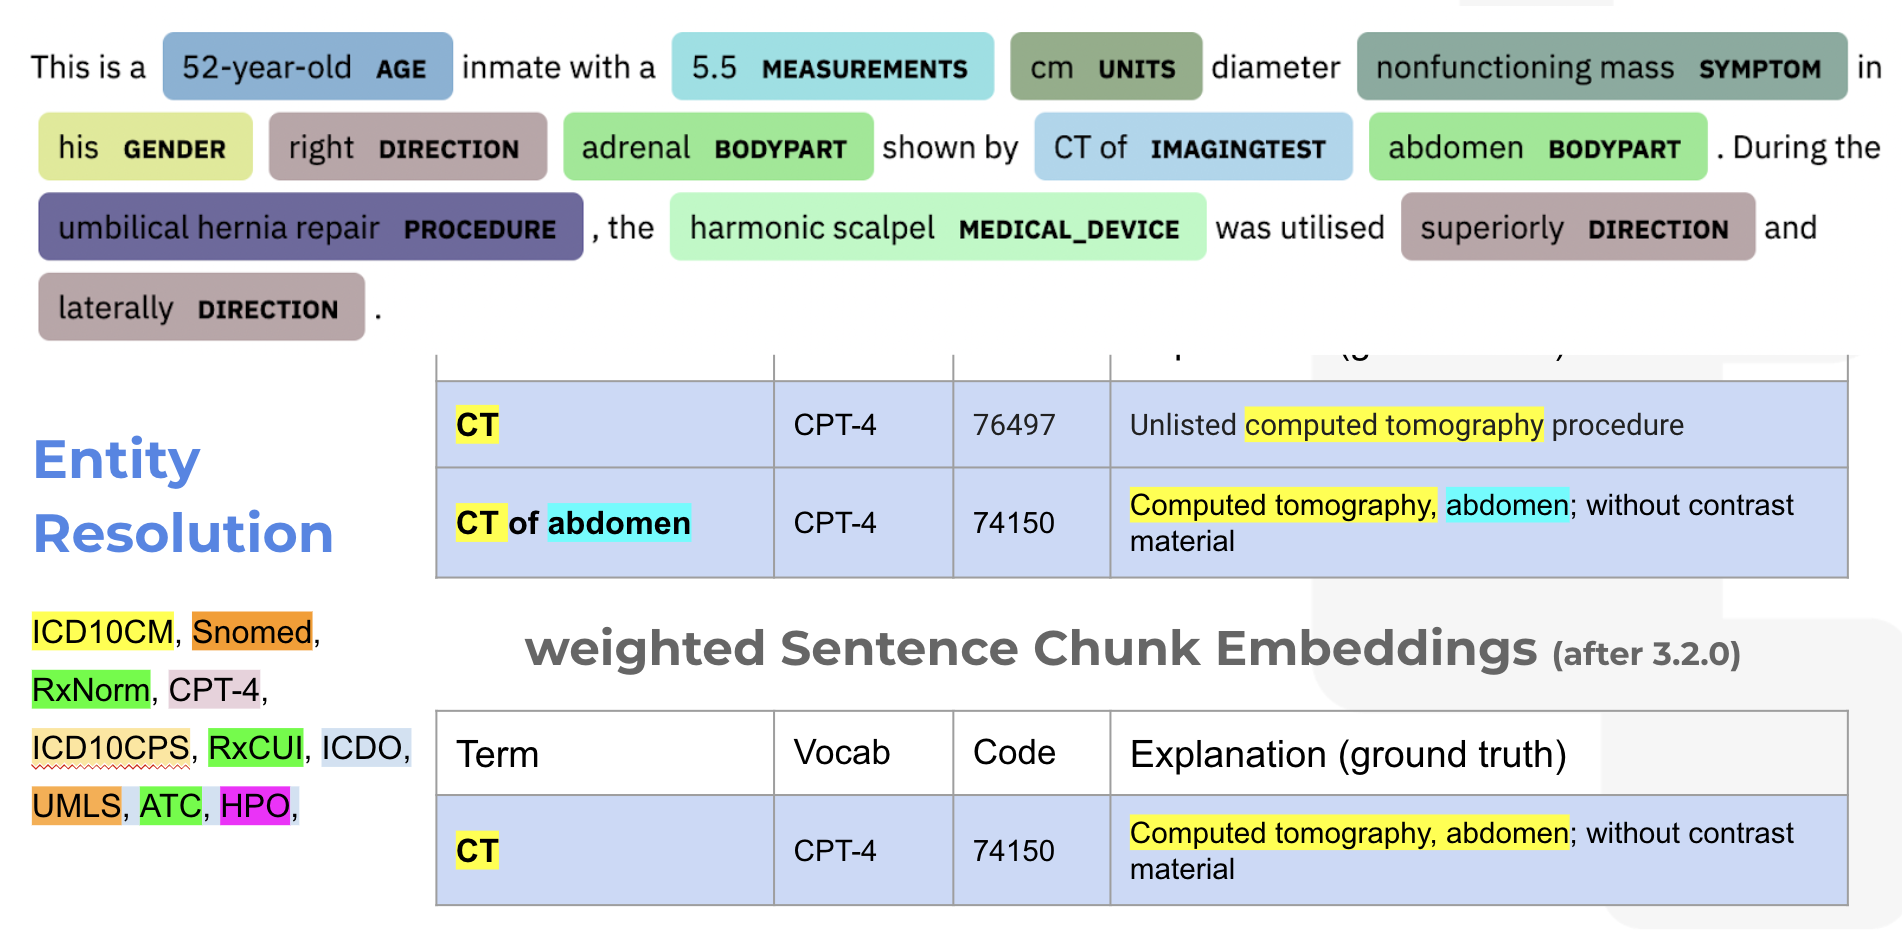

## Sentence Entity Resolver Models

**Entity Resolvers in SparkNLP**
- RxNorm
- ICD10-CM
- ICD-9-CM
- CPT
- SNOMED
- LOINC
- UMLS
- HPO
- HCPCS
- ICD-O
- MeSH
- NDC
- RX-CUI
- ATC


Sparknlp has more than **50 pretrained sentence entity resolver models**

<center><b>MODEL LIST</b>

|index|model|index|model|index|model|index|model|
|-----:|:-----|-----:|:-----|-----:|:-----|-----:|:-----|
| 1| [sbertresolve_icd10cm_augmented](https://nlp.johnsnowlabs.com/2023/05/31/sbertresolve_icd10cm_augmented_en.html)  | 2| [sbertresolve_icd10cm_augmented_billable_hcc](https://nlp.johnsnowlabs.com/2023/05/31/sbertresolve_icd10cm_augmented_billable_hcc_en.html)  | 3| [sbertresolve_icd10cm_slim_billable_hcc](https://nlp.johnsnowlabs.com/2023/05/31/sbertresolve_icd10cm_slim_billable_hcc_en.html)  | 4| [sbertresolve_icd10cm_slim_billable_hcc_med](https://nlp.johnsnowlabs.com/2021/05/25/sbertresolve_icd10cm_slim_billable_hcc_med_en.html)  |
| 5| [sbertresolve_jsl_rxnorm_augmented_med](https://nlp.johnsnowlabs.com/2021/12/28/sbertresolve_jsl_rxnorm_augmented_med_en.html)  | 6| [sbertresolve_ner_model_finder](https://nlp.johnsnowlabs.com/2022/09/05/sbertresolve_ner_model_finder_en.html)  | 7| [sbertresolve_rxnorm_disposition](https://nlp.johnsnowlabs.com/2021/08/28/sbertresolve_rxnorm_disposition_en.html)  | 8| [sbertresolve_snomed_bodyStructure_med](https://nlp.johnsnowlabs.com/2021/06/15/sbertresolve_snomed_bodyStructure_med_en.html)  |
| 9| [sbertresolve_snomed_conditions](https://nlp.johnsnowlabs.com/2024/03/04/sbertresolve_snomed_conditions_en.html)  | 10| [sbiobert_jsl_rxnorm_cased](https://nlp.johnsnowlabs.com/2021/12/23/sbiobert_jsl_rxnorm_cased_en.html)  | 11| [sbiobertresolve_HPO](https://nlp.johnsnowlabs.com/2021/05/16/sbiobertresolve_HPO_en.html)  | 12| [sbiobertresolve_atc](https://nlp.johnsnowlabs.com/2022/03/01/sbiobertresolve_atc_en_3_0.html)  |
| 13| [sbiobertresolve_clinical_abbreviation_acronym](https://nlp.johnsnowlabs.com/2022/01/03/sbiobertresolve_clinical_abbreviation_acronym_en.html)  | 14| [sbiobertresolve_clinical_snomed_procedures_measurements](https://nlp.johnsnowlabs.com/2021/11/15/sbiobertresolve_clinical_snomed_procedures_measurements_en.html)  | 15| [sbiobertresolve_cpt](https://nlp.johnsnowlabs.com/2020/11/27/sbiobertresolve_cpt_en.html)  | 16| [sbiobertresolve_cpt_augmented](https://nlp.johnsnowlabs.com/2021/05/30/sbiobertresolve_cpt_augmented_en.html)  |
| 17| [sbiobertresolve_cpt_procedures_augmented](https://nlp.johnsnowlabs.com/2021/05/30/sbiobertresolve_cpt_procedures_augmented_en.html)  | 18| [sbiobertresolve_cpt_procedures_measurements_augmented](https://nlp.johnsnowlabs.com/2022/05/10/sbiobertresolve_cpt_procedures_measurements_augmented_en_3_0.html)  | 19| [sbiobertresolve_cvx](https://nlp.johnsnowlabs.com/2022/10/12/sbiobertresolve_cvx_en.html)  | 20| [sbiobertresolve_hcc_augmented](https://nlp.johnsnowlabs.com/2023/05/31/sbiobertresolve_hcc_augmented_en.html)  |
| 21| [sbiobertresolve_hcpcs](https://nlp.johnsnowlabs.com/2021/09/29/sbiobertresolve_hcpcs_en.html)  | 22| [sbiobertresolve_hgnc](https://nlp.johnsnowlabs.com/2023/03/26/sbiobertresolve_hgnc_en.html)  | 23| [sbiobertresolve_icd10cm](https://nlp.johnsnowlabs.com/2020/11/27/sbiobertresolve_icd10cm_en.html)  | 24| [sbiobertresolve_icd10cm_augmented](https://nlp.johnsnowlabs.com/2021/10/31/sbiobertresolve_icd10cm_augmented_en.html)  |
| 25| [sbiobertresolve_icd10cm_augmented_billable_hcc](https://nlp.johnsnowlabs.com/2021/11/01/sbiobertresolve_icd10cm_augmented_billable_hcc_en.html)  | 26| [sbiobertresolve_icd10cm_generalised](https://nlp.johnsnowlabs.com/2021/09/29/sbiobertresolve_icd10cm_generalised_en.html)  | 27| [sbiobertresolve_icd10cm_generalised_augmented](https://nlp.johnsnowlabs.com/2023/05/31/sbiobertresolve_icd10cm_generalised_augmented_en.html)  | 28| [sbiobertresolve_icd10cm_slim_billable_hcc](https://nlp.johnsnowlabs.com/2023/05/31/sbiobertresolve_icd10cm_slim_billable_hcc_en.html)  |
| 29| [sbiobertresolve_icd10cm_slim_normalized](https://nlp.johnsnowlabs.com/2021/05/17/sbiobertresolve_icd10cm_slim_normalized_en.html)  | 30| [sbiobertresolve_icd10pcs](https://nlp.johnsnowlabs.com/2020/11/27/sbiobertresolve_icd10pcs_en.html)  | 31| [sbiobertresolve_icd10pcs_augmented](https://nlp.johnsnowlabs.com/2022/10/28/sbiobertresolve_icd10pcs_augmented_en.html)  | 32| [sbiobertresolve_icd9](https://nlp.johnsnowlabs.com/2022/09/30/sbiobertresolve_icd9_en.html)  |
| 33| [sbiobertresolve_icdo](https://nlp.johnsnowlabs.com/2020/11/27/sbiobertresolve_icdo_en.html)  | 34| [sbiobertresolve_icdo_augmented](https://nlp.johnsnowlabs.com/2021/06/22/sbiobertresolve_icdo_augmented_en.html)  | 35| [sbiobertresolve_icdo_base](https://nlp.johnsnowlabs.com/2021/07/02/sbiobertresolve_icdo_base_en.html)  | 36| [sbiobertresolve_jsl_rxnorm_augmented](https://nlp.johnsnowlabs.com/2021/12/27/sbiobertresolve_jsl_rxnorm_augmented_en.html)  |
| 37| [sbiobertresolve_loinc](https://nlp.johnsnowlabs.com/2021/05/16/sbiobertresolve_loinc_en.html)  | 38| [sbiobertresolve_loinc_augmented](https://nlp.johnsnowlabs.com/2021/11/23/sbiobertresolve_loinc_augmented_en.html)  | 39| [sbiobertresolve_loinc_cased](https://nlp.johnsnowlabs.com/2021/12/24/sbiobertresolve_loinc_cased_en.html) |40|[sbiobertresolve_loinc_numeric ](https://nlp.johnsnowlabs.com/2023/08/01/sbiobertresolve_loinc_numeric_en.html)|
| 41| [sbiobertresolve_mesh](https://nlp.johnsnowlabs.com/2021/11/14/sbiobertresolve_mesh_en.html)  | 42| [sbiobertresolve_ncit](https://nlp.johnsnowlabs.com/2023/03/26/sbiobertresolve_ncit_en.html)  | 43| [sbiobertresolve_ndc](https://nlp.johnsnowlabs.com/2021/11/27/sbiobertresolve_ndc_en.html)  | 44| [sbiobertresolve_rxcui](https://nlp.johnsnowlabs.com/2021/05/16/sbiobertresolve_rxcui_en.html)  
| 45| [sbiobertresolve_rxnorm](https://nlp.johnsnowlabs.com/2021/10/10/sbiobertresolve_rxnorm_en.html)  | 46| [sbiobertresolve_rxnorm_action_treatment](https://nlp.johnsnowlabs.com/2022/04/25/sbiobertresolve_rxnorm_action_treatment_en_2_4.html)  | 47| [sbiobertresolve_rxnorm_augmented](https://nlp.johnsnowlabs.com/2022/01/03/sbiobertresolve_rxnorm_augmented_en.html) | 48|[sbiobertresolve_rxnorm_augmented_cased](https://nlp.johnsnowlabs.com/2021/12/28/sbiobertresolve_rxnorm_augmented_cased_en.html)  
| 49| [sbiobertresolve_rxnorm_augmented_re](https://nlp.johnsnowlabs.com/2022/02/09/sbiobertresolve_rxnorm_augmented_re_en.html)  |50| [sbiobertresolve_rxnorm_disposition](https://nlp.johnsnowlabs.com/2021/08/12/sbiobertresolve_rxnorm_disposition_en.html)  | 51| [sbiobertresolve_rxnorm_ndc](https://nlp.johnsnowlabs.com/2021/10/05/sbiobertresolve_rxnorm_ndc_en.html)  | 52| [sbiobertresolve_rxnorm_nih](https://nlp.johnsnowlabs.com/2023/02/22/sbiobertresolve_rxnorm_nih_en.html)  
| 53| [sbiobertresolve_snomed_auxConcepts](https://nlp.johnsnowlabs.com/2024/02/14/sbiobertresolve_snomed_auxConcepts_en.html) | 54| [sbiobertresolve_snomed_auxConcepts_int](https://nlp.johnsnowlabs.com/2020/11/27/sbiobertresolve_snomed_auxConcepts_int_en.html)  | 55| [sbiobertresolve_snomed_bodyStructure](https://nlp.johnsnowlabs.com/2024/03/04/sbiobertresolve_snomed_bodyStructure_en.html)|56| [sbiobertresolve_snomed_drug](https://nlp.johnsnowlabs.com/2024/03/06/sbiobertresolve_snomed_drug_en.html)  
| 57| [sbiobertresolve_snomed_findings](https://nlp.johnsnowlabs.com/2024/02/06/sbiobertresolve_snomed_findings_en.html)  |58| [sbiobertresolve_snomed_findings_aux_concepts](https://nlp.johnsnowlabs.com/2024/02/14/sbiobertresolve_snomed_findings_auxConcepts_en.html)  | 59| [sbiobertresolve_snomed_findings_int](https://nlp.johnsnowlabs.com/2020/11/27/sbiobertresolve_snomed_findings_int_en.html)| 60| [sbiobertresolve_snomed_procedures_measurements](https://nlp.johnsnowlabs.com/2024/02/08/sbiobertresolve_snomed_procedures_measurements_en.html)  
| 61| [sbiobertresolve_umls_clinical_drugs](https://nlp.johnsnowlabs.com/2021/10/11/sbiobertresolve_umls_clinical_drugs_en.html)  |62|[sbiobertresolve_umls_disease_syndrome](https://nlp.johnsnowlabs.com/2021/10/11/sbiobertresolve_umls_disease_syndrome_en.html)  | 63| [sbiobertresolve_umls_drug_substance](https://nlp.johnsnowlabs.com/2021/12/06/sbiobertresolve_umls_drug_substance_en.html) | 64| [sbiobertresolve_umls_findings](https://nlp.johnsnowlabs.com/2021/10/03/sbiobertresolve_umls_findings_en.html)  
| 65| [sbiobertresolve_umls_major_concepts](https://nlp.johnsnowlabs.com/2021/10/03/sbiobertresolve_umls_major_concepts_en.html)  | 66| [sbluebertresolve_loinc](https://nlp.johnsnowlabs.com/2021/04/29/sbluebertresolve_loinc_en.html)  | 67| [sbluebertresolve_loinc_uncased](https://nlp.johnsnowlabs.com/2022/01/18/sbluebertresolve_loinc_uncased_en.html)  | 68|[sbluebertresolve_rxnorm_augmented_uncased](https://nlp.johnsnowlabs.com/2021/12/28/sbluebertresolve_rxnorm_augmented_uncased_en.html)
| 69| [icd10cm_snomed_mapper](https://nlp.johnsnowlabs.com/2022/06/26/icd10cm_snomed_mapper_en_3_0.html)  | 70| [icdo_snomed_mapper](https://nlp.johnsnowlabs.com/2022/06/26/icdo_snomed_mapper_en_3_0.html)  | 71| [ner_snomed_term](https://nlp.johnsnowlabs.com/2024/02/13/ner_snomed_term_en.html)  | 72| [robertaresolve_snomed](https://nlp.johnsnowlabs.com/2021/11/03/robertaresolve_snomed_es.html)  
| 73| [sbertresolve_snomed](https://nlp.johnsnowlabs.com/2021/09/16/sbertresolve_snomed_de.html)  | 74| [sbiobertresolve_snomed_no_class](https://nlp.johnsnowlabs.com/2024/03/05/sbiobertresolve_snomed_no_class_en.html)   | 75|   [umls_rxnorm_mapper_en](https://nlp.johnsnowlabs.com/2024/03/13/umls_rxnorm_mapper_en.html	)   | 76| [snomed_icd10cm_mapper](https://nlp.johnsnowlabs.com/2022/06/26/snomed_icd10cm_mapper_en_3_0.html)  
| 77| [snomed_icd10cm_mapping](https://nlp.johnsnowlabs.com/2021/05/02/snomed_icd10cm_mapping_en.html)   | 78| [snomed_umls_mapper](https://nlp.johnsnowlabs.com/2022/06/27/snomed_umls_mapper_en_3_0.html)   | 79| [snomed_icdo_mapper](https://nlp.johnsnowlabs.com/2022/06/26/snomed_icdo_mapper_en_3_0.html) | 80| [sbiobertresolve_snomed_conditions](https://nlp.johnsnowlabs.com/2024/03/04/sbiobertresolve_snomed_conditions_en.html)  
| 81| [sbiobertresolve_snomed_drug](https://nlp.johnsnowlabs.com/2024/03/06/sbiobertresolve_snomed_drug_en.html)  | 82| [sbiobertresolve_snomed_findings](https://nlp.johnsnowlabs.com/2020/11/27/sbiobertresolve_snomed_findings_en.html)  | 83| [sbiobertresolve_snomed_findings_auxConcepts](https://nlp.johnsnowlabs.com/2024/02/14/sbiobertresolve_snomed_findings_auxConcepts_en.html)  | 84| [sbiobertresolve_snomed_findings_aux_concepts](https://nlp.johnsnowlabs.com/2024/03/06/sbiobertresolve_snomed_findings_aux_concepts_en.html)  
| 85| [umls_snomed_mapper](https://nlp.johnsnowlabs.com/2023/10/17/umls_snomed_mapper_en.html)
<br>
<br>

<b>PRETRAINED PIPELINE LIST</b>

|index|model|index|model|index|model|index|model|
|-----:|:-----|-----:|:-----|-----:|:-----|-----:|:-----|
| 1| [cvx_resolver_pipeline](https://nlp.johnsnowlabs.com/2022/10/12/cvx_resolver_pipeline_en.html)  | 2| [hcc_resolver_pipeline](https://nlp.johnsnowlabs.com/2024/01/17/hcc_resolver_pipeline_en.html)  | 3| [hcpcs_resolver_pipeline](https://nlp.johnsnowlabs.com/2024/01/30/hcpcs_resolver_pipeline_en.html)  | 4| [hgnc_resolver_pipeline](https://nlp.johnsnowlabs.com/2024/01/30/hgnc_resolver_pipeline_en.html)  |
| 5| [hpo_resolver_pipeline](https://nlp.johnsnowlabs.com/2024/01/18/hpo_resolver_pipeline_en.html)  | 6| [icd10cm_generalised_resolver_pipeline](https://nlp.johnsnowlabs.com/2024/01/30/icd10cm_generalised_resolver_pipeline_en.html)  | 7| [icd10cm_resolver_pipeline](https://nlp.johnsnowlabs.com/2022/11/02/icd10cm_resolver_pipeline_en.html)  | 8| [icd10cm_rxnorm_resolver_pipeline](https://nlp.johnsnowlabs.com/2024/03/07/icd10cm_rxnorm_resolver_pipeline_en.html)  |
| 9| [icd10cm_snomed_mapping](https://nlp.johnsnowlabs.com/2023/03/29/icd10cm_snomed_mapping_en.html)  | 10| [icd10gm_resolver_pipeline](https://nlp.johnsnowlabs.com/2023/07/01/icd10gm_resolver_pipeline_de.html)  | 11| [icd10pcs_resolver_pipeline](https://nlp.johnsnowlabs.com/2024/02/02/icd10pcs_resolver_pipeline_en.html)  | 12| [icd9_resolver_pipeline](https://nlp.johnsnowlabs.com/2022/09/30/icd9_resolver_pipeline_en.html)  
| 13| [icdo_resolver_pipeline](https://nlp.johnsnowlabs.com/2024/02/02/icdo_resolver_pipeline_en.html)  | 14| [icdo_snomed_mapping](https://nlp.johnsnowlabs.com/2023/03/29/icdo_snomed_mapping_en.html) | 15| [loinc_numeric_resolver_pipeline](https://nlp.johnsnowlabs.com/2024/01/30/loinc_numeric_resolver_pipeline_en.html)  | 16| [loinc_resolver_pipeline](https://nlp.johnsnowlabs.com/2024/02/02/loinc_resolver_pipeline_en.html)  
| 17| [meddra_llt_resolver_pipeline](https://nlp.johnsnowlabs.com/2024/03/26/meddra_llt_resolver_pipeline_en.html)  | 18| [meddra_pt_resolver_pipeline](https://nlp.johnsnowlabs.com/2024/03/26/meddra_pt_resolver_pipeline_en.html)  | 19| [medication_resolver_pipeline](https://nlp.johnsnowlabs.com/2022/09/01/medication_resolver_pipeline_en.html)  | 20| [medication_resolver_transform_pipeline](https://nlp.johnsnowlabs.com/2022/09/01/medication_resolver_transform_pipeline_en.html)  
| 21| [mesh_resolver_pipeline](https://nlp.johnsnowlabs.com/2024/01/25/mesh_resolver_pipeline_en.html)  | 22| [ncit_resolver_pipeline](https://nlp.johnsnowlabs.com/2024/02/01/ncit_resolver_pipeline_en.html)  | 23| [ndc_resolver_pipeline](https://nlp.johnsnowlabs.com/2024/01/25/ndc_resolver_pipeline_en.html)  | 24| [rxcui_resolver_pipeline](https://nlp.johnsnowlabs.com/2024/02/01/rxcui_resolver_pipeline_en.html)  
| 25| [rxnorm_mesh_mapping](https://nlp.johnsnowlabs.com/2021/05/04/rxnorm_mesh_mapping_en.html)  | 26| [rxnorm_multi_mapper_pipeline](https://nlp.johnsnowlabs.com/2023/08/16/rxnorm_multi_mapper_pipeline_en.html)  | 27| [rxnorm_ndc_mapping](https://nlp.johnsnowlabs.com/2023/03/29/rxnorm_ndc_mapping_en.html)  | 28| [rxnorm_resolver_pipeline](https://nlp.johnsnowlabs.com/2023/08/16/rxnorm_resolver_pipeline_en.html)  
| 29| [rxnorm_umls_mapping](https://nlp.johnsnowlabs.com/2023/03/29/rxnorm_umls_mapping_en.html)  | 30| [snomed_auxConcepts_resolver_pipeline](https://nlp.johnsnowlabs.com/2024/03/12/snomed_auxConcepts_resolver_pipeline_en.html)  | 31| [snomed_body_structure_resolver_pipeline](https://nlp.johnsnowlabs.com/2024/03/05/snomed_body_structure_resolver_pipeline_en.html)  | 32| [snomed_conditions_resolver_pipeline](https://nlp.johnsnowlabs.com/2024/03/11/snomed_conditions_resolver_pipeline_en.html)  
| 33| [snomed_drug_resolver_pipeline](https://nlp.johnsnowlabs.com/2024/03/11/snomed_drug_resolver_pipeline_en.html)  | 34| [snomed_findings_resolver_pipeline](https://nlp.johnsnowlabs.com/2024/03/03/snomed_findings_resolver_pipeline_en.html)   | 35| [snomed_icdo_mapping](https://nlp.johnsnowlabs.com/2023/03/29/snomed_icdo_mapping_en.html)  | 36| [snomed_multi_mapper_pipeline](https://nlp.johnsnowlabs.com/2023/08/16/snomed_multi_mapper_pipeline_en.html)  
| 37| [snomed_procedures_measurements_resolver_pipeline](https://nlp.johnsnowlabs.com/2024/01/31/snomed_procedures_measurements_resolver_pipeline_en.html)  | 38| [snomed_resolver_pipeline](https://nlp.johnsnowlabs.com/2024/03/11/snomed_resolver_pipeline_en.html)  | 39| [snomed_term_resolver_pipeline](https://nlp.johnsnowlabs.com/2024/03/22/snomed_term_resolver_pipeline_en.html)  | 40| [snomed_umls_mapping](https://nlp.johnsnowlabs.com/2023/03/29/snomed_umls_mapping_en.html)  
| 41| [umls_clinical_findings_resolver_pipeline](https://nlp.johnsnowlabs.com/2023/03/30/umls_clinical_findings_resolver_pipeline_en.html)  | 42| [umls_disease_syndrome_resolver_pipeline](https://nlp.johnsnowlabs.com/2023/03/30/umls_disease_syndrome_resolver_pipeline_en.html)  | 43| [umls_drug_resolver_pipeline](https://nlp.johnsnowlabs.com/2023/03/29/umls_drug_resolver_pipeline_en.html)  | 44| [umls_drug_substance_resolver_pipeline](https://nlp.johnsnowlabs.com/2023/03/30/umls_drug_substance_resolver_pipeline_en.html)  
| 45| [umls_major_concepts_resolver_pipeline](https://nlp.johnsnowlabs.com/2023/03/30/umls_major_concepts_resolver_pipeline_en.html)  |






</center>

You can find all resolver models and more on [Models Hub](https://nlp.johnsnowlabs.com/models?task=Entity+Resolution&edition=Spark+NLP+for+Healthcare) page.

Our pipelines provide more metadata about the matching process other than providing the code in the "result" field;

- target_text -> Text to resolve
- resolved_text -> Best match text
- confidence -> Relative confidence for the top match (distance to probability)
- confidence_ratio -> Relative confidence for the top match. TopMatchConfidence / SecondMatchConfidence
- alternative_codes -> List of other plausible codes (in the KNN neighborhood)
- all_k_resolutions -> All codes descriptions
- all_k_results -> All resolved codes for metrics calculation purposes
- sentence -> SentenceId

We create a pipeline that from each of these problems, will try to assign a resolution on the content, the sentence embeddings and some pretrained models for resolver annotation.

The architecture of this new pipeline will be as follows:

- DocumentAssembler (text -> document)

- SentenceDetector (document -> sentence)

- Tokenizer (sentence -> token)

- WordEmbeddingsModel ([sentence, token] -> embeddings)

- MedicalNerModel ([sentence, token, embeddings] -> ner)

- NerConverter (["sentence, token, ner] -> ner_chunk

- Chunk2Doc (ner_chunk) -> ner_chunk_doc

- BertSentenceEmbeddings (ner_chunk_doc) -> sbert_embeddings

- SentenceEntityResolverModel ([ner_chunk, sbert_embeddings] -> resolution)

So from a text we end having a list of Named Entities (ner_chunk) and their resolutions.

`setPreservePosition(True)` takes exactly the original indices (under some tokenization conditions it might include some undesires chars like `")","]"...)`

`setPreservePosition(False)` takes adjusted indices based on substring indexing of the first (for begin) and last (for end) tokens


Let's see how we build a resolver pipeline

Firstly, we will write some **generic functions** for getting the codes and relation pairs

In [ ]:
# returns LP resolution results

import pandas as pd
pd.set_option('display.max_colwidth', 0)


def get_codes (lp, text, vocab='icd10cm_code', col_name="ner_chunk", hcc=False):

    full_light_result = lp.fullAnnotate(text)

    chunks = []
    codes = []
    begin = []
    end = []
    resolutions=[]
    all_distances =[]
    all_codes=[]
    all_cosines = []
    all_k_aux_labels=[]

    for chunk, code in zip(full_light_result[0][col_name], full_light_result[0][vocab]):

        begin.append(chunk.begin)
        end.append(chunk.end)
        chunks.append(chunk.result)
        codes.append(code.result)
        all_codes.append(code.metadata['all_k_results'].split(':::'))
        resolutions.append(code.metadata['all_k_resolutions'].split(':::'))
        all_distances.append(code.metadata['all_k_distances'].split(':::'))
        all_cosines.append(code.metadata['all_k_cosine_distances'].split(':::'))
        if hcc:
            try:
                all_k_aux_labels.append(code.metadata['all_k_aux_labels'].split(':::'))
            except:
                all_k_aux_labels.append([])
        else:
            all_k_aux_labels.append([])

    df = pd.DataFrame({'chunks':chunks, 'begin': begin, 'end':end, 'code':codes, 'all_codes':all_codes,
                       'resolutions':resolutions, 'all_k_aux_labels':all_k_aux_labels,'all_distances':all_cosines})

    if hcc:

        df['billable'] = df['all_k_aux_labels'].apply(lambda x: [i.split('||')[0] for i in x])
        df['hcc_status'] = df['all_k_aux_labels'].apply(lambda x: [i.split('||')[1] for i in x])
        df['hcc_code'] = df['all_k_aux_labels'].apply(lambda x: [i.split('||')[2] for i in x])

    df = df.drop(['all_k_aux_labels'], axis=1)

    return df



In [ ]:
# returns spark df resolution results

def get_codes_from_df(result_df, chunk, output_col, hcc= False):


    if hcc:

        df = result_df.select(F.explode(F.arrays_zip(result_df[chunk].result,
                                                     result_df[chunk].metadata,
                                                     result_df[output_col].result,
                                                     result_df[output_col].metadata)).alias("cols")) \
                      .select(F.expr("cols['1']['sentence']").alias("sent_id"),
                              F.expr("cols['0']").alias("ner_chunk"),
                              F.expr("cols['1']['entity']").alias("entity"),
                              F.expr("cols['2']").alias("icd10_code"),
                              F.expr("cols['3']['all_k_results']").alias("all_codes"),
                              F.expr("cols['3']['all_k_resolutions']").alias("resolutions"),
                              F.expr("cols['3']['all_k_aux_labels']").alias("hcc_list")).toPandas()



        codes = []
        resolutions = []
        hcc_all = []

        for code, resolution, hcc in zip(df['all_codes'], df['resolutions'], df['hcc_list']):

            codes.append(code.split(':::'))
            resolutions.append(resolution.split(':::'))
            hcc_all.append(hcc.split(":::"))

        df['all_codes'] = codes
        df['resolutions'] = resolutions
        df['hcc_list'] = hcc_all

    else:

        df = result_df.select(F.explode(F.arrays_zip(result_df[chunk].result,
                                                     result_df[chunk].metadata,
                                                     result_df[output_col].result,
                                                     result_df[output_col].metadata)).alias("cols")) \
                                     .select(F.expr("cols['1']['sentence']").alias("sent_id"),
                                             F.expr("cols['0']").alias("ner_chunk"),
                                             F.expr("cols['1']['entity']").alias("entity"),
                                             F.expr("cols['2']").alias(f"{output_col}"),
                                             F.expr("cols['3']['all_k_results']").alias("all_codes"),
                                             F.expr("cols['3']['all_k_resolutions']").alias("resolutions")).toPandas()

        codes = []
        resolutions = []

        for code, resolution in zip(df['all_codes'], df['resolutions']):

            codes.append(code.split(':::'))
            resolutions.append(resolution.split(':::'))

        df['all_codes'] = codes
        df['resolutions'] = resolutions


    return df


In [ ]:
# returns billable informations in distinct columns

def extract_billable(bil):

    billable = []
    status = []
    code = []

    for b in bil:
        billable.append(b.split("||")[0])
        status.append(b.split("||")[1])
        code.append(b.split("||")[2])

    return (billable, status, code)

In [ ]:
# returns relation pair dataframe

def get_relations_df (results, col='relations'):
    rel_pairs=[]
    for rel in results[0][col]:
        rel_pairs.append((
          rel.metadata['entity1'],
          rel.metadata['entity1_begin'],
          rel.metadata['entity1_end'],
          rel.metadata['chunk1'],
          rel.metadata['entity2'],
          rel.metadata['entity2_begin'],
          rel.metadata['entity2_end'],
          rel.metadata['chunk2'],
          rel.metadata['confidence']
        ))

    rel_df = pd.DataFrame(rel_pairs, columns=['entity1','entity1_begin','entity1_end','chunk1',
                                              'entity2','entity2_end','entity2_end','chunk2',
                                              'confidence'])

    # limit df columns to get entity and chunks with results only
    rel_df = rel_df.iloc[:,[0,3,4,7,8]]

    return rel_df

### RxNorm Resolver

- RxNorm is a second vocabulary for prescription drugs. RxNorm provides a set of codes for clinical drugs, which are the combination of active ingredients, dose form, and strength of a drug. For example, the RxNorm code for ciprofloxacin 500 mg 24-hour extended-release tablet (the generic name for Cipro XR 500 mg) is RX10359383, regardless of brand or packaging.

- The goal of RxNorm is to allow computer systems to communicate drug-related information efficiently and unambiguously. Produced by the National Library of Medicine (NLM), RxNorm is available for distribution in both Metathesaurus Relation (MR) and Rich Release Format (RRF) tables. Currently there are no RxNorm names available for drugs with more than four active ingredients, those that are sold over the counter (OTC) or those that are international, due to the lack of appropriate information available about such drugs.


<img src="https://www.nlm.nih.gov/research/umls/rxnorm/RxNorm_Drug_Relationships.png" width="750" alt="RxNorm Overview">

**Pretrained Models**

- `sbiobertresolve_rxnorm`
- `demo_sbiobertresolve_rxnorm`
- `sbiobertresolve_rxnorm_dispo`
- `sbiobertresolve_rxnorm_disposition`
- `sbertresolve_rxnorm_disposition`
- `sbiobertresolve_rxnorm_ndc`
- `sbiobertresolve_rxnorm_augmented`
- `sbiobertresolve_rxnorm_augmented_re`

Now, we will create a pipeline with `sbiobertresolve_rxnorm_augmented` pretrained model and see the results.

In [ ]:
documentAssembler = nlp.DocumentAssembler()\
      .setInputCol("text")\
      .setOutputCol("ner_chunk")

sbert_embedder = nlp.BertSentenceEmbeddings.pretrained('sbiobert_base_cased_mli', 'en','clinical/models')\
      .setInputCols(["ner_chunk"])\
      .setOutputCol("sentence_embeddings")\
      .setCaseSensitive(False)

rxnorm_resolver = medical.SentenceEntityResolverModel.pretrained("sbiobertresolve_rxnorm_augmented","en", "clinical/models") \
      .setInputCols(["ner_chunk", "sentence_embeddings"]) \
      .setOutputCol("rxnorm_code")\
      .setDistanceFunction("EUCLIDEAN")

rxnorm_pipelineModel = nlp.PipelineModel(
      stages = [
          documentAssembler,
          sbert_embedder,
          rxnorm_resolver])

rxnorm_lp = nlp.LightPipeline(rxnorm_pipelineModel)

sbiobert_base_cased_mli download started this may take some time.
Approximate size to download 384.3 MB
[OK!]
sbiobertresolve_rxnorm_augmented download started this may take some time.
[OK!]
setInputCols in ENTITY_3feb01c2d233 expecting 1 columns. Provided column amount: 2. Which should be columns from the following annotators: ['sentence_embeddings']


Checking the results with the help of our helper functions

In [ ]:
text = 'metformin 100 mg'

%time get_codes (rxnorm_lp, text, col_name = 'ner_chunk', vocab='rxnorm_code')

CPU times: user 18.9 ms, sys: 5.5 ms, total: 24.4 ms
Wall time: 1.15 s


,chunks,begin,end,code,all_codes,resolutions,all_distances
0,metformin 100 mg,0,15,861024,"[861024, 2200518, 141916, 334738, 332848, 104494, 861026, 199955, 333262, 429178, 439563, 103910, 429408, 450523, 1744000, 401938, 402346, 485246, 1726496, 198758, 316350, 213092, 858858, 245936, 336846]","[metformin hydrochloride 100 mg/ml [metformin hydrochloride 100 mg/ml], metformin hydrochloride 100 MG/ML Extended Release Suspension, fenofibrate 100 MG Oral Capsule, fenofibrate 100 mg [fenofibrate 100 mg], ciprofibrate 100 mg [ciprofibrate 100 mg], ciprofibrate 100 MG Oral Tablet, metformin hydrochloride 100 mg/ml [riomet] [metformin hydrochloride 100 mg/ml [riomet]], rutin 100 MG Oral Tablet, rutin 100 mg [rutin 100 mg], fendiline 100 MG Oral Tablet, fendiline 100 mg [fendiline 100 mg], carbamazepine 100 MG Oral Tablet [Epimaz], perazine 100 MG Oral Tablet, perazine 100 mg [perazine 100 mg], emtricitabine 100 mg [emtricitabine 100 mg], miglustat 100 MG Oral Capsule, miglustat 100 mg [miglustat 100 mg], azacitidine 100 MG Injection, azacitidine 100 mg [azacitidine 100 mg], niacin 100 MG Oral Capsule, niacin 100 mg [niacin 100 mg], dolasetron 100 MG Oral Tablet [Anzemet], carnosine 100 mg [carnosine 100 mg], trimebutine 100 MG Oral Tablet, trimebutine 100 mg [trimebutine 100 mg]]","[0.0658, 0.0658, 0.0684, 0.0684, 0.0697, 0.0697, 0.0770, 0.0765, 0.0765, 0.0775, 0.0775, 0.0780, 0.0804, 0.0804, 0.0818, 0.0811, 0.0811, 0.0812, 0.0812, 0.0811, 0.0811, 0.0836, 0.0828, 0.0844, 0.0844]"


### RxNorm with DrugNormalizer

We have `DrugNormalizer` annotator that transforms text to the format used in the RxNorm and SNOMED standards.

It has **`policy`** parameter to remove patterns from text. Valid policy values are:
- "all",
- "abbreviations",
- "dosages" <br/>

Default is "all". "abbreviation" policy used to expend common drugs abbreviations, "dosages" policy used to convert drugs dosages and values to the standard form (see examples bellow).

For more details about the usage of `DrugNormalizer` annotator, please visit [this notebook](https://github.com/JohnSnowLabs/spark-nlp-workshop/blob/master/healthcare-nlp/14.0.Drug_Normalizer.ipynb)

In [ ]:
documentAssembler = nlp.DocumentAssembler()\
    .setInputCol("text")\
    .setOutputCol("ner_chunk_v0")

drug_normalizer = medical.DrugNormalizer() \
    .setInputCols("ner_chunk_v0") \
    .setOutputCol("ner_chunk") \
    .setPolicy('all')

rxnorm_pipelineModel2 = nlp.PipelineModel(
    stages = [
        documentAssembler,
        drug_normalizer,
        sbert_embedder,
        rxnorm_resolver])

rxnorm_lp2 = nlp.LightPipeline(rxnorm_pipelineModel2)

In [ ]:
text = 'aspirin 10 meq/ 5 ml oral sol'

%time get_codes (rxnorm_lp2, text, col_name = 'ner_chunk', vocab='rxnorm_code')

CPU times: user 26.4 ms, sys: 6.85 ms, total: 33.2 ms
Wall time: 1.16 s


,chunks,begin,end,code,all_codes,resolutions,all_distances
0,aspirin 2 meq/ml oral solution,0,29,688214,"[688214, 342917, 688213, 755937, 756028, 979446, 755332, 545588, 1091135, 246229, 104692, 755920, 261342, 756064, 756078, 2381144, 1115998]","[aspirin 2.5 mg/ml oral solution [aspirin 2.5 mg/ml oral solution], aspirin 2.2 mg/ml [aspirin 2.2 mg/ml], aspirin 2.5 mg/ml [aspirin 2.5 mg/ml], periciazine 2 mg/ml oral solution [periciazine 2 mg/ml oral solution], fenspiride 2 mg/ml oral solution [fenspiride 2 mg/ml oral solution], alupent 2 mg/ml oral solution [metaproterenol sulfate 2 mg/ml oral solution [alupent]], merbentyl 2 mg/ml oral solution [dicyclomine hydrochloride 2 mg/ml oral solution [merbentyl]], racepinephrine 2 MG/ML Oral Solution [Orostat], methylin 2 mg/ml oral solution [methylphenidate hydrochloride 2 mg/ml oral solution [methylin]], thioridazine 2 mg/ml oral solution [thioridazine 2 mg/ml oral solution], temazepam 2 MG/ML Oral Solution [Euhypnos], butamirate 2 mg/ml oral solution [butamirate 2 mg/ml oral solution], celexa 2 mg/ml oral solution [citalopram 2 mg/ml oral solution [celexa]], oxeladin 2 mg/ml oral solution [oxeladin 2 mg/ml oral solution], pipazethate 2 mg/ml oral solution [pipazethate 2 mg/ml oral solution], fenfluramine 2.2 MG/ML Oral Solution [Fintepla], ephedrine sulfate 2.2 mg/ml oral solution [ephedrine sulfate 2.2 mg/ml oral solution]]","[0.0347, 0.0566, 0.0748, 0.0947, 0.1040, 0.1009, 0.1075, 0.1081, 0.1097, 0.1155, 0.1137, 0.1149, 0.1123, 0.1154, 0.1178, 0.1175, 0.1196]"


### Drug Spell Checker

We have pretrained spell checker model for drugs. Let's see how it works.

In [ ]:
documentAssembler = nlp.DocumentAssembler()\
    .setInputCol("text")\
    .setOutputCol("document")

tokenizer = nlp.Tokenizer()\
    .setInputCols("document")\
    .setOutputCol("token")

spell = nlp.NorvigSweetingModel.pretrained("spellcheck_drug_norvig", "en", "clinical/models")\
    .setInputCols("token")\
    .setOutputCol("corrected_token")\

spell_pipeline = nlp.Pipeline(stages = [documentAssembler,
                              tokenizer,
                              spell])

spell_model = spell_pipeline.fit(spark.createDataFrame([['']]).toDF('text'))

spell_lp = nlp.LightPipeline(spell_model)
corrected = spell_lp.annotate("You have to take Neutrcare and colfosinum and a bit of Fluorometholne & Ribotril")

spellcheck_drug_norvig download started this may take some time.
Approximate size to download 4.3 MB
[OK!]


Checking the results

In [ ]:
print(" ".join(corrected['token']))
print(" ".join(corrected['corrected_token']))

You have to take Neutrcare and colfosinum and a bit of Fluorometholne & Ribotril
You have to take Neutracare and colfosinum and a bit of Fluorometholone & Rivotril


### ICD-10-CM Resolver

**ICD10 BACKGROUND INFO**

**ICD-10-CM vs. ICD-10-PCS**

- With the transition to ICD-10, in the United States, ICD-9 codes are segmented into ICD-10-CM and ICD-10-PCS codes. **The "CM" in ICD-10-CM codes stands for clinical modification**; ICD-10-CM codes were developed by the Centers for Disease Control and Prevention in conjunction with the National Center for Health Statistics (NCHS), for outpatient medical coding and reporting in the United States, as published by the World Health Organization (WHO).

- **The "PCS" in ICD-10-PCS codes stands for the procedural classification system**. ICD-10-PCS is a completely separate medical coding system from ICD-10-CM, containing an additional 87,000 codes for use ONLY in United States inpatient, hospital settings. The procedure classification system (ICD-10-PCS) was developed by the Centers for Medicare and Medicaid Services (CMS) in conjunction with 3M Health Information Management (HIM).

- ICD-10-CM codes add increased specificity to their ICD-9 predecessors, growing to five times the number of codes as the present system; a total of 68,000 clinical modification diagnosis codes. ICD-10-CM codes provide the ability to track and reveal more information about the quality of healthcare, allowing healthcare providers to better understand medical complications, better design treatment and care, and better comprehend and determine the outcome of care.

- ICD-10-PCS is used only for inpatient, hospital settings in the United States, and is meant to replace volume 3 of ICD-9 for facility reporting of inpatient procedures. Due to the rapid and constant state of flux in medical procedures and technology, ICD-10-PCS was developed to accommodate the changing landscape. Common procedures, lab tests, and educational sessions that are not unique to the inpatient, hospital setting have been omitted from ICD-10-PCS.

- ICD-10 is confusing enough when you’re trying to digest the differences between ICD-9 and ICD-10, but there are also different types of ICD-10 codes that providers should be aware of.


**Primary difference between ICD-10-CM and ICD-10-PCS**

- When most people talk about ICD-10, they are referring to ICD-10CM. This is the code set for diagnosis coding and is used for all healthcare settings in the United States. ICD-10PCS, on the other hand, is used in hospital inpatient settings for inpatient procedure coding.

**ICD-10-CM breakdown**

- Approximately 68,000 codes
- 3–7 alphanumeric characters
- Facilitates timely processing of claims


**ICD-10-PCS breakdown**

- Will replace ICD-9-CM for hospital inpatient use only.
- ICD-10-PCS will not replace CPT codes used by physicians. According to HealthCare Information Management, Inc. (HCIM), “Its only intention is to identify inpatient facility services in a way not directly related to physician work, but directed towards allocation of hospital services.”
- 7 alphanumeric characters

- ICD-10-PCS is very different from ICD-9-CM procedure coding due to its ability to be more specific and accurate. “This becomes increasingly important when assessing and tracking the quality of medical processes and outcomes, and compiling statistics that are valuable tools for research,” according to HCIM.

**Hierarchical Condition Category (HCC)**

- Hierarchical condition category (HCC) coding is a risk-adjustment model originally designed to estimate future health care costs for patients. The Centers for Medicare & Medicaid Services (CMS) HCC model was initiated in 2004 but is becoming increasingly prevalent as the environment shifts to value-based payment models.

- Hierarchical condition category relies on ICD-10 coding to assign risk scores to patients. Each HCC is mapped to an ICD-10 code. Along with demographic factors (such as age and gender), insurance companies use HCC coding to assign patients a risk adjustment factor (RAF) score. Using algorithms, insurances can use a patient’s RAF score to predict costs. For example, a patient with few serious health conditions could be expected to have average medical costs for a given time. However, a patient with multiple chronic conditions would be expected to have higher health care utilization and costs.

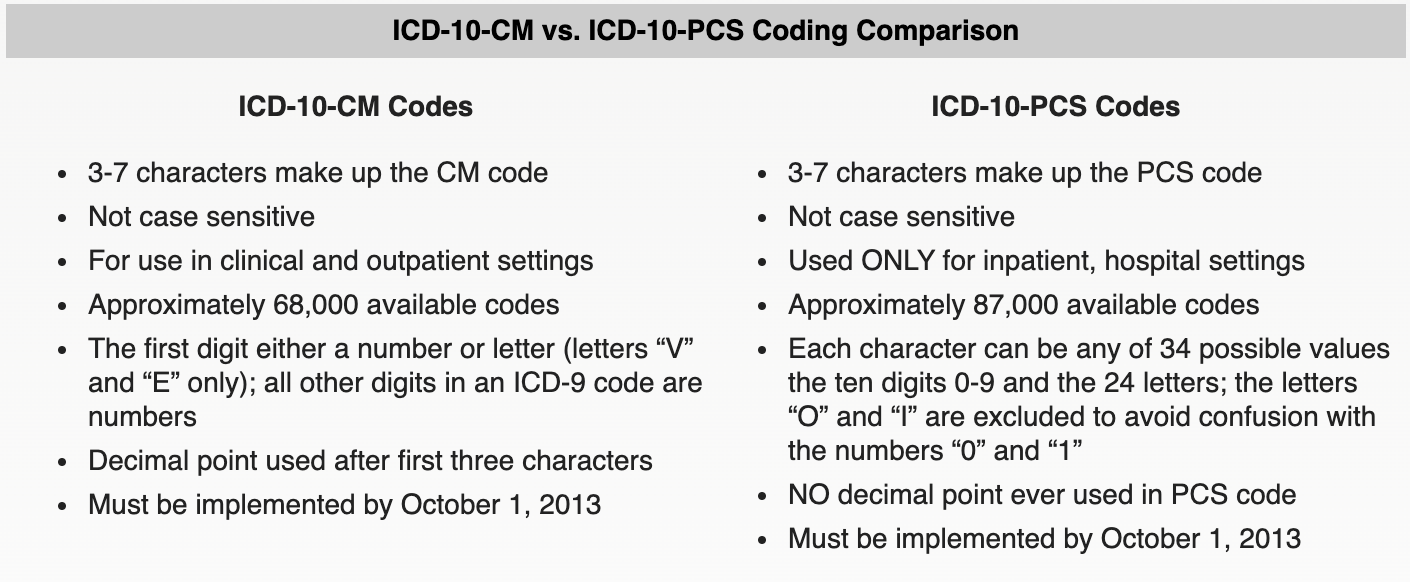

**Pretrained ICD-10 Models**

- `sbiobertresolve_icd10cm_augmented`
- `sbiobertresolve_icd10pcs`
- `sbiobertresolve_icd10cm_augmented_billable_hcc`
- `sbiobertresolve_icd10cm`
- `sbiobertresolve_icd10cm_slim_normalized`
- `sbiobertresolve_icd10cm_slim_billable_hcc`
- `sbertresolve_icd10cm_slim_billable_hcc_med`
- `sbiobertresolve_icd10cm_generalised`

Let's create an ICD10 pipeline with `sbiobertresolve_icd10cm_augmented_billable_hcc` model and see how it works

In [ ]:
# Annotator that transforms a text column from dataframe into an Annotation ready for NLP
document_assembler = nlp.DocumentAssembler()\
    .setInputCol("text")\
    .setOutputCol("document")

# Sentence Detector DL annotator, processes various sentences per line
sentenceDetectorDL = nlp.SentenceDetectorDLModel.pretrained("sentence_detector_dl_healthcare", "en", 'clinical/models') \
    .setInputCols(["document"]) \
    .setOutputCol("sentence")

# Tokenizer splits words in a relevant format for NLP
tokenizer = nlp.Tokenizer()\
    .setInputCols(["sentence"])\
    .setOutputCol("token")

# WordEmbeddingsModel pretrained "embeddings_clinical" includes a model of 1.7Gb that needs to be downloaded
word_embeddings = nlp.WordEmbeddingsModel.pretrained("embeddings_clinical", "en", "clinical/models")\
    .setInputCols(["sentence", "token"])\
    .setOutputCol("word_embeddings")

# Named Entity Recognition for clinical concepts.
clinical_ner = medical.NerModel().pretrained("ner_clinical", "en", "clinical/models") \
    .setInputCols(["sentence", "token", "word_embeddings"]) \
    .setOutputCol("clinical_ner")

clinical_ner_chunk = medical.NerConverterInternal()\
    .setInputCols("sentence","token","clinical_ner")\
    .setOutputCol("clinical_ner_chunk")\
    .setWhiteList(["PROBLEM"])

c2doc = nlp.Chunk2Doc()\
    .setInputCols("clinical_ner_chunk")\
    .setOutputCol("ner_chunk_doc")

sbiobert_embedder = nlp.BertSentenceEmbeddings.pretrained('sbiobert_base_cased_mli', 'en','clinical/models')\
    .setInputCols(["ner_chunk_doc"])\
    .setOutputCol("sentence_embeddings")\
    .setCaseSensitive(False)

icd_resolver = medical.SentenceEntityResolverModel.pretrained("sbiobertresolve_icd10cm_augmented_billable_hcc","en", "clinical/models") \
    .setInputCols(["sentence_embeddings"]) \
    .setOutputCol("icd10cm_code")\
    .setDistanceFunction("EUCLIDEAN")


# Build up the pipeline
resolver_pipeline = nlp.Pipeline(
    stages = [
        document_assembler,
        sentenceDetectorDL,
        tokenizer,
        word_embeddings,
        clinical_ner,
        clinical_ner_chunk,
        c2doc,
        sbiobert_embedder,
        icd_resolver
  ])

icd_model = resolver_pipeline.fit(spark.createDataFrame([['']]).toDF("text"))

sentence_detector_dl_healthcare download started this may take some time.
Approximate size to download 367.3 KB
[OK!]
embeddings_clinical download started this may take some time.
Approximate size to download 1.6 GB
[OK!]
ner_clinical download started this may take some time.
[OK!]
sbiobert_base_cased_mli download started this may take some time.
Approximate size to download 384.3 MB
[OK!]
sbiobertresolve_icd10cm_augmented_billable_hcc download started this may take some time.
[OK!]


In [ ]:
#sample clinical note
clinical_note = (
    'A 28-year-old female with a history of gestational diabetes mellitus diagnosed eight years '
    'prior to presentation and subsequent type two diabetes mellitus, associated '
    'with an acute hepatitis, and obesity with a body mass index (BMI) of 33.5 kg/m2, '
    'presented with a one-week history of polyuria, polydipsia, poor appetite, and vomiting. '
    'Two weeks prior to presentation, she was treated with a five-day course of amoxicillin '
    'for a respiratory tract infection. She had been on dapagliflozin for six months '
    'at the time of presentation. Physical examination on presentation was significant for dry oral mucosa; '
    'significantly, her abdominal examination was benign with no tenderness or guarding. Pertinent '
    'laboratory findings on admission were: serum glucose 111 mg/dl, bicarbonate 18 mmol/l, anion gap 20, '
    'creatinine 0.4 mg/dL, triglycerides 508 mg/dL, total cholesterol 122 mg/dL, glycated hemoglobin (HbA1c) '
    '10%, and venous pH 7.27. Serum lipase was normal at 43 U/L. Serum acetone levels could not be assessed '
    'as blood samples kept hemolyzing due to significant lipemia. The patient was initially admitted for '
    'starvation ketosis, as she reported poor oral intake for three days prior to admission.')

data_ner = spark.createDataFrame([[clinical_note]]).toDF("text")

Transforming the pipeline with clinical note

In [ ]:
icd10_result = icd_model.transform(data_ner)

Checking the results

In [ ]:
%%time
icd10_result.select("icd10cm_code.metadata").show(truncate=100)

+----------------------------------------------------------------------------------------------------+
|                                                                                            metadata|
+----------------------------------------------------------------------------------------------------+
|[{chunk -> 0, all_k_results -> O24.4:::O24.41:::O24.43:::Z86.32:::Z87.5:::O24.31:::O24.11:::O24.1...|
+----------------------------------------------------------------------------------------------------+

CPU times: user 93.9 ms, sys: 17.3 ms, total: 111 ms
Wall time: 17.7 s


In [ ]:
%%time

res_pd = get_codes_from_df(icd10_result, 'clinical_ner_chunk', 'icd10cm_code', hcc=True)

CPU times: user 91.3 ms, sys: 15.8 ms, total: 107 ms
Wall time: 16.5 s


In [ ]:
res_pd.head(10)

,sent_id,ner_chunk,entity,icd10_code,all_codes,resolutions,hcc_list
0,0,gestational diabetes mellitus,PROBLEM,O24.4,"[O24.4, O24.41, O24.43, Z86.32, Z87.5, O24.31, O24.11, O24.1, O24.81]","[gestational diabetes mellitus [gestational diabetes mellitus], gestational diabetes mellitus (disorder) [gestational diabetes mellitus in pregnancy], postpartum gestational diabetes mellitus [gestational diabetes mellitus in the puerperium], history of gestational diabetes mellitus [personal history of gestational diabetes], history of gestational diabetes mellitus (situation) [personal history of complications of pregnancy, childbirth and the puerperium], pre-existing diabetes mellitus in pregnancy [unspecified pre-existing diabetes mellitus in pregnancy], pre-existing diabetes mellitus in pregnancy (disorder) [pre-existing type 2 diabetes mellitus, in pregnancy], pre-existing type 2 diabetes mellitus in pregnancy [pre-existing type 2 diabetes mellitus, in pregnancy, childbirth and the puerperium], other pre-existing diabetes mellitus in pregnancy [other pre-existing diabetes mellitus in pregnancy]]","[0||0||0, 0||0||0, 0||0||0, 1||0||0, 0||0||0, 0||0||0, 0||0||0, 0||0||0, 0||0||0]"
1,0,subsequent type two diabetes mellitus,PROBLEM,O24.11,"[O24.11, E11.8, E11, E13.9, E11.9, E11.3, E11.44, Z86.3, Z86.39, E11.32, E11.43, E11.5]","[pre-existing type 2 diabetes mellitus [pre-existing type 2 diabetes mellitus, in pregnancy], disorder associated with type 2 diabetes mellitus [type 2 diabetes mellitus with unspecified complications], type 2 diabetes mellitus [type 2 diabetes mellitus], secondary diabetes mellitus [other specified diabetes mellitus without complications], diabetes mellitus type 2 [type 2 diabetes mellitus without complications], disorder of eye due to type 2 diabetes mellitus [type 2 diabetes mellitus with ophthalmic complications], disorder of nervous system due to type 2 diabetes mellitus [type 2 diabetes mellitus with diabetic amyotrophy], history of diabetes mellitus type 2 (situation) [personal history of endocrine, nutritional and metabolic diseases], history of diabetes mellitus type 2 [personal history of other endocrine, nutritional and metabolic disease], secondary endocrine diabetes mellitus [type 2 diabetes mellitus with mild nonproliferative diabetic retinopathy], neurological disorder with type 2 diabetes mellitus [type 2 diabetes mellitus with diabetic autonomic (poly)neuropathy], peripheral circulatory disorder due to type 2 diabetes mellitus [type 2 diabetes mellitus with circulatory complications]]","[0||0||0, 1||1||18, 0||0||0, 1||1||19, 1||1||19, 0||0||0, 1||1||18, 0||0||0, 1||0||0, 0||0||0, 1||1||18, 0||0||0]"
2,0,an acute hepatitis,PROBLEM,B15,"[B15, K72.0, B17.9, B17.2, Z03.89, B15.9, K75.2, K71.2, B19.9, B16, K70.1, B16.9]","[acute hepatitis a [acute hepatitis a], acute hepatitis [acute and subacute hepatic failure], acute infectious hepatitis [acute viral hepatitis, unspecified], acute hepatitis e [acute hepatitis e], acute infectious hepatitis suspected [encounter for observation for other suspected diseases and conditions ruled out], acute type a viral hepatitis [hepatitis a without hepatic coma], acute focal hepatitis [nonspecific reactive hepatitis], toxic liver disease with acute hepatitis [toxic liver disease with acute hepatitis], fulminant hepatitis [unspecified viral hepatitis without hepatic coma], acute hepatitis b [acute hepatitis b], acute alcoholic hepatitis [alcoholic hepatitis], acute fulminating viral hepatitis [acute hepatitis b without delta-agent and without hepatic coma]]","[0||0||0, 0||0||0, 1||0||0, 1||0||0, 1||0||0, 1||0||0, 1||0||0, 1||0||0, 1||0||0, 0||0||0, 0||0||0, 1||0||0]"
3,0,obesity,PROBLEM,E66.9,"[E66.9, E66.8, Z68.41, Q13.0, E66, E66.01, Z86.39, E34.9, H35.50, Z83.49, Q55.62, E66.3]","[obesity [obesity, unspecified], abdominal obesity [other obesity], obese [body mass index [bmi] 40.0-44.9, adult], central obesity [coloboma of iris], overweight and obesity [overweight and 

**The values in `billable`, `hcc_code` and `hcc_status` columns are seperated by || and we will change them to a list.**

In [ ]:
res_pd["billable"] = res_pd["hcc_list"].apply(extract_billable).apply(pd.Series).iloc[:,0]
res_pd["hcc_status"] = res_pd["hcc_list"].apply(extract_billable).apply(pd.Series).iloc[:,1]
res_pd["hcc_code"] = res_pd["hcc_list"].apply(extract_billable).apply(pd.Series).iloc[:,2]

res_pd.drop("hcc_list", axis=1, inplace= True)

In [ ]:
res_pd.head(15)

,sent_id,ner_chunk,entity,icd10_code,all_codes,resolutions,billable,hcc_status,hcc_code
0,0,gestational diabetes mellitus,PROBLEM,O24.4,"[O24.4, O24.41, O24.43, Z86.32, Z87.5, O24.31, O24.11, O24.1, O24.81]","[gestational diabetes mellitus [gestational diabetes mellitus], gestational diabetes mellitus (disorder) [gestational diabetes mellitus in pregnancy], postpartum gestational diabetes mellitus [gestational diabetes mellitus in the puerperium], history of gestational diabetes mellitus [personal history of gestational diabetes], history of gestational diabetes mellitus (situation) [personal history of complications of pregnancy, childbirth and the puerperium], pre-existing diabetes mellitus in pregnancy [unspecified pre-existing diabetes mellitus in pregnancy], pre-existing diabetes mellitus in pregnancy (disorder) [pre-existing type 2 diabetes mellitus, in pregnancy], pre-existing type 2 diabetes mellitus in pregnancy [pre-existing type 2 diabetes mellitus, in pregnancy, childbirth and the puerperium], other pre-existing diabetes mellitus in pregnancy [other pre-existing diabetes mellitus in pregnancy]]","[0, 0, 0, 1, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]"
1,0,subsequent type two diabetes mellitus,PROBLEM,O24.11,"[O24.11, E11.8, E11, E13.9, E11.9, E11.3, E11.44, Z86.3, Z86.39, E11.32, E11.43, E11.5]","[pre-existing type 2 diabetes mellitus [pre-existing type 2 diabetes mellitus, in pregnancy], disorder associated with type 2 diabetes mellitus [type 2 diabetes mellitus with unspecified complications], type 2 diabetes mellitus [type 2 diabetes mellitus], secondary diabetes mellitus [other specified diabetes mellitus without complications], diabetes mellitus type 2 [type 2 diabetes mellitus without complications], disorder of eye due to type 2 diabetes mellitus [type 2 diabetes mellitus with ophthalmic complications], disorder of nervous system due to type 2 diabetes mellitus [type 2 diabetes mellitus with diabetic amyotrophy], history of diabetes mellitus type 2 (situation) [personal history of endocrine, nutritional and metabolic diseases], history of diabetes mellitus type 2 [personal history of other endocrine, nutritional and metabolic disease], secondary endocrine diabetes mellitus [type 2 diabetes mellitus with mild nonproliferative diabetic retinopathy], neurological disorder with type 2 diabetes mellitus [type 2 diabetes mellitus with diabetic autonomic (poly)neuropathy], peripheral circulatory disorder due to type 2 diabetes mellitus [type 2 diabetes mellitus with circulatory complications]]","[0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0]","[0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0]","[0, 18, 0, 19, 19, 0, 18, 0, 0, 0, 18, 0]"
2,0,an acute hepatitis,PROBLEM,B15,"[B15, K72.0, B17.9, B17.2, Z03.89, B15.9, K75.2, K71.2, B19.9, B16, K70.1, B16.9]","[acute hepatitis a [acute hepatitis a], acute hepatitis [acute and subacute hepatic failure], acute infectious hepatitis [acute viral hepatitis, unspecified], acute hepatitis e [acute hepatitis e], acute infectious hepatitis suspected [encounter for observation for other suspected diseases and conditions ruled out], acute type a viral hepatitis [hepatitis a without hepatic coma], acute focal hepatitis [nonspecific reactive hepatitis], toxic liver disease with acute hepatitis [toxic liver disease with acute hepatitis], fulminant hepatitis [unspecified viral hepatitis without hepatic coma], acute hepatitis b [acute hepatitis b], acute alcoholic hepatitis [alcoholic hepatitis], acute fulminating viral hepatitis [acute hepatitis b without delta-agent and without hepatic coma]]","[0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
3,0,obesity,PROBLEM,E66.9,"[E66.9, E66.8, Z68.41, Q13.0, E66, E66.01, Z86.39, E34.9, H35.50, Z83.49, Q55.62, E66.3]","[obesity [obesity, unspecified], abdominal obesity [other obesity], obese [body mass index [bmi] 40.0-44.9, adult], central obesity [coloboma of iris], o

### Entity Resolver Visualizer

Let's apply `EntityResolverVisualizer`  by using `sparknlp_display` library to see the results of the pipeline in a nicer layout:

In [ ]:
icd10_lp = nlp.LightPipeline(icd_model)

light_result = icd10_lp.fullAnnotate(clinical_note)

visualiser = nlp.viz.EntityResolverVisualizer()

# Change color of an entity label
visualiser.set_label_colors({'PROBLEM':'#008080'})

visualiser.display(light_result[0], 'clinical_ner_chunk', 'icd10cm_code')

### Router - Using Resolver Models Together

- Normally, when we need to use more than one sentence entity resolver models in the same pipeline, we used to hit `BertSentenceEmbeddings` annotator more than once given the number of different resolver models in the same pipeline. Now we are introducing a solution with the help of `Router` annotator that could allow us to feed all the NER chunks to `BertSentenceEmbeddings` at once and then route the output of Sentence Embeddings to different resolver models needed.

- In this example, lets use `sbiobertresolve_rxnorm_augmented` RxNorm model and `sbiobertresolve_icd10cm_augmented_billable_hcc` ICD10CM-HCC models together. First we will get the `PROBLEM` entities form `ner_clinical` model and then get the `DRUG` entities from `ner_posology` model. Then we will merge them and use the `Chunk2Doc` annotator to create sentence chunks to populate Sentence Embeddings column. Then, we route the embeddings of `PROBLEM` entities to ICD10CM model and embeddings of `DRUG` entities to RxNorm model at the same time.

In [ ]:
documentAssembler = nlp.DocumentAssembler()\
    .setInputCol("text")\
    .setOutputCol("document")

sentenceDetector = nlp.SentenceDetector()\
    .setInputCols("document")\
    .setOutputCol("sentence")

tokenizer = nlp.Tokenizer()\
    .setInputCols("sentence")\
    .setOutputCol("token")

word_embeddings = nlp.WordEmbeddingsModel.pretrained("embeddings_clinical", "en", "clinical/models")\
    .setInputCols("sentence", "token")\
    .setOutputCol("word_embeddings")

# to get PROBLEM entitis
clinical_ner = medical.NerModel().pretrained("ner_clinical", "en", "clinical/models") \
    .setInputCols(["sentence", "token", "word_embeddings"]) \
    .setOutputCol("clinical_ner")

clinical_ner_chunk = medical.NerConverterInternal()\
    .setInputCols("sentence","token","clinical_ner")\
    .setOutputCol("clinical_ner_chunk")\
    .setWhiteList(["PROBLEM"])

# to get DRUG entities
posology_ner = medical.NerModel().pretrained("ner_posology", "en", "clinical/models") \
    .setInputCols(["sentence", "token", "word_embeddings"]) \
    .setOutputCol("posology_ner")

posology_ner_chunk = medical.NerConverterInternal()\
    .setInputCols("sentence","token","posology_ner")\
    .setOutputCol("posology_ner_chunk")\
    .setWhiteList(["DRUG"])

# merge the chunks into a single ner_chunk
chunk_merger = medical.ChunkMergeApproach()\
    .setInputCols("clinical_ner_chunk","posology_ner_chunk")\
    .setOutputCol("final_ner_chunk")\
    .setMergeOverlapping(False)


# convert chunks to doc to get sentence embeddings of them
chunk2doc = nlp.Chunk2Doc()\
    .setInputCols("final_ner_chunk")\
    .setOutputCol("doc_final_chunk")


sbiobert_embeddings = nlp.BertSentenceEmbeddings.pretrained("sbiobert_base_cased_mli","en","clinical/models")\
    .setInputCols(["doc_final_chunk"])\
    .setOutputCol("sbert_embeddings")\
    .setCaseSensitive(False)

# filter PROBLEM entity embeddings
router_sentence_icd10 = medical.Router() \
    .setInputCols("sbert_embeddings") \
    .setFilterFieldsElements(["PROBLEM"]) \
    .setOutputCol("problem_embeddings")

# filter DRUG entity embeddings
router_sentence_rxnorm = medical.Router() \
    .setInputCols("sbert_embeddings") \
    .setFilterFieldsElements(["DRUG"]) \
    .setOutputCol("drug_embeddings")

# use problem_embeddings only
icd_resolver = medical.SentenceEntityResolverModel.pretrained("sbiobertresolve_icd10cm_slim_billable_hcc","en", "clinical/models") \
    .setInputCols(["problem_embeddings"]) \
    .setOutputCol("icd10cm_code")\
    .setDistanceFunction("EUCLIDEAN")


# use drug_embeddings only
rxnorm_resolver = medical.SentenceEntityResolverModel.pretrained("sbiobertresolve_rxnorm_augmented","en", "clinical/models") \
    .setInputCols(["drug_embeddings"]) \
    .setOutputCol("rxnorm_code")\
    .setDistanceFunction("EUCLIDEAN")


pipeline = nlp.Pipeline(
    stages=[
        documentAssembler,
        sentenceDetector,
        tokenizer,
        word_embeddings,
        clinical_ner,
        clinical_ner_chunk,
        posology_ner,
        posology_ner_chunk,
        chunk_merger,
        chunk2doc,
        sbiobert_embeddings,
        router_sentence_icd10,
        router_sentence_rxnorm,
        icd_resolver,
        rxnorm_resolver
])

empty_data = spark.createDataFrame([['']]).toDF("text")
model = pipeline.fit(empty_data)

embeddings_clinical download started this may take some time.
Approximate size to download 1.6 GB
[OK!]
ner_clinical download started this may take some time.
[OK!]
ner_posology download started this may take some time.
[OK!]
sbiobert_base_cased_mli download started this may take some time.
Approximate size to download 384.3 MB
[OK!]
sbiobertresolve_icd10cm_slim_billable_hcc download started this may take some time.
[OK!]
sbiobertresolve_rxnorm_augmented download started this may take some time.
[OK!]


In [ ]:
#sample clinical note
clinical_note = """The patient is a 41-year-old Vietnamese female with a cough that started last week.
She has had right-sided chest pain radiating to her back with fever starting yesterday.
She has a history of pericarditis in May 2006 and developed cough with right-sided chest pain.
MEDICATIONS
1. Coumadin 1 mg daily. Last INR was on Tuesday, August 14, 2007, and her INR was 2.3.
2. Amiodarone 100 mg p.o. daily.
"""

Let's transform and see the results

In [ ]:
df = spark.createDataFrame([[clinical_note]]).toDF("text")

result = model.transform(df)

In [ ]:
%%time

icd10_result = get_codes_from_df(result, 'clinical_ner_chunk', 'icd10cm_code', hcc=True)

CPU times: user 51.4 ms, sys: 15.2 ms, total: 66.6 ms
Wall time: 4.32 s


In [ ]:
# extract HCC informationinto different columns

icd10_result["billable"] = icd10_result["hcc_list"].apply(extract_billable).apply(pd.Series).iloc[:,0]
icd10_result["hcc_status"] = icd10_result["hcc_list"].apply(extract_billable).apply(pd.Series).iloc[:,1]
icd10_result["hcc_code"] = icd10_result["hcc_list"].apply(extract_billable).apply(pd.Series).iloc[:,2]

icd10_result.drop("hcc_list", axis=1, inplace= True)

In [ ]:
icd10_result.head(15)

,sent_id,ner_chunk,entity,icd10_code,all_codes,resolutions,billable,hcc_status,hcc_code
0,0,a cough,PROBLEM,R05,"[R05, R05.3, R05.1, A37, R05.2, R06.01, R06.7, R06.0, R06.2, R06, J38.4, R05.4, G44.83, R00.2, R06.00, R07.1, R07.0, R09.81, R12, S22.5, R49.0, R07, L29, R06.83, G47.51]","[cough [cough], chronic cough [chronic cough], acute cough [acute cough], whooping cough [whooping cough], subacute cough [subacute cough], orthopnea [orthopnea], sneezing [sneezing], dyspnea [dyspnea], wheezing [wheezing], abnormalities of breathing [abnormalities of breathing], edema of larynx [edema of larynx], cough syncope [cough syncope], primary cough headache [primary cough headache], palpitations [palpitations], dyspnea, unspecified [dyspnea, unspecified], chest pain on breathing [chest pain on breathing], pain in throat [pain in throat], nasal congestion [nasal congestion], heartburn [heartburn], flail chest [flail chest], dysphonia [dysphonia], pain in throat and chest [pain in throat and chest], pruritus [pruritus], snoring [snoring], confusional arousals [confusional arousals]]","[0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
1,1,right-sided chest pain,PROBLEM,R10.11,"[R10.11, M79.621, M79.604, M79.601, M25.511, M79.631, R07.1, M79.661, M79.651, M25.551, M79.641, M25.531, G90.511, M79.644, H57.11, M25.541, R10.31, R07.8, R07.89, M25.521, M25.561, G90.521, R07.2, I83.811, M79.671]","[right upper quadrant pain [right upper quadrant pain], pain in right upper arm [pain in right upper arm], pain in right leg [pain in right leg], pain in right arm [pain in right arm], pain in right shoulder [pain in right shoulder], pain in right forearm [pain in right forearm], chest pain on breathing [chest pain on breathing], pain in right lower leg [pain in right lower leg], pain in right thigh [pain in right thigh], pain in right hip [pain in right hip], pain in right hand [pain in right hand], pain in right wrist [pain in right wrist], complex regional pain syndrome i of right upper limb [complex regional pain syndrome i of right upper limb], pain in right finger(s) [pain in right finger(s)], ocular pain, right eye [ocular pain, right eye], pain in joints of right hand [pain in joints of right hand], right lower quadrant pain [right lower quadrant pain], other chest pain [other chest pain], other chest pain [other chest pain], pain in right elbow [pain in right elbow], pain in right knee [pain in right knee], complex regional pain syndrome i of right lower limb [complex regional pain syndrome i of right lower limb], precordial pain [precordial pain], varicose veins of right lower extremity with pain [varicose veins of right lower extremity with pain], pain in right foot [pain in right foot]]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
2,1,fever,PROBLEM,A68,"[A68, A78, R50.2, M04.1, A96.2, A68.9, R11.0, T67.7, A79.0, A92.1, R50.82, R50.9, R51, R50.8, T67.6, R50.83, R60.1, R10.81, A68.0, R09.81, A92.4, L29, R10.817, A95, R23.1]","[relapsing fevers [relapsing fevers], q fever [q fever], drug induced fever [drug induced fever], periodic fever syndromes [periodic fever syndromes], lassa fever [lassa fever], relapsing fever, unspecified [relapsing fever, unspecified], nausea [nausea], heat edema [heat edema], trench fever [trench fever], o'nyong-nyong fever [o'nyong-nyong fever], postprocedural fever [postprocedural fever], fever, unspecified [fever, unspecified], headache [headache], other specified fever [other specified fever], heat fatigue, transient [heat fatigue, transient], postvaccination fever [postvaccination fever], generalized edema [generalized edema], abdominal tenderness 

Now let's get RxNorm codes from our results.

In [ ]:
rxnorm_result = get_codes_from_df(result, 'posology_ner_chunk', 'rxnorm_code', hcc=False)

rxnorm_result.head()

,sent_id,ner_chunk,entity,rxnorm_code,all_codes,resolutions
0,4,Coumadin,DRUG,202421,"[202421, 2898, 374998, 1855075, 128793, 1598, 152085, 218274, 21732, 375868, 1435932, 227590, 202392, 374560, 87866, 1603522, 5011, 54908, 402786, 216785, 370743, 154, 202862, 151531, 1317116]","[coumadin [coumadin], coumarin [coumarin], coumarin Oral Tablet, coumaran [coumaran], vicodin [vicodin], dicoumarol [dicumarol], mycifradin [mycifradin], medcodin [medcodin], cresatin [cresatin], cresatin Oral Solution, reumacetin [reumacetin], geocillin [geocillin], garamycin [garamycin], ardeparin Injectable Solution, ardeparin [ardeparin], glabridin [glabridin], gramicidin [gramicidin], policresulen [policresulen], policresulen Vaginal Gel, duraganidin nr [duraganidin nr], acenocoumarol Oral Tablet, acenocoumarol [acenocoumarol], cleocin [cleocin], codafen [codafen], velafermin [velafermin]]"
1,6,Amiodarone,DRUG,703,"[703, 1663223, 1151983, 1663270, 1151982, 203114, 377132, 1151981, 832845, 727379, 370568, 620, 1944369, 151347, 722, 370575, 1000082, 1000084, 5936, 832848, 374399, 833534, 2184119, 17767]","[amiodarone [amiodarone], amiodarone Injection, amiodarone pill [amiodarone pill], amiodarone injection [nexterone] [amiodarone injection [nexterone]], amiodarone oral product [amiodarone oral product], amiodarone hydrochloride [amiodarone hydrochloride], amiodarone injectable solution [amiodarone injectable solution], amiodarone injectable product [amiodarone injectable product], amiodarone injectable solution [nexterone] [amiodarone injectable solution [nexterone]], amiodarone prefilled syringe [amiodarone prefilled syringe], amiodarone oral tablet [amiodarone oral tablet], amantadine [amantadine], amantadine Extended Release Oral Capsule, amsidine [amsidine], amoxapine [amoxapine], amoxapine Oral Tablet, alcaftadine [alcaftadine], alcaftadine Ophthalmic Solution, adipiodone [iodipamide], amiodarone prefilled syringe [nexterone] [amiodarone prefilled syringe [nexterone]], adenosine injectable solution [adenosine injectable solution], amiodarone injectable solution [cordarone] [amiodarone injectable solution [cordarone]], amlodipine Oral Suspension, amlodipine [amlodipine]]"


### Sentence Entity Resolvers with EntityChunkEmbedding

**Entity Chunk Embeddings** uses BERT Sentence embeddings to compute a weighted average vector represention of related entity chunks. This model is a subclass of `BertSentenceEmbeddings` and shares all parameters with it. It can load any pretrained `BertSentenceEmbeddings` model.

The input of the model consists of chunks of recognized named entities. One or more entities are selected as target entities and for each of them a list of related entities is specified (if empty, all other entities are assumed to be related).

 The model looks for chunks of the target entities and then tries to pair each target entity (e.g. DRUG) with other related entities (e.g. DOSAGE, STRENGTH, FORM, etc). The criterion for pairing a target entity with another related entity is that they appear in the same sentence and the **maximal syntactic distance** is below a predefined threshold.

The relationship between target and related entities is one-to-many, meaning that if there are multiple instances of the same target entity (e.g. DRUG) within a sentence, the model will map a related entity (e.g. DOSAGE) to at most one of the instances of the target entity.

For example, if there is a sentence; "The patient was given 125 mg of paracetamol and metformin", the model will pair "125 mg" to "paracetamol", but not to "metformin". The output of the model is an average embeddings of the chunks of each of the target entities and their related entities. It is possible to specify a particular weight for each entity type. An entity can be defined both as target a entity and as a related entity for some other target entity.

For more details please see the  [Sentence_Entity_Resolvers_with_EntityChunkEmbeddings](https://github.com/JohnSnowLabs/spark-nlp-workshop/blob/master/healthcare-nlp/05.4.Sentence_Entity_Resolvers_with_EntityChunkEmbeddings.ipynb) notebook.

### Healthcare Codes Mapping by Using Pretrained Pipelines

|index|model|
|-----:|:-----|
| 1| [icd10_icd9_mapping](https://nlp.johnsnowlabs.com/2022/09/30/icd10_icd9_mapping_en.html)   |
| 2| [icdo_snomed_mapping](https://nlp.johnsnowlabs.com/2022/06/27/icdo_snomed_mapping_en_3_0.html)   |
| 3| [icd10cm_snomed_mapping](https://nlp.johnsnowlabs.com/2022/06/27/icd10cm_snomed_mapping_en_3_0.html)   |
| 4| [rxnorm_ndc_mapping](https://nlp.johnsnowlabs.com/2022/06/27/rxnorm_ndc_mapping_en_3_0.html)   |
| 5| [rxnorm_umls_mapping](https://nlp.johnsnowlabs.com/2022/06/27/rxnorm_umls_mapping_en_3_0.html)   |
| 6| [snomed_icd10cm_mapping](https://nlp.johnsnowlabs.com/2022/06/27/snomed_icd10cm_mapping_en_3_0.html)   |
| 7| [snomed_icdo_mapping](https://nlp.johnsnowlabs.com/2022/06/27/snomed_icdo_mapping_en_3_0.html)   |
| 8| [snomed_umls_mapping](https://nlp.johnsnowlabs.com/2022/06/27/snomed_umls_mapping_en_3_0.html)   |
| 9| [icd10cm_umls_mapping](https://nlp.johnsnowlabs.com/2022/06/27/icd10cm_umls_mapping_en_3_0.html)   |
| 10| [mesh_umls_mapping](https://nlp.johnsnowlabs.com/2021/07/01/mesh_umls_mapping_en.html)   |
| 11| [rxnorm_mesh_mapping](https://nlp.johnsnowlabs.com/2021/07/01/rxnorm_mesh_mapping_en.html)   |


**You can find all these models and more [NLP Models Hub](https://nlp.johnsnowlabs.com/models?q=Chunk+Mapping&edition=Spark+NLP+for+Healthcare)**


Lets show an example of ICD codes mapping to Snomed Codes to show how these pipelines work.

In [ ]:
icd10_snomed_pipeline = nlp.PretrainedPipeline("icd10cm_snomed_mapping", "en", "clinical/models")

icd10cm_snomed_mapping download started this may take some time.
Approx size to download 1 MB
[OK!]


In [ ]:
icd10_snomed_pipeline.annotate('M8950 E119 H16269')

{'document': ['M8950 E119 H16269'],
 'icd10cm_code': ['M8950', 'E119', 'H16269'],
 'snomed_code': ['716868003', '170771004', '51264003']}

|**ICD10CM Code** | **ICD10CM Details** | **SNOMED Code** | **SNOMED Details** |
| ---------- | -----------:| ---------- | -----------:|
| M8950 |  Osteolysis, unspecified site | 716868003 | Multicentric osteolysis nodulosis arthropathy spectrum |
| E119 | Type 2 diabetes mellitus | 170771004 | Diabetic - follow-up default |
| H16269 | Vernal keratoconjunctivitis, with limbar and corneal involvement, unspecified eye | 51264003 | Limbal AND/OR corneal involvement in vernal conjunctivitis |


Also, if you want to see more examples, please check [this notebook](https://github.com/JohnSnowLabs/spark-nlp-workshop/blob/master/tutorials/Certification_Trainings/Healthcare/11.1.Healthcare_Code_Mapping.ipynb).



# 7.Chunk Mapping

We can use ChunkMapper to map entities with their associated code/reference based on pre-defined dictionaries.

There is an AnnotatorApproach of the ChunkMapper,  `ChunkMapperApproach`,  which can be used to train ChunkMapper models by giving a custom mapping dictionary. To use pretriained models, there is a `ChunkMapperModel` annotator.

The annotator also allows using **fuzzy matching**, which can take into consideration parts of the tokens that can map even when word order is different, char ngrams that can map even when there are typos, and using fuzzy distance metric (Jaccard, Levenshtein, etc.).

### Pretrained ChunkMapper Models

**<center>MAPPER MODELS**

|index|model|index|model|index|model|
|-----:|:-----|-----:|:-----|-----:|:-----|
| 1| [abbreviation_category_mapper](https://nlp.johnsnowlabs.com/2022/11/16/abbreviation_category_mapper_en.html)  | 2| [abbreviation_mapper](https://nlp.johnsnowlabs.com/2022/05/11/abbreviation_mapper_en_3_0.html)  | 3| [cvx_code_mapper](https://nlp.johnsnowlabs.com/2022/10/12/cvx_code_mapper_en.html)  |
| 4| [cvx_name_mapper](https://nlp.johnsnowlabs.com/2022/10/12/cvx_name_mapper_en.html)  | 5| [drug_action_treatment_mapper](https://nlp.johnsnowlabs.com/2022/03/31/drug_action_treatment_mapper_en_3_0.html)  | 6| [drug_ade_mapper](https://nlp.johnsnowlabs.com/2022/08/23/drug_ade_mapper_en.html)  |
| 7| [drug_brandname_ndc_mapper](https://nlp.johnsnowlabs.com/2022/05/11/drug_brandname_ndc_mapper_en_3_0.html)  | 8| [drug_category_mapper](https://nlp.johnsnowlabs.com/2022/12/18/drug_category_mapper_en.html)  | 9| [icd10_icd9_mapper](https://nlp.johnsnowlabs.com/2022/09/30/icd10_icd9_mapper_en.html)  |
| 10| [icd10cm_mapper](https://nlp.johnsnowlabs.com/2022/10/29/icd10cm_mapper_en.html)  | 11| [icd10cm_snomed_mapper](https://nlp.johnsnowlabs.com/2022/06/26/icd10cm_snomed_mapper_en_3_0.html)  | 12| [icd10cm_umls_mapper](https://nlp.johnsnowlabs.com/2022/06/26/icd10cm_umls_mapper_en_3_0.html)  |
| 13| [icd9_icd10_mapper](https://nlp.johnsnowlabs.com/2022/09/30/icd9_icd10_mapper_en.html)  | 14| [icd9_mapper](https://nlp.johnsnowlabs.com/2022/09/30/icd9_mapper_en.html)  | 15| [icdo_snomed_mapper](https://nlp.johnsnowlabs.com/2022/06/26/icdo_snomed_mapper_en_3_0.html)  |
| 16| [kegg_disease_mapper](https://nlp.johnsnowlabs.com/2022/11/18/kegg_disease_mapper_en.html)  | 17| [kegg_drug_mapper](https://nlp.johnsnowlabs.com/2022/11/21/kegg_drug_mapper_en.html)  | 18| [mesh_umls_mapper](https://nlp.johnsnowlabs.com/2022/06/26/mesh_umls_mapper_en_3_0.html)  |
| 19| [ndc_drug_brandname_mapper](https://nlp.johnsnowlabs.com/2023/02/22/ndc_drug_brandname_mapper_en.html)  | 20| [normalized_section_header_mapper](https://nlp.johnsnowlabs.com/2022/06/26/normalized_section_header_mapper_en_3_0.html)  | 21| [rxnorm_action_treatment_mapper](https://nlp.johnsnowlabs.com/2022/05/08/rxnorm_action_treatment_mapper_en_3_0.html)  |
| 22| [rxnorm_drug_brandname_mapper](https://nlp.johnsnowlabs.com/2023/02/09/rxnorm_drug_brandname_mapper_en.html)  | 23| [rxnorm_mapper](https://nlp.johnsnowlabs.com/2022/06/27/rxnorm_mapper_en_3_0.html)  | 24| [rxnorm_ndc_mapper](https://nlp.johnsnowlabs.com/2022/05/20/rxnorm_ndc_mapper_en_3_0.html)  |
| 25| [rxnorm_nih_mapper](https://nlp.johnsnowlabs.com/2023/02/23/rxnorm_nih_mapper_en.html)  | 26| [rxnorm_normalized_mapper](https://nlp.johnsnowlabs.com/2022/09/29/rxnorm_normalized_mapper_en.html)  | 27| [rxnorm_umls_mapper](https://nlp.johnsnowlabs.com/2022/06/26/rxnorm_umls_mapper_en_3_0.html)  |
| 28| [snomed_icd10cm_mapper](https://nlp.johnsnowlabs.com/2022/06/26/snomed_icd10cm_mapper_en_3_0.html)  | 29| [snomed_icdo_mapper](https://nlp.johnsnowlabs.com/2022/06/26/snomed_icdo_mapper_en_3_0.html)  | 30| [snomed_umls_mapper](https://nlp.johnsnowlabs.com/2022/06/27/snomed_umls_mapper_en_3_0.html)  |
| 31| [umls_clinical_drugs_mapper](https://nlp.johnsnowlabs.com/2022/07/06/umls_clinical_drugs_mapper_en_3_0.html)  | 32| [umls_clinical_findings_mapper](https://nlp.johnsnowlabs.com/2022/07/08/umls_clinical_findings_mapper_en_3_0.html)  | 33| [umls_disease_syndrome_mapper](https://nlp.johnsnowlabs.com/2022/07/11/umls_disease_syndrome_mapper_en_3_0.html)  |
| 34| [umls_drug_substance_mapper](https://nlp.johnsnowlabs.com/2022/07/11/umls_drug_substance_mapper_en_3_0.html)  | 35| [umls_major_concepts_mapper](https://nlp.johnsnowlabs.com/2022/07/11/umls_major_concepts_mapper_en_3_0.html)  | 36| []()|

**You can find all these models and more [NLP Models Hub](https://nlp.johnsnowlabs.com/models?q=Chunk+Mapping&edition=Spark+NLP+for+Healthcare)**

<br>

**<center>PRETRAINED MAPPER PIPELINES**

|index|model|
|-----:|:-----|
| 1| [icd10_icd9_mapping](https://nlp.johnsnowlabs.com/2022/09/30/icd10_icd9_mapping_en.html)  |
| 2| [icd10cm_snomed_mapping](https://nlp.johnsnowlabs.com/2022/06/27/icd10cm_snomed_mapping_en_3_0.html)  |
| 3| [icd10cm_umls_mapping](https://nlp.johnsnowlabs.com/2021/05/04/icd10cm_umls_mapping_en.html)  |
| 4| [icdo_snomed_mapping](https://nlp.johnsnowlabs.com/2022/06/27/icdo_snomed_mapping_en_3_0.html)  |
| 5| [mesh_umls_mapping](https://nlp.johnsnowlabs.com/2021/05/04/mesh_umls_mapping_en.html)  |
| 6| [rxnorm_mesh_mapping](https://nlp.johnsnowlabs.com/2021/05/04/rxnorm_mesh_mapping_en.html)  |
| 7| [rxnorm_ndc_mapping](https://nlp.johnsnowlabs.com/2022/06/27/rxnorm_ndc_mapping_en_3_0.html)  |
| 8| [rxnorm_umls_mapping](https://nlp.johnsnowlabs.com/2021/05/04/rxnorm_umls_mapping_en.html)  |
| 9| [snomed_icd10cm_mapping](https://nlp.johnsnowlabs.com/2021/05/02/snomed_icd10cm_mapping_en.html)  |
| 10| [snomed_icdo_mapping](https://nlp.johnsnowlabs.com/2022/06/27/snomed_icdo_mapping_en_3_0.html)  |
| 11| [snomed_umls_mapping](https://nlp.johnsnowlabs.com/2021/05/04/snomed_umls_mapping_en.html)  |



You can check [Healthcare Code Mapping Notebook](https://github.com/JohnSnowLabs/spark-nlp-workshop/blob/master/healthcare-nlp/06.1.Code_Mapping_Pipelines.ipynb) for the examples of pretrained mapper pipelines.

Let's create a piepline with `drug_action_treatment_mapper` and see how it works.

Pretrained `drug_action_treatment_mapper` model maps drugs with their corresponding `action` and `treatment` through `ChunkMapperModel()` annotator. <br/>

We will create a pipeline consisting `bert_token_classifier_drug_development_trials` ner model to extract ner chunk as well as `ChunkMapperModel()`.

In [ ]:
#ChunkMapper Pipeline
document_assembler = nlp.DocumentAssembler()\
      .setInputCol('text')\
      .setOutputCol('document')

sentence_detector = nlp.SentenceDetector()\
      .setInputCols(["document"])\
      .setOutputCol("sentence")

tokenizer = nlp.Tokenizer()\
      .setInputCols("sentence")\
      .setOutputCol("token")

btfc_ner =  medical.BertForTokenClassification.pretrained("bert_token_classifier_drug_development_trials", "en", "clinical/models")\
      .setInputCols("token","sentence")\
      .setOutputCol("btfc_ner")

btfc_ner_converter = nlp.NerConverter()\
      .setInputCols("sentence", "token", "btfc_ner")\
      .setOutputCol("btfc_ner_chunk")

#drug_action_treatment_mapper
chunkerMapper= medical.ChunkMapperModel().pretrained("drug_action_treatment_mapper", "en", "clinical/models")\
    .setInputCols(["btfc_ner_chunk"])\
    .setOutputCol("mappings")\
    .setRels(["action", "treatment"])


mapperPipeline = nlp.Pipeline().setStages([
    document_assembler,
    sentence_detector,
    tokenizer,
    btfc_ner,
    btfc_ner_converter,
    chunkerMapper])


test_data = spark.createDataFrame([["The patient was female and patient of Dr. X. and she was given Dermovate, Aspagin"]]).toDF("text")

res = mapperPipeline.fit(test_data).transform(test_data)

bert_token_classifier_drug_development_trials download started this may take some time.
[OK!]
drug_action_treatment_mapper download started this may take some time.
[OK!]


Drugs detected by ner model

In [ ]:
res.select(F.explode('btfc_ner_chunk.result').alias("chunks")).show(truncate=False)

+---------+
|chunks   |
+---------+
|Dermovate|
|Aspagin  |
+---------+



Checking the mapping results for **action** and **treatment** <br/>

if exist, we can see all the mappings for each chunk under the metadata column.

In [ ]:
res.select(F.explode(F.arrays_zip(res.mappings.result,
                                  res.mappings.metadata)).alias("col"))\
    .select(F.expr("col['1']['entity']").alias("ner_chunk"),
            F.expr("col['0']").alias("mapping_result"),
            F.expr("col['1']['relation']").alias("relation"),
            F.expr("col['1']['all_relations']").alias("all_mappings")).show(truncate=False)

+-----------+----------------------+---------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|ner_chunk  |mapping_result        |relation |all_mappings                                                                                                                                                                                                           |
+-----------+----------------------+---------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|Trial_Group|anti-inflammatory     |action   |corticosteroids::: dermatological preparations:::very strong                                                                                                         

### Chunk Mapping with Fuzzy Distance Calculation

We will create a sample text with a typo in the "dermovae", then will feed the `drug_action_treatment_mapper` model with fuzzy matching feature to map **action** of each drug.

Also, we can modify the `setAllowMultiTokenChunk()` parameter to control matching of multi-token chunks. We will check that feature by observing the "Warfarina Lusa".

In [ ]:
sample_text= "The patient was female and patient of Dr. X. and she was given dermovae, Warfarina Lusa"
test_data = spark.createDataFrame([[sample_text]]).toDF("text")


In [ ]:
chunkerMapper_fuzzy = medical.ChunkMapperModel.pretrained("drug_action_treatment_mapper", "en", "clinical/models")\
    .setInputCols(["btfc_ner_chunk"])\
    .setOutputCol("mappings")\
    .setRels(["action"]) \
    .setAllowMultiTokenChunk(True) \
    .setEnableFuzzyMatching(True) \
    .setFuzzyMatchingDistanceThresholds(0.3)


mapperPipeline = nlp.Pipeline().setStages([
    document_assembler,
    sentence_detector,
    tokenizer,
    btfc_ner,
    btfc_ner_converter,
    chunkerMapper_fuzzy])


fuzzy_res = mapperPipeline.fit(test_data).transform(test_data)

drug_action_treatment_mapper download started this may take some time.
[OK!]


In [ ]:
fuzzy_res.select(F.explode(F.arrays_zip(fuzzy_res.mappings.result,
                                        fuzzy_res.mappings.metadata)).alias("col"))\
    .select(F.expr("col['1']['entity']").alias("ner_chunk"),
            F.expr("col['1']['__trained__']").alias("fixed_chunk"),
            F.expr("col['0']").alias("action_mapping_result"),
            F.expr("col['1']['relation']").alias("relation ")).show(truncate=False)

+-----------+--------------+---------------------+---------+
|ner_chunk  |fixed_chunk   |action_mapping_result|relation |
+-----------+--------------+---------------------+---------+
|Trial_Group|dermovat      |anti-inflammatory    |action   |
|Trial_Group|dermatovate   |anti-inflammatory    |action   |
|Trial_Group|dermovate     |anti-inflammatory    |action   |
|Trial_Group|dermovel      |antiallergic         |action   |
|Trial_Group|Warfarina Lusa|anticoagulant        |action   |
+-----------+--------------+---------------------+---------+



As seen above, mapper model was able to return mappings based on fuzzy matching even though there is a typo in "dermovae". <br/>

Also, it returned mappings for "Warfarina Lusa" since we set `setAllowMultiTokenChunk(True)` parameter.

### Creating a Mapper Model

There is a `ChunkMapperApproach()` to create your own mapper model. <br/>

This receives an `ner_chunk` and a Json with a mapping of ner entities and relations, and returns the `ner_chunk` augmented with the relations from the Json ontology. <br/> We give the path of json file to the `setDictionary()` parameter.




Let's create an example Json, then create a drug mapper model. This model will match the given drug name (only "metformin" for our example) with correpsonding action and treatment.  

The format of json file should be like following:


In [ ]:
data_set = {
  "mappings": [
    {
      "key": "metformin",
      "relations": [
        {
          "key": "action",
          "values" : ["hypoglycemic", "Drugs Used In Diabetes"]
        },
        {
          "key": "treatment",
          "values" : ["diabetes", "t2dm"]
        }
      ]
    }
  ]
}

import json
with open('sample_drug.json', 'w', encoding='utf-8') as f:
    json.dump(data_set, f, ensure_ascii=False, indent=4)

By using `setRels()` parameter, we tell the model which type of mappings we want. In our case, we set the parameter as `setRels(["action", "treatment"])`.

Also, we can manage the case status while creating a model by using `setLowerCase()` parameter.

Let's create a pipeline and see it in action.

In [ ]:
document_assembler = nlp.DocumentAssembler()\
      .setInputCol('text')\
      .setOutputCol('document')

sentence_detector = nlp.SentenceDetector()\
      .setInputCols(["document"])\
      .setOutputCol("sentence")

tokenizer = nlp.Tokenizer()\
      .setInputCols("sentence")\
      .setOutputCol("token")

word_embeddings = nlp.WordEmbeddingsModel.pretrained("embeddings_clinical", "en", "clinical/models")\
      .setInputCols(["sentence", "token"])\
      .setOutputCol("embeddings")

posology_ner_model = medical.NerModel.pretrained("ner_posology_large", "en", "clinical/models")\
    .setInputCols(["sentence", "token", "embeddings"])\
    .setOutputCol("posology_ner")

posology_ner_converter = medical.NerConverterInternal()\
    .setInputCols("sentence", "token", "posology_ner")\
    .setOutputCol("posology_ner_chunk")\
    .setWhiteList(["DRUG"])

chunkerMapper = medical.ChunkMapperApproach()\
      .setInputCols(["posology_ner_chunk"])\
      .setOutputCol("mappings")\
      .setDictionary("/content/sample_drug.json")\
      .setRels(["action", "treatment"]) \
      .setLowerCase(True)

mapper_pipeline = nlp.Pipeline().setStages([
        document_assembler,
        sentence_detector,
        tokenizer,
        word_embeddings,
        posology_ner_model,
        posology_ner_converter,
        chunkerMapper])


empty_data = spark.createDataFrame([[""]]).toDF("text")

mapper_model = mapper_pipeline.fit(empty_data)

embeddings_clinical download started this may take some time.
Approximate size to download 1.6 GB
[OK!]
ner_posology_large download started this may take some time.
[OK!]


Let's save the model and check the results by using `load()`.

In [ ]:
mapper_model.stages[-1].write().overwrite().save("models/drug_mapper")

In [ ]:
#loading the trained model from disk
chunkerMapper = medical.ChunkMapperModel.load("models/drug_mapper")\
      .setInputCols(["posology_ner_chunk"])\
      .setOutputCol("mappings")\
      .setRels(["action", "treatment"]) \
      .setLowerCase(True)

mapper_pipeline = nlp.Pipeline().setStages([
        document_assembler,
        sentence_detector,
        tokenizer,
        word_embeddings,
        posology_ner_model,
        posology_ner_converter,
        chunkerMapper])


test_data = spark.createDataFrame([["The patient was given 1 unit of Metformin daily."]]).toDF("text")

mapper_model = mapper_pipeline.fit(test_data)
res= mapper_model.transform(test_data)

In [ ]:
#ner result
res.select(F.explode('posology_ner_chunk.result').alias("chunks")).show(truncate=False)

+---------+
|chunks   |
+---------+
|Metformin|
+---------+



In [ ]:
#mapping result
res.select(F.explode(F.arrays_zip(res.mappings.result,
                                  res.mappings.metadata)).alias("col"))\
    .select(F.expr("col['1']['entity']").alias("ner_chunk"),
            F.expr("col['0']").alias("mapping_result"),
            F.expr("col['1']['relation']").alias("relation"),
            F.expr("col['1']['all_relations']").alias("all_mappings")).show(truncate=False)

+---------+--------------+---------+----------------------+
|ner_chunk|mapping_result|relation |all_mappings          |
+---------+--------------+---------+----------------------+
|DRUG     |hypoglycemic  |action   |Drugs Used In Diabetes|
|DRUG     |diabetes      |treatment|t2dm                  |
+---------+--------------+---------+----------------------+



As you see, we successfully created our custom mapper model.

### ResolverMerger - Using Sentence Entity Resolver and `ChunkMapperModel` Together

We can merge the results of `ChunkMapperModel` and `SentenceEntityResolverModel` by using `ResolverMerger` annotator.

We can detect our results that fail by `ChunkMapperModel` with `ChunkMapperFilterer` and then merge the resolver and mapper results with `ResolverMerger`


In [ ]:
document_assembler = nlp.DocumentAssembler()\
    .setInputCol('text')\
    .setOutputCol('document')

sentence_detector = nlp.SentenceDetector()\
    .setInputCols(["document"])\
    .setOutputCol("sentence")

tokenizer = nlp.Tokenizer()\
    .setInputCols("sentence")\
    .setOutputCol("token")

word_embeddings = nlp.WordEmbeddingsModel.pretrained("embeddings_clinical", "en", "clinical/models")\
    .setInputCols(["sentence", "token"])\
    .setOutputCol("embeddings")

ner_model = medical.NerModel.pretrained("ner_posology_greedy", "en", "clinical/models")\
    .setInputCols(["sentence", "token", "embeddings"])\
    .setOutputCol("ner")

ner_converter = medical.NerConverterInternal()\
    .setInputCols("sentence", "token", "ner")\
    .setOutputCol("chunk")

chunkerMapper = medical.ChunkMapperModel.pretrained("rxnorm_mapper", "en", "clinical/models")\
    .setInputCols(["chunk"])\
    .setOutputCol("RxNorm_Mapper")\
    .setRel("rxnorm_code")

cfModel = medical.ChunkMapperFilterer() \
    .setInputCols(["chunk", "RxNorm_Mapper"]) \
    .setOutputCol("chunks_fail") \
    .setReturnCriteria("fail")

chunk2doc = nlp.Chunk2Doc() \
    .setInputCols("chunks_fail") \
    .setOutputCol("doc_chunk")

sbert_embedder = nlp.BertSentenceEmbeddings.pretrained('sbiobert_base_cased_mli', 'en','clinical/models')\
    .setInputCols(["doc_chunk"])\
    .setOutputCol("sentence_embeddings")\
    .setCaseSensitive(False)

resolver = medical.SentenceEntityResolverModel.pretrained("sbiobertresolve_rxnorm_augmented", "en", "clinical/models") \
    .setInputCols(["sentence_embeddings"]) \
    .setOutputCol("resolver_code") \
    .setDistanceFunction("EUCLIDEAN")

resolverMerger = medical.ResolverMerger()\
    .setInputCols(["resolver_code","RxNorm_Mapper"])\
    .setOutputCol("RxNorm")

mapper_pipeline = nlp.Pipeline(
    stages = [
        document_assembler,
        sentence_detector,
        tokenizer,
        word_embeddings,
        ner_model,
        ner_converter,
        chunkerMapper,
        chunkerMapper,
        cfModel,
        chunk2doc,
        sbert_embedder,
        resolver,
        resolverMerger
    ])

empty_data = spark.createDataFrame([[""]]).toDF("text")

model = mapper_pipeline.fit(empty_data)

embeddings_clinical download started this may take some time.
Approximate size to download 1.6 GB
[OK!]
ner_posology_greedy download started this may take some time.
[OK!]
rxnorm_mapper download started this may take some time.
[OK!]
sbiobert_base_cased_mli download started this may take some time.
Approximate size to download 384.3 MB
[OK!]
sbiobertresolve_rxnorm_augmented download started this may take some time.
[OK!]


In [ ]:
samples = [['The patient was given Adapin 10 MG, coumadn 5 mg'],
           ['The patient was given Avandia 4 mg, Tegretol, zitiga'] ]

result = model.transform(spark.createDataFrame(samples).toDF("text"))

In [ ]:
result.selectExpr('chunk.result as chunk',
                  'RxNorm_Mapper.result as RxNorm_Mapper',
                  'chunks_fail.result as chunks_fail',
                  'resolver_code.result as resolver_code',
                  'RxNorm.result as RxNorm')\
      .show(truncate = False)

+--------------------------------+----------------------+--------------+-------------+-------------------------+
|chunk                           |RxNorm_Mapper         |chunks_fail   |resolver_code|RxNorm                   |
+--------------------------------+----------------------+--------------+-------------+-------------------------+
|[Adapin 10 MG, coumadn 5 mg]    |[1000049, NONE]       |[coumadn 5 mg]|[200883]     |[1000049, 200883]        |
|[Avandia 4 mg, Tegretol, zitiga]|[261242, 203029, NONE]|[zitiga]      |[2589614]    |[261242, 203029, 2589614]|
+--------------------------------+----------------------+--------------+-------------+-------------------------+



# 8.Pretrained Clinical Pipelines

In order to save you from creating a pipeline from scratch, Spark NLP also has a pre-trained pipelines that are already fitted using certain annotators and transformers according to various use cases.



**Also, you can find clinical CODE MAPPING pretrained pipelines in this notebook: [Healthcare Code Mapping Notebook](https://colab.research.google.com/github/JohnSnowLabs/spark-nlp-workshop/blob/master/healthcare-nlp/06.1.Code_Mapping_Pipelines.ipynb)**




You can visit [this notebook](https://github.com/JohnSnowLabs/spark-nlp-workshop/blob/master/healthcare-nlp/07.0.Pretrained_Clinical_Pipelines.ipynb) in order to see the usage of all these pipelines.

Now, firstly let's pick the `explain_clinical_doc_radiology` and see how it works.

In [ ]:
pipeline = nlp.PretrainedPipeline('explain_clinical_doc_radiology', 'en', 'clinical/models')

explain_clinical_doc_radiology download started this may take some time.
Approx size to download 1.7 GB
[OK!]


In [ ]:
pipeline.model.stages

[DocumentAssembler_7be744fefcc1,
 SentenceDetectorDLModel_6bafc4746ea5,
 REGEX_TOKENIZER_a430ec88107f,
 WORD_EMBEDDINGS_MODEL_9004b1d00302,
 MedicalNerModel_f7f58f2addf7,
 NER_CONVERTER_054a7661a221,
 MedicalNerModel_32430beeafc0,
 NER_CONVERTER_c95e9906feb9,
 MedicalNerModel_5e6f59103f25,
 NER_CONVERTER_6555d615be71,
 MedicalNerModel_8c59079bd37d,
 NER_CONVERTER_fdf91325f85c,
 MedicalNerModel_c89cbceb1028,
 NER_CONVERTER_404f44a63e5b,
 MERGE_b2f5b8021e11,
 MERGE_c314756a9d4c,
 ASSERTION_DL_614cf4bf71de,
 POS_6f55785005bf,
 dependency_e7755462ba78,
 RelationExtractionModel_853993778cd5]

In [ ]:
# Load pretrained pipeline from local disk:

# >> pipeline_local = PretrainedPipeline.from_disk('/root/cache_pretrained/explain_clinical_doc_radiology.5.5_2.4_1597841630062')

We will annotate our pretrained pipeline with sample data and see the result

In [ ]:
text = """Bilateral breast ultrasound was subsequently performed, which demonstrated an ovoid mass measuring approximately 0.5 x 0.5 x 0.4 cm in diameter located within the anteromedial aspect of the left shoulder.
This mass demonstrates isoechoic echotexture to the adjacent muscle, with no evidence of internal color flow.
This may represent benign fibrous tissue or a lipoma."""

result = pipeline.fullAnnotate(text)[0]

In [ ]:
result.keys()


dict_keys(['radiology_ner_chunk', 'ner_chexpert_chunk', 'posology_ner', 'ner_oncology', 'document', 'ner_chexpert', 'merged_chunk', 'posology_ner_chunk', 'merged_chunk_for_assertion', 'jsl_ner_chunk', 'radiology_ner', 'assertion', 'jsl_ner', 'ner_oncology_chunk', 'token', 'relations', 'embeddings', 'pos_tags', 'dependencies', 'sentence'])

In [ ]:
chunks=[]
entities=[]
begins=[]
ends=[]

for n in result['radiology_ner_chunk']:

    chunks.append(n.result)
    begins.append(n.begin)
    ends.append(n.end)
    entities.append(n.metadata['entity'])

df = pd.DataFrame({'chunks':chunks, 'begin':begins, 'end':ends, 'entities':entities})

df

,chunks,begin,end,entities
0,Bilateral breast,0,15,BodyPart
1,ultrasound,17,26,Imaging_Test
2,ovoid mass,78,87,ImagingFindings
3,0.5 x 0.5 x 0.4,113,127,Measurements
4,cm,129,130,Units
5,anteromedial aspect of the left shoulder,163,202,BodyPart
6,mass,210,213,ImagingFindings
7,isoechoic echotexture,228,248,ImagingFindings
8,muscle,266,271,BodyPart
9,internal color flow,294,312,ImagingFindings


In [ ]:
chunks=[]
entities=[]
status=[]

for n,m in zip(result['merged_chunk_for_assertion'],result['assertion']):

    chunks.append(n.result)
    entities.append(n.metadata['entity'])
    status.append(m.result)

df = pd.DataFrame({'chunks':chunks, 'entities':entities, 'assertion':status})

df

,chunks,entities,assertion
0,ovoid mass,ImagingFindings,Confirmed
1,mass,ImagingFindings,Confirmed
2,isoechoic echotexture,ImagingFindings,Confirmed
3,internal color flow,ImagingFindings,Negative
4,benign fibrous tissue,ImagingFindings,Suspected
5,lipoma,Disease_Syndrome_Disorder,Suspected


In [ ]:
import pandas as pd

def get_relations_df (results, col='relations'):
  rel_pairs=[]
  for rel in results[0][col]:
      rel_pairs.append((
          rel.result,
          rel.metadata['entity1'],
          rel.metadata['entity1_begin'],
          rel.metadata['entity1_end'],
          rel.metadata['chunk1'],
          rel.metadata['entity2'],
          rel.metadata['entity2_begin'],
          rel.metadata['entity2_end'],
          rel.metadata['chunk2'],
          rel.metadata['confidence']
      ))

  rel_df = pd.DataFrame(rel_pairs, columns=['relation','entity1','entity1_begin','entity1_end','chunk1','entity2','entity2_begin','entity2_end','chunk2', 'confidence'])

  rel_df.confidence = rel_df.confidence.astype(float)

  return rel_df

In [ ]:
annotations = pipeline.fullAnnotate(text)

rel_df = get_relations_df(annotations, 'relations')

rel_df

,relation,entity1,entity1_begin,entity1_end,chunk1,entity2,entity2_begin,entity2_end,chunk2,confidence
0,is_related,BodyPart,0,15,Bilateral breast,Imaging_Test,17,26,ultrasound,1.000000
1,is_related,BodyPart,0,15,Bilateral breast,ImagingFindings,78,87,ovoid mass,0.999997
2,is_related,Imaging_Test,17,26,ultrasound,ImagingFindings,78,87,ovoid mass,0.999569
3,is_related,ImagingFindings,78,87,ovoid mass,Measurements,113,130,0.5 x 0.5 x 0.4 cm,1.000000
4,is_related,ImagingFindings,210,213,mass,BodyPart,257,271,adjacent muscle,0.997639
5,is_related,ImagingFindings,228,248,isoechoic echotexture,BodyPart,257,271,adjacent muscle,0.999999


In [ ]:
annotations[0]['relations']

[Annotation(category, 0, 26, is_related, {'chunk2': 'ultrasound', 'confidence': '1.0', 'entity2_end': '26', 'chunk1': 'Bilateral breast', 'entity1': 'BodyPart', 'entity2_begin': '17', 'chunk2_confidence': '0.6734', 'entity1_begin': '0', 'sentence': '0', 'direction': 'both', 'entity1_end': '15', 'entity2': 'Imaging_Test', 'chunk1_confidence': '0.945'}, []),
 Annotation(category, 0, 87, is_related, {'chunk2': 'ovoid mass', 'confidence': '0.99999714', 'entity2_end': '87', 'chunk1': 'Bilateral breast', 'entity1': 'BodyPart', 'entity2_begin': '78', 'chunk2_confidence': '0.6095', 'entity1_begin': '0', 'sentence': '0', 'direction': 'both', 'entity1_end': '15', 'entity2': 'ImagingFindings', 'chunk1_confidence': '0.945'}, []),
 Annotation(category, 17, 87, is_related, {'chunk2': 'ovoid mass', 'confidence': '0.99956936', 'entity2_end': '87', 'chunk1': 'ultrasound', 'entity1': 'Imaging_Test', 'entity2_begin': '78', 'chunk2_confidence': '0.6095', 'entity1_begin': '17', 'sentence': '0', 'direction'

# 9.Clinical Text Classification

## Classifiers

The below classifiers will be used in this notebook.ClassifierDL, MultiClassifierDL, and GenericClassifier will be trained using healthcare_100d, embeddingd_clinical, and bert sentence embeddings(sbiobert_base_cased_mli). DocumentLogRegClassifier accepts tokens, so sentence embeddings are not utilized during DocumentLogRegClassifier training.

## ClassifierDL

ClassifierDL is a generic Multi-class Text Classification annotator. ClassifierDL uses the state-of-the-art Universal Sentence Encoder as an input for text classifications. The ClassifierDL annotator uses a deep learning model (DNNs) built inside TensorFlow and supports up to 100 classes. For more information please [follow the link](https://nlp.johnsnowlabs.com/docs/en/annotators#classifierdl).


##  MultiClassifierDL

MultiClassifierDL is a Multi-label Text Classification annotator.MultiClassifierDL uses a Bidirectional GRU with a convolutional model built inside TensorFlow and supports up to 100 classes.  For more information please [follow the link](https://nlp.johnsnowlabs.com/docs/en/annotators#multiclassifierdl).


## GenericClassifier

GenericClassifier is a TensorFlow model for the generic classification of feature vectors in Healthcare  Lİbrary. It takes FEATURE_VECTOR annotations from FeaturesAssembler as input, classifies them, and outputs CATEGORY annotations. Please see [the link](https://nlp.johnsnowlabs.com/docs/en/licensed_annotators#genericclassifier) for more information.

## GenericLogRegClassifierApproach

`GenericLogRegClassifierApproach` is a derivative of GenericClassifier which implements a multinomial *Logistic Regression*. This is a single layer neural network with the logistic function at the output. The input to the model is `FeatureVector` and the output is `Category` annotations with labels and corresponding confidence scores varying between 0 and 1. Training data requires "text" and their "label" columns only and the trained model will be a `GenericLogRegClassifierModel()`.


## GenericSVMClassifierApproach

`GenericSVMClassifierApproach` is a derivative of GenericClassifier which implements *SVM (Support Vector Machine)* classification. The input to the model is `FeatureVector` and the output is `Category` annotations with labels and corresponding confidence scores. The scores are standardized using the logistic function so that they vary between 0 and 1. Taining data requires "text" and their "label" columns only and the trained model will be a `GenericSVMClassifierModel()`

## DocumentLogRegClassifier

DocumentLogRegClassifier is a model to classify documents with a Logarithmic Regression algorithm in Healthcare  Library. Training data requires columns for text and labels. The result is a trained DocumentLogRegClassifierModel. you can get more info [here](https://nlp.johnsnowlabs.com/docs/en/licensed_annotators#documentlogregclassifier).


## DocumentMLClassifierApproach

`DocumentMLClassifierApproach` trains a model to classify documents with a Logistic Regression or Linear SVM algorithms. Training data requires columns for text and their label. The result is a trained GenericClassifierModel.

## MedicalBertForSequenceClassification

`MedicalBertForTokenClassification` annotator can load BERT Models with sequence classification/regression head on top (a linear layer on top of the pooled output) e.g. for multi-class document classification tasks.

Transformer models are compatible with Spark NLP library. So if you want to train and import a transformer based `BertForSequenceClassification` model to Spark NLP, you can do it by using [Import Transformers Into Spark NLP](https://github.com/JohnSnowLabs/spark-nlp-workshop/blob/master/tutorials/Certification_Trainings/Public/4.4_Import_Transformers_Into_Spark_NLP.ipynb) notebook. **BUT**, don't forget to use `BertForSequenceClassification` open source annotator while importing.

### Load & Prepare ADE Classification Dataset

In [ ]:
#downloading sample datasets
!wget -q https://raw.githubusercontent.com/JohnSnowLabs/spark-nlp-workshop/master/healthcare-nlp/data/ADE_Corpus_V2/ADE-NEG.txt
!wget -q https://raw.githubusercontent.com/JohnSnowLabs/spark-nlp-workshop/master/healthcare-nlp/data/ADE_Corpus_V2/DRUG-AE.rel

**ADE-Negative Dataset**

In [ ]:
df_neg= pd.read_csv("ADE-NEG.txt", header=None, delimiter="\t", names=["col1"])
df_neg['text'] =  df_neg.col1.str.split('NEG').str[1]
df_neg["category"] = "neg"
df_neg= df_neg[["text", "category"]]
df_neg.head()

,text,category
0,Clioquinol intoxication occurring in the treatment of acrodermatitis enteropathica with reference to SMON outside of Japan.,neg
1,"""Retinoic acid syndrome"" was prevented with short-time treatment of high dose (4 x 1.5 g/m2) cytarabine.",neg
2,BACKGROUND: External beam radiation therapy often is avoided in the treatment of rhabdomyosarcoma (RMS) in young children because of the long-term sequelae.,neg
3,"Although the enuresis ceased, she developed throbbing headaches, nausea, vomiting, paresthesia, lethargy, fatigue, and altered mental status over the next 7 days.",neg
4,A 42-year-old woman had uneventful bilateral laser-assisted subepithelial keratectomy (LASEK) to correct myopia.,neg


**ADE-Positive Dataset**

In [ ]:
df_pos= pd.read_csv("DRUG-AE.rel", header=None, delimiter="|")
df_pos["category"]= "pos"
df_pos.rename(columns={1: "text"}, inplace=True)
df_pos= df_pos[["text", "category"]]
df_pos.head()

,text,category
0,Intravenous azithromycin-induced ototoxicity.,pos
1,"Immobilization, while Paget's bone disease was present, and perhaps enhanced activation of dihydrotachysterol by rifampicin, could have led to increased calcium-release into the circulation.",pos
2,Unaccountable severe hypercalcemia in a patient treated for hypoparathyroidism with dihydrotachysterol.,pos
3,METHODS: We report two cases of pseudoporphyria caused by naproxen and oxaprozin.,pos
4,METHODS: We report two cases of pseudoporphyria caused by naproxen and oxaprozin.,pos


**Merging positive and negative datasets**

In [ ]:
ade_df= pd.concat([df_neg, df_pos]).sample(frac=1) #merge and shuffle the data
ade_df.head()

,text,category
1234,"CONCLUSION: A high level of suspicion, prompt antituberculosis treatment and close follow-up are essential in management of post-transplant tuberculosis.",neg
1468,The mechanism of RTA induced by FK506 has not yet been clearly elucidated.,pos
14714,D-penicillamine was withdrawn and glucocorticoids combined with azathioprine were given with good recovery of renal function.,neg
8403,"Second malignancy is one of the late complications of long-term cancer survivors, treated with radiation or chemotherapy.",neg
3160,"Thereafter, Mycobacterium tuberculosis was detected in blood cultures and specimens of bronchoalveolar lavage, thus indicating disseminated TB.",neg


In [ ]:
ade_df["category"].value_counts()

category
neg    16695
pos    6821 
Name: count, dtype: int64

In [ ]:
ade_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23516 entries, 1234 to 11029
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   text      23516 non-null  object
 1   category  23516 non-null  object
dtypes: object(2)
memory usage: 551.2+ KB


In [ ]:
spark_df = spark.createDataFrame(ade_df)
spark_df.show(3)

+--------------------+--------+
|                text|category|
+--------------------+--------+
| CONCLUSION: A hi...|     neg|
|The mechanism of ...|     pos|
| D-penicillamine ...|     neg|
+--------------------+--------+
only showing top 3 rows



In [ ]:
spark_df.groupBy("category").count().show()
spark_df.printSchema()

+--------+-----+
|category|count|
+--------+-----+
|     pos| 6821|
|     neg|16695|
+--------+-----+

root
 |-- text: string (nullable = true)
 |-- category: string (nullable = true)



**Get train & test set**

In [ ]:
train_data, test_data = spark_df.randomSplit([0.8, 0.2], seed = 100)

print("Train Dataset Count: " + str(train_data.count()))
print("Test Dataset Count: " + str(test_data.count()))

Train Dataset Count: 18793
Test Dataset Count: 4723


### DocumentMLClassifier with Logistic Regression

The below pipeline uses the Logistic Regression of `DocumentMLClassifier` by setting `setClassificationModelClass("logreg")`.

In [ ]:
document = nlp.DocumentAssembler()\
            .setInputCol("text")\
            .setOutputCol("document")

token = nlp.Tokenizer()\
          .setInputCols("document")\
          .setOutputCol("token")

classifier_logreg = medical.DocumentMLClassifierApproach() \
          .setInputCols("token") \
          .setLabelCol("category") \
          .setOutputCol("prediction") \
          .setClassificationModelClass("logreg")\


pipeline = nlp.Pipeline(stages=[document, token, classifier_logreg])

logreg_model = pipeline.fit(train_data)
result_logreg = logreg_model.transform(test_data).cache()

In [ ]:
result_logreg.show()

+--------------------+--------+--------------------+--------------------+--------------------+
|                text|category|            document|               token|          prediction|
+--------------------+--------+--------------------+--------------------+--------------------+
| A 15 Year old fe...|     neg|[{document, 0, 69...|[{token, 1, 1, A,...|[{category, 1, 69...|
| A 32-year-old wh...|     neg|[{document, 0, 89...|[{token, 1, 1, A,...|[{category, 1, 89...|
| A 43-year-old wo...|     neg|[{document, 0, 96...|[{token, 1, 1, A,...|[{category, 1, 96...|
| A 6-month-old gi...|     neg|[{document, 0, 11...|[{token, 1, 1, A,...|[{category, 1, 11...|
| A 66 year old HI...|     neg|[{document, 0, 17...|[{token, 1, 1, A,...|[{category, 1, 17...|
| A 69-year-old ma...|     neg|[{document, 0, 18...|[{token, 1, 1, A,...|[{category, 1, 18...|
| A case of a 36-y...|     neg|[{document, 0, 23...|[{token, 1, 1, A,...|[{category, 1, 23...|
| A case of gouty ...|     neg|[{document, 0, 10..

In [ ]:
result_logreg.printSchema()

root
 |-- text: string (nullable = true)
 |-- category: string (nullable = true)
 |-- document: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- annotatorType: string (nullable = true)
 |    |    |-- begin: integer (nullable = false)
 |    |    |-- end: integer (nullable = false)
 |    |    |-- result: string (nullable = true)
 |    |    |-- metadata: map (nullable = true)
 |    |    |    |-- key: string
 |    |    |    |-- value: string (valueContainsNull = true)
 |    |    |-- embeddings: array (nullable = true)
 |    |    |    |-- element: float (containsNull = false)
 |-- token: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- annotatorType: string (nullable = true)
 |    |    |-- begin: integer (nullable = false)
 |    |    |-- end: integer (nullable = false)
 |    |    |-- result: string (nullable = true)
 |    |    |-- metadata: map (nullable = true)
 |    |    |    |-- key: string
 |    |    |    |-- va

In [ ]:
result_logreg.select("text","prediction").show(4, truncate=100)

+----------------------------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|                                                                                                text|                                                                      prediction|
+----------------------------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|                               A 15 Year old female patient with Sturge Weber Syndrome is presented.| [{category, 1, 69, neg, {sentence -> 0, chunk -> 0, confidence -> 0.9999}, []}]|
|           A 32-year-old white woman with major depression was treated with venlafaxine for 3 years.| [{category, 1, 89, neg, {sentence -> 0, chunk -> 0, confidence -> 0.7220}, []}]|
|    A 43-year-old woman received cisplatin 60 mg/m2 in 15 minutes during her si

Checking model metrics

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [ ]:
result_logreg_df = result_logreg.select('category','prediction.result').toPandas()
result_logreg_df['result'] = result_logreg_df.result.apply(lambda x : x[0])

print (classification_report(result_logreg_df['category'], result_logreg_df['result']))

              precision    recall  f1-score   support

         neg       0.89      0.93      0.91      3385
         pos       0.79      0.71      0.75      1338

    accuracy                           0.87      4723
   macro avg       0.84      0.82      0.83      4723
weighted avg       0.86      0.87      0.86      4723



### GenericClassifier

Firstly, we will extract [healthcare_100d embeddings](https://nlp.johnsnowlabs.com/2020/05/29/embeddings_healthcare_100d_en.html) and use it in the classificaiton model training.

In [ ]:
document_assembler = nlp.DocumentAssembler()\
        .setInputCol("text")\
        .setOutputCol("document")

tokenizer = nlp.Tokenizer() \
            .setInputCols(["document"]) \
            .setOutputCol("token")

word_embeddings = nlp.WordEmbeddingsModel.pretrained("embeddings_healthcare_100d","en","clinical/models")\
        .setInputCols(["document","token"])\
        .setOutputCol("word_embeddings")

sentence_embeddings = nlp.SentenceEmbeddings() \
        .setInputCols(["document", "word_embeddings"]) \
        .setOutputCol("sentence_embeddings") \
        .setPoolingStrategy("AVERAGE")

embeddings_pipeline = nlp.Pipeline(
    stages = [
        document_assembler,
        tokenizer,
        word_embeddings,
        sentence_embeddings,

    ])

embeddings_healthcare_100d download started this may take some time.
Approximate size to download 475.8 MB
[OK!]


In [ ]:
trainingData_with_embeddings = embeddings_pipeline.fit(train_data).transform(train_data)
trainingData_with_embeddings = trainingData_with_embeddings.select("text","category","sentence_embeddings")
trainingData_with_embeddings.show(2,truncate=80)

+--------------------------------------------------------------------------------+--------+--------------------------------------------------------------------------------+
|                                                                            text|category|                                                             sentence_embeddings|
+--------------------------------------------------------------------------------+--------+--------------------------------------------------------------------------------+
| (4) The acute rehabilitation of a 21-year-old woman with systemic lupus eryt...|     neg|[{sentence_embeddings, 0, 182,  (4) The acute rehabilitation of a 21-year-old...|
| 2-Chlordeoxyadenosine (2-CdA) is an antineoplastic/immunosuppressive agent u...|     neg|[{sentence_embeddings, 0, 170,  2-Chlordeoxyadenosine (2-CdA) is an antineopl...|
+--------------------------------------------------------------------------------+--------+--------------------------------------------

In [ ]:
testData_with_embeddings = embeddings_pipeline.fit(test_data).transform(test_data)
testData_with_embeddings = testData_with_embeddings.select("text","category","sentence_embeddings")
testData_with_embeddings.show(2,truncate=80)

+--------------------------------------------------------------------------------+--------+--------------------------------------------------------------------------------+
|                                                                            text|category|                                                             sentence_embeddings|
+--------------------------------------------------------------------------------+--------+--------------------------------------------------------------------------------+
|           A 15 Year old female patient with Sturge Weber Syndrome is presented.|     neg|[{sentence_embeddings, 0, 69,  A 15 Year old female patient with Sturge Weber...|
| A 32-year-old white woman with major depression was treated with venlafaxine...|     neg|[{sentence_embeddings, 0, 89,  A 32-year-old white woman with major depressio...|
+--------------------------------------------------------------------------------+--------+--------------------------------------------

In [ ]:
testData_with_embeddings.printSchema()

root
 |-- text: string (nullable = true)
 |-- category: string (nullable = true)
 |-- sentence_embeddings: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- annotatorType: string (nullable = true)
 |    |    |-- begin: integer (nullable = false)
 |    |    |-- end: integer (nullable = false)
 |    |    |-- result: string (nullable = true)
 |    |    |-- metadata: map (nullable = true)
 |    |    |    |-- key: string
 |    |    |    |-- value: string (valueContainsNull = true)
 |    |    |-- embeddings: array (nullable = true)
 |    |    |    |-- element: float (containsNull = false)



In [ ]:
log_folder="ADE_logs_healthcare_100d"
!mkdir -p $log_folder

**Creating Graph**

In [ ]:
!pip install -q tensorflow==2.12.0
!pip install -q tensorflow-addons

In [ ]:
graph_folder = "gc_graph"

gc_logreg_graph_builder = medical.TFGraphBuilder()\
    .setModelName("logreg_classifier")\
    .setInputCols(["feature_vector"]) \
    .setLabelColumn("category")\
    .setGraphFolder(graph_folder)\
    .setGraphFile("graph.pb")

GenericLogRegClassifier needs outputs from FeaturesAssembler. The FeaturesAssembler is used to collect features from different columns or an embeddings column.

The GenericLogRegClassifier takes FEATURE_VECTOR annotations as input, classifies them and outputs CATEGORY annotations.

In [ ]:
features_asm = medical.FeaturesAssembler()\
    .setInputCols(["sentence_embeddings"])\
    .setOutputCol("feature_vector")

gen_clf = medical.GenericLogRegClassifierApproach()\
    .setLabelColumn("category")\
    .setInputCols("feature_vector")\
    .setOutputCol("prediction")\
    .setModelFile(f"{graph_folder}/graph.pb")\
    .setEpochsNumber(25)\
    .setBatchSize(128)\
    .setLearningRate(0.004)\
    .setOutputLogsPath(log_folder)\
    .setDropout(0.2)\
    .setFixImbalance(True)\
    # .setValidationSplit(0.1)

clf_Pipeline = nlp.Pipeline(stages=[
    features_asm,
    gc_logreg_graph_builder,
    gen_clf])


In [ ]:
generic_model_hc100 = clf_Pipeline.fit(trainingData_with_embeddings)

TF Graph Builder configuration:
Model name: logreg_classifier
Graph folder: gc_graph
Graph file name: graph.pb
Build params: {'input_dim': 100, 'output_dim': 2, 'hidden_layers': [], 'output_act': 'sigmoid'}
logreg_classifier graph exported to gc_graph/graph.pb


In [ ]:
!cat $log_folder/GenericClassifierApproach*

cat: 'ADE_logs_healthcare_100d/GenericClassifierApproach*': No such file or directory


In [ ]:
pred_df = generic_model_hc100.transform(testData_with_embeddings)

In [ ]:
pred_df.printSchema()
pred_df.select(pred_df.prediction).show(5, truncate=False)
pred_df.select(pred_df.category, pred_df.prediction.result).show(5, truncate=False)

root
 |-- text: string (nullable = true)
 |-- category: string (nullable = true)
 |-- sentence_embeddings: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- annotatorType: string (nullable = true)
 |    |    |-- begin: integer (nullable = false)
 |    |    |-- end: integer (nullable = false)
 |    |    |-- result: string (nullable = true)
 |    |    |-- metadata: map (nullable = true)
 |    |    |    |-- key: string
 |    |    |    |-- value: string (valueContainsNull = true)
 |    |    |-- embeddings: array (nullable = true)
 |    |    |    |-- element: float (containsNull = false)
 |-- feature_vector: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- annotatorType: string (nullable = true)
 |    |    |-- begin: integer (nullable = false)
 |    |    |-- end: integer (nullable = false)
 |    |    |-- result: string (nullable = true)
 |    |    |-- metadata: map (nullable = true)
 |    |    |    |-- key: string
 |

Checking model metrics

In [ ]:
preds_df = pred_df.select('category','prediction.result').toPandas()
preds_df['result'] = preds_df.result.apply(lambda x : x[0])

print (classification_report(preds_df['category'], preds_df['result']))

              precision    recall  f1-score   support

         neg       0.78      0.94      0.85      3385
         pos       0.69      0.33      0.45      1338

    accuracy                           0.77      4723
   macro avg       0.74      0.64      0.65      4723
weighted avg       0.75      0.77      0.74      4723



### FewShotClassifier

In [ ]:
data = [
    ["ADE_positive", 'Both PAN and methotrexate have been independently demonstrated to cause sensorineural hearing loss.'],
    ["ADE_positive", 'Increased lash length, thickness, and pigmentation are well-documented side effects of prostaglandin analog glaucoma drops.'],
    ["ADE_positive", 'We reviewed the records of 3 patients with lymphoproliferative disorders who experienced acute coronary syndromes associated with their initial infusion of rituximab.'],
    ["ADE_positive", 'A 58-year-old woman with rheumatoid arthritis (RA) developed fever, skin eruptions, leukocytopenia, and thrombocytopenia, 3 weeks after treatment with sulfasalazine.'],
    ["ADE_positive", 'Adrenal suppression in a fetus due to administration of methylprednisolone has hitherto been rarely published.'],
    ["ADE_negative", 'Serum concentration of cerivastatin at 6 h after taking the last dose (0.15 mg) was 8062.5 ng/L, which was almost 5.7 times higher than that of normal persons.'],
    ["ADE_negative", 'The usual treatment includes quick relief bronchodilator medications of the sympathomimetic class and controller medications that may include the long-acting inhaled bronchodilator salmeterol.'],
    ["ADE_negative", 'Pathogenic mechanisms for the development of pseudomembranous colitis and the epidemiology of this condition in patients with AIDS are discussed.'],
    ["ADE_negative", 'On the basis of the clinico-radiologic presentation, a pulmonary hemorrhage was likely to occur; so to clarify the origin of this process, a complete serologic examination was performed but all the antibodies were negative.'],
    ["ADE_negative", 'I report a patient who developed the syndrome during treatment for schizophrenia with the antipsychotic agent molindone hydrochloride.']
]

In [ ]:
train_data = spark.createDataFrame(data).toDF("label","text")
train_data.show(truncate=100)

+------------+----------------------------------------------------------------------------------------------------+
|       label|                                                                                                text|
+------------+----------------------------------------------------------------------------------------------------+
|ADE_positive| Both PAN and methotrexate have been independently demonstrated to cause sensorineural hearing loss.|
|ADE_positive|Increased lash length, thickness, and pigmentation are well-documented side effects of prostaglan...|
|ADE_positive|We reviewed the records of 3 patients with lymphoproliferative disorders who experienced acute co...|
|ADE_positive|A 58-year-old woman with rheumatoid arthritis (RA) developed fever, skin eruptions, leukocytopeni...|
|ADE_positive|Adrenal suppression in a fetus due to administration of methylprednisolone has hitherto been rare...|
|ADE_negative|Serum concentration of cerivastatin at 6 h after taking th

In [ ]:
document_asm = nlp.DocumentAssembler()\
    .setInputCol("text")\
    .setOutputCol("sentence")

sentence_embeddings = nlp.BertSentenceEmbeddings\
.pretrained("sbiobert_base_cased_mli","en","clinical/models")\
    .setInputCols(["sentence"])\
    .setOutputCol("sentence_embeddings")

graph_builder = medical.TFGraphBuilder()\
    .setModelName("fewshot_classifier")\
    .setInputCols(["sentence_embeddings"]) \
    .setLabelColumn("label")\
    .setGraphFolder("/tmp")\
    .setGraphFile("log_reg_graph.pb")\

few_shot_approach = medical.FewShotClassifierApproach()\
    .setLabelColumn("label")\
    .setInputCols(["sentence_embeddings"])\
    .setOutputCol("prediction")\
    .setModelFile(f"/tmp/log_reg_graph.pb")\
    .setEpochsNumber(10)\
    .setBatchSize(1)\
    .setLearningRate(0.001)

pipeline = nlp.Pipeline(
    stages=[
        document_asm,
        sentence_embeddings,
        graph_builder,
        few_shot_approach
    ])

sbiobert_base_cased_mli download started this may take some time.
Approximate size to download 384.3 MB
[OK!]


In [ ]:
%%time
model = pipeline.fit(train_data)

TF Graph Builder configuration:
Model name: fewshot_classifier
Graph folder: /tmp
Graph file name: log_reg_graph.pb
Build params: {'input_dim': 768, 'output_dim': 2, 'hidden_layers': [], 'output_act': 'sigmoid'}
fewshot_classifier graph exported to /tmp/log_reg_graph.pb
CPU times: user 417 ms, sys: 9.47 ms, total: 426 ms
Wall time: 4.58 s


### Pretrained Clinical Text Classification Models

Spark NLP for Healthcare serves a variety of pretrained clinical text classification models. <br/>

In this notebook, we will cover some example pipelines with pretrained text classification models.

#### **`genericclassifier_sdoh_alcohol_usage_sbiobert_cased_mli`**

This Generic Classifier model is intended for detecting alcohol use in clinical notes and trained by using GenericClassifierApproach annotator. <br/>

`Present`: if the patient was a current consumer of alcohol. <br/>
`Past`: the patient was a consumer in the past and had quit. <br/>
`Never`: if the patient had never consumed alcohol. <br/>
`None`: if there was no related text.

In [ ]:
from pyspark.sql.types import StringType

document_assembler = nlp.DocumentAssembler()\
    .setInputCol("text")\
    .setOutputCol("document")

sentence_embeddings = nlp.BertSentenceEmbeddings.pretrained("sbiobert_base_cased_mli", 'en','clinical/models')\
    .setInputCols(["document"])\
    .setOutputCol("sentence_embeddings")

features_asm = medical.FeaturesAssembler()\
    .setInputCols(["sentence_embeddings"])\
    .setOutputCol("features")

generic_classifier = medical.GenericClassifierModel.pretrained("genericclassifier_sdoh_alcohol_usage_sbiobert_cased_mli", 'en', 'clinical/models')\
    .setInputCols(["features"])\
    .setOutputCol("class")

pipeline = nlp.Pipeline(stages=[
    document_assembler,
    sentence_embeddings,
    features_asm,
    generic_classifier
])

text_list = ["Retired schoolteacher, now substitutes. Lives with wife in location 1439. Has a 27 yo son and a 25 yo daughter. He uses alcohol and cigarettes",
             "The patient quit smoking approximately two years ago with an approximately a 40 pack year history, mostly cigar use. He also reports 'heavy alcohol use', quit 15 months ago.",
             "Employee in neuro departmentin at the Center Hospital 18. Widower since 2001. Current smoker since 20 years. No EtOH or illicits.",
             "Patient smoked 4 ppd x 37 years, quitting 22 years ago. He is widowed, lives alone, has three children."]

df = spark.createDataFrame(text_list, StringType()).toDF("text")

result = pipeline.fit(df).transform(df)

result.select("text", "class.result").show(truncate=100)

sbiobert_base_cased_mli download started this may take some time.
Approximate size to download 384.3 MB
[OK!]
genericclassifier_sdoh_alcohol_usage_sbiobert_cased_mli download started this may take some time.
[OK!]
+----------------------------------------------------------------------------------------------------+---------+
|                                                                                                text|   result|
+----------------------------------------------------------------------------------------------------+---------+
|Retired schoolteacher, now substitutes. Lives with wife in location 1439. Has a 27 yo son and a 2...|[Present]|
|The patient quit smoking approximately two years ago with an approximately a 40 pack year history...|   [Past]|
|Employee in neuro departmentin at the Center Hospital 18. Widower since 2001. Current smoker sinc...|  [Never]|
|Patient smoked 4 ppd x 37 years, quitting 22 years ago. He is widowed, lives alone, has three chi...|   [No

#### **`bert_sequence_classifier_sdoh_community_present_status`**

`bert_sequence_classifier_sdoh_community_present_status` classifies the clinical texts related to social support such as a family member or friend in the clinical documents. A discharge summary was classified `True` for Community-Present if the discharge summary had passages related to active social support and `False` if such passages were not found in the discharge summary.

In [ ]:
document_assembler = nlp.DocumentAssembler() \
    .setInputCol("text") \
    .setOutputCol("document")

tokenizer = nlp.Tokenizer() \
    .setInputCols(["document"]) \
    .setOutputCol("token")

sequenceClassifier = medical.BertForSequenceClassification.pretrained("bert_sequence_classifier_sdoh_community_present_status", "en", "clinical/models")\
    .setInputCols(["document","token"])\
    .setOutputCol("classes")

pipeline = nlp.Pipeline(stages=[
    document_assembler,
    tokenizer,
    sequenceClassifier
])

model = pipeline.fit(spark.createDataFrame([[""]]).toDF("text"))

data = spark.createDataFrame([["Right inguinal hernia repair in childhood Cervical discectomy 3 years ago Umbilical hernia repair 2137. Retired schoolteacher, now substitutes. Lives with wife in location 1439. Has a 27 yo son and a 25 yo daughter. Name (NI) past or present smoking hx, no EtOH."],
                              ["Atrial Septal Defect with Right Atrial Thrombus Pulmonary Hypertension Obesity, Obstructive Sleep Apnea. Denies tobacco and ETOH. Works as cafeteria worker."]]).toDF("text")

result = model.transform(data)

result.select("text", "classes.result").show(truncate=False)

bert_sequence_classifier_sdoh_community_present_status download started this may take some time.
[OK!]
+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-------+
|text                                                                                                                                                                                                                                                                  |result |
+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-------+
|Right inguinal hernia repair in childhood Cervical discectomy 3 years ago Umb

#### **`classifierdl_ade_biobert`**

`classifierdl_ade_biobert` classifies text/sentence in two categories: <br/>

`True` : The sentence is talking about a possible ADE <br/>
`False` : The sentences doesn’t have any information about an ADE.

In [ ]:
document_assembler = nlp.DocumentAssembler()\
    .setInputCol("text")\
    .setOutputCol("document")

tokenizer = nlp.Tokenizer()\
    .setInputCols(["document"])\
    .setOutputCol("token")

embeddings = nlp.BertEmbeddings.pretrained('biobert_pubmed_base_cased')\
    .setInputCols(["document", 'token'])\
    .setOutputCol("word_embeddings")

sentence_embeddings = nlp.SentenceEmbeddings() \
    .setInputCols(["document", "word_embeddings"]) \
    .setOutputCol("sentence_embeddings") \
    .setPoolingStrategy("AVERAGE")

classifier = nlp.ClassifierDLModel.pretrained('classifierdl_ade_biobert', 'en', 'clinical/models')\
    .setInputCols(['sentence_embeddings'])\
    .setOutputCol('class')

nlp_pipeline = nlp.Pipeline(
    stages=[
        document_assembler,
        tokenizer,
        embeddings,
        sentence_embeddings,
        classifier
    ])

data = spark.createDataFrame([["I feel a bit drowsy & have a little blurred vision after taking an insulin"], ["I feel great after taking tylenol"]]).toDF("text")

model = nlp_pipeline.fit(spark.createDataFrame([[""]]).toDF("text"))
result = model.transform(data)

result.select("text", "class.result").show(truncate=False)

biobert_pubmed_base_cased download started this may take some time.
Approximate size to download 386.4 MB
[OK!]
classifierdl_ade_biobert download started this may take some time.
Approximate size to download 21.8 MB
[OK!]
+--------------------------------------------------------------------------+-------+
|text                                                                      |result |
+--------------------------------------------------------------------------+-------+
|I feel a bit drowsy & have a little blurred vision after taking an insulin|[True] |
|I feel great after taking tylenol                                         |[False]|
+--------------------------------------------------------------------------+-------+



#### **`classifierdl_gender_biobert`**

`classifierdl_gender_biobert` classifies the gender of the patient in the clinical document using context.



In [ ]:
document_assembler = nlp.DocumentAssembler()\
    .setInputCol("text")\
    .setOutputCol("document")

tokenizer = nlp.Tokenizer()\
    .setInputCols(['document'])\
    .setOutputCol('token')

biobert_embeddings = nlp.BertEmbeddings().pretrained("biobert_pubmed_base_cased") \
    .setInputCols(["document", "token"])\
    .setOutputCol("bert_embeddings")

sentence_embeddings = nlp.SentenceEmbeddings() \
    .setInputCols(["document", "bert_embeddings"]) \
    .setOutputCol("sentence_bert_embeddings") \
    .setPoolingStrategy("AVERAGE")

genderClassifier = nlp.ClassifierDLModel.pretrained("classifierdl_gender_biobert", "en", "clinical/models") \
    .setInputCols(["sentence_bert_embeddings"]) \
    .setOutputCol("gender")

nlp_pipeline = nlp.Pipeline(
    stages=[
        document_assembler,
        tokenizer, biobert_embeddings,
        sentence_embeddings,
        genderClassifier
    ])

data = spark.createDataFrame([["social history: shows that  does not smoke cigarettes or drink alcohol, lives in a nursing home. family history: shows a family history of breast cancer"],
                              ["The patient took Advil and he experienced an adverse reaction."]]).toDF("text")

model = nlp_pipeline.fit(spark.createDataFrame([[""]]).toDF("text"))
result = model.transform(data)

result.select("text", "gender.result").show(truncate=False)

biobert_pubmed_base_cased download started this may take some time.
Approximate size to download 386.4 MB
[OK!]
classifierdl_gender_biobert download started this may take some time.
Approximate size to download 21 MB
[OK!]
+--------------------------------------------------------------------------------------------------------------------------------------------------------+--------+
|text                                                                                                                                                    |result  |
+--------------------------------------------------------------------------------------------------------------------------------------------------------+--------+
|social history: shows that  does not smoke cigarettes or drink alcohol, lives in a nursing home. family history: shows a family history of breast cancer|[Female]|
|The patient took Advil and he experienced an adverse reaction.                                                          

# 10.Medical LLM

## Medical Text Summarization

<div align="center">

| **Index** | **Summarizer Models**        |
|---------------|----------------------|
| 1        | [summarizer_clinical_jsl](https://nlp.johnsnowlabs.com/2023/03/25/summarizer_clinical_jsl.html)     |
| 2          | [summarizer_clinical_jsl_augmented](https://nlp.johnsnowlabs.com/2023/03/30/summarizer_clinical_jsl_augmented_en.html)       |
| 3      | [summarizer_biomedical_pubmed](https://nlp.johnsnowlabs.com/2023/04/03/summarizer_biomedical_pubmed_en.html)    |
| 4      | [summarizer_generic_jsl](https://nlp.johnsnowlabs.com/2023/03/30/summarizer_generic_jsl_en.html)    |
| 5    | [summarizer_clinical_questions](https://nlp.johnsnowlabs.com/2023/04/03/summarizer_clinical_questions_en.html) |
| 6    | [summarizer_radiology](https://nlp.johnsnowlabs.com/2023/04/23/summarizer_jsl_radiology_en.html) |
| 7    | [summarizer_clinical_guidelines_large](https://nlp.johnsnowlabs.com/2023/05/08/summarizer_clinical_guidelines_large_en.html) |
| 8    | [summarizer_clinical_laymen](https://nlp.johnsnowlabs.com/2023/05/31/summarizer_clinical_laymen_en.html) |
| 9    | [Summarizer_clinical_laymen_onnx](https://nlp.johnsnowlabs.com/2023/08/16/summarizer_clinical_laymen_onnx_en.html)|
||
</div>

### summarizer_clinical_jsl

Summarize clinical notes, encounters, critical care notes, discharge notes, reports, etc.

The following parameters have been introduced:

- `setRefineSummary`: Set to True for refined summarization with increased computational cost.
- `setRefineSummaryTargetLength`: Define the target length of summarizations in tokens (delimited by whitespace). Effective only when setRefineSummary=True.
- `setRefineChunkSize`: Specify the desired size of refined chunks. Should correspond to the LLM context window size in tokens. Effective only when - `setRefineSummary=True`.
- `setRefineMaxAttempts`: Determine the number of attempts for re-summarizing chunks exceeding the setRefineSummaryTargetLength before discontinuing. Effective only when `setRefineSummary=True`.

For more details please see the  [Medical_Text_Summarization](https://github.com/JohnSnowLabs/spark-nlp-workshop/blob/master/healthcare-nlp/24.0.Medical_Text_Summarization.ipynb) notebook.

In [ ]:
text = """ Patient with hypertension, syncope, and spinal stenosis - for recheck.
 (Medical Transcription Sample Report)
 SUBJECTIVE:
 The patient is a 78-year-old female who returns for recheck. She has hypertension. She denies difficulty with chest pain, palpations, orthopnea, nocturnal dyspnea, or edema.
 PAST MEDICAL HISTORY / SURGERY / HOSPITALIZATIONS:
 Reviewed and unchanged from the dictation on 12/03/2003.
 MEDICATIONS:
 Atenolol 50 mg daily, Premarin 0.625 mg daily, calcium with vitamin D two to three pills daily, multivitamin daily, aspirin as needed, and TriViFlor 25 mg two pills daily. She also has Elocon cream 0.1% and Synalar cream 0.01% that she uses as needed for rash."""


data = spark.createDataFrame([[text]]).toDF("text")
data.show(truncate = 60)

+------------------------------------------------------------+
|                                                        text|
+------------------------------------------------------------+
| Patient with hypertension, syncope, and spinal stenosis ...|
+------------------------------------------------------------+



In [ ]:
document_assembler = nlp.DocumentAssembler()\
    .setInputCol('text')\
    .setOutputCol('document')

summarizer = medical.Summarizer.pretrained("summarizer_clinical_jsl", "en", "clinical/models")\
    .setInputCols(['document'])\
    .setOutputCol('summary')\
    .setMaxTextLength(512)\
    .setMaxNewTokens(512)\

pipeline = nlp.Pipeline(
    stages=[
        document_assembler,
        summarizer
    ])

model = pipeline.fit(spark.createDataFrame([[""]]).toDF("text"))

result = model.transform(data)
result.show()

summarizer_clinical_jsl download started this may take some time.
[OK!]
+--------------------+--------------------+--------------------+
|                text|            document|             summary|
+--------------------+--------------------+--------------------+
| Patient with hyp...|[{document, 0, 68...|[{document, 0, 24...|
+--------------------+--------------------+--------------------+



In [ ]:
result.select("summary.result").show(truncate=False)

+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|result                                                                                                                                                                                                                                                |
+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|[A 78-year-old female with hypertension, syncope, and spinal stenosis returns for recheck. She denies chest pain, palpations, orthopnea, nocturnal dyspnea, or edema. She is on multiple medications and has Elocon cream and Synalar cream for rash.]|
+---

### Text Summarization with Extractive Approach

**Extractive summarization** is a technique used in Natural Language Processing (NLP) that aims to generate a concise summary by extracting the most important information from a given text. Unlike ***abstractive summarization***, which involves generating new sentences to capture the essence of the content, ***extractive summarization*** directly selects and concatenates existing sentences or phrases from the original text.

Extractive summarization  focuses on extracting the most relevant information rather than generating new content. The process typically includes preprocessing the text, identifying important sentences using various criteria, ranking them based on their importance, and selecting the top-ranked sentences for the final summary. Extractive summarization is favored for its objectivity, preserving the factual accuracy of the original text.

**Parameters**


- `similarityThreshold`: Sets the minimal cosine similarity between sentences to consider them similar.

- `summarySize`: Sets the number of sentences to summarize the text

For more details please see the  [Medical_Text_Summarization_with_Extractive_Approach](https://github.com/JohnSnowLabs/spark-nlp-workshop/blob/master/healthcare-nlp/24.2.Medical_Text_Summarization_with_Extractive_Approach.ipynb) notebook.

In [ ]:
documenter = nlp.DocumentAssembler() \
    .setInputCol("text")\
    .setOutputCol("documents")

sentence_detector = nlp.SentenceDetectorDLModel() \
    .pretrained()\
    .setInputCols("documents") \
    .setOutputCol("sentences")

sentence_embeddings = nlp.BertSentenceEmbeddings()\
    .pretrained("sent_small_bert_L2_128")\
    .setInputCols(["sentences"])\
    .setOutputCol("sentence_embeddings")

summarizer = medical.ExtractiveSummarization()\
    .setInputCols(["sentences", "sentence_embeddings"])\
    .setOutputCol("summaries")\
    .setSummarySize(2)\
    .setSimilarityThreshold(0)

pipeline = nlp.Pipeline(
    stages=[
        documenter,
        sentence_detector,
        sentence_embeddings,
        summarizer
    ])

model = pipeline.fit(spark.createDataFrame([[""]]).toDF("text"))

sentence_detector_dl download started this may take some time.
Approximate size to download 354.6 KB
[OK!]
sent_small_bert_L2_128 download started this may take some time.
Approximate size to download 16.1 MB
[OK!]


In [ ]:
sampleText = """Residual disease after initial surgery for ovarian cancer is the strongest prognostic factor for survival. However, the extent of surgical resection required to achieve optimal cytoreduction is controversial. Our goal was to estimate the effect of aggressive surgical resection on ovarian cancer patient survival.
A retrospective cohort study of consecutive patients with International Federation of Gynecology and Obstetrics stage IIIC ovarian cancer undergoing primary surgery was conducted between January 1, 1994, and December 31, 1998. The main outcome measures were residual disease after cytoreduction, frequency of radical surgical resection, and 5-year disease-specific survival.
The study comprised 194 patients, including 144 with carcinomatosis. The mean patient age and follow-up time were 64.4 and 3.5 years, respectively. After surgery, 131 (67.5%) of the 194 patients had less than 1 cm of residual disease (definition of optimal cytoreduction). Considering all patients, residual disease was the only independent predictor of survival; the need to perform radical procedures to achieve optimal cytoreduction was not associated with a decrease in survival. For the subgroup of patients with carcinomatosis, residual disease and the performance of radical surgical procedures were the only independent predictors. Disease-specific survival was markedly improved for patients with carcinomatosis operated on by surgeons who most frequently used radical procedures compared with those least likely to use radical procedures (44% versus 17%, P < .001).
Overall, residual disease was the only independent predictor of survival. Minimizing residual disease through aggressive surgical resection was beneficial, especially in patients with carcinomatosis."""


In [ ]:
data = spark.createDataFrame([[sampleText]]).toDF("text")

result = model.transform(data)

result.select("summaries.result").show(truncate=False)

+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|result                                                                                                                                                                                                                                                                                                                                                                                                                    

##  Medical Question Answering

<div align="center">

| **Index** | **Question Answer Models**        |
|---------------|----------------------|
| 1        | [medical_qa_biogpt](https://nlp.johnsnowlabs.com/2023/05/17/medical_qa_biogpt_en.html)     |
| 2          | [flan_t5_base_jsl_qa](https://nlp.johnsnowlabs.com/2023/05/15/flan_t5_base_jsl_qa_en.html)       |
| 3          | [clinical_notes_qa_large](https://nlp.johnsnowlabs.com/2023/07/06/clinical_notes_qa_base_en.html)       |
| 4          | [clinical_notes_qa_base](https://nlp.johnsnowlabs.com/2023/07/06/clinical_notes_qa_large_en.html)       |


</div>


For more details please see the  [Medical_Question_Answering](https://github.com/JohnSnowLabs/spark-nlp-workshop/blob/master/healthcare-nlp/23.0.Medical_Question_Answering.ipynb) notebook.

### clinical_notes_qa_base

In [ ]:
document_assembler = nlp.MultiDocumentAssembler()\
    .setInputCols("question", "context")\
    .setOutputCols("document_question", "document_context")

med_qa  = medical.MedicalQuestionAnswering()\
    .pretrained("clinical_notes_qa_base", "en", "clinical/models")\
    .setInputCols(["document_question", "document_context"])\
    .setCustomPrompt("Context: {context} \n Question: {question} \n Answer: ")\
    .setOutputCol("answer")\

pipeline = nlp.Pipeline(stages=[document_assembler, med_qa])

note_text = "I am asked to see the patient today with ongoing issues around her diabetic control. We have been fairly aggressively, downwardly adjusting her insulins, both the Lantus insulin, which we had been giving at night as well as her sliding scale Humalog insulin prior to meals. Despite frequent decreases in her insulin regimen, she continues to have somewhat low blood glucoses, most notably in the morning when the glucoses have been in the 70s despite decreasing her Lantus insulin from around 84 units down to 60 units, which is a considerable change. What I cannot explain is why her glucoses have not really climbed at all despite the decrease in insulin. The staff reports to me that her appetite is good and that she is eating as well as ever. I talked to Anna today. She feels a little fatigued. Otherwise, she is doing well."

question = "How much has the Lantus insulin dosage been reduced?"

empty_data = spark.createDataFrame([[""]]).toDF("text")

model = pipeline.fit(empty_data)

data = spark.createDataFrame([[question, note_text]]).toDF("question", "context")

result = model.transform(data)

clinical_notes_qa_base download started this may take some time.
[OK!]


In [ ]:
result.selectExpr("document_question.result as Question", "answer.result as Answer")\
  .show(truncate=False)

+------------------------------------------------------+-----------------------------------------------------------------------------------+
|Question                                              |Answer                                                                             |
+------------------------------------------------------+-----------------------------------------------------------------------------------+
|[How much has the Lantus insulin dosage been reduced?]|[The Lantus insulin dosage has been reduced from around 84 units down to 60 units.]|
+------------------------------------------------------+-----------------------------------------------------------------------------------+



## Medical Text Generation

<div align="center">

| **Index** | **Text Generator Models**        |
|---------------|----------------------|
| 1        |  [text_generator_biomedical_biogpt_base](https://nlp.johnsnowlabs.com/2023/04/03/text_generator_biomedical_biogpt_base_en.html)     |
| 2      | [text_generator_generic_jsl_base](https://nlp.johnsnowlabs.com/2023/04/03/text_generator_generic_jsl_base_en.html)    |
| 3      | [text_generator_generic_flan_base](https://nlp.johnsnowlabs.com/2023/04/03/text_generator_generic_flan_base_en.html)    |
| 4      | [text_generator_generic_flan_t5_large](https://nlp.johnsnowlabs.com/2023/04/04/text_generator_generic_flan_t5_large_en.html)    |


</div>

For more details please see the  [Medical_Text_Generation](https://github.com/JohnSnowLabs/spark-nlp-workshop/blob/master/healthcare-nlp/25.1.Medical_Text_Generation.ipynb) notebook.


### **text_generator_biomedical_biogpt_base**

This model is a BioGPT (LLM) based text generation model that is finetuned with biomedical datasets (Pubmed abstracts) by John Snow Labs.  Given a few tokens as an intro, it can generate human-like, conceptually meaningful texts  up to 1024 tokens given an input text (max 1024 tokens).

In [ ]:
document_assembler = nlp.DocumentAssembler()\
    .setInputCol("prompt")\
    .setOutputCol("document_prompt")

med_text_generator  = medical.TextGenerator.pretrained("text_generator_biomedical_biogpt_base", "en", "clinical/models")\
    .setInputCols("document_prompt")\
    .setOutputCol("answer")\
    .setMaxNewTokens(256)\
    .setDoSample(True)\
    .setTopK(3)\
    .setRandomSeed(42)\
    .setStopAtEos(True)

pipeline = nlp.Pipeline(stages=[document_assembler, med_text_generator])

model = pipeline.fit(spark.createDataFrame([[""]]).toDF("prompt"))

text_generator_biomedical_biogpt_base download started this may take some time.
[OK!]


In [ ]:
data = spark.createDataFrame([['Covid 19 is']]).toDF("prompt")

result = pipeline.fit(data).transform(data)

result.select("answer.result").show(truncate=False)

+--------------------------------------------------------------------------------+
|result                                                                          |
+--------------------------------------------------------------------------------+
|[Covid 19 is a pandemic that has affected the world &apos;s economy and health.]|
+--------------------------------------------------------------------------------+



### **biogpt_chat_jsl - Closed Book Question Answering**

<div align="center">

| **Index** | **Summarizer Models**        |
|---------------|----------------------|
| 1        | [biogpt_chat_jsl](https://nlp.johnsnowlabs.com/2023/04/12/biogpt_chat_jsl_en.html)     |
| 2          | [biogpt_chat_jsl_conversational](https://nlp.johnsnowlabs.com/2023/04/18/biogpt_chat_jsl_conversational_en.html)       |
| 3      | [biogpt_chat_jsl_conditions](https://nlp.johnsnowlabs.com/2023/05/11/biogpt_chat_jsl_conditions_en.html)    |

</div>



For more details please see the  [Biogpt_Chat_JSL](https://github.com/JohnSnowLabs/spark-nlp-workshop/blob/master/healthcare-nlp/25.0.Biogpt_Chat_JSL.ipynb) notebook.


This model is based on BioGPT finetuned with medical conversations happening in a clinical settings and can answer clinical questions related to symptoms, drugs, tests, and diseases.

In [ ]:
document_assembler = nlp.DocumentAssembler() \
    .setInputCol("text") \
    .setOutputCol("documents")

gpt_qa = medical.TextGenerator().pretrained("biogpt_chat_jsl", "en", "clinical/models")\
    .setInputCols("documents")\
    .setOutputCol("answer")\
    .setMaxNewTokens(299)\
    .setStopAtEos(True)\
    .setDoSample(False)\
    .setTopK(3)\
    .setRandomSeed(42)\
    .setCustomPrompt("question: {DOCUMENT} answer:")

pipeline = nlp.Pipeline().setStages([document_assembler, gpt_qa])

empty_data = spark.createDataFrame([[""]]).toDF("text")

model = pipeline.fit(empty_data)

biogpt_chat_jsl download started this may take some time.
[OK!]


In [ ]:
TEXT = "What medications are commonly used to treat emphysema?"

data = spark.createDataFrame([[TEXT]]).toDF("text")

result = model.transform(data)

In [ ]:
result.select("answer.result").show(truncate=False)

+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|result                         

## Text2SQL Generation
The Text-to-SQL task, which involves automatically converting natural language questions into corresponding SQL queries, has seen significant advancements with the application of state-of-the-art models. In this direction, We are excited to introduce our new Text2SQL annotator. This powerful tool revolutionizes the way you interact with databases by effortlessly translating natural language text prompts into accurate and effective SQL queries. With the integration of a state-of-the-art LLM, this annotator opens new possibilities for enhanced data retrieval and manipulation, streamlining your workflow and boosting efficiency.

Also we have a new text2sql_mimicsql model that is specifically finetuned on MIMIC-III dataset schema for enhancing the precision of SQL queries derived from medical natural language queries on MIMIC dataset.

In addition, we introduced a model can generate SQL queries from natural questions and custom database schemas with a single table. It is based on a large-size LLM, which is finetuned by John Snow Labs on a dataset having schemas with single tables.

<div align="center">

| **Index** | **Text2SQL models**        |
|---------------|----------------------|
| 1        |  [text2sql_mimicsql](https://nlp.johnsnowlabs.com/2023/08/14/text2sql_mimicsql_en.html)     |
  2       |   [text2sql_with_schema_single_table](https://nlp.johnsnowlabs.com/2023/09/02/text2sql_with_schema_single_table_en.html)   


</div>

For more details please see the  [Text2SQL_Generation](https://github.com/JohnSnowLabs/spark-nlp-workshop/blob/master/healthcare-nlp/29.0.Text2SQL_Generation.ipynb) notebook.

# 11.Serving Spark NLP with API: Fast API with LightPipelines

<b><h1><font color='darkred'>!!! ATTENTION !!! </font><h1><b>

<b>Before continue, <font color='darkred'> RESET the COLAB RUNTIME, INSTALL the LIBRARIES  </font> and go ahead because of the memory issue.<b>

In [ ]:
from johnsnowlabs import nlp, medical, visual
import pandas as pd

# Automatically load license data and start a session with all jars user has access to
spark = nlp.start()

## Using Fast API and LightPipeline

You can serve SparkNLP + FastAPI on Docker. To do that, we will create a project with the following files:

`Dockerfile`: Image for creating a SparkNLP + FastAPI Docker image <br/>
`requirements.txt`: PIP Requirements <br/>
`entrypoint.sh`: Dockerfile entrypoint <br/>
`content/`: folder containing FastAPI webapp and SparkNLP keys <br/>
`content/main.py`: FastAPI webapp, entrypoint <br/>
`content/sparknlp_keys.json`: SparkNLP keys (for Healthcare or OCR) <br/>

### Dockerfile

`Dockerfile`: Image for creating a SparkNLP + FastAPI Docker image

In [ ]:
"""
FROM ubuntu:18.04
RUN apt-get update && apt-get -y update

RUN apt-get -y update \
    && apt-get install -y wget \
    && apt-get install -y jq \
    && apt-get install -y lsb-release \
    && apt-get install -y openjdk-8-jdk-headless \
    && apt-get install -y build-essential python3-pip \
    && pip3 -q install pip --upgrade \
    && apt-get clean && rm -rf /var/lib/apt/lists/* /tmp/* /var/tmp/* \
         /usr/share/man /usr/share/doc /usr/share/doc-base

ENV PYSPARK_DRIVER_PYTHON=python3
ENV PYSPARK_PYTHON=python3

ENV LC_ALL=C.UTF-8
ENV LANG=C.UTF-8

EXPOSE 8515

COPY requirements.txt /
RUN pip install -r /requirements.txt

COPY entrypoint.sh /
RUN chmod +x /entrypoint.sh

COPY ./content/ /content/
WORKDIR content/

ENTRYPOINT ["/entrypoint.sh"]
"""

### Other files of the project

- `requirements.txt`: PIP Requirements

In [ ]:
"""
pyspark==3.1.2
fastapi==0.70.1
uvicorn==0.16
wget==3.2
pandas
"""

- `entrypoint.sh`: Dockerfile entrypoint

In [ ]:
"""
#!/bin/bash

export_json () {
    for s in $(echo $values | jq -r 'to_entries|map("\(.key)=\(.value|tostring)")|.[]' $1 ); do
        export $s
    done
}

export_json "/content/sparknlp_keys.json"

pip install --upgrade spark-nlp-jsl==$JSL_VERSION --user --extra-index-url https://pypi.johnsnowlabs.com/$SECRET

if [ $? != 0 ];
then
    exit 1
fi

python3 /content/main.py
"""

### Example to serve 2 pipelines
We are going to download and store in memory two pipelines: `ner_profiling_clinical` and `clinical_deidentification`. This will reduce the latency of loading the models every time.

- `content/main.py`: FastAPI webapp, entrypoint

In [ ]:
from fastapi import FastAPI
import uvicorn
import json
import os
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")
from johnsnowlabs import *


app = FastAPI()
event_list = dict()
pipelines = {}

@app.get("/benchmark/pipeline")
async def get_one_sequential_pipeline_result(modelname, text=''):
    # print(list(pipelines.keys()))
    if modelname is None or modelname not in pipelines.keys():
        return json.dumps({'error': f"{modelname} not in loaded list: {list(pipelines.keys())}"})

    return pipelines[modelname].annotate(text)

@app.on_event("startup")
async def startup_event():
    if 'pipeline_loaded' in event_list:
        return
    event_list['start_up']=datetime.now()
    print(f'startup has been started at {datetime.now()}...', )
    print(list(pipelines.keys()))

    print(f'****** spark nlp healthcare version fired up {datetime.now()} ******')
    event_list['sparknlp_fired']=datetime.now()

    print("- App started.")
    from google.colab import files
    print('Please Upload your John Snow Labs License using the button below')
    license_keys = files.upload()

    nlp.install()
    spark = nlp.start()

    print(f'****** Loading pretrained pipelines fired up {datetime.now()} ****** ')
    pipelines['ner_profiling_clinical'] = nlp.PretrainedPipeline('ner_profiling_clinical', 'en', 'clinical/models')
    pipelines['clinical_deidentification'] = nlp.PretrainedPipeline("clinical_deidentification", "en", "clinical/models")
    event_list['pipeline_loaded'] = datetime.now()

    print(event_list)

if __name__ == "__main__":
    uvicorn.run('main:app', host='0.0.0.0', port=8515)

### Keys file

...and last, but not least, add your sparknlp_keys.json to `content/sparknlp_keys.json`!
Don't forget to fulfill with your license values.

In [ ]:
'''
{
  "AWS_ACCESS_KEY_ID": "",
  "AWS_SECRET_ACCESS_KEY": "",
  "SECRET": "",
  "SPARK_NLP_LICENSE": "",
  "JSL_VERSION": "",
  "PUBLIC_VERSION": ""
}
'''

### Building and running Docker
Spin up a Docker container using the SparkNLP+FastAPI Docker image we created before

In [ ]:
"""
docker build -t johnsnowlabs/sparknlp:sparknlp_api .
docker run -v jsl_keys.json:/content/sparknlp_keys.json -p 8515:8515 -it johnsnowlabs/sparknlp:sparknlp_api
"""

### Consuming the API from a Python Script

Use this code to query the API either sequentially (1 call at a time) or sending N concurrent calls using ThreadPoolExecutor

In [ ]:
import requests
import time
from concurrent.futures import ThreadPoolExecutor

ner_text = """
A 28-year-old female with a history of gestational diabetes mellitus diagnosed eight years prior to presentation and subsequent type two diabetes mellitus ( T2DM ), one prior episode of HTG-induced pancreatitis three years prior to presentation , associated with an acute hepatitis , and obesity with a body mass index ( BMI ) of 33.5 kg/m2 , presented with a one-week history of polyuria , polydipsia , poor appetite , and vomiting. The patient was prescribed 1 capsule of Advil 10 mg for 5 days and magnesium hydroxide 100mg/1ml suspension PO.
He was seen by the endocrinology service and she was discharged on 40 units of insulin glargine at night , 12 units of insulin lispro with meals , and metformin 1000 mg two times a day.
"""

modelname = 'clinical_deidentification'
# modelname = 'ner_profiling_clinical'

def get_url(args):
    res = requests.get(args[0])
    return res

In [ ]:
# 1 call
# ==================
query = f"?modelname={modelname}&text={ner_text}"
url = f"http://localhost:8515/benchmark/pipeline{query}"

print(get_url([url]))

In [ ]:
# N calls in parallel
# ==================
list_of_urls = []

N_CALLS = 10
for i in range(0, N_CALLS):
  list_of_urls.append((url, i))

with ThreadPoolExecutor() as pool:
  response_list = list(pool.map(get_url, list_of_urls))
  print(response_list)

# 12.Serving Spark NLP with API: Synapse ML

<b><h1><font color='darkred'>!!! ATTENTION !!! </font><h1><b>

<b>Before continue, <font color='darkred'>FACTORY RESET the COLAB RUNTIME</font> and go ahead.<b>

In [ ]:
# Install the johnsnowlabs library to access Spark-OCR and Spark-NLP for Healthcare, Finance, and Legal.
! pip install -q johnsnowlabs

In [ ]:
from google.colab import files
print('Please Upload your John Snow Labs License using the button below')
license_keys = files.upload()

In [ ]:
from johnsnowlabs import nlp, medical, visual

# After uploading your license run this to install all licensed Python Wheels and pre-download Jars the Spark Session JVM
nlp.install()

In [ ]:
import pandas as pd
import json
import string
import numpy as np

import warnings
warnings.filterwarnings('ignore')

from pyspark.sql import DataFrame
import pyspark.sql.functions as F
from pyspark.sql.types import *
import pyspark.sql as SQL
from pyspark import keyword_only
from pyspark.ml import Pipeline, PipelineModel

import time
import requests
import uuid
import json
import requests
from concurrent.futures import ThreadPoolExecutor

# Automatically load license data and start a session with all jars user has access to

spark = nlp.start()

In [ ]:
import synapse.ml
from synapse.ml.io import *

### Preparing a pipeline with Entity Resolution

In [ ]:
# Annotator that transforms a text column from dataframe into an Annotation ready for NLP
document_assembler = nlp.DocumentAssembler()\
      .setInputCol("text")\
      .setOutputCol("document")

# Sentence Detector DL annotator, processes various sentences per line
sentenceDetectorDL = nlp.SentenceDetectorDLModel.pretrained("sentence_detector_dl_healthcare", "en", 'clinical/models') \
      .setInputCols(["document"]) \
      .setOutputCol("sentence")

# Tokenizer splits words in a relevant format for NLP
tokenizer = nlp.Tokenizer()\
      .setInputCols(["sentence"])\
      .setOutputCol("token")

# WordEmbeddingsModel pretrained "embeddings_clinical" includes a model of 1.7Gb that needs to be downloaded
word_embeddings = nlp.WordEmbeddingsModel.pretrained("embeddings_clinical", "en", "clinical/models")\
  .setInputCols(["sentence", "token"])\
  .setOutputCol("word_embeddings")

# Named Entity Recognition for clinical concepts.
clinical_ner = medical.NerModel.pretrained("ner_clinical", "en", "clinical/models") \
      .setInputCols(["sentence", "token", "word_embeddings"]) \
      .setOutputCol("ner")

ner_converter_icd = medical.NerConverterInternal() \
      .setInputCols(["sentence", "token", "ner"]) \
      .setOutputCol("ner_chunk")\
      .setWhiteList(['PROBLEM'])\
      .setPreservePosition(False)

c2doc = nlp.Chunk2Doc()\
      .setInputCols("ner_chunk")\
      .setOutputCol("ner_chunk_doc")

sbert_embedder = nlp.BertSentenceEmbeddings.pretrained('sbiobert_base_cased_mli', 'en','clinical/models')\
      .setInputCols(["ner_chunk_doc"])\
      .setOutputCol("sentence_embeddings")\
      .setCaseSensitive(False)

icd_resolver = medical.SentenceEntityResolverModel.pretrained("sbiobertresolve_icd10cm_augmented_billable_hcc","en", "clinical/models") \
     .setInputCols(["ner_chunk"]) \
     .setOutputCol("icd10cm_code")\
     .setDistanceFunction("EUCLIDEAN")


# Build up the pipeline
resolver_pipeline = nlp.Pipeline(
    stages = [
        document_assembler,
        sentenceDetectorDL,
        tokenizer,
        word_embeddings,
        clinical_ner,
        ner_converter_icd,
        c2doc,
        sbert_embedder,
        icd_resolver
  ])

resolver_p_model = resolver_pipeline.fit(spark.createDataFrame([['']]).toDF("text"))

sentence_detector_dl_healthcare download started this may take some time.
Approximate size to download 367.3 KB
[OK!]
embeddings_clinical download started this may take some time.
Approximate size to download 1.6 GB
[OK!]
ner_clinical download started this may take some time.
[OK!]
sbiobert_base_cased_mli download started this may take some time.
Approximate size to download 384.3 MB
[OK!]
sbiobertresolve_icd10cm_augmented_billable_hcc download started this may take some time.
[OK!]


Adding a clinical note as a text example

In [ ]:
clinical_note = """A 28-year-old female with a history of gestational diabetes mellitus diagnosed eight years
    prior to presentation and subsequent type two diabetes mellitus (T2DM), one prior
    episode of HTG-induced pancreatitis three years prior to presentation, associated
    with an acute hepatitis, and obesity with a body mass index (BMI) of 33.5 kg/m2,
    presented with a one-week history of polyuria, polydipsia, poor appetite, and vomiting.
    Two weeks prior to presentation, she was treated with a five-day course of amoxicillin
    for a respiratory tract infection. She was on metformin, glipizide, and dapagliflozin
    for T2DM and atorvastatin and gemfibrozil for HTG. She had been on dapagliflozin for six months
    at the time of presentation. Physical examination on presentation was significant for dry oral mucosa;
    significantly, her abdominal examination was benign with no tenderness, guarding, or rigidity. Pertinent
    laboratory findings on admission were: serum glucose 111 mg/dl, bicarbonate 18 mmol/l, anion gap 20,
    creatinine 0.4 mg/dL, triglycerides 508 mg/dL, total cholesterol 122 mg/dL, glycated hemoglobin (HbA1c)
    10%, and venous pH 7.27. Serum lipase was normal at 43 U/L. Serum acetone levels could not be assessed
    as blood samples kept hemolyzing due to significant lipemia. The patient was initially admitted for
    starvation ketosis, as she reported poor oral intake for three days prior to admission. However,
    serum chemistry obtained six hours after presentation revealed her glucose was 186 mg/dL, the anion gap
    was still elevated at 21, serum bicarbonate was 16 mmol/L, triglyceride level peaked at 2050 mg/dL, and
    lipase was 52 U/L. The β-hydroxybutyrate level was obtained and found to be elevated at 5.29 mmol/L -
    the original sample was centrifuged and the chylomicron layer removed prior to analysis due to
    interference from turbidity caused by lipemia again. The patient was treated with an insulin drip
    for euDKA and HTG with a reduction in the anion gap to 13 and triglycerides to 1400 mg/dL, within
    24 hours. Her euDKA was thought to be precipitated by her respiratory tract infection in the setting
    of SGLT2 inhibitor use. The patient was seen by the endocrinology service and she was discharged on
    40 units of insulin glargine at night, 12 units of insulin lispro with meals, and metformin 1000 mg
    two times a day. It was determined that all SGLT2 inhibitors should be discontinued indefinitely. She
    had close follow-up with endocrinology post discharge."""


data = spark.createDataFrame([[clinical_note]]).toDF("text")

### Creating a JSON file with the clinical note
Since SynapseML runs a webservice that accepts HTTP calls with json format

In [ ]:
data_json = {"text": clinical_note }

### Running a Synapse server

In [ ]:
serving_input = spark.readStream.server() \
    .address("localhost", 9999, "benchmark_api") \
    .option("name", "benchmark_api") \
    .load() \
    .parseRequest("benchmark_api", data.schema)

serving_output = resolver_p_model.transform(serving_input) \
    .makeReply("icd10cm_code")

server = serving_output.writeStream \
      .server() \
      .replyTo("benchmark_api") \
      .queryName("benchmark_query") \
      .option("checkpointLocation", "file:///tmp/checkpoints-{}".format(uuid.uuid1())) \
      .start()

In [ ]:
def post_url(args):
    print(f"- Request {str(args[2])} launched!")
    res = requests.post(args[0], data=args[1])
    print(f"**Response {str(args[2])} received**")
    return res

# If you want to send parallel calls, just add more tuples to list_of_urls array
# tuple: (URL from above, json, number_of_call)
list_of_urls = [("http://localhost:9999/benchmark_api",json.dumps(data_json), 0)]

with ThreadPoolExecutor() as pool:
    response_list = list(pool.map(post_url,list_of_urls))

### Checking Results

In [ ]:
for i in range (0, len(response_list[0].json())):
  print(response_list[0].json()[i]['result'])